In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from keras.layers import Input, Embedding, multiply, Reshape, Dense, Dropout, Flatten,BatchNormalization
from keras.models import Model, Sequential
from keras.optimizers import Adam
from sklearn.preprocessing import StandardScaler
from keras import backend as K
from keras.layers import LeakyReLU

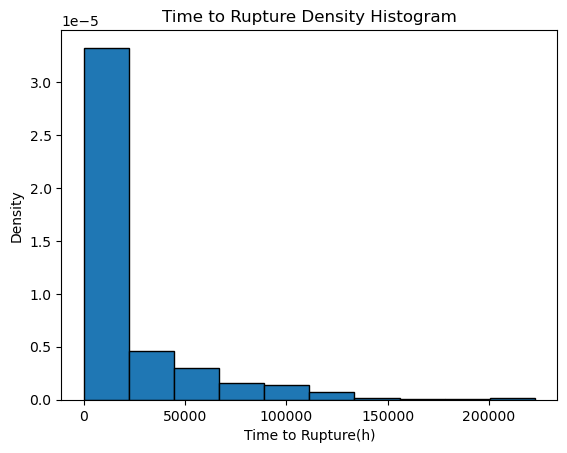

In [60]:
data=pd.read_excel(r'D:\creep rupture\TR+TS\Time to Rupture.xlsx')
y = data['Time to Rupture(h)']

# 绘制直方图
plt.hist(y, edgecolor='black', density=True)

# 添加标题和标签
plt.title('Time to Rupture Density Histogram')
plt.xlabel('Time to Rupture(h)')
plt.ylabel('Density')

# 显示图形
plt.show()

In [62]:
filtered_data1 = data[data['Time to Rupture(h)'] < 2500]

# 保存过滤后的数据到新的 excel 文件
filtered_data1.to_excel(r'D:\creep rupture\TR+TS\Time to Rupture小于2500.xlsx', index=False)

In [63]:
# 从 filtered_data 中随机挑选 100 条数据
random_samples = filtered_data1.sample(n=100)

# 保存数据到新的 excel 文件
random_samples.to_excel(r'D:\creep rupture\TR+TS\Time to Rupture小于2500_随机抽取100条.xlsx', index=False)

In [48]:
filtered_data = data[data['Time to Rupture(h)'] >= 2500]

# 保存过滤后的数据到新的 excel 文件
filtered_data.to_excel(r'D:\creep rupture\TR+TS\Filtered_Time to Rupture.xlsx', index=False)

In [50]:
filtered_data.describe()

,C,Si,Mn,P,S,Ni,Cr,Mo,W,Cu,...,rotary,si,Rockwell hardness(HRC),Austenite grain size number,Test Temparature(℃),0.2% Proof Stress(MPa),Test stress(MPa),Elongation(%),Reduction of Area(%),Time to Rupture(h)
count,426.000000,426.000000,426.000000,426.000000,426.000000,426.000000,426.000000,426.000000,426.000000,426.000000,...,426.000000,426.000000,426.000000,426.000000,426.000000,426.000000,426.000000,426.000000,426.000000,426.000000
mean,0.092859,0.391854,0.971150,0.019495,0.005722,5.772500,12.482254,0.555197,0.400634,0.344286,...,0.084917,0.231257,59.117840,7.034038,628.227700,212.254988,117.252113,21.978873,41.736150,31713.234507
std,0.028546,0.157941,0.541496,0.006919,0.005277,6.008129,6.490892,0.624027,0.733960,0.725596,...,0.198556,0.061539,29.504937,1.793870,76.657173,94.429407,77.889389,12.990113,28.757092,35759.107944
min,0.060000,0.100000,0.240000,0.005000,0.001000,0.000000,0.920000,0.000000,0.000000,0.000000,...,0.000000,0.000000,14.000000,3.800000,450.000000,69.000000,14.000000,0.600000,0.000000,2500.500000
25%,0.070000,0.270000,0.490000,0.015000,0.001000,0.120000,8.530000,0.040000,0.000000,0.000000,...,0.000000,0.203545,20.000000,5.800000,600.000000,150.000000,56.250000,13.000000,17.000000,6914.125000
50%,0.090000,0.380000,0.620000,0.020000,0.004000,0.850000,12.100000,0.420000,0.000000,0.062000,...,0.000000,0.258804,78.000000,6.200000,625.000000,169.000000,98.000000,21.000000,36.000000,16056.800000
75%,0.110000,0.540000,1.570000,0.025000,0.009000,11.320000,18.200000,0.890000,0.000000,0.170000,...,0.000000,0.278135,82.000000,8.900000,700.000000,250.000000,160.000000,28.850000,66.750000,45116.875000
max,0.210000,0.660000,1.710000,0.030000,0.017000,19.840000,24.600000,2.380000,1.870000,2.920000,...,0.548098,0.278135,88.000000,10.100000,800.000000,574.000000,441.000000,85.000000,96.000000,222705.300000


In [22]:
data = pd.read_excel(r'D:/creep rupture/TR+TS/Filtered_Time to Rupture.xlsx')
scaler = StandardScaler()
data_scaled = pd.DataFrame(scaler.fit_transform(data), columns=data.columns)
data_scaled.to_excel(r'D:/creep rupture/TR+TS/Filtered_Time to Rupture_Scaled.xlsx', index=False)

In [4]:
data = pd.read_excel(r'D:\creep rupture\TR+TS\Filtered_Time to Rupture_Scaled.xlsx')

# 根据你提供的代码，处理你的表格数据
x = data.drop(columns=[ 'Time to Rupture(h)'])
y = data['Time to Rupture(h)']

In [38]:
# 假设你的数据集中有多少个特性
num_features = x.shape[1]
# 假设你的输出是一个值
output_dim = 1

# 定义一些基本的参数
latent_dim = 100
num_classes = num_features
optimizer = Adam(0.0002, 0.5)

In [39]:
def create_generator():
    # 输入1: 噪声
    noise = Input(shape=(latent_dim,), name='g_noise')
    # 输入2：条件或标签
    condition = Input(shape=(1,), name='g_condition')
    
    i = Embedding(input_dim=num_classes, output_dim=output_dim, input_length=1)(condition)
    i = Flatten()(i)
    
    model_input = multiply([noise, i])

    # 建立生成器网络
    g = Sequential()
    g.add(Dense(256, input_shape=(latent_dim,)))
    g.add(BatchNormalization())  # 添加批归一化层
    g.add(LeakyReLU(alpha=0.2))
    g.add(Dropout(0.3))
    g.add(Dense(512))
    g.add(BatchNormalization())  # 添加批归一化层
    g.add(LeakyReLU(alpha=0.2))
    g.add(Dropout(0.3))
    g.add(Dense(1024))
    g.add(BatchNormalization())  # 添加批归一化层
    g.add(LeakyReLU(alpha=0.2))
    g.add(Dropout(0.3))
    g.add(Dense(num_features, activation='linear'))
    model_input = g(model_input)
    
    return Model([noise, condition], model_input)

In [40]:
# 创建判别器
def create_discriminator():
    # 输入1: 数据特征
    num_set = Input(shape=(num_features,), name='d_input')
    # 输入2：条件或标签
    condition = Input(shape=(1,), name='d_condition')

    i = Embedding(input_dim=num_classes, output_dim=latent_dim, input_length=1)(condition)
    i = Flatten()(i)
    i = Dense(num_features)(i)

    model_input = multiply([num_set, i])

    # 建立判别器网络
    d = Sequential()
    d.add(Dense(512, input_shape=(num_features,)))
    d.add(BatchNormalization())  # 添加批归一化层
    d.add(LeakyReLU(alpha=0.2))
    d.add(Dense(256))
    d.add(BatchNormalization())  # 添加批归一化层
    d.add(LeakyReLU(alpha=0.2))
    d.add(Dense(1, activation='linear'))
    model_input = d(model_input)
    return Model([num_set, condition], model_input)

In [41]:
def root_mean_squared_error(y_true, y_pred):
    return K.sqrt(K.mean(K.square(y_pred - y_true)))

generator = create_generator()
discriminator = create_discriminator()

optimizer = 'adam'  # 选择优化器
discriminator.compile(loss=root_mean_squared_error, optimizer=optimizer, metrics=[root_mean_squared_error])

In [42]:
# 用于组合的 CGAN 模型
z = Input(shape=(latent_dim,))
label = Input(shape=(1,))
generated_features = generator([z, label])

# 在组合模型中，判别器不进行训练
discriminator.trainable = False

real_or_fake = discriminator([generated_features, label])
cgan = Model([z, label], real_or_fake)
cgan.compile(loss=root_mean_squared_error, optimizer=optimizer)

In [43]:
# 训练过程
def train(generator, discriminator, cgan, epochs, batch_size=128):
    half_batch = int(batch_size / 2)
    d_loss_real_list = []
    d_loss_fake_list = []
    g_loss_list = []

    for epoch in range(epochs):
        # 训练判别器
        indices = np.random.randint(0, x.shape[0], half_batch)
        features, labels = x.iloc[indices], y.iloc[indices]

        noise = np.random.normal(0, 1, (half_batch, latent_dim))
        gen_features = generator.predict([noise, labels])

        d_loss_real = discriminator.train_on_batch([features, labels], np.ones((half_batch, 1)))
        d_loss_fake = discriminator.train_on_batch([gen_features, labels], np.zeros((half_batch, 1)))

        # 训练生成器
        noise = np.random.normal(0, 1, (batch_size, latent_dim))
        sampled_labels = np.random.randint(0, num_classes, batch_size).reshape(-1, 1)
        
        # 保存损失值到列表中
        d_loss_real_list.append(d_loss_real[0])
        d_loss_fake_list.append(d_loss_fake[0])
        g_loss = cgan.train_on_batch([noise, sampled_labels], np.ones((batch_size, 1)))
        g_loss_list.append(g_loss)

        print(f"{epoch+1}/{epochs} [D loss: {d_loss_real[0] + d_loss_fake[0]}] [G loss: {g_loss}]")
        
    return d_loss_real_list,d_loss_fake_list,g_loss_list

# 使用 train 函数进行训练
epochs = 5000
batch_size = 128
d_loss_real_list, d_loss_fake_list, g_loss_list = train(generator, discriminator, cgan, epochs, batch_size)

2/2 [==============================] - 0s 43ms/step
1/5000 [D loss: 2.022646650671959] [G loss: 0.9733493328094482]
2/2 [==============================] - 0s 27ms/step
2/5000 [D loss: 2.1713169254362583] [G loss: 0.9539918303489685]
2/2 [==============================] - 0s 25ms/step
3/5000 [D loss: 1.517037246376276] [G loss: 0.9399603605270386]
2/2 [==============================] - 0s 24ms/step
4/5000 [D loss: 1.38036447763443] [G loss: 0.9284568428993225]
2/2 [==============================] - 0s 37ms/step
5/5000 [D loss: 1.1240704543888569] [G loss: 0.9208839535713196]
2/2 [==============================] - 0s 28ms/step
6/5000 [D loss: 1.0038171410560608] [G loss: 0.9091138243675232]
2/2 [==============================] - 0s 30ms/step
7/5000 [D loss: 0.8201647698879242] [G loss: 0.9061895608901978]
2/2 [==============================] - 0s 25ms/step
8/5000 [D loss: 0.9296472668647766] [G loss: 0.8993823528289795]
2/2 [==============================] - 0s 30ms/step
9/5000 [D loss: 

2/2 [==============================] - 0s 19ms/step
71/5000 [D loss: 0.480803444981575] [G loss: 0.6075496673583984]
2/2 [==============================] - 0s 41ms/step
72/5000 [D loss: 0.3880341127514839] [G loss: 0.6017743349075317]
2/2 [==============================] - 0s 21ms/step
73/5000 [D loss: 0.2533082440495491] [G loss: 0.5849562883377075]
2/2 [==============================] - 0s 19ms/step
74/5000 [D loss: 0.38538986444473267] [G loss: 0.5711958408355713]
2/2 [==============================] - 0s 31ms/step
75/5000 [D loss: 0.3101012259721756] [G loss: 0.5783043503761292]
2/2 [==============================] - 0s 19ms/step
76/5000 [D loss: 0.2714369595050812] [G loss: 0.6048302054405212]
2/2 [==============================] - 0s 25ms/step
77/5000 [D loss: 0.24182641319930553] [G loss: 0.5481151342391968]
2/2 [==============================] - 0s 23ms/step
78/5000 [D loss: 0.36482498049736023] [G loss: 0.5896879434585571]
2/2 [==============================] - 0s 38ms/step
79

2/2 [==============================] - 0s 29ms/step
140/5000 [D loss: 0.32291290163993835] [G loss: 0.4719941020011902]
2/2 [==============================] - 0s 14ms/step
141/5000 [D loss: 0.23666423186659813] [G loss: 0.44500210881233215]
2/2 [==============================] - 0s 25ms/step
142/5000 [D loss: 0.3342062085866928] [G loss: 0.541182279586792]
2/2 [==============================] - 0s 27ms/step
143/5000 [D loss: 0.3497823476791382] [G loss: 0.451665997505188]
2/2 [==============================] - 0s 17ms/step
144/5000 [D loss: 0.28084881603717804] [G loss: 0.4041649103164673]
2/2 [==============================] - 0s 27ms/step
145/5000 [D loss: 0.24907254427671432] [G loss: 0.39986491203308105]
2/2 [==============================] - 0s 22ms/step
146/5000 [D loss: 0.1907503604888916] [G loss: 0.3680688440799713]
2/2 [==============================] - 0s 26ms/step
147/5000 [D loss: 0.28004859387874603] [G loss: 0.42411354184150696]
2/2 [==============================] - 0s 

208/5000 [D loss: 0.22106964886188507] [G loss: 0.3291627764701843]
2/2 [==============================] - 0s 14ms/step
209/5000 [D loss: 0.21174699813127518] [G loss: 0.42813074588775635]
2/2 [==============================] - 0s 39ms/step
210/5000 [D loss: 0.1535729542374611] [G loss: 0.5180619955062866]
2/2 [==============================] - 0s 26ms/step
211/5000 [D loss: 0.19087719172239304] [G loss: 0.5692461729049683]
2/2 [==============================] - 0s 25ms/step
212/5000 [D loss: 0.21293580532073975] [G loss: 0.45376694202423096]
2/2 [==============================] - 0s 17ms/step
213/5000 [D loss: 0.19019725173711777] [G loss: 0.3748098909854889]
2/2 [==============================] - 0s 35ms/step
214/5000 [D loss: 0.16734476760029793] [G loss: 0.3542235195636749]
2/2 [==============================] - 0s 43ms/step
215/5000 [D loss: 0.28581908345222473] [G loss: 0.40158215165138245]
2/2 [==============================] - 0s 35ms/step
216/5000 [D loss: 0.1728129591792822] 

2/2 [==============================] - 0s 33ms/step
277/5000 [D loss: 0.17948062345385551] [G loss: 0.5354565978050232]
2/2 [==============================] - 0s 30ms/step
278/5000 [D loss: 0.2193955685943365] [G loss: 0.5324393510818481]
2/2 [==============================] - 0s 25ms/step
279/5000 [D loss: 0.14121349155902863] [G loss: 0.5274330377578735]
2/2 [==============================] - 0s 36ms/step
280/5000 [D loss: 0.24050192907452583] [G loss: 0.5411004424095154]
2/2 [==============================] - 0s 22ms/step
281/5000 [D loss: 0.19008037075400352] [G loss: 0.6241568326950073]
2/2 [==============================] - 0s 27ms/step
282/5000 [D loss: 0.1520153135061264] [G loss: 0.7073091268539429]
2/2 [==============================] - 0s 17ms/step
283/5000 [D loss: 0.15962545946240425] [G loss: 0.7139791250228882]
2/2 [==============================] - 0s 24ms/step
284/5000 [D loss: 0.17874996550381184] [G loss: 0.6575831174850464]
2/2 [==============================] - 0s 

...

2/2 [==============================] - 0s 44ms/step
4699/5000 [D loss: 0.07372821681201458] [G loss: 0.22997666895389557]
2/2 [==============================] - 0s 32ms/step
4700/5000 [D loss: 0.062089983373880386] [G loss: 0.23522064089775085]
2/2 [==============================] - 0s 20ms/step
4701/5000 [D loss: 0.07227485068142414] [G loss: 0.2964921295642853]
2/2 [==============================] - 0s 28ms/step
4702/5000 [D loss: 0.08559996634721756] [G loss: 0.30454492568969727]
2/2 [==============================] - 0s 36ms/step
4703/5000 [D loss: 0.05627564154565334] [G loss: 0.23126272857189178]
2/2 [==============================] - 0s 40ms/step
4704/5000 [D loss: 0.1247950941324234] [G loss: 0.21949470043182373]
2/2 [==============================] - 0s 40ms/step
4705/5000 [D loss: 0.07930681481957436] [G loss: 0.26905909180641174]
2/2 [==============================] - 0s 32ms/step
4706/5000 [D loss: 0.07160432264208794] [G loss: 0.3171628415584564]
2/2 [=====================

2/2 [==============================] - 0s 37ms/step
4766/5000 [D loss: 0.07842617854475975] [G loss: 0.21769079566001892]
2/2 [==============================] - 0s 30ms/step
4767/5000 [D loss: 0.08976243063807487] [G loss: 0.20713117718696594]
2/2 [==============================] - 0s 42ms/step
4768/5000 [D loss: 0.06303826905786991] [G loss: 0.18540699779987335]
2/2 [==============================] - 0s 35ms/step
4769/5000 [D loss: 0.0936041958630085] [G loss: 0.23038223385810852]
2/2 [==============================] - 0s 40ms/step
4770/5000 [D loss: 0.12224990501999855] [G loss: 0.22865867614746094]
2/2 [==============================] - 0s 31ms/step
4771/5000 [D loss: 0.052054399624466896] [G loss: 0.3733058571815491]
2/2 [==============================] - 0s 43ms/step
4772/5000 [D loss: 0.12093568593263626] [G loss: 0.38915130496025085]
2/2 [==============================] - 0s 29ms/step
4773/5000 [D loss: 0.09198437631130219] [G loss: 0.3155548870563507]
2/2 [=====================

4833/5000 [D loss: 0.07834035716950893] [G loss: 0.1943933367729187]
2/2 [==============================] - 0s 23ms/step
4834/5000 [D loss: 0.06980589963495731] [G loss: 0.181123748421669]
2/2 [==============================] - 0s 22ms/step
4835/5000 [D loss: 0.11168016493320465] [G loss: 0.18950320780277252]
2/2 [==============================] - 0s 25ms/step
4836/5000 [D loss: 0.05696850270032883] [G loss: 0.2491922378540039]
2/2 [==============================] - 0s 27ms/step
4837/5000 [D loss: 0.061889296397566795] [G loss: 0.24665921926498413]
2/2 [==============================] - 0s 43ms/step
4838/5000 [D loss: 0.12965627014636993] [G loss: 0.1928243488073349]
2/2 [==============================] - 0s 33ms/step
4839/5000 [D loss: 0.0804971307516098] [G loss: 0.20748499035835266]
2/2 [==============================] - 0s 37ms/step
4840/5000 [D loss: 0.06067420542240143] [G loss: 0.1899045705795288]
2/2 [==============================] - 0s 23ms/step
4841/5000 [D loss: 0.081197584

2/2 [==============================] - 0s 38ms/step
4901/5000 [D loss: 0.06780639290809631] [G loss: 0.24778635799884796]
2/2 [==============================] - 0s 28ms/step
4902/5000 [D loss: 0.0770820863544941] [G loss: 0.23186059296131134]
2/2 [==============================] - 0s 68ms/step
4903/5000 [D loss: 0.057585664093494415] [G loss: 0.1790313720703125]
2/2 [==============================] - 0s 30ms/step
4904/5000 [D loss: 0.07001681998372078] [G loss: 0.19765548408031464]
2/2 [==============================] - 0s 37ms/step
4905/5000 [D loss: 0.08282377198338509] [G loss: 0.1440642774105072]
2/2 [==============================] - 0s 40ms/step
4906/5000 [D loss: 0.059646230190992355] [G loss: 0.20895592868328094]
2/2 [==============================] - 0s 24ms/step
4907/5000 [D loss: 0.09388858824968338] [G loss: 0.19043949246406555]
2/2 [==============================] - 0s 39ms/step
4908/5000 [D loss: 0.06350409798324108] [G loss: 0.24107283353805542]
2/2 [====================

2/2 [==============================] - 0s 42ms/step
4969/5000 [D loss: 0.05907062813639641] [G loss: 0.27220261096954346]
2/2 [==============================] - 0s 32ms/step
4970/5000 [D loss: 0.11190133169293404] [G loss: 0.25229284167289734]
2/2 [==============================] - 0s 21ms/step
4971/5000 [D loss: 0.11360190995037556] [G loss: 0.16374196112155914]
2/2 [==============================] - 0s 43ms/step
4972/5000 [D loss: 0.09312107134610415] [G loss: 0.20533157885074615]
2/2 [==============================] - 0s 38ms/step
4973/5000 [D loss: 0.07460213825106621] [G loss: 0.22372689843177795]
2/2 [==============================] - 0s 40ms/step
4974/5000 [D loss: 0.07974501699209213] [G loss: 0.17886696755886078]
2/2 [==============================] - 0s 32ms/step
4975/5000 [D loss: 0.08541101589798927] [G loss: 0.1946103572845459]
2/2 [==============================] - 0s 39ms/step
4976/5000 [D loss: 0.10690906643867493] [G loss: 0.24598950147628784]
2/2 [====================

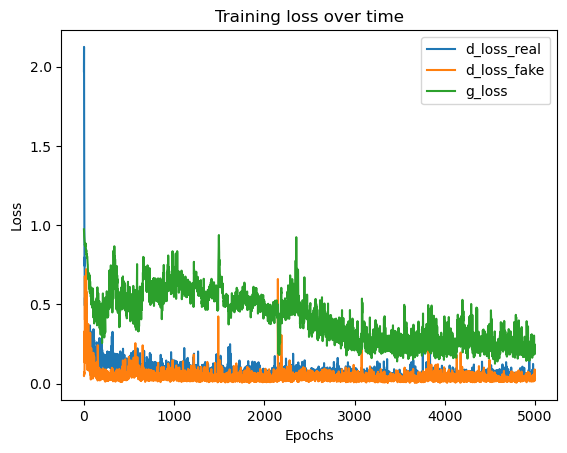

In [44]:
# 绘制损失值随训练次数的变化图
import matplotlib.pyplot as plt

plt.plot(range(epochs), d_loss_real_list, label='D loss - Real')
plt.plot(range(epochs), d_loss_fake_list, label='D loss - Fake')
plt.plot(range(epochs), g_loss_list, label='G loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training loss over time')
plt.legend(['d_loss_real', 'd_loss_fake', 'g_loss'])
plt.show()

In [55]:
# 生成虚拟数据
num_samples = 426
noise = np.random.normal(0, 1, (num_samples, latent_dim))
sampled_labels = np.random.randint(0, num_classes, num_samples).reshape(-1, 1)
generated_features = generator.predict([noise, sampled_labels])

# 将生成的数据保存为 pandas DataFrame
generated_data = pd.DataFrame(generated_features, columns=x.columns)
generated_data['Time to Rupture(h)'] = y.max()  # 此处将生成的数据的时间设置为真实数据的最大时间

# 输出生成的数据
generated_data.head()

14/14 [==============================] - 1s 39ms/step


,C,Si,Mn,P,S,Ni,Cr,Mo,W,Cu,...,rotary,si,Rockwell hardness(HRC),Austenite grain size number,Test Temparature(℃),0.2% Proof Stress(MPa),Test stress(MPa),Elongation(%),Reduction of Area(%),Time to Rupture(h)
0,1438.997803,-2515.613037,-3123.549561,-705.891724,2356.630127,-1162.850220,497.415314,-746.014160,593.622742,279.690002,...,-1606.722656,-108.759598,79.284760,-1591.282471,-284.492706,509.085022,1997.448364,-203.343536,-83.839027,222705.3
1,1402.908447,-2460.690430,-3050.445557,-697.724976,2305.819580,-1140.856445,493.748993,-729.441772,577.267883,274.518524,...,-1583.047729,-107.053200,90.695129,-1573.648682,-279.736786,494.701324,1954.647339,-198.609909,-82.240257,222705.3
2,1467.217041,-2582.873535,-3217.408691,-725.038696,2441.094238,-1191.491943,525.821899,-776.699463,605.310425,282.436432,...,-1655.471313,-107.640045,105.218330,-1651.529785,-289.946594,509.664948,2057.644531,-208.406982,-82.014305,222705.3
3,1348.845825,-2334.919434,-2874.322754,-677.879150,2160.827881,-1093.220703,446.899475,-673.166504,552.371399,263.818268,...,-1511.331543,-108.975128,58.617565,-1487.372681,-274.633881,484.280548,1845.715820,-187.628372,-84.727890,222705.3
4,197.672104,-99.257240,264.629791,-224.922562,-423.689484,-190.740189,-191.073944,245.839325,41.766830,138.849457,...,-226.980469,-124.093216,-261.647003,-75.908707,-103.183983,246.944611,-63.092598,-12.097716,-113.308403,222705.3


In [56]:
# 假设 filtered_data 是您原始数据的 pandas DataFrame
std = filtered_data.describe().loc['std']
mean = filtered_data.describe().loc['mean']
# 将生成的数据逆标准化
generated_data_inverse = generated_data * std + mean
distances = np.linalg.norm(filtered_data.values - generated_data_inverse.values, axis=1)
indices_sorted = np.argsort(distances)
k = 200  # 选择距离最近的前 k 个数据点
nearest_indices = indices_sorted[:k]
nearest_data = filtered_data.iloc[nearest_indices]

In [57]:
# 将逆标准化后的生成数据保
nearest_data.to_excel(r'D:\creep rupture\TR+TS\generated_data_inverse.xlsx', index=False)

In [59]:
nearest_data.head()

,C,Si,Mn,P,S,Ni,Cr,Mo,W,Cu,...,rotary,si,Rockwell hardness(HRC),Austenite grain size number,Test Temparature(℃),0.2% Proof Stress(MPa),Test stress(MPa),Elongation(%),Reduction of Area(%),Time to Rupture(h)
539,0.07,0.61,1.65,0.025,0.007,13.600,16.60,2.33,0.0,0.26,...,0.548098,0.199132,78.0,6.2,700,456.0,41.0,14.0,22.0,222705.3
225,0.11,0.66,0.51,0.012,0.005,0.032,1.27,0.56,0.0,0.07,...,0.548098,0.199132,83.0,7.0,500,250.0,108.0,13.0,37.0,201284.4
647,0.07,0.60,1.71,0.020,0.005,12.000,17.85,0.04,0.0,0.05,...,0.000000,0.278135,84.0,5.4,600,150.0,137.0,16.0,29.0,195221.6
655,0.07,0.60,1.71,0.020,0.005,12.000,17.85,0.04,0.0,0.05,...,0.000000,0.278135,84.0,5.4,650,146.0,78.0,16.0,22.0,171094.7
528,0.07,0.61,1.65,0.025,0.007,13.600,16.60,2.33,0.0,0.26,...,0.548098,0.199132,78.0,6.2,600,162.0,108.0,26.0,39.0,152758.0


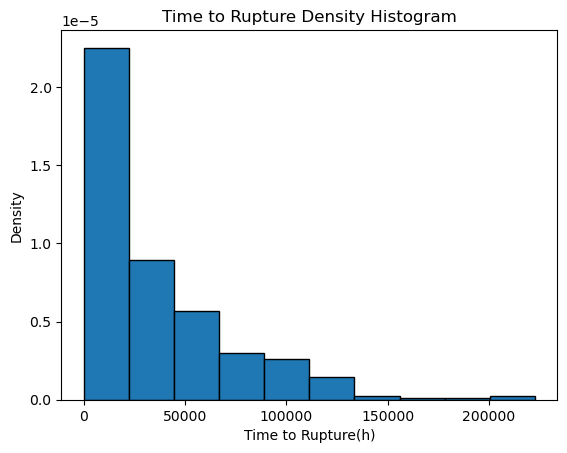

In [64]:
data=pd.read_excel(r'D:\creep rupture\TR+TS\GAN200+小于2500的100条.xlsx')
y = data['Time to Rupture(h)']

# 绘制直方图
plt.hist(y, edgecolor='black', density=True)

# 添加标题和标签
plt.title('Time to Rupture Density Histogram')
plt.xlabel('Time to Rupture(h)')
plt.ylabel('Density')

# 显示图形
plt.show()

## 数据处理

In [108]:
import copy
%matplotlib inline
import matplotlib.pyplot as plt
#!pip install seaborn #to directly install a library from a python script
import seaborn as sns


from sklearn.feature_selection import VarianceThreshold

from sklearn.preprocessing import MinMaxScaler

In [66]:
def load_data():
    #Either use numpy to get the csv as a numpy array
    #features_with_label_with_column_names = np.genfromtxt("../Data/newdata_hardness_as_target_csv_only_simulation_data.csv", delimiter=",")
    
    #Or use pandas to get a pandas data frame
    data=pd.read_excel(r'D:\creep rupture\TR+TS\GAN200+小于2500的100条.xlsx')
    features_with_label_with_column_names =data.drop(columns=['数据来源'])
    return features_with_label_with_column_names

In [69]:
original_data = load_data()
#create a copy of the original data features and labels
copy_of_original_data = copy.deepcopy(original_data)

In [70]:
np.random.seed(42)
shuffled_data_indices = np.random.permutation(len(original_data))
test_split_size = 0.10
total_test_data = int(test_split_size * len(original_data))

#Since the data size is very small, we will use kFold crossvalidation, and thus do not need a separate validation set.

testing_indices = shuffled_data_indices[:total_test_data]
training_indices = shuffled_data_indices[total_test_data:]

print(f"The length of the original data set is: {len(original_data)}")
print(f"After the split, the training data and the testing data have lengths of: {len(training_indices)} and {len(testing_indices)}")

training_data = original_data.iloc[training_indices]
test_data = original_data.iloc[testing_indices]

The length of the original data set is: 726
After the split, the training data and the testing data have lengths of: 654 and 72


In [71]:
test_data

,C,Si,Mn,P,S,Ni,Cr,Mo,W,Cu,...,rotary,si,Rockwell hardness(HRC),Austenite grain size number,Test Temparature(℃),0.2% Proof Stress(MPa),Test stress(MPa),Elongation(%),Reduction of Area(%),Time to Rupture(h)
326,0.07,0.61,1.65,0.025,0.007,13.60,16.60,2.330,0.00,0.26,...,0.548098,0.199132,78.0,6.2,600,162.0,108.0,26.0,39.0,152758.0
519,0.07,0.18,0.24,0.009,0.002,0.00,2.58,0.027,1.60,0.00,...,0.000000,0.231682,88.0,5.9,550,318.0,120.0,24.0,72.0,51608.3
580,0.09,0.40,1.57,0.026,0.001,11.32,18.20,0.000,0.00,0.00,...,0.000000,0.258804,82.0,8.9,650,169.0,120.0,31.0,36.0,26534.6
33,0.10,0.38,0.40,0.015,0.001,0.12,8.53,0.960,0.00,0.00,...,0.000000,0.203545,16.0,10.1,600,281.0,140.0,31.2,90.8,2777.1
570,0.07,0.55,1.46,0.023,0.006,9.57,18.95,0.040,0.00,0.07,...,0.000000,0.278135,81.0,5.1,700,131.0,53.0,19.0,24.0,31900.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
227,0.11,0.27,0.59,0.015,0.002,0.33,12.10,0.340,1.82,0.82,...,0.000000,0.258804,20.0,9.2,650,213.0,70.0,26.0,34.0,6909.0
174,0.11,0.62,0.44,0.026,0.006,0.07,8.58,0.950,0.00,0.05,...,0.000000,0.278135,83.0,7.1,600,128.0,61.0,39.0,94.0,10758.4
23,0.10,0.38,0.40,0.015,0.001,0.12,8.53,0.960,0.00,0.00,...,0.000000,0.203545,16.0,10.1,500,396.0,290.0,27.0,89.0,8840.0
554,0.10,0.38,0.40,0.015,0.001,0.12,8.53,0.960,0.00,0.00,...,0.000000,0.203545,16.0,10.1,550,348.0,180.0,23.5,82.4,35101.8


In [72]:
original_data.head()

,C,Si,Mn,P,S,Ni,Cr,Mo,W,Cu,...,rotary,si,Rockwell hardness(HRC),Austenite grain size number,Test Temparature(℃),0.2% Proof Stress(MPa),Test stress(MPa),Elongation(%),Reduction of Area(%),Time to Rupture(h)
0,0.21,0.44,0.62,0.023,0.004,0.85,11.46,0.97,0.94,0.062,...,0.0,0.225261,31.15,5.5,500,574.0,441.0,12.0,66.0,3121.7
1,0.21,0.44,0.62,0.023,0.004,0.85,11.46,0.97,0.94,0.062,...,0.0,0.225261,31.15,5.5,500,574.0,373.0,9.0,48.0,15312.9
2,0.21,0.44,0.62,0.023,0.004,0.85,11.46,0.97,0.94,0.062,...,0.0,0.225261,31.15,5.5,500,574.0,412.0,11.0,65.0,9154.2
3,0.21,0.44,0.62,0.023,0.004,0.85,11.46,0.97,0.94,0.062,...,0.0,0.225261,31.15,5.5,550,496.0,245.0,7.0,33.0,13627.3
4,0.21,0.44,0.62,0.023,0.004,0.85,11.46,0.97,0.94,0.062,...,0.0,0.225261,31.15,5.5,550,496.0,294.0,5.0,22.0,5300.3


In [73]:
original_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 726 entries, 0 to 725
Data columns (total 57 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   C                            726 non-null    float64
 1   Si                           726 non-null    float64
 2   Mn                           726 non-null    float64
 3   P                            726 non-null    float64
 4   S                            726 non-null    float64
 5   Ni                           726 non-null    float64
 6   Cr                           726 non-null    float64
 7   Mo                           726 non-null    float64
 8   W                            726 non-null    float64
 9   Cu                           726 non-null    float64
 10  B                            726 non-null    float64
 11  Al                           726 non-null    float64
 12  Ti                           726 non-null    float64
 13  N                   

In [74]:
original_data.describe()

,C,Si,Mn,P,S,Ni,Cr,Mo,W,Cu,...,rotary,si,Rockwell hardness(HRC),Austenite grain size number,Test Temparature(℃),0.2% Proof Stress(MPa),Test stress(MPa),Elongation(%),Reduction of Area(%),Time to Rupture(h)
count,726.000000,726.000000,726.000000,726.000000,726.000000,726.000000,726.000000,726.000000,726.000000,726.000000,...,726.000000,726.000000,726.000000,726.000000,726.000000,726.000000,726.000000,726.000000,726.000000,726.000000
mean,0.092264,0.390606,0.968815,0.019333,0.005696,5.759862,12.439890,0.563083,0.422273,0.329782,...,0.087575,0.227909,58.954063,6.999174,627.479339,211.800792,121.533609,22.580028,42.893939,34796.394628
std,0.027527,0.162008,0.545959,0.006891,0.005254,6.028018,6.459157,0.638720,0.746843,0.705935,...,0.200962,0.067127,29.726601,1.777918,75.548908,93.457115,80.207394,13.795152,29.364990,37977.794264
min,0.060000,0.100000,0.240000,0.005000,0.001000,0.000000,0.920000,0.000000,0.000000,0.000000,...,0.000000,0.000000,14.000000,3.800000,450.000000,69.000000,14.000000,0.600000,0.000000,4.300000
25%,0.070000,0.250000,0.490000,0.015000,0.001000,0.120000,8.530000,0.040000,0.000000,0.000000,...,0.000000,0.203545,20.000000,5.800000,600.000000,150.000000,60.000000,13.000000,16.000000,5682.850000
50%,0.090000,0.380000,0.600000,0.020000,0.004000,0.360000,12.100000,0.420000,0.000000,0.062000,...,0.000000,0.258804,78.000000,6.200000,625.000000,169.000000,100.000000,20.200000,37.000000,21980.000000
75%,0.110000,0.550000,1.570000,0.025000,0.009000,11.320000,18.200000,0.890000,0.000000,0.170000,...,0.000000,0.278135,82.000000,8.900000,700.000000,255.000000,174.500000,29.000000,73.600000,52951.475000
max,0.210000,0.660000,1.710000,0.030000,0.017000,19.840000,24.600000,2.380000,1.870000,2.920000,...,0.548098,0.278135,88.000000,10.100000,800.000000,574.000000,471.000000,89.000000,96.000000,222705.300000


In [75]:
num_features = len(training_data.iloc[0]) - 1 # subtracting one because the data still contains the label column

raw_training_features, raw_training_labels = training_data.iloc[:,0:num_features], training_data.iloc[:,num_features]
raw_testing_features, raw_testing_labels = test_data.iloc[:,0:num_features], test_data.iloc[:,num_features]

#since the labels consist of a single column, pandas creates raw_labels variable as a pandas series, convert into df
raw_training_labels = pd.DataFrame(raw_training_labels)
raw_testing_labels = pd.DataFrame(raw_testing_labels)

In [76]:
features_description = raw_training_features.describe()
transposed_description = features_description.T
#add a new column that shows what percent of the samples are missing each features
transposed_description["missing_percent"] = 1 - (transposed_description["count"]/len(raw_training_features))

transposed_description["missing_percent"]

C                              0.0
Si                             0.0
Mn                             0.0
P                              0.0
S                              0.0
Ni                             0.0
Cr                             0.0
Mo                             0.0
W                              0.0
Cu                             0.0
B                              0.0
Al                             0.0
Ti                             0.0
N                              0.0
V                              0.0
Nb                             0.0
Zr                             0.0
Nb+Ta                          0.0
Co                             0.0
Sn                             0.0
ρ(g/㎤)                         0.0
R(Å)                           0.0
∆R                             0.0
χ                              0.0
∆χ                             0.0
VEC                            0.0
∆VEC                           0.0
dA                             0.0
dB                  

In [77]:
print(f"Shape of features before removing zero-variance features: {raw_training_features.shape}")
columns_before_removing_zero_variance_features = raw_training_features.columns

raw_training_features_with_high_variance = raw_training_features.loc[:, raw_training_features.std(axis=0) > 0.]

print(f"Shape of features after removing zero-variance features: {raw_training_features_with_high_variance.shape}")
columns_after_removing_zero_variance_features = raw_training_features_with_high_variance.columns

Shape of features before removing zero-variance features: (654, 56)
Shape of features after removing zero-variance features: (654, 56)


In [78]:
corr_matrix = raw_training_features_with_high_variance.corr()
min_variables_to_keep = 1
count_of_features = len(corr_matrix)

print("Performing Multicollinearity Analysis.")

#if current number if features > min number of features to keep
if count_of_features > min_variables_to_keep:
    
    while True:
        
        col_names = corr_matrix.keys() #get column names if present, else the column number
        eigen_vals, eigen_vects = np.linalg.eig(corr_matrix)
        #Note that numpy returns complex eigen values due to truncation and rounding-off
        
        #The condition indices are computed by finding the square root of the maximum eigenvalue divided by
        #the eigenvalues of the design matrix. 
        
        condition_indices = (max(eigen_vals)/eigen_vals)**(1/2)  #Taking the square-root to calculate
        
        #If the condition index <= 30, then multicollinearity is not severe.
        if max(condition_indices) <= 30 or count_of_features <= min_variables_to_keep:
            break
        
        for idx, val in enumerate(eigen_vals):
            if val == min(eigen_vals):
                
                for idxxx, eigen_vec in enumerate(eigen_vects[:,idx]):
                    
                    if abs(eigen_vec) == max( (abs(eigen_vects[:,idx]) )):
                        
                        mask = np.ones(len(corr_matrix), dtype = bool)
                        
                        for num, column in enumerate(corr_matrix.keys()):
                            mask[num] = num != idxxx
                            
                            if num == idxxx:
                                mask[num] = 0
                            else:
                                mask[num] = 1
                        
                        #Delete the row corresponding to this feature with the highest loading in the Eigen vector
                        corr_matrix = corr_matrix[mask]
                        #Delete the column corresponding to the feature that has the highest loading in the Eigen vector
                        corr_matrix.pop(col_names[idxxx])
                        
        
print("Number of features that will remain after removing multicollinearity: ", len(corr_matrix))

Performing Multicollinearity Analysis.
Number of features that will remain after removing multicollinearity:  26


C:\Users\zangd\AppData\Local\Temp\ipykernel_93836\735378320.py:19: RuntimeWarning: invalid value encountered in sqrt
  condition_indices = (max(eigen_vals)/eigen_vals)**(1/2)  #Taking the square-root to calculate


In [79]:
features_after_multicollinearity_removal = corr_matrix.columns
features_after_multicollinearity_removal

Index(['Si', 'Mn', 'P', 'S', 'Mo', 'W', 'Cu', 'B', 'Al', 'Ti', 'N', 'Nb+Ta',
       'Co', 'dA', 'dC', 'electric', 'pierced', 'rolled', 'si',
       'Rockwell hardness(HRC)', 'Austenite grain size number',
       'Test Temparature(℃)', '0.2% Proof Stress(MPa)', 'Test stress(MPa)',
       'Elongation(%)', 'Reduction of Area(%)'],
      dtype='object')

In [80]:
features_without_multicollinearity = raw_training_features_with_high_variance[features_after_multicollinearity_removal]

features_without_multicollinearity.head()

,Si,Mn,P,S,Mo,W,Cu,B,Al,Ti,...,pierced,rolled,si,Rockwell hardness(HRC),Austenite grain size number,Test Temparature(℃),0.2% Proof Stress(MPa),Test stress(MPa),Elongation(%),Reduction of Area(%)
405,0.60,1.71,0.020,0.005,0.04,0.00,0.05,0.0000,0.019,0.019,...,0.000000,0.000000,0.278135,84.0,5.4,650,146.0,108.0,18.0,32.0
260,0.62,1.56,0.025,0.013,0.47,0.00,0.17,0.0007,0.047,0.040,...,0.000000,0.000000,0.278135,80.0,5.9,750,148.0,29.0,5.0,2.0
323,0.61,1.65,0.025,0.007,2.33,0.00,0.26,0.0011,0.017,0.043,...,0.548098,0.000000,0.199132,78.0,6.2,600,162.0,157.0,61.0,78.0
675,0.25,0.55,0.010,0.009,1.03,0.00,0.13,0.0000,0.010,0.000,...,0.000000,0.756079,0.214617,17.0,6.7,650,246.0,78.0,54.0,75.0
209,0.31,0.60,0.017,0.001,0.33,1.87,0.86,0.0024,0.007,0.000,...,0.000000,0.000000,0.258804,20.0,5.8,700,122.0,50.0,15.0,19.0


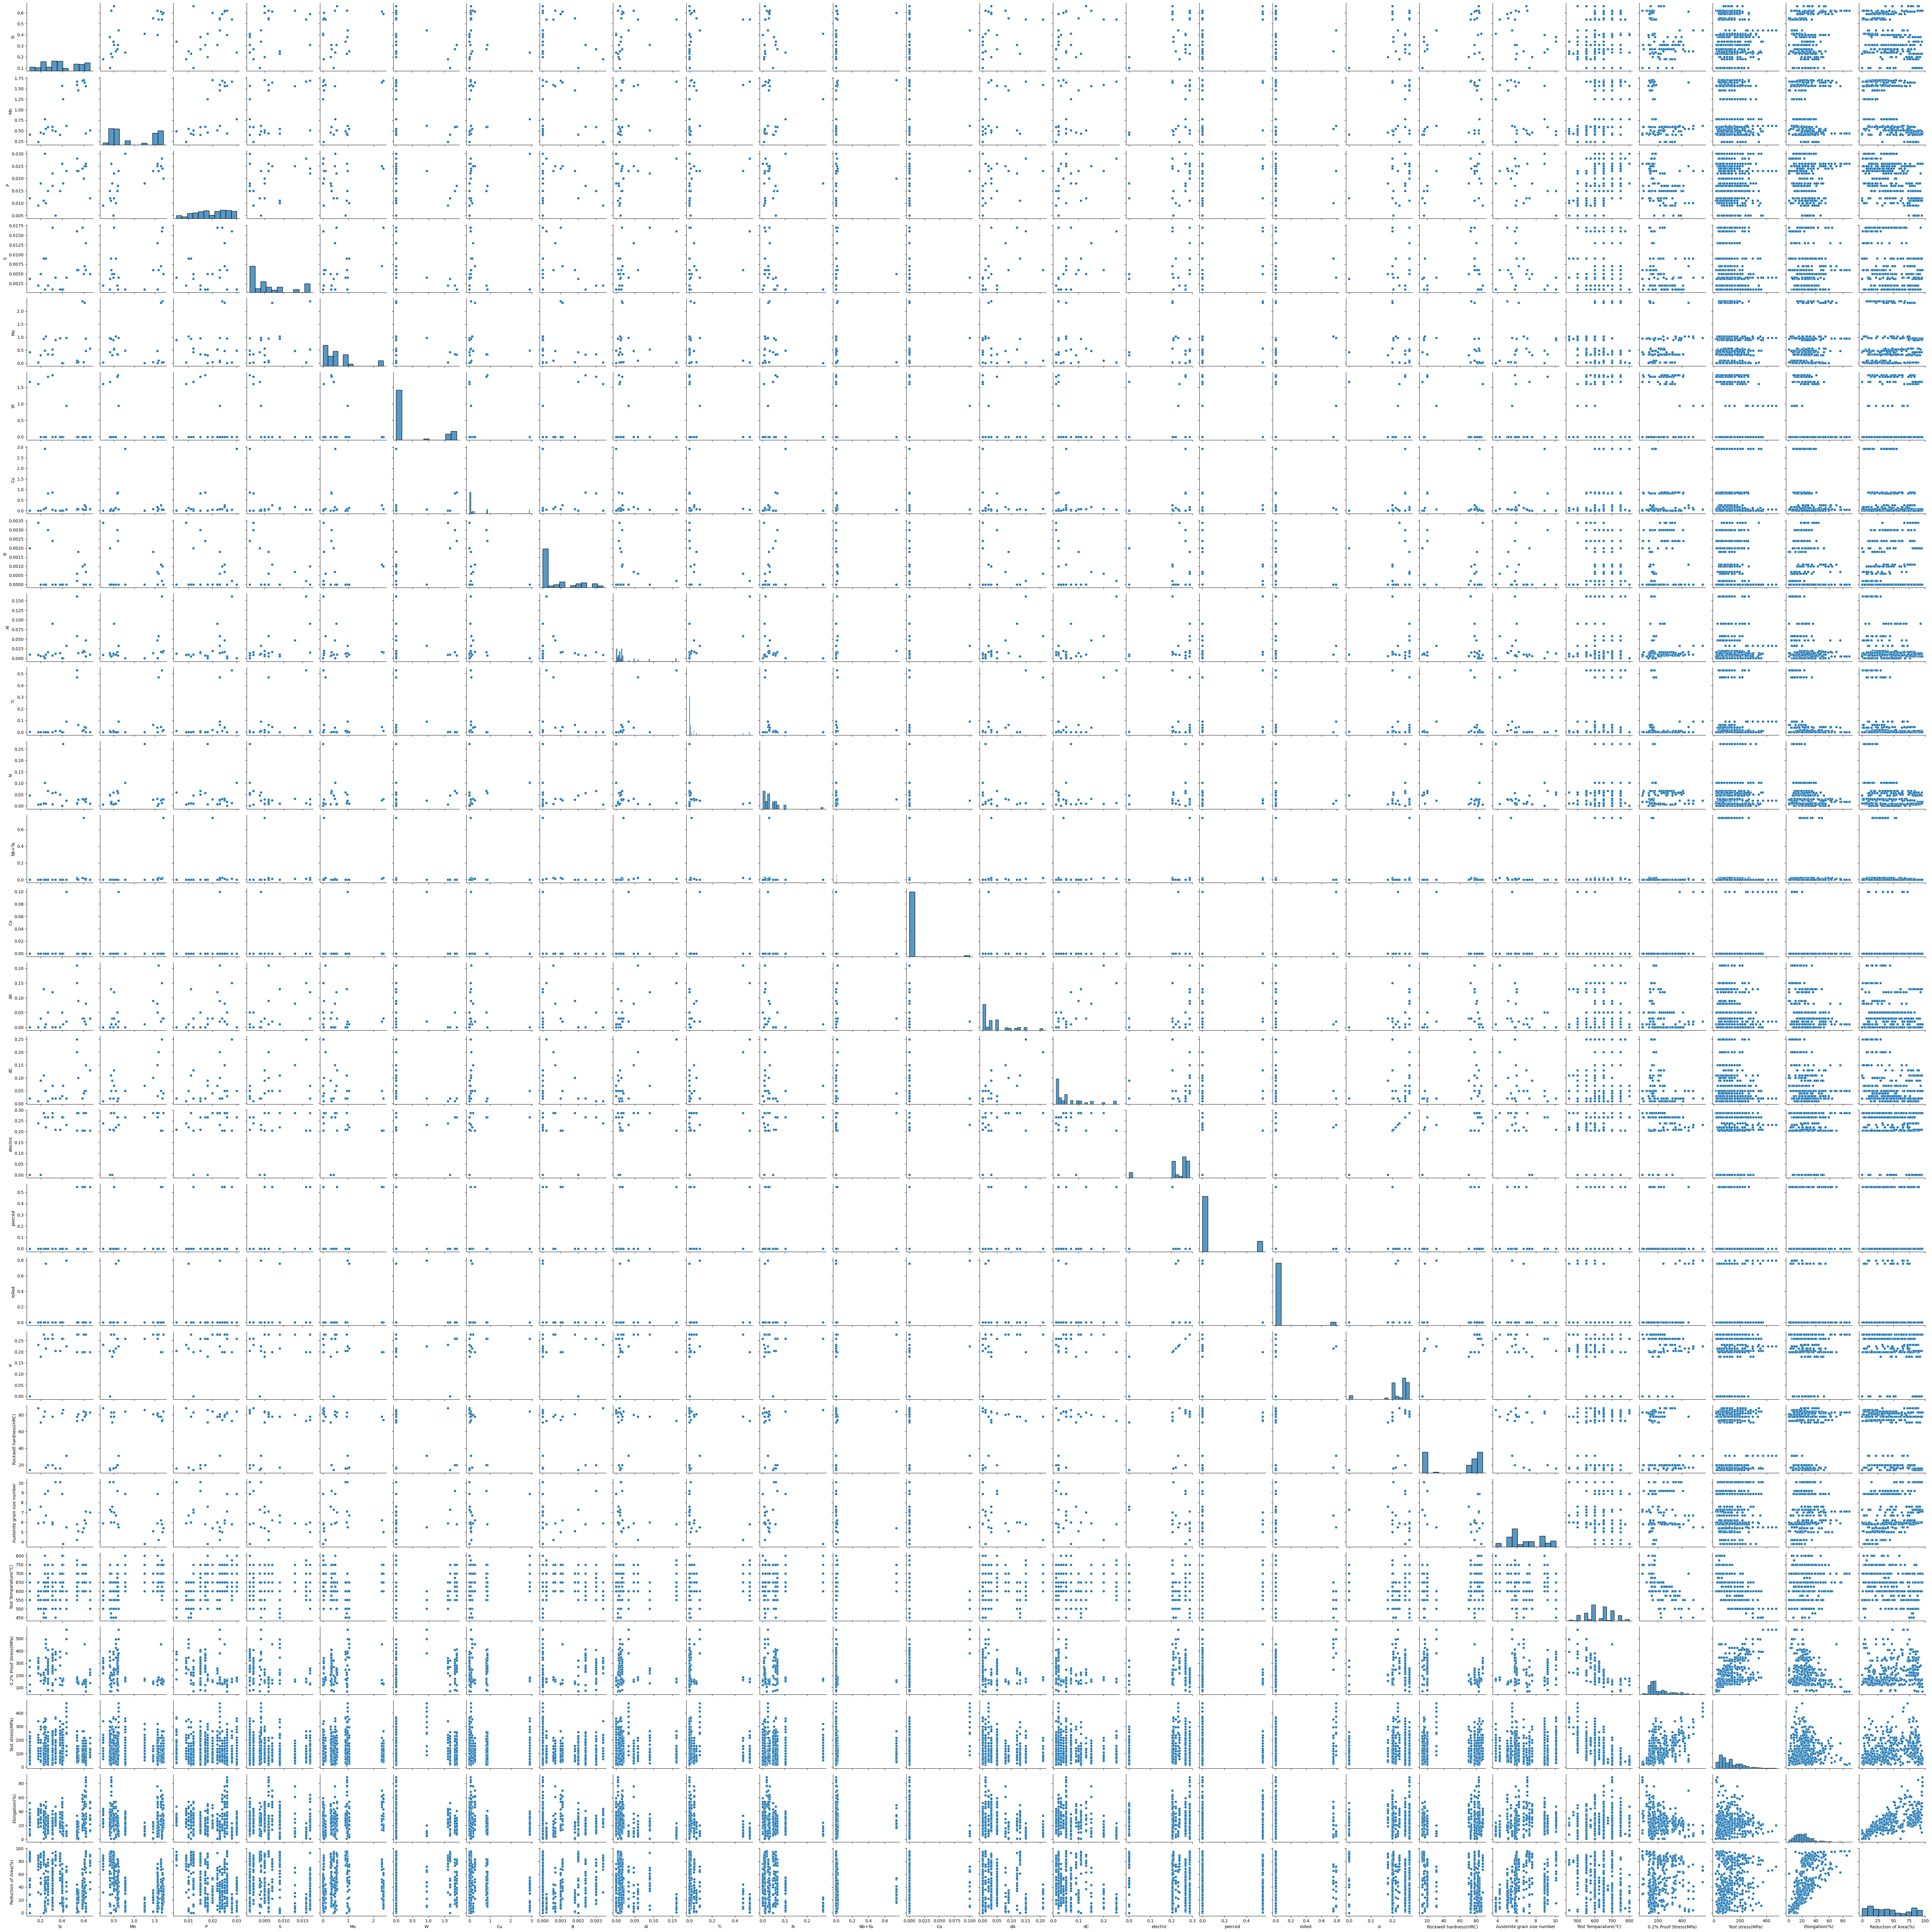

In [81]:
sns.pairplot(features_without_multicollinearity)

In [82]:
features_to_scale = features_without_multicollinearity[features_without_multicollinearity.columns[~features_without_multicollinearity.columns.isin(["% of Co","%Fe"])]]
features_to_scale.head()

,Si,Mn,P,S,Mo,W,Cu,B,Al,Ti,...,pierced,rolled,si,Rockwell hardness(HRC),Austenite grain size number,Test Temparature(℃),0.2% Proof Stress(MPa),Test stress(MPa),Elongation(%),Reduction of Area(%)
405,0.60,1.71,0.020,0.005,0.04,0.00,0.05,0.0000,0.019,0.019,...,0.000000,0.000000,0.278135,84.0,5.4,650,146.0,108.0,18.0,32.0
260,0.62,1.56,0.025,0.013,0.47,0.00,0.17,0.0007,0.047,0.040,...,0.000000,0.000000,0.278135,80.0,5.9,750,148.0,29.0,5.0,2.0
323,0.61,1.65,0.025,0.007,2.33,0.00,0.26,0.0011,0.017,0.043,...,0.548098,0.000000,0.199132,78.0,6.2,600,162.0,157.0,61.0,78.0
675,0.25,0.55,0.010,0.009,1.03,0.00,0.13,0.0000,0.010,0.000,...,0.000000,0.756079,0.214617,17.0,6.7,650,246.0,78.0,54.0,75.0
209,0.31,0.60,0.017,0.001,0.33,1.87,0.86,0.0024,0.007,0.000,...,0.000000,0.000000,0.258804,20.0,5.8,700,122.0,50.0,15.0,19.0


In [83]:
features_to_scale.min(axis = 0)

Si                               0.100
Mn                               0.240
P                                0.005
S                                0.001
Mo                               0.000
W                                0.000
Cu                               0.000
B                                0.000
Al                               0.000
Ti                               0.000
N                                0.000
Nb+Ta                            0.000
Co                               0.000
dA                               0.000
dC                               0.010
electric                         0.000
pierced                          0.000
rolled                           0.000
si                               0.000
Rockwell hardness(HRC)          14.000
Austenite grain size number      3.800
Test Temparature(℃)            450.000
0.2% Proof Stress(MPa)          69.000
Test stress(MPa)                14.000
Elongation(%)                    0.600
Reduction of Area(%)     

In [84]:
features_to_scale.max(axis = 0)

Si                               0.660000
Mn                               1.710000
P                                0.030000
S                                0.017000
Mo                               2.380000
W                                1.870000
Cu                               2.920000
B                                0.003400
Al                               0.161000
Ti                               0.530000
N                                0.272000
Nb+Ta                            0.740000
Co                               0.100000
dA                               0.210000
dC                               0.250000
electric                         0.285832
pierced                          0.548098
rolled                           0.793578
si                               0.278135
Rockwell hardness(HRC)          88.000000
Austenite grain size number     10.100000
Test Temparature(℃)            800.000000
0.2% Proof Stress(MPa)         574.000000
Test stress(MPa)               471

In [85]:
minmax_scaler = MinMaxScaler()

#save the column names for later use
cols_in_final_features = features_to_scale.columns

normalized_training_features = pd.DataFrame(minmax_scaler.fit_transform(features_to_scale))

#assign the column names to the normalized data
normalized_training_features.columns = cols_in_final_features

print(f" feature mins : {minmax_scaler.data_min_}, \nfeature maxs: {minmax_scaler.data_max_}")


 feature mins : [1.0e-01 2.4e-01 5.0e-03 1.0e-03 0.0e+00 0.0e+00 0.0e+00 0.0e+00 0.0e+00
 0.0e+00 0.0e+00 0.0e+00 0.0e+00 0.0e+00 1.0e-02 0.0e+00 0.0e+00 0.0e+00
 0.0e+00 1.4e+01 3.8e+00 4.5e+02 6.9e+01 1.4e+01 6.0e-01 0.0e+00], 
feature maxs: [6.60000000e-01 1.71000000e+00 3.00000000e-02 1.70000000e-02
 2.38000000e+00 1.87000000e+00 2.92000000e+00 3.40000000e-03
 1.61000000e-01 5.30000000e-01 2.72000000e-01 7.40000000e-01
 1.00000000e-01 2.10000000e-01 2.50000000e-01 2.85832428e-01
 5.48098174e-01 7.93577727e-01 2.78135379e-01 8.80000000e+01
 1.01000000e+01 8.00000000e+02 5.74000000e+02 4.71000000e+02
 8.90000000e+01 9.60000000e+01]


In [86]:
normalized_training_features.describe()

,Si,Mn,P,S,Mo,W,Cu,B,Al,Ti,...,pierced,rolled,si,Rockwell hardness(HRC),Austenite grain size number,Test Temparature(℃),0.2% Proof Stress(MPa),Test stress(MPa),Elongation(%),Reduction of Area(%)
count,654.000000,654.000000,654.000000,654.000000,654.000000,654.000000,654.000000,654.000000,654.000000,654.000000,...,654.000000,654.000000,654.000000,654.000000,654.000000,654.000000,654.000000,654.000000,654.000000,654.000000
mean,0.520424,0.495475,0.573333,0.295203,0.240641,0.219325,0.115821,0.229808,0.140245,0.091166,...,0.160550,0.048869,0.821724,0.610250,0.507330,0.506553,0.281830,0.236094,0.250963,0.449318
std,0.289268,0.370068,0.275040,0.329836,0.269784,0.395263,0.247161,0.317704,0.227408,0.252769,...,0.367397,0.212216,0.238375,0.400907,0.281596,0.215730,0.185244,0.174887,0.159240,0.304385
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.267857,0.170068,0.400000,0.000000,0.016807,0.000000,0.000000,0.000000,0.031056,0.000000,...,0.000000,0.000000,0.731819,0.081081,0.317460,0.428571,0.160396,0.100656,0.140271,0.169271
50%,0.500000,0.244898,0.600000,0.187500,0.176471,0.000000,0.021233,0.000000,0.062112,0.000000,...,0.000000,0.000000,0.930495,0.864865,0.380952,0.500000,0.198020,0.188184,0.230769,0.395833
75%,0.803571,0.904762,0.800000,0.500000,0.394958,0.000000,0.058219,0.529412,0.105590,0.035849,...,0.000000,0.000000,1.000000,0.918919,0.809524,0.714286,0.358416,0.354486,0.321267,0.766667
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [87]:
#Store the name of the label name before passing through the scaler.
label_column_name = raw_training_labels.columns

target_scaler = MinMaxScaler()
normalized_training_labels = pd.DataFrame(target_scaler.fit_transform(raw_training_labels))

#reassign the name to the label
normalized_training_labels.columns = label_column_name

print(f"The maximum and minimum targets of the training data are {target_scaler.data_max_} and {target_scaler.data_min_}")

The maximum and minimum targets of the training data are [222705.3] and [4.3]


In [88]:
normalized_training_features.head()

,Si,Mn,P,S,Mo,W,Cu,B,Al,Ti,...,pierced,rolled,si,Rockwell hardness(HRC),Austenite grain size number,Test Temparature(℃),0.2% Proof Stress(MPa),Test stress(MPa),Elongation(%),Reduction of Area(%)
0,0.892857,1.000000,0.60,0.250,0.016807,0.0,0.017123,0.000000,0.118012,0.035849,...,0.0,0.000000,1.000000,0.945946,0.253968,0.571429,0.152475,0.205689,0.196833,0.333333
1,0.928571,0.897959,0.80,0.750,0.197479,0.0,0.058219,0.205882,0.291925,0.075472,...,0.0,0.000000,1.000000,0.891892,0.333333,0.857143,0.156436,0.032823,0.049774,0.020833
2,0.910714,0.959184,0.80,0.375,0.978992,0.0,0.089041,0.323529,0.105590,0.081132,...,1.0,0.000000,0.715954,0.864865,0.380952,0.428571,0.184158,0.312910,0.683258,0.812500
3,0.267857,0.210884,0.20,0.500,0.432773,0.0,0.044521,0.000000,0.062112,0.000000,...,0.0,0.952747,0.771626,0.040541,0.460317,0.571429,0.350495,0.140044,0.604072,0.781250
4,0.375000,0.244898,0.48,0.000,0.138655,1.0,0.294521,0.705882,0.043478,0.000000,...,0.0,0.000000,0.930495,0.081081,0.317460,0.714286,0.104950,0.078775,0.162896,0.197917


In [89]:
normalized_training_labels.head()

,Time to Rupture(h)
0,0.198797
1,0.063042
2,0.088199
3,0.001107
4,0.017773


In [90]:
normalized_training_features_and_targets = pd.concat([normalized_training_features,normalized_training_labels], axis =1)
normalized_training_features_and_targets.head()

,Si,Mn,P,S,Mo,W,Cu,B,Al,Ti,...,rolled,si,Rockwell hardness(HRC),Austenite grain size number,Test Temparature(℃),0.2% Proof Stress(MPa),Test stress(MPa),Elongation(%),Reduction of Area(%),Time to Rupture(h)
0,0.892857,1.000000,0.60,0.250,0.016807,0.0,0.017123,0.000000,0.118012,0.035849,...,0.000000,1.000000,0.945946,0.253968,0.571429,0.152475,0.205689,0.196833,0.333333,0.198797
1,0.928571,0.897959,0.80,0.750,0.197479,0.0,0.058219,0.205882,0.291925,0.075472,...,0.000000,1.000000,0.891892,0.333333,0.857143,0.156436,0.032823,0.049774,0.020833,0.063042
2,0.910714,0.959184,0.80,0.375,0.978992,0.0,0.089041,0.323529,0.105590,0.081132,...,0.000000,0.715954,0.864865,0.380952,0.428571,0.184158,0.312910,0.683258,0.812500,0.088199
3,0.267857,0.210884,0.20,0.500,0.432773,0.0,0.044521,0.000000,0.062112,0.000000,...,0.952747,0.771626,0.040541,0.460317,0.571429,0.350495,0.140044,0.604072,0.781250,0.001107
4,0.375000,0.244898,0.48,0.000,0.138655,1.0,0.294521,0.705882,0.043478,0.000000,...,0.000000,0.930495,0.081081,0.317460,0.714286,0.104950,0.078775,0.162896,0.197917,0.017773


In [91]:
normalized_training_features_and_targets.to_excel(r'D:\creep rupture\TR+TS\GAN200+100train.xlsx', index = False, header = True)

In [92]:
raw_testing_features.head()

,C,Si,Mn,P,S,Ni,Cr,Mo,W,Cu,...,rolling,rotary,si,Rockwell hardness(HRC),Austenite grain size number,Test Temparature(℃),0.2% Proof Stress(MPa),Test stress(MPa),Elongation(%),Reduction of Area(%)
326,0.07,0.61,1.65,0.025,0.007,13.60,16.60,2.330,0.0,0.26,...,0.000000,0.548098,0.199132,78.0,6.2,600,162.0,108.0,26.0,39.0
519,0.07,0.18,0.24,0.009,0.002,0.00,2.58,0.027,1.6,0.00,...,0.707693,0.000000,0.231682,88.0,5.9,550,318.0,120.0,24.0,72.0
580,0.09,0.40,1.57,0.026,0.001,11.32,18.20,0.000,0.0,0.00,...,0.000000,0.000000,0.258804,82.0,8.9,650,169.0,120.0,31.0,36.0
33,0.10,0.38,0.40,0.015,0.001,0.12,8.53,0.960,0.0,0.00,...,0.000000,0.000000,0.203545,16.0,10.1,600,281.0,140.0,31.2,90.8
570,0.07,0.55,1.46,0.023,0.006,9.57,18.95,0.040,0.0,0.07,...,0.000000,0.000000,0.278135,81.0,5.1,700,131.0,53.0,19.0,24.0


In [93]:
raw_testing_features = raw_testing_features[features_after_multicollinearity_removal]

In [94]:
scaled_testing_features = pd.DataFrame(minmax_scaler.transform(raw_testing_features))

In [97]:
minmax_scaler.data_min_

array([1.0e-01, 2.4e-01, 5.0e-03, 1.0e-03, 0.0e+00, 0.0e+00, 0.0e+00,
       0.0e+00, 0.0e+00, 0.0e+00, 0.0e+00, 0.0e+00, 0.0e+00, 0.0e+00,
       1.0e-02, 0.0e+00, 0.0e+00, 0.0e+00, 0.0e+00, 1.4e+01, 3.8e+00,
       4.5e+02, 6.9e+01, 1.4e+01, 6.0e-01, 0.0e+00])

In [96]:
minmax_scaler.data_max_

array([6.60000000e-01, 1.71000000e+00, 3.00000000e-02, 1.70000000e-02,
       2.38000000e+00, 1.87000000e+00, 2.92000000e+00, 3.40000000e-03,
       1.61000000e-01, 5.30000000e-01, 2.72000000e-01, 7.40000000e-01,
       1.00000000e-01, 2.10000000e-01, 2.50000000e-01, 2.85832428e-01,
       5.48098174e-01, 7.93577727e-01, 2.78135379e-01, 8.80000000e+01,
       1.01000000e+01, 8.00000000e+02, 5.74000000e+02, 4.71000000e+02,
       8.90000000e+01, 9.60000000e+01])

In [98]:
scaled_testing_features.columns = cols_in_final_features

In [99]:
scaled_testing_labels = pd.DataFrame(target_scaler.transform(raw_testing_labels))

In [100]:
target_scaler.data_min_

array([4.3])

In [101]:
target_scaler.data_max_

array([222705.3])

In [102]:
scaled_testing_labels.columns = label_column_name

scaled_testing_labels#.head()

,Time to Rupture(h)
0,0.685914
1,0.231719
2,0.119130
3,0.012451
4,0.143222
...,...
67,0.031004
68,0.048289
69,0.039675
70,0.157599


In [103]:
normalized_testing_features_and_targets = pd.concat([scaled_testing_features,scaled_testing_labels], axis =1)
normalized_testing_features_and_targets.head()

,Si,Mn,P,S,Mo,W,Cu,B,Al,Ti,...,rolled,si,Rockwell hardness(HRC),Austenite grain size number,Test Temparature(℃),0.2% Proof Stress(MPa),Test stress(MPa),Elongation(%),Reduction of Area(%),Time to Rupture(h)
0,0.910714,0.959184,0.80,0.3750,0.978992,0.000000,0.089041,0.323529,0.105590,0.081132,...,0.0,0.715954,0.864865,0.380952,0.428571,0.184158,0.205689,0.287330,0.406250,0.685914
1,0.142857,0.000000,0.16,0.0625,0.011345,0.855615,0.000000,1.000000,0.055901,0.000000,...,0.0,0.832981,1.000000,0.333333,0.285714,0.493069,0.231947,0.264706,0.750000,0.231719
2,0.535714,0.904762,0.84,0.0000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.930495,0.918919,0.809524,0.571429,0.198020,0.231947,0.343891,0.375000,0.119130
3,0.500000,0.108844,0.40,0.0000,0.403361,0.000000,0.000000,0.000000,0.086957,0.018868,...,0.0,0.731819,0.027027,1.000000,0.428571,0.419802,0.275711,0.346154,0.945833,0.012451
4,0.803571,0.829932,0.72,0.3125,0.016807,0.000000,0.023973,0.529412,0.086957,0.116981,...,0.0,1.000000,0.905405,0.206349,0.714286,0.122772,0.085339,0.208145,0.250000,0.143222


In [104]:
normalized_testing_features_and_targets.to_excel(r'D:\creep rupture\TR+TS\GAN200+100test.xlsx', index = False, header = True)

## 特征重要性

In [145]:
data=pd.read_excel(r'D:\creep rupture\TR+TS\GAN200+100train.xlsx')

In [146]:
data.columns

Index(['Si', 'Mn', 'P', 'S', 'Mo', 'W', 'Cu', 'B', 'Al', 'Ti', 'N', 'Nb+Ta',
       'Co', 'dA', 'dC', 'electric', 'pierced', 'rolled', 'si',
       'Rockwell hardness(HRC)', 'Austenite grain size number',
       'Test Temparature(℃)', '0.2% Proof Stress(MPa)', 'Test stress(MPa)',
       'Elongation(%)', 'Reduction of Area(%)', 'Time to Rupture(h)'],
      dtype='object')

In [147]:
from sklearn.ensemble import RandomForestRegressor as RFR
from sklearn.feature_selection import RFE
from sklearn.model_selection import cross_val_score
X = data.drop(columns=['Time to Rupture(h)'])
y = data['Time to Rupture(h)']

estimator = RFR()

print("递归特征消除法和曲线图选取最优特征数量")

score = []
for i in range(1, 10, 1):
    selector = RFE(estimator, n_features_to_select=i, step=1)
    selector = selector.fit(X, y)
    print(selector.support_)
    print(selector.ranking_)
    print(selector.n_features_)
    once = cross_val_score(estimator, selector.transform(X), y, cv=10).mean()
    score.append(once)

print(max(score), (score.index(max(score)) * 1) + 1)
print(score)

递归特征消除法和曲线图选取最优特征数量
[False False False False False False False False False False False False
 False False False False False False False False False False False False
  True False]
[ 8  3 14 15  9 25 13 21 22 18  7 11 26 17 19 16 24 23 20 10 12  5  6  2
  1  4]
1
[False False False False False False False False False False False False
 False False False False False False False False False False False  True
  True False]
[ 6  2 14 12  8 24 11 18 19 20  7  9 25 16 17 21 23 22 15 13 10  4  5  1
  1  3]
2
[False  True False False False False False False False False False False
 False False False False False False False False False False False  True
  True False]
[ 6  1 11  8  7 22 10 19 17 18  5 13 24 14 16 20 23 21 12 15  9  3  4  1
  1  2]
3
[False  True False False False False False False False False False False
 False False False False False False False False False False False  True
  True  True]
[ 5  1 11 14  7 21  8 15 18 16  4  6 23 12 17 19 22 20  9 13 10  2  3  1
  1  1]
4
[False  

## 数据预处理2

In [109]:
def load_data():
    #Either use numpy to get the csv as a numpy array
    #features_with_label_with_column_names = np.genfromtxt("../Data/newdata_hardness_as_target_csv_only_simulation_data.csv", delimiter=",")
    
    #Or use pandas to get a pandas data frame
    data=pd.read_excel(r'D:\creep rupture\TR+TS\GAN200.xlsx')
    features_with_label_with_column_names =data.drop(columns=['数据来源'])
    return features_with_label_with_column_names

In [110]:
 original_data = load_data()
#create a copy of the original data features and labels
copy_of_original_data = copy.deepcopy(original_data)

In [111]:
np.random.seed(42)
shuffled_data_indices = np.random.permutation(len(original_data))
test_split_size = 0.10
total_test_data = int(test_split_size * len(original_data))

#Since the data size is very small, we will use kFold crossvalidation, and thus do not need a separate validation set.

testing_indices = shuffled_data_indices[:total_test_data]
training_indices = shuffled_data_indices[total_test_data:]

print(f"The length of the original data set is: {len(original_data)}")
print(f"After the split, the training data and the testing data have lengths of: {len(training_indices)} and {len(testing_indices)}")

training_data = original_data.iloc[training_indices]
test_data = original_data.iloc[testing_indices]

The length of the original data set is: 626
After the split, the training data and the testing data have lengths of: 564 and 62


In [112]:
test_data

,C,Si,Mn,P,S,Ni,Cr,Mo,W,Cu,...,rotary,si,Rockwell hardness(HRC),Austenite grain size number,Test Temparature(℃),0.2% Proof Stress(MPa),Test stress(MPa),Elongation(%),Reduction of Area(%),Time to Rupture(h)
448,0.110,0.27,0.59,0.015,0.002,0.33,12.10,0.34,1.82,0.82,...,0.000000,0.258804,20.0,9.2,650,213.0,30.0,19.0,19.0,108011.6
486,0.080,0.24,0.78,0.030,0.001,8.79,18.68,0.48,0.00,2.92,...,0.000000,0.258804,84.0,8.9,600,182.0,220.0,25.0,45.0,68091.5
215,0.110,0.27,0.59,0.015,0.002,0.33,12.10,0.34,1.82,0.82,...,0.000000,0.258804,20.0,9.2,550,409.0,199.0,14.0,43.0,84914.3
212,0.130,0.31,0.60,0.017,0.001,0.36,10.65,0.33,1.87,0.86,...,0.000000,0.258804,20.0,5.8,750,75.0,20.0,26.0,30.0,4209.2
481,0.062,0.62,1.56,0.025,0.013,10.69,18.70,0.47,0.00,0.17,...,0.000000,0.278135,80.0,5.9,650,167.0,53.0,6.0,2.0,71564.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
624,0.060,0.54,1.67,0.028,0.016,12.62,17.71,0.02,0.00,0.05,...,0.548098,0.199132,73.0,5.8,550,155.0,235.0,12.0,16.0,19029.8
210,0.130,0.31,0.60,0.017,0.001,0.36,10.65,0.33,1.87,0.86,...,0.000000,0.258804,20.0,5.8,700,122.0,40.0,15.0,19.0,11092.7
30,0.100,0.38,0.40,0.015,0.001,0.12,8.53,0.96,0.00,0.00,...,0.000000,0.203545,16.0,10.1,550,348.0,220.0,26.4,90.4,2635.1
580,0.090,0.40,1.57,0.026,0.001,11.32,18.20,0.00,0.00,0.00,...,0.000000,0.258804,82.0,8.9,650,169.0,120.0,31.0,36.0,26534.6


In [113]:
original_data.head()

,C,Si,Mn,P,S,Ni,Cr,Mo,W,Cu,...,rotary,si,Rockwell hardness(HRC),Austenite grain size number,Test Temparature(℃),0.2% Proof Stress(MPa),Test stress(MPa),Elongation(%),Reduction of Area(%),Time to Rupture(h)
0,0.21,0.44,0.62,0.023,0.004,0.85,11.46,0.97,0.94,0.062,...,0.0,0.225261,31.15,5.5,500,574.0,441.0,12.0,66.0,3121.7
1,0.21,0.44,0.62,0.023,0.004,0.85,11.46,0.97,0.94,0.062,...,0.0,0.225261,31.15,5.5,500,574.0,373.0,9.0,48.0,15312.9
2,0.21,0.44,0.62,0.023,0.004,0.85,11.46,0.97,0.94,0.062,...,0.0,0.225261,31.15,5.5,500,574.0,412.0,11.0,65.0,9154.2
3,0.21,0.44,0.62,0.023,0.004,0.85,11.46,0.97,0.94,0.062,...,0.0,0.225261,31.15,5.5,550,496.0,245.0,7.0,33.0,13627.3
4,0.21,0.44,0.62,0.023,0.004,0.85,11.46,0.97,0.94,0.062,...,0.0,0.225261,31.15,5.5,550,496.0,294.0,5.0,22.0,5300.3


In [114]:
original_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 626 entries, 0 to 625
Data columns (total 57 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   C                            626 non-null    float64
 1   Si                           626 non-null    float64
 2   Mn                           626 non-null    float64
 3   P                            626 non-null    float64
 4   S                            626 non-null    float64
 5   Ni                           626 non-null    float64
 6   Cr                           626 non-null    float64
 7   Mo                           626 non-null    float64
 8   W                            626 non-null    float64
 9   Cu                           626 non-null    float64
 10  B                            626 non-null    float64
 11  Al                           626 non-null    float64
 12  Ti                           626 non-null    float64
 13  N                   

In [115]:
original_data.describe()

,C,Si,Mn,P,S,Ni,Cr,Mo,W,Cu,...,rotary,si,Rockwell hardness(HRC),Austenite grain size number,Test Temparature(℃),0.2% Proof Stress(MPa),Test stress(MPa),Elongation(%),Reduction of Area(%),Time to Rupture(h)
count,626.000000,626.000000,626.000000,626.000000,626.000000,626.000000,626.000000,626.000000,626.000000,626.000000,...,626.000000,626.000000,626.000000,626.000000,626.000000,626.000000,626.000000,626.000000,626.000000,626.000000
mean,0.091591,0.396981,0.984026,0.019556,0.005949,5.824824,12.484393,0.576249,0.394489,0.340968,...,0.094560,0.230027,59.463578,6.988019,625.519169,211.354034,113.117252,20.839936,39.943930,40227.288978
std,0.026921,0.160966,0.547334,0.006870,0.005387,5.934608,6.411357,0.650527,0.732839,0.719712,...,0.207256,0.063834,29.341505,1.773791,74.851386,91.804398,74.504393,12.470549,28.610174,38190.691480
min,0.060000,0.100000,0.240000,0.005000,0.001000,0.000000,0.920000,0.000000,0.000000,0.000000,...,0.000000,0.000000,14.000000,3.800000,450.000000,69.000000,14.000000,0.600000,0.000000,2500.500000
25%,0.070000,0.270000,0.490000,0.015000,0.001000,0.120000,8.530000,0.040000,0.000000,0.000000,...,0.000000,0.200235,20.000000,5.800000,600.000000,150.000000,53.000000,12.000000,15.250000,10213.675000
50%,0.090000,0.380000,0.620000,0.020000,0.004000,0.850000,12.100000,0.420000,0.000000,0.070000,...,0.000000,0.258804,78.000000,6.200000,625.000000,169.000000,90.000000,20.000000,34.000000,26479.000000
75%,0.110000,0.550000,1.570000,0.025000,0.009000,11.320000,18.200000,0.890000,0.000000,0.170000,...,0.000000,0.278135,82.000000,8.900000,675.000000,250.000000,157.000000,26.000000,62.750000,59486.700000
max,0.210000,0.660000,1.710000,0.030000,0.017000,19.840000,24.600000,2.380000,1.870000,2.920000,...,0.548098,0.278135,88.000000,10.100000,800.000000,574.000000,441.000000,85.000000,96.000000,222705.300000


In [116]:
num_features = len(training_data.iloc[0]) - 1 # subtracting one because the data still contains the label column

raw_training_features, raw_training_labels = training_data.iloc[:,0:num_features], training_data.iloc[:,num_features]
raw_testing_features, raw_testing_labels = test_data.iloc[:,0:num_features], test_data.iloc[:,num_features]

#since the labels consist of a single column, pandas creates raw_labels variable as a pandas series, convert into df
raw_training_labels = pd.DataFrame(raw_training_labels)
raw_testing_labels = pd.DataFrame(raw_testing_labels)

In [117]:
features_description = raw_training_features.describe()
transposed_description = features_description.T
#add a new column that shows what percent of the samples are missing each features
transposed_description["missing_percent"] = 1 - (transposed_description["count"]/len(raw_training_features))

transposed_description["missing_percent"]

C                              0.0
Si                             0.0
Mn                             0.0
P                              0.0
S                              0.0
Ni                             0.0
Cr                             0.0
Mo                             0.0
W                              0.0
Cu                             0.0
B                              0.0
Al                             0.0
Ti                             0.0
N                              0.0
V                              0.0
Nb                             0.0
Zr                             0.0
Nb+Ta                          0.0
Co                             0.0
Sn                             0.0
ρ(g/㎤)                         0.0
R(Å)                           0.0
∆R                             0.0
χ                              0.0
∆χ                             0.0
VEC                            0.0
∆VEC                           0.0
dA                             0.0
dB                  

In [118]:
print(f"Shape of features before removing zero-variance features: {raw_training_features.shape}")
columns_before_removing_zero_variance_features = raw_training_features.columns

raw_training_features_with_high_variance = raw_training_features.loc[:, raw_training_features.std(axis=0) > 0.]

print(f"Shape of features after removing zero-variance features: {raw_training_features_with_high_variance.shape}")
columns_after_removing_zero_variance_features = raw_training_features_with_high_variance.columns

Shape of features before removing zero-variance features: (564, 56)
Shape of features after removing zero-variance features: (564, 56)


In [119]:
corr_matrix = raw_training_features_with_high_variance.corr()
min_variables_to_keep = 1
count_of_features = len(corr_matrix)

print("Performing Multicollinearity Analysis.")

#if current number if features > min number of features to keep
if count_of_features > min_variables_to_keep:
    
    while True:
        
        col_names = corr_matrix.keys() #get column names if present, else the column number
        eigen_vals, eigen_vects = np.linalg.eig(corr_matrix)
        #Note that numpy returns complex eigen values due to truncation and rounding-off
        
        #The condition indices are computed by finding the square root of the maximum eigenvalue divided by
        #the eigenvalues of the design matrix. 
        
        condition_indices = (max(eigen_vals)/eigen_vals)**(1/2)  #Taking the square-root to calculate
        
        #If the condition index <= 30, then multicollinearity is not severe.
        if max(condition_indices) <= 30 or count_of_features <= min_variables_to_keep:
            break
        
        for idx, val in enumerate(eigen_vals):
            if val == min(eigen_vals):
                
                for idxxx, eigen_vec in enumerate(eigen_vects[:,idx]):
                    
                    if abs(eigen_vec) == max( (abs(eigen_vects[:,idx]) )):
                        
                        mask = np.ones(len(corr_matrix), dtype = bool)
                        
                        for num, column in enumerate(corr_matrix.keys()):
                            mask[num] = num != idxxx
                            
                            if num == idxxx:
                                mask[num] = 0
                            else:
                                mask[num] = 1
                        
                        #Delete the row corresponding to this feature with the highest loading in the Eigen vector
                        corr_matrix = corr_matrix[mask]
                        #Delete the column corresponding to the feature that has the highest loading in the Eigen vector
                        corr_matrix.pop(col_names[idxxx])
                        
        
print("Number of features that will remain after removing multicollinearity: ", len(corr_matrix))


Performing Multicollinearity Analysis.
Number of features that will remain after removing multicollinearity:  25


C:\Users\zangd\AppData\Local\Temp\ipykernel_93836\3290063924.py:19: RuntimeWarning: invalid value encountered in sqrt
  condition_indices = (max(eigen_vals)/eigen_vals)**(1/2)  #Taking the square-root to calculate


In [120]:
features_after_multicollinearity_removal = corr_matrix.columns
features_after_multicollinearity_removal

Index(['C', 'Si', 'Mn', 'P', 'S', 'Mo', 'Cu', 'Ti', 'N', 'Zr', 'Nb+Ta', 'Co',
       'ρ(g/㎤)', 'dA', 'dB', 'dC', 'converter', 'hot', 'rolled',
       'Austenite grain size number', 'Test Temparature(℃)',
       '0.2% Proof Stress(MPa)', 'Test stress(MPa)', 'Elongation(%)',
       'Reduction of Area(%)'],
      dtype='object')

In [121]:
features_without_multicollinearity = raw_training_features_with_high_variance[features_after_multicollinearity_removal]

features_without_multicollinearity.head()

,C,Si,Mn,P,S,Mo,Cu,Ti,N,Zr,...,dC,converter,hot,rolled,Austenite grain size number,Test Temparature(℃),0.2% Proof Stress(MPa),Test stress(MPa),Elongation(%),Reduction of Area(%)
192,0.13,0.31,0.60,0.017,0.001,0.33,0.86,0.0,0.0570,0.0,...,0.02,0.0,0.281769,0.0,5.8,600,321.0,160.0,16.0,60.0
594,0.11,0.27,0.59,0.015,0.002,0.34,0.82,0.0,0.0660,0.0,...,0.01,0.0,0.281769,0.0,9.2,600,332.0,120.0,12.0,33.0
589,0.10,0.31,0.51,0.022,0.017,0.53,0.04,0.0,0.0076,0.0,...,0.07,0.0,0.302816,0.0,6.0,500,256.0,235.0,21.0,42.0
300,0.08,0.24,0.78,0.030,0.001,0.48,2.92,0.0,0.1020,0.0,...,0.05,0.0,0.281769,0.0,8.9,800,153.0,40.0,15.0,14.0
56,0.09,0.40,1.57,0.026,0.001,0.00,0.00,0.0,0.0000,0.0,...,0.03,0.0,0.281769,0.0,8.9,750,160.0,30.0,19.0,14.0


In [122]:
features_to_scale = features_without_multicollinearity[features_without_multicollinearity.columns[~features_without_multicollinearity.columns.isin(["% of Co","%Fe"])]]
features_to_scale.head()

,C,Si,Mn,P,S,Mo,Cu,Ti,N,Zr,...,dC,converter,hot,rolled,Austenite grain size number,Test Temparature(℃),0.2% Proof Stress(MPa),Test stress(MPa),Elongation(%),Reduction of Area(%)
192,0.13,0.31,0.60,0.017,0.001,0.33,0.86,0.0,0.0570,0.0,...,0.02,0.0,0.281769,0.0,5.8,600,321.0,160.0,16.0,60.0
594,0.11,0.27,0.59,0.015,0.002,0.34,0.82,0.0,0.0660,0.0,...,0.01,0.0,0.281769,0.0,9.2,600,332.0,120.0,12.0,33.0
589,0.10,0.31,0.51,0.022,0.017,0.53,0.04,0.0,0.0076,0.0,...,0.07,0.0,0.302816,0.0,6.0,500,256.0,235.0,21.0,42.0
300,0.08,0.24,0.78,0.030,0.001,0.48,2.92,0.0,0.1020,0.0,...,0.05,0.0,0.281769,0.0,8.9,800,153.0,40.0,15.0,14.0
56,0.09,0.40,1.57,0.026,0.001,0.00,0.00,0.0,0.0000,0.0,...,0.03,0.0,0.281769,0.0,8.9,750,160.0,30.0,19.0,14.0


In [123]:
features_to_scale.min(axis = 0)

C                                0.060000
Si                               0.100000
Mn                               0.240000
P                                0.005000
S                                0.001000
Mo                               0.000000
Cu                               0.000000
Ti                               0.000000
N                                0.000000
Zr                               0.000000
Nb+Ta                            0.000000
Co                               0.000000
ρ(g/㎤)                           6.576965
dA                               0.000000
dB                               0.000000
dC                               0.010000
converter                        0.000000
hot                              0.000000
rolled                           0.000000
Austenite grain size number      3.800000
Test Temparature(℃)            450.000000
0.2% Proof Stress(MPa)          69.000000
Test stress(MPa)                14.000000
Elongation(%)                    0

In [124]:
features_to_scale.max(axis = 0)

C                                0.210000
Si                               0.660000
Mn                               1.710000
P                                0.030000
S                                0.017000
Mo                               2.380000
Cu                               2.920000
Ti                               0.530000
N                                0.272000
Zr                               0.010000
Nb+Ta                            0.740000
Co                               0.100000
ρ(g/㎤)                          10.788024
dA                               0.210000
dB                               0.670000
dC                               0.250000
converter                        0.574318
hot                              0.302816
rolled                           0.793578
Austenite grain size number     10.100000
Test Temparature(℃)            800.000000
0.2% Proof Stress(MPa)         574.000000
Test stress(MPa)               441.000000
Elongation(%)                   85

In [125]:
minmax_scaler = MinMaxScaler()

#save the column names for later use
cols_in_final_features = features_to_scale.columns

normalized_training_features = pd.DataFrame(minmax_scaler.fit_transform(features_to_scale))

#assign the column names to the normalized data
normalized_training_features.columns = cols_in_final_features

print(f" feature mins : {minmax_scaler.data_min_}, \nfeature maxs: {minmax_scaler.data_max_}")


 feature mins : [6.00000000e-02 1.00000000e-01 2.40000000e-01 5.00000000e-03
 1.00000000e-03 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 6.57696522e+00 0.00000000e+00 0.00000000e+00 1.00000000e-02
 0.00000000e+00 0.00000000e+00 0.00000000e+00 3.80000000e+00
 4.50000000e+02 6.90000000e+01 1.40000000e+01 6.00000000e-01
 0.00000000e+00], 
feature maxs: [2.10000000e-01 6.60000000e-01 1.71000000e+00 3.00000000e-02
 1.70000000e-02 2.38000000e+00 2.92000000e+00 5.30000000e-01
 2.72000000e-01 1.00000000e-02 7.40000000e-01 1.00000000e-01
 1.07880237e+01 2.10000000e-01 6.70000000e-01 2.50000000e-01
 5.74318478e-01 3.02816228e-01 7.93577727e-01 1.01000000e+01
 8.00000000e+02 5.74000000e+02 4.41000000e+02 8.50000000e+01
 9.50000000e+01]


In [126]:
normalized_training_features.describe()

,C,Si,Mn,P,S,Mo,Cu,Ti,N,Zr,...,dC,converter,hot,rolled,Austenite grain size number,Test Temparature(℃),0.2% Proof Stress(MPa),Test stress(MPa),Elongation(%),Reduction of Area(%)
count,564.000000,564.000000,564.000000,564.000000,564.000000,564.000000,564.000000,564.000000,564.000000,564.000000,...,564.000000,564.000000,564.000000,564.000000,564.000000,564.000000,564.000000,564.000000,564.000000,564.000000
mean,0.209645,0.532105,0.507165,0.579716,0.303413,0.240587,0.117607,0.106249,0.136894,0.148936,...,0.228280,0.075869,0.740042,0.037750,0.502617,0.501266,0.281120,0.231192,0.240433,0.422658
std,0.178685,0.288006,0.372315,0.273790,0.331973,0.274436,0.246293,0.273171,0.152847,0.356342,...,0.269017,0.261102,0.353428,0.187591,0.283285,0.211108,0.178459,0.170105,0.146941,0.300399
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.066667,0.303571,0.170068,0.400000,0.000000,0.016807,0.000000,0.000000,0.037500,0.000000,...,0.041667,0.000000,0.731819,0.000000,0.317460,0.428571,0.160396,0.107728,0.135071,0.168421
50%,0.200000,0.500000,0.258503,0.600000,0.187500,0.176471,0.023973,0.000000,0.104412,0.000000,...,0.125000,0.000000,0.930495,0.000000,0.380952,0.500000,0.198020,0.177986,0.229858,0.357895
75%,0.333333,0.803571,0.904762,0.800000,0.500000,0.373950,0.058219,0.035849,0.209559,0.000000,...,0.333333,0.000000,1.000000,0.000000,0.809524,0.642857,0.368317,0.334895,0.312796,0.673684
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [127]:
#Store the name of the label name before passing through the scaler.
label_column_name = raw_training_labels.columns

target_scaler = MinMaxScaler()
normalized_training_labels = pd.DataFrame(target_scaler.fit_transform(raw_training_labels))

#reassign the name to the label
normalized_training_labels.columns = label_column_name

print(f"The maximum and minimum targets of the training data are {target_scaler.data_max_} and {target_scaler.data_min_}")

The maximum and minimum targets of the training data are [222705.3] and [2500.5]


In [128]:
normalized_training_features.head()

,C,Si,Mn,P,S,Mo,Cu,Ti,N,Zr,...,dC,converter,hot,rolled,Austenite grain size number,Test Temparature(℃),0.2% Proof Stress(MPa),Test stress(MPa),Elongation(%),Reduction of Area(%)
0,0.466667,0.375000,0.244898,0.48,0.0000,0.138655,0.294521,0.0,0.209559,0.0,...,0.041667,0.0,0.930495,0.0,0.317460,0.428571,0.499010,0.341920,0.182464,0.631579
1,0.333333,0.303571,0.238095,0.40,0.0625,0.142857,0.280822,0.0,0.242647,0.0,...,0.000000,0.0,0.930495,0.0,0.857143,0.428571,0.520792,0.248244,0.135071,0.347368
2,0.266667,0.375000,0.183673,0.68,1.0000,0.222689,0.013699,0.0,0.027941,0.0,...,0.250000,0.0,1.000000,0.0,0.349206,0.142857,0.370297,0.517564,0.241706,0.442105
3,0.133333,0.250000,0.367347,1.00,0.0000,0.201681,1.000000,0.0,0.375000,0.0,...,0.166667,0.0,0.930495,0.0,0.809524,1.000000,0.166337,0.060890,0.170616,0.147368
4,0.200000,0.535714,0.904762,0.84,0.0000,0.000000,0.000000,0.0,0.000000,0.0,...,0.083333,0.0,0.930495,0.0,0.809524,0.857143,0.180198,0.037471,0.218009,0.147368


In [129]:
normalized_training_labels.head()

,Time to Rupture(h)
0,0.023154
1,0.100615
2,0.105281
3,0.023902
4,0.268595


In [130]:
normalized_training_features_and_targets = pd.concat([normalized_training_features,normalized_training_labels], axis =1)
normalized_training_features_and_targets.head()

,C,Si,Mn,P,S,Mo,Cu,Ti,N,Zr,...,converter,hot,rolled,Austenite grain size number,Test Temparature(℃),0.2% Proof Stress(MPa),Test stress(MPa),Elongation(%),Reduction of Area(%),Time to Rupture(h)
0,0.466667,0.375000,0.244898,0.48,0.0000,0.138655,0.294521,0.0,0.209559,0.0,...,0.0,0.930495,0.0,0.317460,0.428571,0.499010,0.341920,0.182464,0.631579,0.023154
1,0.333333,0.303571,0.238095,0.40,0.0625,0.142857,0.280822,0.0,0.242647,0.0,...,0.0,0.930495,0.0,0.857143,0.428571,0.520792,0.248244,0.135071,0.347368,0.100615
2,0.266667,0.375000,0.183673,0.68,1.0000,0.222689,0.013699,0.0,0.027941,0.0,...,0.0,1.000000,0.0,0.349206,0.142857,0.370297,0.517564,0.241706,0.442105,0.105281
3,0.133333,0.250000,0.367347,1.00,0.0000,0.201681,1.000000,0.0,0.375000,0.0,...,0.0,0.930495,0.0,0.809524,1.000000,0.166337,0.060890,0.170616,0.147368,0.023902
4,0.200000,0.535714,0.904762,0.84,0.0000,0.000000,0.000000,0.0,0.000000,0.0,...,0.0,0.930495,0.0,0.809524,0.857143,0.180198,0.037471,0.218009,0.147368,0.268595


In [131]:
normalized_training_features_and_targets.to_excel(r'D:\creep rupture\TR+TS\GAN200train.xlsx', index = False, header = True)

In [132]:
raw_testing_features.head()

,C,Si,Mn,P,S,Ni,Cr,Mo,W,Cu,...,rolling,rotary,si,Rockwell hardness(HRC),Austenite grain size number,Test Temparature(℃),0.2% Proof Stress(MPa),Test stress(MPa),Elongation(%),Reduction of Area(%)
448,0.110,0.27,0.59,0.015,0.002,0.33,12.10,0.34,1.82,0.82,...,0.0,0.0,0.258804,20.0,9.2,650,213.0,30.0,19.0,19.0
486,0.080,0.24,0.78,0.030,0.001,8.79,18.68,0.48,0.00,2.92,...,0.0,0.0,0.258804,84.0,8.9,600,182.0,220.0,25.0,45.0
215,0.110,0.27,0.59,0.015,0.002,0.33,12.10,0.34,1.82,0.82,...,0.0,0.0,0.258804,20.0,9.2,550,409.0,199.0,14.0,43.0
212,0.130,0.31,0.60,0.017,0.001,0.36,10.65,0.33,1.87,0.86,...,0.0,0.0,0.258804,20.0,5.8,750,75.0,20.0,26.0,30.0
481,0.062,0.62,1.56,0.025,0.013,10.69,18.70,0.47,0.00,0.17,...,0.0,0.0,0.278135,80.0,5.9,650,167.0,53.0,6.0,2.0


In [133]:
raw_testing_features = raw_testing_features[features_after_multicollinearity_removal]

In [134]:
raw_testing_labels

,Time to Rupture(h)
448,108011.6
486,68091.5
215,84914.3
212,4209.2
481,71564.3
...,...
624,19029.8
210,11092.7
30,2635.1
580,26534.6


In [135]:
scaled_testing_features = pd.DataFrame(minmax_scaler.transform(raw_testing_features))

In [136]:
minmax_scaler.data_min_

array([6.00000000e-02, 1.00000000e-01, 2.40000000e-01, 5.00000000e-03,
       1.00000000e-03, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       6.57696522e+00, 0.00000000e+00, 0.00000000e+00, 1.00000000e-02,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 3.80000000e+00,
       4.50000000e+02, 6.90000000e+01, 1.40000000e+01, 6.00000000e-01,
       0.00000000e+00])

In [137]:
minmax_scaler.data_max_

array([2.10000000e-01, 6.60000000e-01, 1.71000000e+00, 3.00000000e-02,
       1.70000000e-02, 2.38000000e+00, 2.92000000e+00, 5.30000000e-01,
       2.72000000e-01, 1.00000000e-02, 7.40000000e-01, 1.00000000e-01,
       1.07880237e+01, 2.10000000e-01, 6.70000000e-01, 2.50000000e-01,
       5.74318478e-01, 3.02816228e-01, 7.93577727e-01, 1.01000000e+01,
       8.00000000e+02, 5.74000000e+02, 4.41000000e+02, 8.50000000e+01,
       9.50000000e+01])

In [138]:
scaled_testing_features.columns = cols_in_final_features

In [139]:
scaled_testing_labels = pd.DataFrame(target_scaler.transform(raw_testing_labels))

In [140]:
target_scaler.data_min_

array([2500.5])

In [141]:
target_scaler.data_max_

array([222705.3])

In [142]:
scaled_testing_labels.columns = label_column_name

scaled_testing_labels#.head()

,Time to Rupture(h)
0,0.479150
1,0.297864
2,0.374260
3,0.007760
4,0.313634
...,...
57,0.075063
58,0.039019
59,0.000611
60,0.109144


In [143]:
normalized_testing_features_and_targets = pd.concat([scaled_testing_features,scaled_testing_labels], axis =1)
normalized_testing_features_and_targets.head()

,C,Si,Mn,P,S,Mo,Cu,Ti,N,Zr,...,converter,hot,rolled,Austenite grain size number,Test Temparature(℃),0.2% Proof Stress(MPa),Test stress(MPa),Elongation(%),Reduction of Area(%),Time to Rupture(h)
0,0.333333,0.303571,0.238095,0.40,0.0625,0.142857,0.280822,0.000000,0.242647,0.0,...,0.0,0.930495,0.0,0.857143,0.571429,0.285149,0.037471,0.218009,0.200000,0.479150
1,0.133333,0.250000,0.367347,1.00,0.0000,0.201681,1.000000,0.000000,0.375000,0.0,...,0.0,0.930495,0.0,0.809524,0.428571,0.223762,0.482436,0.289100,0.473684,0.297864
2,0.333333,0.303571,0.238095,0.40,0.0625,0.142857,0.280822,0.000000,0.242647,0.0,...,0.0,0.930495,0.0,0.857143,0.285714,0.673267,0.433255,0.158768,0.452632,0.374260
3,0.466667,0.375000,0.244898,0.48,0.0000,0.138655,0.294521,0.000000,0.209559,0.0,...,0.0,0.930495,0.0,0.317460,0.857143,0.011881,0.014052,0.300948,0.315789,0.007760
4,0.013333,0.928571,0.897959,0.80,0.7500,0.197479,0.058219,0.075472,0.113971,0.0,...,0.0,1.000000,0.0,0.333333,0.571429,0.194059,0.091335,0.063981,0.021053,0.313634


In [144]:
normalized_testing_features_and_targets.to_excel(r'D:\creep rupture\TR+TS\GAN200test.xlsx', index = False, header = True)

## 特征重要性

In [148]:
data=pd.read_excel(r'D:\creep rupture\TR+TS\GAN200train.xlsx')

In [149]:
data.columns

Index(['C', 'Si', 'Mn', 'P', 'S', 'Mo', 'Cu', 'Ti', 'N', 'Zr', 'Nb+Ta', 'Co',
       'ρ(g/㎤)', 'dA', 'dB', 'dC', 'converter', 'hot', 'rolled',
       'Austenite grain size number', 'Test Temparature(℃)',
       '0.2% Proof Stress(MPa)', 'Test stress(MPa)', 'Elongation(%)',
       'Reduction of Area(%)', 'Time to Rupture(h)'],
      dtype='object')

In [150]:
X = data.drop(columns=['Time to Rupture(h)'])
y = data['Time to Rupture(h)']

estimator = RFR()

print("递归特征消除法和曲线图选取最优特征数量")

score = []
for i in range(1, 10, 1):
    selector = RFE(estimator, n_features_to_select=i, step=1)
    selector = selector.fit(X, y)
    print(selector.support_)
    print(selector.ranking_)
    print(selector.n_features_)
    once = cross_val_score(estimator, selector.transform(X), y, cv=10).mean()
    score.append(once)

print(max(score), (score.index(max(score)) * 1) + 1)
print(score)

递归特征消除法和曲线图选取最优特征数量
[False False False False False False False False False False False False
 False False False False False False False False False False False False
  True]
[15  8  3 16 11 10 17 12  9 22 14 25  7 18 20 21 23 19 24 13  6  5  4  2
  1]
1
[False False False False False False False False False False False False
 False False False False False False False False False False False  True
  True]
[14  7  2 15  8 10 17 11  9 21 12 24  6 18 20 19 23 13 22 16  4  5  3  1
  1]
2
[False False  True False False False False False False False False False
 False False False False False False False False False False False  True
  True]
[16  7  1 14  9 11 13  8  6 20 10 23  5 15 18 19 22 17 21 12  3  4  2  1
  1]
3
[False False  True False False False False False False False False False
 False False False False False False False False False False  True  True
  True]
[13  4  1 17  9  7 12 11  6 19 10 22  5 15 16 18 20 14 21  8  2  3  1  1
  1]
4
[False False  True False False False False F

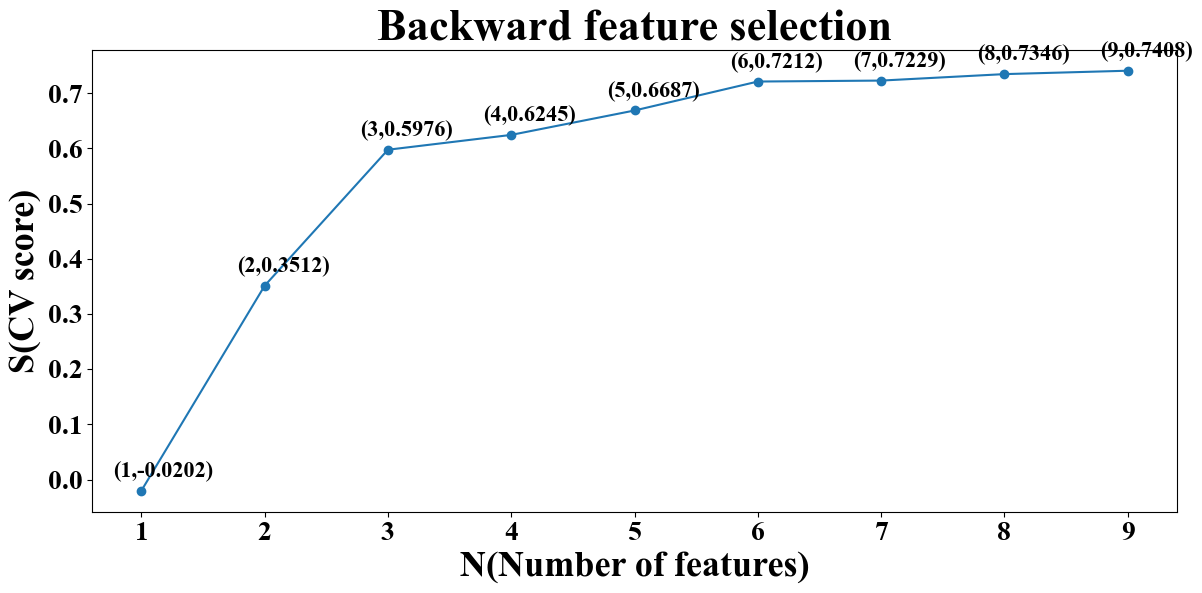

In [151]:
plt.figure(figsize=[14, 6])
plt.plot(range(1, 10, 1), score, marker='o')
plt.xlabel('N(Number of features)',fontproperties={'family':'Times New Roman'  #'serif', 
#         ,'style':'italic'
        ,'weight':'bold'  # 'normal' 
#         ,'color':'red'
        ,'size':26
       })
plt.ylabel('S(CV score)',fontproperties={'family':'Times New Roman'  #'serif', 
#         ,'style':'italic'
        ,'weight':'bold'  # 'normal' 
#         ,'color':'red'
        ,'size':26
       })
for xy in zip(range(1, 10, 1), score):
    plt.annotate("(%s,%.4f)" % xy, xy=xy, xytext=(-20, 10),textcoords='offset points',weight='bold',fontproperties={'family':'Times New Roman'  #'serif', 
#         ,'style':'italic'
        ,'weight':'bold'  # 'normal' 
#         ,'color':'red'
        ,'size':16
       })
plt.title('Backward feature selection',fontproperties={'family':'Times New Roman'  #'serif', 
#         ,'style':'italic'
        ,'weight':'bold'  # 'normal' 
#         ,'color':'red'
        ,'size':32
       })
plt.xticks(fontproperties={'family':'Times New Roman'  #'serif', 
#         ,'style':'italic'
        ,'weight':'bold'  # 'normal' 
#         ,'color':'red'
        ,'size':20
       })
plt.yticks(fontproperties={'family':'Times New Roman'  #'serif', 
#         ,'style':'italic'
        ,'weight':'bold'  # 'normal' 
#         ,'color':'red'
        ,'size':20
       })
plt.show()

## data

In [152]:
train_data=pd.read_excel(r'D:\creep rupture\TR+TS\GAN200train.xlsx')
test_data=pd.read_excel(r'D:\creep rupture\TR+TS\GAN200test.xlsx')
x = train_data.drop(columns=[ 'Time to Rupture(h)'])
y = train_data['Time to Rupture(h)']
x_test = test_data.drop(columns=['Time to Rupture(h)'])
y_test = test_data['Time to Rupture(h)']

## rf

In [153]:
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score

rf = RandomForestRegressor()

# 进行交叉验证
scores = cross_val_score(rf, x, y, cv=10)
print("交叉验证得分: {}".format(scores))
print("平均交叉验证得分: {:.2f}".format(scores.mean()))
print("{:.2f}% (+/- {:.2f}%)".format(scores.mean() * 100, scores.std() * 100))

# 在整个训练集上拟合模型
rf.fit(x, y)

# 在测试集上进行预测
y_pred = rf.predict(x_test)

交叉验证得分: [0.52954087 0.73885967 0.7890868  0.81858652 0.69283303 0.74226832
 0.83531185 0.68389511 0.74036196 0.8024731 ]
平均交叉验证得分: 0.74
73.73% (+/- 8.44%)


## SVM

In [154]:
from sklearn.svm import SVR
from sklearn.model_selection import cross_val_score

svr = SVR()
scores = cross_val_score(svr, x, y, cv=10, scoring='r2')
print("交叉验证得分:", scores)
print("平均交叉验证得分: {:.2f}".format(scores.mean()))

# 在整个训练集上拟合模型
svr.fit(x, y)

# 在测试集上进行预测
y_pred = svr.predict(x_test)

交叉验证得分: [0.59592064 0.51426436 0.64764084 0.56522351 0.37093397 0.4528438
 0.54610795 0.52724536 0.54662975 0.57590032]
平均交叉验证得分: 0.53


## DT

In [155]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import cross_val_score

dt = DecisionTreeRegressor()
scores = cross_val_score(dt, x, y, cv=10, scoring='r2')
print("交叉验证得分:", scores)
print("平均交叉验证得分: {:.2f}".format(scores.mean()))

# 在整个训练集上拟合模型
dt.fit(x, y)

# 在测试集上进行预测
y_pred = dt.predict(x_test)

交叉验证得分: [-0.10957779  0.91524336  0.74628069  0.78237083  0.68554226  0.73479186
  0.92747309  0.17557208 -0.05783691  0.40894107]
平均交叉验证得分: 0.52


## ANN

In [156]:
from tensorflow import keras
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense,Activation,Dropout
import pandas as pd
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt


Epoch 1/500
9/9 - 1s - loss: 0.0613 - mean_squared_error: 0.0613 - val_loss: 0.0432 - val_mean_squared_error: 0.0432 - 1s/epoch - 152ms/step
Epoch 2/500
9/9 - 0s - loss: 0.0400 - mean_squared_error: 0.0400 - val_loss: 0.0396 - val_mean_squared_error: 0.0396 - 263ms/epoch - 29ms/step
Epoch 3/500
9/9 - 0s - loss: 0.0353 - mean_squared_error: 0.0353 - val_loss: 0.0334 - val_mean_squared_error: 0.0334 - 207ms/epoch - 23ms/step
Epoch 4/500
9/9 - 0s - loss: 0.0345 - mean_squared_error: 0.0345 - val_loss: 0.0359 - val_mean_squared_error: 0.0359 - 261ms/epoch - 29ms/step
Epoch 5/500
9/9 - 0s - loss: 0.0311 - mean_squared_error: 0.0311 - val_loss: 0.0384 - val_mean_squared_error: 0.0384 - 187ms/epoch - 21ms/step
Epoch 6/500
9/9 - 0s - loss: 0.0299 - mean_squared_error: 0.0299 - val_loss: 0.0318 - val_mean_squared_error: 0.0318 - 381ms/epoch - 42ms/step
Epoch 7/500
9/9 - 0s - loss: 0.0287 - mean_squared_error: 0.0287 - val_loss: 0.0284 - val_mean_squared_error: 0.0284 - 118ms/epoch - 13ms/step
E

Epoch 58/500
9/9 - 0s - loss: 0.0159 - mean_squared_error: 0.0159 - val_loss: 0.0153 - val_mean_squared_error: 0.0153 - 106ms/epoch - 12ms/step
Epoch 59/500
9/9 - 0s - loss: 0.0159 - mean_squared_error: 0.0159 - val_loss: 0.0178 - val_mean_squared_error: 0.0178 - 186ms/epoch - 21ms/step
Epoch 60/500
9/9 - 0s - loss: 0.0153 - mean_squared_error: 0.0153 - val_loss: 0.0171 - val_mean_squared_error: 0.0171 - 163ms/epoch - 18ms/step
Epoch 61/500
9/9 - 0s - loss: 0.0152 - mean_squared_error: 0.0152 - val_loss: 0.0147 - val_mean_squared_error: 0.0147 - 171ms/epoch - 19ms/step
Epoch 62/500
9/9 - 0s - loss: 0.0142 - mean_squared_error: 0.0142 - val_loss: 0.0148 - val_mean_squared_error: 0.0148 - 281ms/epoch - 31ms/step
Epoch 63/500
9/9 - 0s - loss: 0.0150 - mean_squared_error: 0.0150 - val_loss: 0.0151 - val_mean_squared_error: 0.0151 - 245ms/epoch - 27ms/step
Epoch 64/500
9/9 - 0s - loss: 0.0142 - mean_squared_error: 0.0142 - val_loss: 0.0146 - val_mean_squared_error: 0.0146 - 221ms/epoch - 25

Epoch 115/500
9/9 - 0s - loss: 0.0111 - mean_squared_error: 0.0111 - val_loss: 0.0106 - val_mean_squared_error: 0.0106 - 152ms/epoch - 17ms/step
Epoch 116/500
9/9 - 0s - loss: 0.0103 - mean_squared_error: 0.0103 - val_loss: 0.0121 - val_mean_squared_error: 0.0121 - 262ms/epoch - 29ms/step
Epoch 117/500
9/9 - 0s - loss: 0.0098 - mean_squared_error: 0.0098 - val_loss: 0.0108 - val_mean_squared_error: 0.0108 - 382ms/epoch - 42ms/step
Epoch 118/500
9/9 - 0s - loss: 0.0109 - mean_squared_error: 0.0109 - val_loss: 0.0109 - val_mean_squared_error: 0.0109 - 309ms/epoch - 34ms/step
Epoch 119/500
9/9 - 0s - loss: 0.0095 - mean_squared_error: 0.0095 - val_loss: 0.0110 - val_mean_squared_error: 0.0110 - 187ms/epoch - 21ms/step
Epoch 120/500
9/9 - 0s - loss: 0.0091 - mean_squared_error: 0.0091 - val_loss: 0.0108 - val_mean_squared_error: 0.0108 - 182ms/epoch - 20ms/step
Epoch 121/500
9/9 - 0s - loss: 0.0101 - mean_squared_error: 0.0101 - val_loss: 0.0129 - val_mean_squared_error: 0.0129 - 213ms/epo

Epoch 172/500
9/9 - 0s - loss: 0.0081 - mean_squared_error: 0.0081 - val_loss: 0.0079 - val_mean_squared_error: 0.0079 - 218ms/epoch - 24ms/step
Epoch 173/500
9/9 - 0s - loss: 0.0086 - mean_squared_error: 0.0086 - val_loss: 0.0097 - val_mean_squared_error: 0.0097 - 284ms/epoch - 32ms/step
Epoch 174/500
9/9 - 0s - loss: 0.0086 - mean_squared_error: 0.0086 - val_loss: 0.0093 - val_mean_squared_error: 0.0093 - 191ms/epoch - 21ms/step
Epoch 175/500
9/9 - 0s - loss: 0.0086 - mean_squared_error: 0.0086 - val_loss: 0.0078 - val_mean_squared_error: 0.0078 - 231ms/epoch - 26ms/step
Epoch 176/500
9/9 - 0s - loss: 0.0080 - mean_squared_error: 0.0080 - val_loss: 0.0074 - val_mean_squared_error: 0.0074 - 267ms/epoch - 30ms/step
Epoch 177/500
9/9 - 0s - loss: 0.0080 - mean_squared_error: 0.0080 - val_loss: 0.0086 - val_mean_squared_error: 0.0086 - 332ms/epoch - 37ms/step
Epoch 178/500
9/9 - 0s - loss: 0.0077 - mean_squared_error: 0.0077 - val_loss: 0.0105 - val_mean_squared_error: 0.0105 - 233ms/epo

Epoch 229/500
9/9 - 0s - loss: 0.0067 - mean_squared_error: 0.0067 - val_loss: 0.0074 - val_mean_squared_error: 0.0074 - 256ms/epoch - 28ms/step
Epoch 230/500
9/9 - 0s - loss: 0.0071 - mean_squared_error: 0.0071 - val_loss: 0.0074 - val_mean_squared_error: 0.0074 - 218ms/epoch - 24ms/step
Epoch 231/500
9/9 - 0s - loss: 0.0065 - mean_squared_error: 0.0065 - val_loss: 0.0095 - val_mean_squared_error: 0.0095 - 135ms/epoch - 15ms/step
Epoch 232/500
9/9 - 0s - loss: 0.0063 - mean_squared_error: 0.0063 - val_loss: 0.0070 - val_mean_squared_error: 0.0070 - 246ms/epoch - 27ms/step
Epoch 233/500
9/9 - 0s - loss: 0.0063 - mean_squared_error: 0.0063 - val_loss: 0.0069 - val_mean_squared_error: 0.0069 - 176ms/epoch - 20ms/step
Epoch 234/500
9/9 - 0s - loss: 0.0066 - mean_squared_error: 0.0066 - val_loss: 0.0079 - val_mean_squared_error: 0.0079 - 233ms/epoch - 26ms/step
Epoch 235/500
9/9 - 0s - loss: 0.0062 - mean_squared_error: 0.0062 - val_loss: 0.0079 - val_mean_squared_error: 0.0079 - 263ms/epo

Epoch 286/500
9/9 - 0s - loss: 0.0046 - mean_squared_error: 0.0046 - val_loss: 0.0060 - val_mean_squared_error: 0.0060 - 187ms/epoch - 21ms/step
Epoch 287/500
9/9 - 0s - loss: 0.0059 - mean_squared_error: 0.0059 - val_loss: 0.0064 - val_mean_squared_error: 0.0064 - 217ms/epoch - 24ms/step
Epoch 288/500
9/9 - 0s - loss: 0.0066 - mean_squared_error: 0.0066 - val_loss: 0.0098 - val_mean_squared_error: 0.0098 - 201ms/epoch - 22ms/step
Epoch 289/500
9/9 - 0s - loss: 0.0064 - mean_squared_error: 0.0064 - val_loss: 0.0074 - val_mean_squared_error: 0.0074 - 222ms/epoch - 25ms/step
Epoch 290/500
9/9 - 0s - loss: 0.0060 - mean_squared_error: 0.0060 - val_loss: 0.0062 - val_mean_squared_error: 0.0062 - 231ms/epoch - 26ms/step
Epoch 291/500
9/9 - 0s - loss: 0.0059 - mean_squared_error: 0.0059 - val_loss: 0.0080 - val_mean_squared_error: 0.0080 - 279ms/epoch - 31ms/step
Epoch 292/500
9/9 - 0s - loss: 0.0054 - mean_squared_error: 0.0054 - val_loss: 0.0074 - val_mean_squared_error: 0.0074 - 245ms/epo

Epoch 343/500
9/9 - 0s - loss: 0.0070 - mean_squared_error: 0.0070 - val_loss: 0.0057 - val_mean_squared_error: 0.0057 - 237ms/epoch - 26ms/step
Epoch 344/500
9/9 - 0s - loss: 0.0053 - mean_squared_error: 0.0053 - val_loss: 0.0058 - val_mean_squared_error: 0.0058 - 224ms/epoch - 25ms/step
Epoch 345/500
9/9 - 0s - loss: 0.0054 - mean_squared_error: 0.0054 - val_loss: 0.0055 - val_mean_squared_error: 0.0055 - 224ms/epoch - 25ms/step
Epoch 346/500
9/9 - 0s - loss: 0.0059 - mean_squared_error: 0.0059 - val_loss: 0.0051 - val_mean_squared_error: 0.0051 - 280ms/epoch - 31ms/step
Epoch 347/500
9/9 - 0s - loss: 0.0047 - mean_squared_error: 0.0047 - val_loss: 0.0057 - val_mean_squared_error: 0.0057 - 222ms/epoch - 25ms/step
Epoch 348/500
9/9 - 0s - loss: 0.0047 - mean_squared_error: 0.0047 - val_loss: 0.0051 - val_mean_squared_error: 0.0051 - 231ms/epoch - 26ms/step
Epoch 349/500
9/9 - 0s - loss: 0.0058 - mean_squared_error: 0.0058 - val_loss: 0.0055 - val_mean_squared_error: 0.0055 - 163ms/epo

Epoch 400/500
9/9 - 0s - loss: 0.0054 - mean_squared_error: 0.0054 - val_loss: 0.0070 - val_mean_squared_error: 0.0070 - 157ms/epoch - 17ms/step
Epoch 401/500
9/9 - 0s - loss: 0.0049 - mean_squared_error: 0.0049 - val_loss: 0.0047 - val_mean_squared_error: 0.0047 - 219ms/epoch - 24ms/step
Epoch 402/500
9/9 - 0s - loss: 0.0047 - mean_squared_error: 0.0047 - val_loss: 0.0044 - val_mean_squared_error: 0.0044 - 266ms/epoch - 30ms/step
Epoch 403/500
9/9 - 0s - loss: 0.0050 - mean_squared_error: 0.0050 - val_loss: 0.0067 - val_mean_squared_error: 0.0067 - 201ms/epoch - 22ms/step
Epoch 404/500
9/9 - 0s - loss: 0.0056 - mean_squared_error: 0.0056 - val_loss: 0.0057 - val_mean_squared_error: 0.0057 - 139ms/epoch - 15ms/step
Epoch 405/500
9/9 - 0s - loss: 0.0046 - mean_squared_error: 0.0046 - val_loss: 0.0066 - val_mean_squared_error: 0.0066 - 200ms/epoch - 22ms/step
Epoch 406/500
9/9 - 0s - loss: 0.0043 - mean_squared_error: 0.0043 - val_loss: 0.0067 - val_mean_squared_error: 0.0067 - 267ms/epo

Epoch 457/500
9/9 - 0s - loss: 0.0054 - mean_squared_error: 0.0054 - val_loss: 0.0075 - val_mean_squared_error: 0.0075 - 242ms/epoch - 27ms/step
Epoch 458/500
9/9 - 0s - loss: 0.0047 - mean_squared_error: 0.0047 - val_loss: 0.0040 - val_mean_squared_error: 0.0040 - 232ms/epoch - 26ms/step
Epoch 459/500
9/9 - 0s - loss: 0.0041 - mean_squared_error: 0.0041 - val_loss: 0.0053 - val_mean_squared_error: 0.0053 - 211ms/epoch - 23ms/step
Epoch 460/500
9/9 - 0s - loss: 0.0051 - mean_squared_error: 0.0051 - val_loss: 0.0046 - val_mean_squared_error: 0.0046 - 145ms/epoch - 16ms/step
Epoch 461/500
9/9 - 0s - loss: 0.0044 - mean_squared_error: 0.0044 - val_loss: 0.0060 - val_mean_squared_error: 0.0060 - 259ms/epoch - 29ms/step
Epoch 462/500
9/9 - 0s - loss: 0.0043 - mean_squared_error: 0.0043 - val_loss: 0.0066 - val_mean_squared_error: 0.0066 - 230ms/epoch - 26ms/step
Epoch 463/500
9/9 - 0s - loss: 0.0044 - mean_squared_error: 0.0044 - val_loss: 0.0041 - val_mean_squared_error: 0.0041 - 230ms/epo

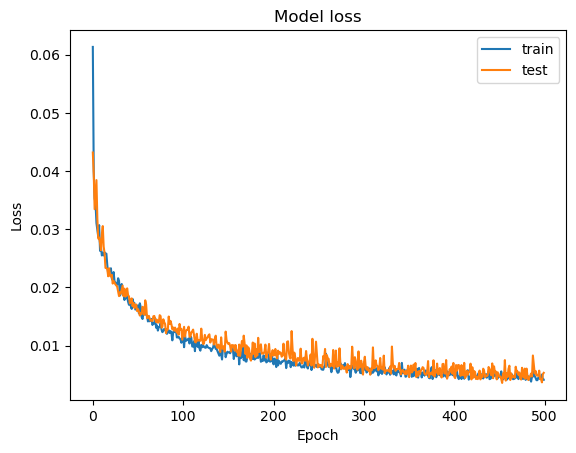

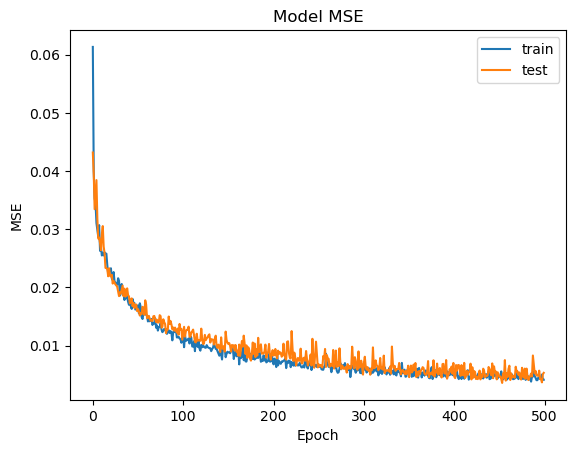

In [157]:
model = Sequential()  # 初始化
input = x.shape[1]
# 隐藏层128
model.add(Dense(128, input_shape=(input,)))  
model.add(Activation('relu'))
# Dropout层用于防止过拟合
model.add(Dropout(0.5))
# 隐藏层128
model.add(Dense(128))
model.add(Activation('relu'))

model.add(Dense(1))
model.add(Activation('linear'))  # 使用线性激活函数

# 使用高效的ADAM优化算法
rmsprop = tf.keras.optimizers.RMSprop(learning_rate=0.001, rho=0.9, epsilon=1e-08)
model.compile(loss='mean_squared_error', optimizer=rmsprop, metrics=['mean_squared_error'])

early_stopping = EarlyStopping(monitor='val_loss', patience=500, verbose=2)

# 训练
history = model.fit(x, y, epochs=500, batch_size=64, shuffle=False, verbose=2,
                   validation_data=(x_test, y_test), callbacks=[early_stopping])

# loss曲线
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.show()

# mse曲线
plt.plot(history.history['mean_squared_error'], label='train')
plt.plot(history.history['val_mean_squared_error'], label='test')
plt.title('Model MSE')
plt.ylabel('MSE')
plt.xlabel('Epoch')
plt.legend()
plt.show()

Epoch 1/500
5/5 - 2s - loss: 1.0694 - mean_squared_error: 1.0694 - val_loss: 0.0599 - val_mean_squared_error: 0.0599 - 2s/epoch - 395ms/step
Epoch 2/500
5/5 - 0s - loss: 0.6461 - mean_squared_error: 0.6461 - val_loss: 0.1259 - val_mean_squared_error: 0.1259 - 204ms/epoch - 41ms/step
Epoch 3/500
5/5 - 0s - loss: 0.4856 - mean_squared_error: 0.4856 - val_loss: 0.1298 - val_mean_squared_error: 0.1298 - 281ms/epoch - 56ms/step
Epoch 4/500
5/5 - 0s - loss: 0.4355 - mean_squared_error: 0.4355 - val_loss: 0.1304 - val_mean_squared_error: 0.1304 - 267ms/epoch - 53ms/step
Epoch 5/500
5/5 - 0s - loss: 0.3245 - mean_squared_error: 0.3245 - val_loss: 0.0955 - val_mean_squared_error: 0.0955 - 262ms/epoch - 52ms/step
Epoch 6/500
5/5 - 0s - loss: 0.3458 - mean_squared_error: 0.3458 - val_loss: 0.1217 - val_mean_squared_error: 0.1217 - 226ms/epoch - 45ms/step
Epoch 7/500
5/5 - 0s - loss: 0.2967 - mean_squared_error: 0.2967 - val_loss: 0.1074 - val_mean_squared_error: 0.1074 - 242ms/epoch - 48ms/step
E

Epoch 58/500
5/5 - 0s - loss: 0.0523 - mean_squared_error: 0.0523 - val_loss: 0.0399 - val_mean_squared_error: 0.0399 - 197ms/epoch - 39ms/step
Epoch 59/500
5/5 - 0s - loss: 0.0476 - mean_squared_error: 0.0476 - val_loss: 0.0253 - val_mean_squared_error: 0.0253 - 251ms/epoch - 50ms/step
Epoch 60/500
5/5 - 0s - loss: 0.0491 - mean_squared_error: 0.0491 - val_loss: 0.0240 - val_mean_squared_error: 0.0240 - 243ms/epoch - 49ms/step
Epoch 61/500
5/5 - 0s - loss: 0.0446 - mean_squared_error: 0.0446 - val_loss: 0.0584 - val_mean_squared_error: 0.0584 - 257ms/epoch - 51ms/step
Epoch 62/500
5/5 - 0s - loss: 0.0517 - mean_squared_error: 0.0517 - val_loss: 0.0227 - val_mean_squared_error: 0.0227 - 256ms/epoch - 51ms/step
Epoch 63/500
5/5 - 0s - loss: 0.0488 - mean_squared_error: 0.0488 - val_loss: 0.0318 - val_mean_squared_error: 0.0318 - 194ms/epoch - 39ms/step
Epoch 64/500
5/5 - 0s - loss: 0.0410 - mean_squared_error: 0.0410 - val_loss: 0.0320 - val_mean_squared_error: 0.0320 - 235ms/epoch - 47

Epoch 115/500
5/5 - 0s - loss: 0.0238 - mean_squared_error: 0.0238 - val_loss: 0.0304 - val_mean_squared_error: 0.0304 - 248ms/epoch - 50ms/step
Epoch 116/500
5/5 - 0s - loss: 0.0271 - mean_squared_error: 0.0271 - val_loss: 0.0221 - val_mean_squared_error: 0.0221 - 291ms/epoch - 58ms/step
Epoch 117/500
5/5 - 0s - loss: 0.0235 - mean_squared_error: 0.0235 - val_loss: 0.0223 - val_mean_squared_error: 0.0223 - 277ms/epoch - 55ms/step
Epoch 118/500
5/5 - 0s - loss: 0.0312 - mean_squared_error: 0.0312 - val_loss: 0.0166 - val_mean_squared_error: 0.0166 - 294ms/epoch - 59ms/step
Epoch 119/500
5/5 - 0s - loss: 0.0233 - mean_squared_error: 0.0233 - val_loss: 0.0171 - val_mean_squared_error: 0.0171 - 261ms/epoch - 52ms/step
Epoch 120/500
5/5 - 0s - loss: 0.0222 - mean_squared_error: 0.0222 - val_loss: 0.0211 - val_mean_squared_error: 0.0211 - 268ms/epoch - 54ms/step
Epoch 121/500
5/5 - 0s - loss: 0.0249 - mean_squared_error: 0.0249 - val_loss: 0.0398 - val_mean_squared_error: 0.0398 - 219ms/epo

Epoch 172/500
5/5 - 0s - loss: 0.0166 - mean_squared_error: 0.0166 - val_loss: 0.0140 - val_mean_squared_error: 0.0140 - 135ms/epoch - 27ms/step
Epoch 173/500
5/5 - 0s - loss: 0.0165 - mean_squared_error: 0.0165 - val_loss: 0.0165 - val_mean_squared_error: 0.0165 - 229ms/epoch - 46ms/step
Epoch 174/500
5/5 - 0s - loss: 0.0188 - mean_squared_error: 0.0188 - val_loss: 0.0165 - val_mean_squared_error: 0.0165 - 368ms/epoch - 74ms/step
Epoch 175/500
5/5 - 0s - loss: 0.0180 - mean_squared_error: 0.0180 - val_loss: 0.0139 - val_mean_squared_error: 0.0139 - 176ms/epoch - 35ms/step
Epoch 176/500
5/5 - 0s - loss: 0.0181 - mean_squared_error: 0.0181 - val_loss: 0.0161 - val_mean_squared_error: 0.0161 - 161ms/epoch - 32ms/step
Epoch 177/500
5/5 - 0s - loss: 0.0166 - mean_squared_error: 0.0166 - val_loss: 0.0192 - val_mean_squared_error: 0.0192 - 164ms/epoch - 33ms/step
Epoch 178/500
5/5 - 0s - loss: 0.0196 - mean_squared_error: 0.0196 - val_loss: 0.0162 - val_mean_squared_error: 0.0162 - 163ms/epo

Epoch 229/500
5/5 - 0s - loss: 0.0167 - mean_squared_error: 0.0167 - val_loss: 0.0155 - val_mean_squared_error: 0.0155 - 229ms/epoch - 46ms/step
Epoch 230/500
5/5 - 0s - loss: 0.0152 - mean_squared_error: 0.0152 - val_loss: 0.0143 - val_mean_squared_error: 0.0143 - 204ms/epoch - 41ms/step
Epoch 231/500
5/5 - 0s - loss: 0.0132 - mean_squared_error: 0.0132 - val_loss: 0.0111 - val_mean_squared_error: 0.0111 - 323ms/epoch - 65ms/step
Epoch 232/500
5/5 - 0s - loss: 0.0131 - mean_squared_error: 0.0131 - val_loss: 0.0141 - val_mean_squared_error: 0.0141 - 284ms/epoch - 57ms/step
Epoch 233/500
5/5 - 0s - loss: 0.0130 - mean_squared_error: 0.0130 - val_loss: 0.0137 - val_mean_squared_error: 0.0137 - 260ms/epoch - 52ms/step
Epoch 234/500
5/5 - 0s - loss: 0.0132 - mean_squared_error: 0.0132 - val_loss: 0.0148 - val_mean_squared_error: 0.0148 - 247ms/epoch - 49ms/step
Epoch 235/500
5/5 - 0s - loss: 0.0163 - mean_squared_error: 0.0163 - val_loss: 0.0148 - val_mean_squared_error: 0.0148 - 269ms/epo

Epoch 286/500
5/5 - 0s - loss: 0.0104 - mean_squared_error: 0.0104 - val_loss: 0.0230 - val_mean_squared_error: 0.0230 - 237ms/epoch - 47ms/step
Epoch 287/500
5/5 - 0s - loss: 0.0121 - mean_squared_error: 0.0121 - val_loss: 0.0111 - val_mean_squared_error: 0.0111 - 255ms/epoch - 51ms/step
Epoch 288/500
5/5 - 0s - loss: 0.0119 - mean_squared_error: 0.0119 - val_loss: 0.0230 - val_mean_squared_error: 0.0230 - 272ms/epoch - 54ms/step
Epoch 289/500
5/5 - 0s - loss: 0.0129 - mean_squared_error: 0.0129 - val_loss: 0.0147 - val_mean_squared_error: 0.0147 - 234ms/epoch - 47ms/step
Epoch 290/500
5/5 - 0s - loss: 0.0109 - mean_squared_error: 0.0109 - val_loss: 0.0153 - val_mean_squared_error: 0.0153 - 230ms/epoch - 46ms/step
Epoch 291/500
5/5 - 0s - loss: 0.0124 - mean_squared_error: 0.0124 - val_loss: 0.0126 - val_mean_squared_error: 0.0126 - 269ms/epoch - 54ms/step
Epoch 292/500
5/5 - 0s - loss: 0.0137 - mean_squared_error: 0.0137 - val_loss: 0.0144 - val_mean_squared_error: 0.0144 - 256ms/epo

Epoch 343/500
5/5 - 0s - loss: 0.0100 - mean_squared_error: 0.0100 - val_loss: 0.0080 - val_mean_squared_error: 0.0080 - 208ms/epoch - 42ms/step
Epoch 344/500
5/5 - 0s - loss: 0.0099 - mean_squared_error: 0.0099 - val_loss: 0.0108 - val_mean_squared_error: 0.0108 - 232ms/epoch - 46ms/step
Epoch 345/500
5/5 - 0s - loss: 0.0107 - mean_squared_error: 0.0107 - val_loss: 0.0103 - val_mean_squared_error: 0.0103 - 174ms/epoch - 35ms/step
Epoch 346/500
5/5 - 0s - loss: 0.0088 - mean_squared_error: 0.0088 - val_loss: 0.0113 - val_mean_squared_error: 0.0113 - 203ms/epoch - 41ms/step
Epoch 347/500
5/5 - 0s - loss: 0.0097 - mean_squared_error: 0.0097 - val_loss: 0.0143 - val_mean_squared_error: 0.0143 - 235ms/epoch - 47ms/step
Epoch 348/500
5/5 - 0s - loss: 0.0130 - mean_squared_error: 0.0130 - val_loss: 0.0121 - val_mean_squared_error: 0.0121 - 271ms/epoch - 54ms/step
Epoch 349/500
5/5 - 0s - loss: 0.0102 - mean_squared_error: 0.0102 - val_loss: 0.0090 - val_mean_squared_error: 0.0090 - 208ms/epo

Epoch 400/500
5/5 - 0s - loss: 0.0087 - mean_squared_error: 0.0087 - val_loss: 0.0108 - val_mean_squared_error: 0.0108 - 227ms/epoch - 45ms/step
Epoch 401/500
5/5 - 0s - loss: 0.0083 - mean_squared_error: 0.0083 - val_loss: 0.0124 - val_mean_squared_error: 0.0124 - 258ms/epoch - 52ms/step
Epoch 402/500
5/5 - 0s - loss: 0.0117 - mean_squared_error: 0.0117 - val_loss: 0.0100 - val_mean_squared_error: 0.0100 - 255ms/epoch - 51ms/step
Epoch 403/500
5/5 - 0s - loss: 0.0104 - mean_squared_error: 0.0104 - val_loss: 0.0082 - val_mean_squared_error: 0.0082 - 277ms/epoch - 55ms/step
Epoch 404/500
5/5 - 0s - loss: 0.0098 - mean_squared_error: 0.0098 - val_loss: 0.0081 - val_mean_squared_error: 0.0081 - 148ms/epoch - 30ms/step
Epoch 405/500
5/5 - 0s - loss: 0.0088 - mean_squared_error: 0.0088 - val_loss: 0.0078 - val_mean_squared_error: 0.0078 - 238ms/epoch - 48ms/step
Epoch 406/500
5/5 - 0s - loss: 0.0084 - mean_squared_error: 0.0084 - val_loss: 0.0098 - val_mean_squared_error: 0.0098 - 209ms/epo

Epoch 457/500
5/5 - 0s - loss: 0.0090 - mean_squared_error: 0.0090 - val_loss: 0.0067 - val_mean_squared_error: 0.0067 - 258ms/epoch - 52ms/step
Epoch 458/500
5/5 - 0s - loss: 0.0088 - mean_squared_error: 0.0088 - val_loss: 0.0070 - val_mean_squared_error: 0.0070 - 261ms/epoch - 52ms/step
Epoch 459/500
5/5 - 0s - loss: 0.0092 - mean_squared_error: 0.0092 - val_loss: 0.0065 - val_mean_squared_error: 0.0065 - 245ms/epoch - 49ms/step
Epoch 460/500
5/5 - 0s - loss: 0.0093 - mean_squared_error: 0.0093 - val_loss: 0.0159 - val_mean_squared_error: 0.0159 - 226ms/epoch - 45ms/step
Epoch 461/500
5/5 - 0s - loss: 0.0099 - mean_squared_error: 0.0099 - val_loss: 0.0067 - val_mean_squared_error: 0.0067 - 221ms/epoch - 44ms/step
Epoch 462/500
5/5 - 0s - loss: 0.0082 - mean_squared_error: 0.0082 - val_loss: 0.0066 - val_mean_squared_error: 0.0066 - 160ms/epoch - 32ms/step
Epoch 463/500
5/5 - 0s - loss: 0.0080 - mean_squared_error: 0.0080 - val_loss: 0.0065 - val_mean_squared_error: 0.0065 - 216ms/epo

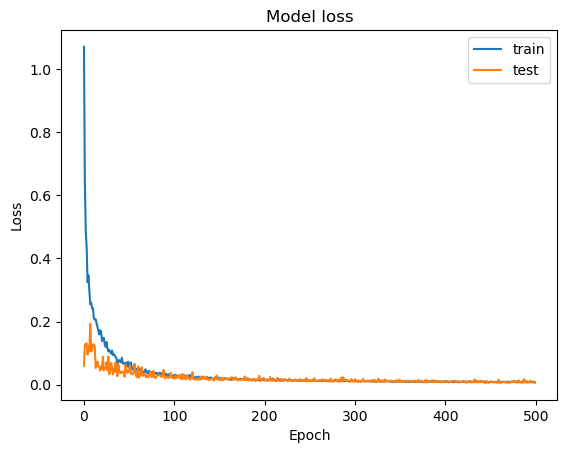

2/2 [==============================] - 0s 18ms/step
MSE: 0.01
R2: 0.77
Epoch 1/500
5/5 - 2s - loss: 1.8059 - mean_squared_error: 1.8059 - val_loss: 0.0745 - val_mean_squared_error: 0.0745 - 2s/epoch - 382ms/step
Epoch 2/500
5/5 - 0s - loss: 0.8331 - mean_squared_error: 0.8331 - val_loss: 0.2207 - val_mean_squared_error: 0.2207 - 252ms/epoch - 50ms/step
Epoch 3/500
5/5 - 0s - loss: 0.6223 - mean_squared_error: 0.6223 - val_loss: 0.2384 - val_mean_squared_error: 0.2384 - 288ms/epoch - 58ms/step
Epoch 4/500
5/5 - 0s - loss: 0.5039 - mean_squared_error: 0.5039 - val_loss: 0.1897 - val_mean_squared_error: 0.1897 - 305ms/epoch - 61ms/step
Epoch 5/500
5/5 - 0s - loss: 0.4610 - mean_squared_error: 0.4610 - val_loss: 0.1541 - val_mean_squared_error: 0.1541 - 284ms/epoch - 57ms/step
Epoch 6/500
5/5 - 0s - loss: 0.3872 - mean_squared_error: 0.3872 - val_loss: 0.1434 - val_mean_squared_error: 0.1434 - 267ms/epoch - 53ms/step
Epoch 7/500
5/5 - 0s - loss: 0.3503 - mean_squared_error: 0.3503 - val_lo

Epoch 58/500
5/5 - 0s - loss: 0.0484 - mean_squared_error: 0.0484 - val_loss: 0.0272 - val_mean_squared_error: 0.0272 - 257ms/epoch - 51ms/step
Epoch 59/500
5/5 - 0s - loss: 0.0565 - mean_squared_error: 0.0565 - val_loss: 0.0417 - val_mean_squared_error: 0.0417 - 286ms/epoch - 57ms/step
Epoch 60/500
5/5 - 0s - loss: 0.0482 - mean_squared_error: 0.0482 - val_loss: 0.0232 - val_mean_squared_error: 0.0232 - 242ms/epoch - 48ms/step
Epoch 61/500
5/5 - 0s - loss: 0.0499 - mean_squared_error: 0.0499 - val_loss: 0.0234 - val_mean_squared_error: 0.0234 - 255ms/epoch - 51ms/step
Epoch 62/500
5/5 - 0s - loss: 0.0416 - mean_squared_error: 0.0416 - val_loss: 0.0251 - val_mean_squared_error: 0.0251 - 209ms/epoch - 42ms/step
Epoch 63/500
5/5 - 0s - loss: 0.0480 - mean_squared_error: 0.0480 - val_loss: 0.0260 - val_mean_squared_error: 0.0260 - 240ms/epoch - 48ms/step
Epoch 64/500
5/5 - 0s - loss: 0.0451 - mean_squared_error: 0.0451 - val_loss: 0.0351 - val_mean_squared_error: 0.0351 - 241ms/epoch - 48

Epoch 115/500
5/5 - 0s - loss: 0.0273 - mean_squared_error: 0.0273 - val_loss: 0.0201 - val_mean_squared_error: 0.0201 - 226ms/epoch - 45ms/step
Epoch 116/500
5/5 - 0s - loss: 0.0262 - mean_squared_error: 0.0262 - val_loss: 0.0170 - val_mean_squared_error: 0.0170 - 174ms/epoch - 35ms/step
Epoch 117/500
5/5 - 0s - loss: 0.0291 - mean_squared_error: 0.0291 - val_loss: 0.0158 - val_mean_squared_error: 0.0158 - 242ms/epoch - 48ms/step
Epoch 118/500
5/5 - 0s - loss: 0.0209 - mean_squared_error: 0.0209 - val_loss: 0.0174 - val_mean_squared_error: 0.0174 - 208ms/epoch - 42ms/step
Epoch 119/500
5/5 - 0s - loss: 0.0215 - mean_squared_error: 0.0215 - val_loss: 0.0240 - val_mean_squared_error: 0.0240 - 239ms/epoch - 48ms/step
Epoch 120/500
5/5 - 0s - loss: 0.0254 - mean_squared_error: 0.0254 - val_loss: 0.0153 - val_mean_squared_error: 0.0153 - 208ms/epoch - 42ms/step
Epoch 121/500
5/5 - 0s - loss: 0.0218 - mean_squared_error: 0.0218 - val_loss: 0.0163 - val_mean_squared_error: 0.0163 - 218ms/epo

Epoch 172/500
5/5 - 0s - loss: 0.0203 - mean_squared_error: 0.0203 - val_loss: 0.0118 - val_mean_squared_error: 0.0118 - 191ms/epoch - 38ms/step
Epoch 173/500
5/5 - 0s - loss: 0.0154 - mean_squared_error: 0.0154 - val_loss: 0.0146 - val_mean_squared_error: 0.0146 - 254ms/epoch - 51ms/step
Epoch 174/500
5/5 - 0s - loss: 0.0163 - mean_squared_error: 0.0163 - val_loss: 0.0131 - val_mean_squared_error: 0.0131 - 228ms/epoch - 46ms/step
Epoch 175/500
5/5 - 0s - loss: 0.0178 - mean_squared_error: 0.0178 - val_loss: 0.0139 - val_mean_squared_error: 0.0139 - 236ms/epoch - 47ms/step
Epoch 176/500
5/5 - 0s - loss: 0.0174 - mean_squared_error: 0.0174 - val_loss: 0.0209 - val_mean_squared_error: 0.0209 - 254ms/epoch - 51ms/step
Epoch 177/500
5/5 - 0s - loss: 0.0172 - mean_squared_error: 0.0172 - val_loss: 0.0146 - val_mean_squared_error: 0.0146 - 241ms/epoch - 48ms/step
Epoch 178/500
5/5 - 0s - loss: 0.0156 - mean_squared_error: 0.0156 - val_loss: 0.0116 - val_mean_squared_error: 0.0116 - 231ms/epo

Epoch 229/500
5/5 - 0s - loss: 0.0123 - mean_squared_error: 0.0123 - val_loss: 0.0177 - val_mean_squared_error: 0.0177 - 207ms/epoch - 41ms/step
Epoch 230/500
5/5 - 0s - loss: 0.0141 - mean_squared_error: 0.0141 - val_loss: 0.0095 - val_mean_squared_error: 0.0095 - 235ms/epoch - 47ms/step
Epoch 231/500
5/5 - 0s - loss: 0.0121 - mean_squared_error: 0.0121 - val_loss: 0.0207 - val_mean_squared_error: 0.0207 - 253ms/epoch - 51ms/step
Epoch 232/500
5/5 - 0s - loss: 0.0140 - mean_squared_error: 0.0140 - val_loss: 0.0107 - val_mean_squared_error: 0.0107 - 293ms/epoch - 59ms/step
Epoch 233/500
5/5 - 0s - loss: 0.0127 - mean_squared_error: 0.0127 - val_loss: 0.0144 - val_mean_squared_error: 0.0144 - 240ms/epoch - 48ms/step
Epoch 234/500
5/5 - 0s - loss: 0.0144 - mean_squared_error: 0.0144 - val_loss: 0.0099 - val_mean_squared_error: 0.0099 - 226ms/epoch - 45ms/step
Epoch 235/500
5/5 - 0s - loss: 0.0119 - mean_squared_error: 0.0119 - val_loss: 0.0114 - val_mean_squared_error: 0.0114 - 247ms/epo

Epoch 286/500
5/5 - 0s - loss: 0.0122 - mean_squared_error: 0.0122 - val_loss: 0.0120 - val_mean_squared_error: 0.0120 - 227ms/epoch - 45ms/step
Epoch 287/500
5/5 - 0s - loss: 0.0115 - mean_squared_error: 0.0115 - val_loss: 0.0111 - val_mean_squared_error: 0.0111 - 225ms/epoch - 45ms/step
Epoch 288/500
5/5 - 0s - loss: 0.0124 - mean_squared_error: 0.0124 - val_loss: 0.0112 - val_mean_squared_error: 0.0112 - 215ms/epoch - 43ms/step
Epoch 289/500
5/5 - 0s - loss: 0.0109 - mean_squared_error: 0.0109 - val_loss: 0.0111 - val_mean_squared_error: 0.0111 - 137ms/epoch - 27ms/step
Epoch 290/500
5/5 - 0s - loss: 0.0104 - mean_squared_error: 0.0104 - val_loss: 0.0112 - val_mean_squared_error: 0.0112 - 233ms/epoch - 47ms/step
Epoch 291/500
5/5 - 0s - loss: 0.0111 - mean_squared_error: 0.0111 - val_loss: 0.0128 - val_mean_squared_error: 0.0128 - 221ms/epoch - 44ms/step
Epoch 292/500
5/5 - 0s - loss: 0.0120 - mean_squared_error: 0.0120 - val_loss: 0.0094 - val_mean_squared_error: 0.0094 - 205ms/epo

Epoch 343/500
5/5 - 0s - loss: 0.0097 - mean_squared_error: 0.0097 - val_loss: 0.0127 - val_mean_squared_error: 0.0127 - 184ms/epoch - 37ms/step
Epoch 344/500
5/5 - 0s - loss: 0.0113 - mean_squared_error: 0.0113 - val_loss: 0.0116 - val_mean_squared_error: 0.0116 - 306ms/epoch - 61ms/step
Epoch 345/500
5/5 - 0s - loss: 0.0122 - mean_squared_error: 0.0122 - val_loss: 0.0129 - val_mean_squared_error: 0.0129 - 249ms/epoch - 50ms/step
Epoch 346/500
5/5 - 0s - loss: 0.0106 - mean_squared_error: 0.0106 - val_loss: 0.0099 - val_mean_squared_error: 0.0099 - 235ms/epoch - 47ms/step
Epoch 347/500
5/5 - 0s - loss: 0.0083 - mean_squared_error: 0.0083 - val_loss: 0.0126 - val_mean_squared_error: 0.0126 - 267ms/epoch - 53ms/step
Epoch 348/500
5/5 - 0s - loss: 0.0096 - mean_squared_error: 0.0096 - val_loss: 0.0096 - val_mean_squared_error: 0.0096 - 236ms/epoch - 47ms/step
Epoch 349/500
5/5 - 0s - loss: 0.0104 - mean_squared_error: 0.0104 - val_loss: 0.0117 - val_mean_squared_error: 0.0117 - 273ms/epo

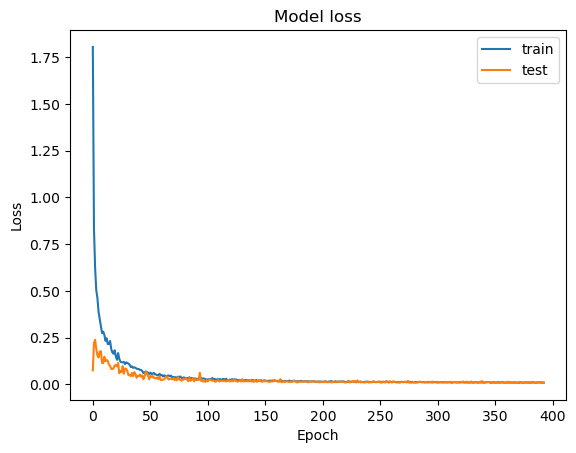

2/2 [==============================] - 0s 9ms/step
MSE: 0.01
R2: 0.68
Epoch 1/500
5/5 - 2s - loss: 1.4395 - mean_squared_error: 1.4395 - val_loss: 0.1550 - val_mean_squared_error: 0.1550 - 2s/epoch - 304ms/step
Epoch 2/500
5/5 - 0s - loss: 0.6717 - mean_squared_error: 0.6717 - val_loss: 0.3292 - val_mean_squared_error: 0.3292 - 234ms/epoch - 47ms/step
Epoch 3/500
5/5 - 0s - loss: 0.4715 - mean_squared_error: 0.4715 - val_loss: 0.3550 - val_mean_squared_error: 0.3550 - 240ms/epoch - 48ms/step
Epoch 4/500
5/5 - 0s - loss: 0.4548 - mean_squared_error: 0.4548 - val_loss: 0.2469 - val_mean_squared_error: 0.2469 - 268ms/epoch - 54ms/step
Epoch 5/500
5/5 - 0s - loss: 0.3595 - mean_squared_error: 0.3595 - val_loss: 0.1714 - val_mean_squared_error: 0.1714 - 257ms/epoch - 51ms/step
Epoch 6/500
5/5 - 0s - loss: 0.3341 - mean_squared_error: 0.3341 - val_loss: 0.1403 - val_mean_squared_error: 0.1403 - 211ms/epoch - 42ms/step
Epoch 7/500
5/5 - 0s - loss: 0.2783 - mean_squared_error: 0.2783 - val_los

Epoch 58/500
5/5 - 0s - loss: 0.0499 - mean_squared_error: 0.0499 - val_loss: 0.0361 - val_mean_squared_error: 0.0361 - 239ms/epoch - 48ms/step
Epoch 59/500
5/5 - 0s - loss: 0.0447 - mean_squared_error: 0.0447 - val_loss: 0.0274 - val_mean_squared_error: 0.0274 - 266ms/epoch - 53ms/step
Epoch 60/500
5/5 - 0s - loss: 0.0427 - mean_squared_error: 0.0427 - val_loss: 0.0206 - val_mean_squared_error: 0.0206 - 240ms/epoch - 48ms/step
Epoch 61/500
5/5 - 0s - loss: 0.0474 - mean_squared_error: 0.0474 - val_loss: 0.0293 - val_mean_squared_error: 0.0293 - 248ms/epoch - 50ms/step
Epoch 62/500
5/5 - 0s - loss: 0.0514 - mean_squared_error: 0.0514 - val_loss: 0.0379 - val_mean_squared_error: 0.0379 - 183ms/epoch - 37ms/step
Epoch 63/500
5/5 - 0s - loss: 0.0385 - mean_squared_error: 0.0385 - val_loss: 0.0289 - val_mean_squared_error: 0.0289 - 249ms/epoch - 50ms/step
Epoch 64/500
5/5 - 0s - loss: 0.0387 - mean_squared_error: 0.0387 - val_loss: 0.0297 - val_mean_squared_error: 0.0297 - 176ms/epoch - 35

Epoch 115/500
5/5 - 0s - loss: 0.0257 - mean_squared_error: 0.0257 - val_loss: 0.0245 - val_mean_squared_error: 0.0245 - 219ms/epoch - 44ms/step
Epoch 116/500
5/5 - 0s - loss: 0.0259 - mean_squared_error: 0.0259 - val_loss: 0.0191 - val_mean_squared_error: 0.0191 - 304ms/epoch - 61ms/step
Epoch 117/500
5/5 - 0s - loss: 0.0226 - mean_squared_error: 0.0226 - val_loss: 0.0242 - val_mean_squared_error: 0.0242 - 346ms/epoch - 69ms/step
Epoch 118/500
5/5 - 0s - loss: 0.0240 - mean_squared_error: 0.0240 - val_loss: 0.0155 - val_mean_squared_error: 0.0155 - 279ms/epoch - 56ms/step
Epoch 119/500
5/5 - 0s - loss: 0.0219 - mean_squared_error: 0.0219 - val_loss: 0.0152 - val_mean_squared_error: 0.0152 - 332ms/epoch - 66ms/step
Epoch 120/500
5/5 - 0s - loss: 0.0226 - mean_squared_error: 0.0226 - val_loss: 0.0204 - val_mean_squared_error: 0.0204 - 267ms/epoch - 53ms/step
Epoch 121/500
5/5 - 0s - loss: 0.0241 - mean_squared_error: 0.0241 - val_loss: 0.0278 - val_mean_squared_error: 0.0278 - 191ms/epo

Epoch 172/500
5/5 - 0s - loss: 0.0171 - mean_squared_error: 0.0171 - val_loss: 0.0134 - val_mean_squared_error: 0.0134 - 227ms/epoch - 45ms/step
Epoch 173/500
5/5 - 0s - loss: 0.0168 - mean_squared_error: 0.0168 - val_loss: 0.0285 - val_mean_squared_error: 0.0285 - 295ms/epoch - 59ms/step
Epoch 174/500
5/5 - 0s - loss: 0.0191 - mean_squared_error: 0.0191 - val_loss: 0.0153 - val_mean_squared_error: 0.0153 - 286ms/epoch - 57ms/step
Epoch 175/500
5/5 - 0s - loss: 0.0159 - mean_squared_error: 0.0159 - val_loss: 0.0149 - val_mean_squared_error: 0.0149 - 314ms/epoch - 63ms/step
Epoch 176/500
5/5 - 0s - loss: 0.0149 - mean_squared_error: 0.0149 - val_loss: 0.0129 - val_mean_squared_error: 0.0129 - 293ms/epoch - 59ms/step
Epoch 177/500
5/5 - 0s - loss: 0.0196 - mean_squared_error: 0.0196 - val_loss: 0.0176 - val_mean_squared_error: 0.0176 - 200ms/epoch - 40ms/step
Epoch 178/500
5/5 - 0s - loss: 0.0164 - mean_squared_error: 0.0164 - val_loss: 0.0156 - val_mean_squared_error: 0.0156 - 301ms/epo

Epoch 229/500
5/5 - 0s - loss: 0.0136 - mean_squared_error: 0.0136 - val_loss: 0.0118 - val_mean_squared_error: 0.0118 - 321ms/epoch - 64ms/step
Epoch 230/500
5/5 - 0s - loss: 0.0125 - mean_squared_error: 0.0125 - val_loss: 0.0179 - val_mean_squared_error: 0.0179 - 297ms/epoch - 59ms/step
Epoch 231/500
5/5 - 0s - loss: 0.0133 - mean_squared_error: 0.0133 - val_loss: 0.0123 - val_mean_squared_error: 0.0123 - 247ms/epoch - 49ms/step
Epoch 232/500
5/5 - 0s - loss: 0.0128 - mean_squared_error: 0.0128 - val_loss: 0.0118 - val_mean_squared_error: 0.0118 - 257ms/epoch - 51ms/step
Epoch 233/500
5/5 - 0s - loss: 0.0146 - mean_squared_error: 0.0146 - val_loss: 0.0114 - val_mean_squared_error: 0.0114 - 315ms/epoch - 63ms/step
Epoch 234/500
5/5 - 0s - loss: 0.0124 - mean_squared_error: 0.0124 - val_loss: 0.0156 - val_mean_squared_error: 0.0156 - 309ms/epoch - 62ms/step
Epoch 235/500
5/5 - 0s - loss: 0.0145 - mean_squared_error: 0.0145 - val_loss: 0.0133 - val_mean_squared_error: 0.0133 - 295ms/epo

Epoch 286/500
5/5 - 0s - loss: 0.0117 - mean_squared_error: 0.0117 - val_loss: 0.0147 - val_mean_squared_error: 0.0147 - 252ms/epoch - 50ms/step
Epoch 287/500
5/5 - 0s - loss: 0.0106 - mean_squared_error: 0.0106 - val_loss: 0.0085 - val_mean_squared_error: 0.0085 - 204ms/epoch - 41ms/step
Epoch 288/500
5/5 - 0s - loss: 0.0104 - mean_squared_error: 0.0104 - val_loss: 0.0103 - val_mean_squared_error: 0.0103 - 230ms/epoch - 46ms/step
Epoch 289/500
5/5 - 0s - loss: 0.0116 - mean_squared_error: 0.0116 - val_loss: 0.0115 - val_mean_squared_error: 0.0115 - 252ms/epoch - 50ms/step
Epoch 290/500
5/5 - 0s - loss: 0.0112 - mean_squared_error: 0.0112 - val_loss: 0.0121 - val_mean_squared_error: 0.0121 - 276ms/epoch - 55ms/step
Epoch 291/500
5/5 - 0s - loss: 0.0101 - mean_squared_error: 0.0101 - val_loss: 0.0088 - val_mean_squared_error: 0.0088 - 214ms/epoch - 43ms/step
Epoch 292/500
5/5 - 0s - loss: 0.0106 - mean_squared_error: 0.0106 - val_loss: 0.0116 - val_mean_squared_error: 0.0116 - 234ms/epo

Epoch 343/500
5/5 - 0s - loss: 0.0105 - mean_squared_error: 0.0105 - val_loss: 0.0106 - val_mean_squared_error: 0.0106 - 251ms/epoch - 50ms/step
Epoch 344/500
5/5 - 0s - loss: 0.0100 - mean_squared_error: 0.0100 - val_loss: 0.0105 - val_mean_squared_error: 0.0105 - 273ms/epoch - 55ms/step
Epoch 345/500
5/5 - 0s - loss: 0.0086 - mean_squared_error: 0.0086 - val_loss: 0.0072 - val_mean_squared_error: 0.0072 - 256ms/epoch - 51ms/step
Epoch 346/500
5/5 - 0s - loss: 0.0115 - mean_squared_error: 0.0115 - val_loss: 0.0126 - val_mean_squared_error: 0.0126 - 255ms/epoch - 51ms/step
Epoch 347/500
5/5 - 0s - loss: 0.0093 - mean_squared_error: 0.0093 - val_loss: 0.0115 - val_mean_squared_error: 0.0115 - 284ms/epoch - 57ms/step
Epoch 348/500
5/5 - 0s - loss: 0.0105 - mean_squared_error: 0.0105 - val_loss: 0.0093 - val_mean_squared_error: 0.0093 - 251ms/epoch - 50ms/step
Epoch 349/500
5/5 - 0s - loss: 0.0099 - mean_squared_error: 0.0099 - val_loss: 0.0097 - val_mean_squared_error: 0.0097 - 274ms/epo

Epoch 400/500
5/5 - 0s - loss: 0.0088 - mean_squared_error: 0.0088 - val_loss: 0.0084 - val_mean_squared_error: 0.0084 - 184ms/epoch - 37ms/step
Epoch 401/500
5/5 - 0s - loss: 0.0101 - mean_squared_error: 0.0101 - val_loss: 0.0091 - val_mean_squared_error: 0.0091 - 188ms/epoch - 38ms/step
Epoch 402/500
5/5 - 0s - loss: 0.0079 - mean_squared_error: 0.0079 - val_loss: 0.0080 - val_mean_squared_error: 0.0080 - 200ms/epoch - 40ms/step
Epoch 403/500
5/5 - 0s - loss: 0.0079 - mean_squared_error: 0.0079 - val_loss: 0.0099 - val_mean_squared_error: 0.0099 - 218ms/epoch - 44ms/step
Epoch 404/500
5/5 - 0s - loss: 0.0088 - mean_squared_error: 0.0088 - val_loss: 0.0076 - val_mean_squared_error: 0.0076 - 181ms/epoch - 36ms/step
Epoch 405/500
5/5 - 0s - loss: 0.0072 - mean_squared_error: 0.0072 - val_loss: 0.0098 - val_mean_squared_error: 0.0098 - 247ms/epoch - 49ms/step
Epoch 406/500
5/5 - 0s - loss: 0.0107 - mean_squared_error: 0.0107 - val_loss: 0.0085 - val_mean_squared_error: 0.0085 - 261ms/epo

Epoch 457/500
5/5 - 0s - loss: 0.0080 - mean_squared_error: 0.0080 - val_loss: 0.0074 - val_mean_squared_error: 0.0074 - 272ms/epoch - 54ms/step
Epoch 458/500
5/5 - 0s - loss: 0.0077 - mean_squared_error: 0.0077 - val_loss: 0.0062 - val_mean_squared_error: 0.0062 - 287ms/epoch - 57ms/step
Epoch 459/500
5/5 - 0s - loss: 0.0080 - mean_squared_error: 0.0080 - val_loss: 0.0066 - val_mean_squared_error: 0.0066 - 177ms/epoch - 35ms/step
Epoch 460/500
5/5 - 0s - loss: 0.0070 - mean_squared_error: 0.0070 - val_loss: 0.0070 - val_mean_squared_error: 0.0070 - 200ms/epoch - 40ms/step
Epoch 461/500
5/5 - 0s - loss: 0.0078 - mean_squared_error: 0.0078 - val_loss: 0.0063 - val_mean_squared_error: 0.0063 - 147ms/epoch - 29ms/step
Epoch 462/500
5/5 - 0s - loss: 0.0076 - mean_squared_error: 0.0076 - val_loss: 0.0063 - val_mean_squared_error: 0.0063 - 236ms/epoch - 47ms/step
Epoch 463/500
5/5 - 0s - loss: 0.0082 - mean_squared_error: 0.0082 - val_loss: 0.0068 - val_mean_squared_error: 0.0068 - 282ms/epo

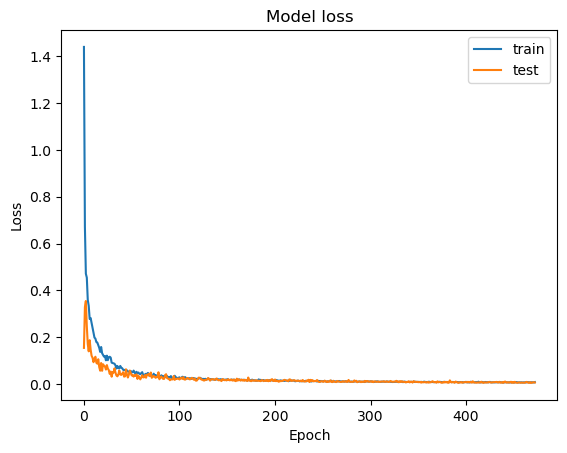

2/2 [==============================] - 0s 9ms/step
MSE: 0.01
R2: 0.75
Epoch 1/500
5/5 - 2s - loss: 1.3182 - mean_squared_error: 1.3182 - val_loss: 0.0537 - val_mean_squared_error: 0.0537 - 2s/epoch - 306ms/step
Epoch 2/500
5/5 - 0s - loss: 0.7055 - mean_squared_error: 0.7055 - val_loss: 0.0734 - val_mean_squared_error: 0.0734 - 211ms/epoch - 42ms/step
Epoch 3/500
5/5 - 0s - loss: 0.5166 - mean_squared_error: 0.5166 - val_loss: 0.0886 - val_mean_squared_error: 0.0886 - 236ms/epoch - 47ms/step
Epoch 4/500
5/5 - 0s - loss: 0.4065 - mean_squared_error: 0.4065 - val_loss: 0.0981 - val_mean_squared_error: 0.0981 - 173ms/epoch - 35ms/step
Epoch 5/500
5/5 - 0s - loss: 0.4398 - mean_squared_error: 0.4398 - val_loss: 0.0976 - val_mean_squared_error: 0.0976 - 152ms/epoch - 30ms/step
Epoch 6/500
5/5 - 0s - loss: 0.3150 - mean_squared_error: 0.3150 - val_loss: 0.1018 - val_mean_squared_error: 0.1018 - 208ms/epoch - 42ms/step
Epoch 7/500
5/5 - 0s - loss: 0.3096 - mean_squared_error: 0.3096 - val_los

Epoch 58/500
5/5 - 0s - loss: 0.0460 - mean_squared_error: 0.0460 - val_loss: 0.0281 - val_mean_squared_error: 0.0281 - 243ms/epoch - 49ms/step
Epoch 59/500
5/5 - 0s - loss: 0.0495 - mean_squared_error: 0.0495 - val_loss: 0.0222 - val_mean_squared_error: 0.0222 - 222ms/epoch - 44ms/step
Epoch 60/500
5/5 - 0s - loss: 0.0522 - mean_squared_error: 0.0522 - val_loss: 0.0313 - val_mean_squared_error: 0.0313 - 271ms/epoch - 54ms/step
Epoch 61/500
5/5 - 0s - loss: 0.0443 - mean_squared_error: 0.0443 - val_loss: 0.0269 - val_mean_squared_error: 0.0269 - 289ms/epoch - 58ms/step
Epoch 62/500
5/5 - 0s - loss: 0.0425 - mean_squared_error: 0.0425 - val_loss: 0.0443 - val_mean_squared_error: 0.0443 - 274ms/epoch - 55ms/step
Epoch 63/500
5/5 - 0s - loss: 0.0412 - mean_squared_error: 0.0412 - val_loss: 0.0357 - val_mean_squared_error: 0.0357 - 244ms/epoch - 49ms/step
Epoch 64/500
5/5 - 0s - loss: 0.0417 - mean_squared_error: 0.0417 - val_loss: 0.0254 - val_mean_squared_error: 0.0254 - 231ms/epoch - 46

Epoch 115/500
5/5 - 0s - loss: 0.0243 - mean_squared_error: 0.0243 - val_loss: 0.0198 - val_mean_squared_error: 0.0198 - 261ms/epoch - 52ms/step
Epoch 116/500
5/5 - 0s - loss: 0.0323 - mean_squared_error: 0.0323 - val_loss: 0.0182 - val_mean_squared_error: 0.0182 - 200ms/epoch - 40ms/step
Epoch 117/500
5/5 - 0s - loss: 0.0239 - mean_squared_error: 0.0239 - val_loss: 0.0238 - val_mean_squared_error: 0.0238 - 222ms/epoch - 44ms/step
Epoch 118/500
5/5 - 0s - loss: 0.0266 - mean_squared_error: 0.0266 - val_loss: 0.0187 - val_mean_squared_error: 0.0187 - 209ms/epoch - 42ms/step
Epoch 119/500
5/5 - 0s - loss: 0.0249 - mean_squared_error: 0.0249 - val_loss: 0.0311 - val_mean_squared_error: 0.0311 - 209ms/epoch - 42ms/step
Epoch 120/500
5/5 - 0s - loss: 0.0283 - mean_squared_error: 0.0283 - val_loss: 0.0156 - val_mean_squared_error: 0.0156 - 280ms/epoch - 56ms/step
Epoch 121/500
5/5 - 0s - loss: 0.0237 - mean_squared_error: 0.0237 - val_loss: 0.0211 - val_mean_squared_error: 0.0211 - 312ms/epo

Epoch 172/500
5/5 - 0s - loss: 0.0185 - mean_squared_error: 0.0185 - val_loss: 0.0238 - val_mean_squared_error: 0.0238 - 135ms/epoch - 27ms/step
Epoch 173/500
5/5 - 0s - loss: 0.0178 - mean_squared_error: 0.0178 - val_loss: 0.0168 - val_mean_squared_error: 0.0168 - 249ms/epoch - 50ms/step
Epoch 174/500
5/5 - 0s - loss: 0.0176 - mean_squared_error: 0.0176 - val_loss: 0.0168 - val_mean_squared_error: 0.0168 - 223ms/epoch - 45ms/step
Epoch 175/500
5/5 - 0s - loss: 0.0172 - mean_squared_error: 0.0172 - val_loss: 0.0175 - val_mean_squared_error: 0.0175 - 272ms/epoch - 54ms/step
Epoch 176/500
5/5 - 0s - loss: 0.0177 - mean_squared_error: 0.0177 - val_loss: 0.0152 - val_mean_squared_error: 0.0152 - 289ms/epoch - 58ms/step
Epoch 177/500
5/5 - 0s - loss: 0.0160 - mean_squared_error: 0.0160 - val_loss: 0.0149 - val_mean_squared_error: 0.0149 - 292ms/epoch - 58ms/step
Epoch 178/500
5/5 - 0s - loss: 0.0143 - mean_squared_error: 0.0143 - val_loss: 0.0152 - val_mean_squared_error: 0.0152 - 270ms/epo

Epoch 229/500
5/5 - 0s - loss: 0.0120 - mean_squared_error: 0.0120 - val_loss: 0.0151 - val_mean_squared_error: 0.0151 - 229ms/epoch - 46ms/step
Epoch 230/500
5/5 - 0s - loss: 0.0132 - mean_squared_error: 0.0132 - val_loss: 0.0127 - val_mean_squared_error: 0.0127 - 210ms/epoch - 42ms/step
Epoch 231/500
5/5 - 0s - loss: 0.0140 - mean_squared_error: 0.0140 - val_loss: 0.0120 - val_mean_squared_error: 0.0120 - 279ms/epoch - 56ms/step
Epoch 232/500
5/5 - 0s - loss: 0.0137 - mean_squared_error: 0.0137 - val_loss: 0.0135 - val_mean_squared_error: 0.0135 - 209ms/epoch - 42ms/step
Epoch 233/500
5/5 - 0s - loss: 0.0156 - mean_squared_error: 0.0156 - val_loss: 0.0185 - val_mean_squared_error: 0.0185 - 219ms/epoch - 44ms/step
Epoch 234/500
5/5 - 0s - loss: 0.0134 - mean_squared_error: 0.0134 - val_loss: 0.0159 - val_mean_squared_error: 0.0159 - 192ms/epoch - 38ms/step
Epoch 235/500
5/5 - 0s - loss: 0.0130 - mean_squared_error: 0.0130 - val_loss: 0.0117 - val_mean_squared_error: 0.0117 - 205ms/epo

Epoch 286/500
5/5 - 0s - loss: 0.0121 - mean_squared_error: 0.0121 - val_loss: 0.0096 - val_mean_squared_error: 0.0096 - 178ms/epoch - 36ms/step
Epoch 287/500
5/5 - 0s - loss: 0.0118 - mean_squared_error: 0.0118 - val_loss: 0.0107 - val_mean_squared_error: 0.0107 - 229ms/epoch - 46ms/step
Epoch 288/500
5/5 - 0s - loss: 0.0124 - mean_squared_error: 0.0124 - val_loss: 0.0142 - val_mean_squared_error: 0.0142 - 226ms/epoch - 45ms/step
Epoch 289/500
5/5 - 0s - loss: 0.0113 - mean_squared_error: 0.0113 - val_loss: 0.0107 - val_mean_squared_error: 0.0107 - 168ms/epoch - 34ms/step
Epoch 290/500
5/5 - 0s - loss: 0.0124 - mean_squared_error: 0.0124 - val_loss: 0.0100 - val_mean_squared_error: 0.0100 - 192ms/epoch - 38ms/step
Epoch 291/500
5/5 - 0s - loss: 0.0127 - mean_squared_error: 0.0127 - val_loss: 0.0142 - val_mean_squared_error: 0.0142 - 218ms/epoch - 44ms/step
Epoch 292/500
5/5 - 0s - loss: 0.0138 - mean_squared_error: 0.0138 - val_loss: 0.0100 - val_mean_squared_error: 0.0100 - 195ms/epo

Epoch 343/500
5/5 - 0s - loss: 0.0102 - mean_squared_error: 0.0102 - val_loss: 0.0124 - val_mean_squared_error: 0.0124 - 176ms/epoch - 35ms/step
Epoch 344/500
5/5 - 0s - loss: 0.0103 - mean_squared_error: 0.0103 - val_loss: 0.0092 - val_mean_squared_error: 0.0092 - 189ms/epoch - 38ms/step
Epoch 345/500
5/5 - 0s - loss: 0.0090 - mean_squared_error: 0.0090 - val_loss: 0.0101 - val_mean_squared_error: 0.0101 - 191ms/epoch - 38ms/step
Epoch 346/500
5/5 - 0s - loss: 0.0115 - mean_squared_error: 0.0115 - val_loss: 0.0164 - val_mean_squared_error: 0.0164 - 222ms/epoch - 44ms/step
Epoch 347/500
5/5 - 0s - loss: 0.0117 - mean_squared_error: 0.0117 - val_loss: 0.0101 - val_mean_squared_error: 0.0101 - 241ms/epoch - 48ms/step
Epoch 348/500
5/5 - 0s - loss: 0.0102 - mean_squared_error: 0.0102 - val_loss: 0.0096 - val_mean_squared_error: 0.0096 - 257ms/epoch - 51ms/step
Epoch 349/500
5/5 - 0s - loss: 0.0104 - mean_squared_error: 0.0104 - val_loss: 0.0097 - val_mean_squared_error: 0.0097 - 219ms/epo

Epoch 400/500
5/5 - 0s - loss: 0.0096 - mean_squared_error: 0.0096 - val_loss: 0.0110 - val_mean_squared_error: 0.0110 - 202ms/epoch - 40ms/step
Epoch 401/500
5/5 - 0s - loss: 0.0109 - mean_squared_error: 0.0109 - val_loss: 0.0082 - val_mean_squared_error: 0.0082 - 201ms/epoch - 40ms/step
Epoch 402/500
5/5 - 0s - loss: 0.0093 - mean_squared_error: 0.0093 - val_loss: 0.0089 - val_mean_squared_error: 0.0089 - 252ms/epoch - 50ms/step
Epoch 403/500
5/5 - 0s - loss: 0.0090 - mean_squared_error: 0.0090 - val_loss: 0.0106 - val_mean_squared_error: 0.0106 - 172ms/epoch - 34ms/step
Epoch 404/500
5/5 - 0s - loss: 0.0106 - mean_squared_error: 0.0106 - val_loss: 0.0105 - val_mean_squared_error: 0.0105 - 221ms/epoch - 44ms/step
Epoch 405/500
5/5 - 0s - loss: 0.0090 - mean_squared_error: 0.0090 - val_loss: 0.0083 - val_mean_squared_error: 0.0083 - 236ms/epoch - 47ms/step
Epoch 406/500
5/5 - 0s - loss: 0.0088 - mean_squared_error: 0.0088 - val_loss: 0.0082 - val_mean_squared_error: 0.0082 - 185ms/epo

Epoch 457/500
5/5 - 0s - loss: 0.0087 - mean_squared_error: 0.0087 - val_loss: 0.0097 - val_mean_squared_error: 0.0097 - 205ms/epoch - 41ms/step
Epoch 458/500
5/5 - 0s - loss: 0.0097 - mean_squared_error: 0.0097 - val_loss: 0.0082 - val_mean_squared_error: 0.0082 - 184ms/epoch - 37ms/step
Epoch 459/500
5/5 - 0s - loss: 0.0089 - mean_squared_error: 0.0089 - val_loss: 0.0104 - val_mean_squared_error: 0.0104 - 216ms/epoch - 43ms/step
Epoch 460/500
5/5 - 0s - loss: 0.0089 - mean_squared_error: 0.0089 - val_loss: 0.0075 - val_mean_squared_error: 0.0075 - 238ms/epoch - 48ms/step
Epoch 461/500
5/5 - 0s - loss: 0.0089 - mean_squared_error: 0.0089 - val_loss: 0.0091 - val_mean_squared_error: 0.0091 - 240ms/epoch - 48ms/step
Epoch 462/500
5/5 - 0s - loss: 0.0099 - mean_squared_error: 0.0099 - val_loss: 0.0094 - val_mean_squared_error: 0.0094 - 243ms/epoch - 49ms/step
Epoch 463/500
5/5 - 0s - loss: 0.0089 - mean_squared_error: 0.0089 - val_loss: 0.0094 - val_mean_squared_error: 0.0094 - 255ms/epo

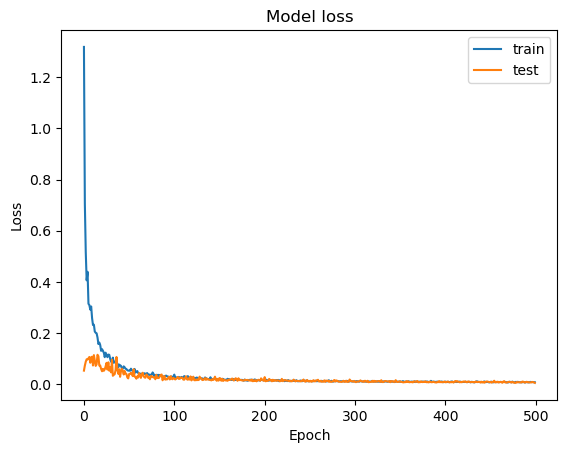

2/2 [==============================] - 0s 5ms/step
MSE: 0.01
R2: 0.79
Epoch 1/500
5/5 - 2s - loss: 1.3330 - mean_squared_error: 1.3330 - val_loss: 0.0375 - val_mean_squared_error: 0.0375 - 2s/epoch - 304ms/step
Epoch 2/500
5/5 - 0s - loss: 0.7564 - mean_squared_error: 0.7564 - val_loss: 0.0447 - val_mean_squared_error: 0.0447 - 168ms/epoch - 34ms/step
Epoch 3/500
5/5 - 0s - loss: 0.5004 - mean_squared_error: 0.5004 - val_loss: 0.0328 - val_mean_squared_error: 0.0328 - 189ms/epoch - 38ms/step
Epoch 4/500
5/5 - 0s - loss: 0.4103 - mean_squared_error: 0.4103 - val_loss: 0.0528 - val_mean_squared_error: 0.0528 - 186ms/epoch - 37ms/step
Epoch 5/500
5/5 - 0s - loss: 0.2871 - mean_squared_error: 0.2871 - val_loss: 0.0661 - val_mean_squared_error: 0.0661 - 215ms/epoch - 43ms/step
Epoch 6/500
5/5 - 0s - loss: 0.2998 - mean_squared_error: 0.2998 - val_loss: 0.0722 - val_mean_squared_error: 0.0722 - 251ms/epoch - 50ms/step
Epoch 7/500
5/5 - 0s - loss: 0.2847 - mean_squared_error: 0.2847 - val_los

Epoch 58/500
5/5 - 0s - loss: 0.0489 - mean_squared_error: 0.0489 - val_loss: 0.0334 - val_mean_squared_error: 0.0334 - 291ms/epoch - 58ms/step
Epoch 59/500
5/5 - 0s - loss: 0.0463 - mean_squared_error: 0.0463 - val_loss: 0.0698 - val_mean_squared_error: 0.0698 - 246ms/epoch - 49ms/step
Epoch 60/500
5/5 - 0s - loss: 0.0436 - mean_squared_error: 0.0436 - val_loss: 0.0260 - val_mean_squared_error: 0.0260 - 232ms/epoch - 46ms/step
Epoch 61/500
5/5 - 0s - loss: 0.0390 - mean_squared_error: 0.0390 - val_loss: 0.0206 - val_mean_squared_error: 0.0206 - 163ms/epoch - 33ms/step
Epoch 62/500
5/5 - 0s - loss: 0.0399 - mean_squared_error: 0.0399 - val_loss: 0.0196 - val_mean_squared_error: 0.0196 - 216ms/epoch - 43ms/step
Epoch 63/500
5/5 - 0s - loss: 0.0361 - mean_squared_error: 0.0361 - val_loss: 0.0259 - val_mean_squared_error: 0.0259 - 261ms/epoch - 52ms/step
Epoch 64/500
5/5 - 0s - loss: 0.0341 - mean_squared_error: 0.0341 - val_loss: 0.0310 - val_mean_squared_error: 0.0310 - 276ms/epoch - 55

Epoch 115/500
5/5 - 0s - loss: 0.0204 - mean_squared_error: 0.0204 - val_loss: 0.0141 - val_mean_squared_error: 0.0141 - 307ms/epoch - 61ms/step
Epoch 116/500
5/5 - 0s - loss: 0.0186 - mean_squared_error: 0.0186 - val_loss: 0.0164 - val_mean_squared_error: 0.0164 - 304ms/epoch - 61ms/step
Epoch 117/500
5/5 - 0s - loss: 0.0241 - mean_squared_error: 0.0241 - val_loss: 0.0167 - val_mean_squared_error: 0.0167 - 163ms/epoch - 33ms/step
Epoch 118/500
5/5 - 0s - loss: 0.0198 - mean_squared_error: 0.0198 - val_loss: 0.0146 - val_mean_squared_error: 0.0146 - 139ms/epoch - 28ms/step
Epoch 119/500
5/5 - 0s - loss: 0.0203 - mean_squared_error: 0.0203 - val_loss: 0.0203 - val_mean_squared_error: 0.0203 - 240ms/epoch - 48ms/step
Epoch 120/500
5/5 - 0s - loss: 0.0198 - mean_squared_error: 0.0198 - val_loss: 0.0184 - val_mean_squared_error: 0.0184 - 247ms/epoch - 49ms/step
Epoch 121/500
5/5 - 0s - loss: 0.0199 - mean_squared_error: 0.0199 - val_loss: 0.0166 - val_mean_squared_error: 0.0166 - 345ms/epo

Epoch 172/500
5/5 - 0s - loss: 0.0151 - mean_squared_error: 0.0151 - val_loss: 0.0123 - val_mean_squared_error: 0.0123 - 190ms/epoch - 38ms/step
Epoch 173/500
5/5 - 0s - loss: 0.0151 - mean_squared_error: 0.0151 - val_loss: 0.0148 - val_mean_squared_error: 0.0148 - 227ms/epoch - 45ms/step
Epoch 174/500
5/5 - 0s - loss: 0.0168 - mean_squared_error: 0.0168 - val_loss: 0.0110 - val_mean_squared_error: 0.0110 - 251ms/epoch - 50ms/step
Epoch 175/500
5/5 - 0s - loss: 0.0156 - mean_squared_error: 0.0156 - val_loss: 0.0134 - val_mean_squared_error: 0.0134 - 318ms/epoch - 64ms/step
Epoch 176/500
5/5 - 0s - loss: 0.0146 - mean_squared_error: 0.0146 - val_loss: 0.0145 - val_mean_squared_error: 0.0145 - 233ms/epoch - 47ms/step
Epoch 177/500
5/5 - 0s - loss: 0.0140 - mean_squared_error: 0.0140 - val_loss: 0.0136 - val_mean_squared_error: 0.0136 - 262ms/epoch - 52ms/step
Epoch 178/500
5/5 - 0s - loss: 0.0152 - mean_squared_error: 0.0152 - val_loss: 0.0145 - val_mean_squared_error: 0.0145 - 200ms/epo

Epoch 229/500
5/5 - 0s - loss: 0.0116 - mean_squared_error: 0.0116 - val_loss: 0.0093 - val_mean_squared_error: 0.0093 - 304ms/epoch - 61ms/step
Epoch 230/500
5/5 - 0s - loss: 0.0128 - mean_squared_error: 0.0128 - val_loss: 0.0106 - val_mean_squared_error: 0.0106 - 301ms/epoch - 60ms/step
Epoch 231/500
5/5 - 0s - loss: 0.0131 - mean_squared_error: 0.0131 - val_loss: 0.0104 - val_mean_squared_error: 0.0104 - 251ms/epoch - 50ms/step
Epoch 232/500
5/5 - 0s - loss: 0.0135 - mean_squared_error: 0.0135 - val_loss: 0.0116 - val_mean_squared_error: 0.0116 - 270ms/epoch - 54ms/step
Epoch 233/500
5/5 - 0s - loss: 0.0111 - mean_squared_error: 0.0111 - val_loss: 0.0090 - val_mean_squared_error: 0.0090 - 270ms/epoch - 54ms/step
Epoch 234/500
5/5 - 0s - loss: 0.0124 - mean_squared_error: 0.0124 - val_loss: 0.0111 - val_mean_squared_error: 0.0111 - 266ms/epoch - 53ms/step
Epoch 235/500
5/5 - 0s - loss: 0.0115 - mean_squared_error: 0.0115 - val_loss: 0.0110 - val_mean_squared_error: 0.0110 - 205ms/epo

Epoch 286/500
5/5 - 0s - loss: 0.0098 - mean_squared_error: 0.0098 - val_loss: 0.0115 - val_mean_squared_error: 0.0115 - 238ms/epoch - 48ms/step
Epoch 287/500
5/5 - 0s - loss: 0.0095 - mean_squared_error: 0.0095 - val_loss: 0.0112 - val_mean_squared_error: 0.0112 - 264ms/epoch - 53ms/step
Epoch 288/500
5/5 - 0s - loss: 0.0122 - mean_squared_error: 0.0122 - val_loss: 0.0156 - val_mean_squared_error: 0.0156 - 236ms/epoch - 47ms/step
Epoch 289/500
5/5 - 0s - loss: 0.0105 - mean_squared_error: 0.0105 - val_loss: 0.0107 - val_mean_squared_error: 0.0107 - 285ms/epoch - 57ms/step
Epoch 290/500
5/5 - 0s - loss: 0.0098 - mean_squared_error: 0.0098 - val_loss: 0.0108 - val_mean_squared_error: 0.0108 - 245ms/epoch - 49ms/step
Epoch 291/500
5/5 - 0s - loss: 0.0099 - mean_squared_error: 0.0099 - val_loss: 0.0123 - val_mean_squared_error: 0.0123 - 220ms/epoch - 44ms/step
Epoch 292/500
5/5 - 0s - loss: 0.0098 - mean_squared_error: 0.0098 - val_loss: 0.0131 - val_mean_squared_error: 0.0131 - 222ms/epo

Epoch 343/500
5/5 - 0s - loss: 0.0100 - mean_squared_error: 0.0100 - val_loss: 0.0089 - val_mean_squared_error: 0.0089 - 155ms/epoch - 31ms/step
Epoch 344/500
5/5 - 0s - loss: 0.0098 - mean_squared_error: 0.0098 - val_loss: 0.0079 - val_mean_squared_error: 0.0079 - 264ms/epoch - 53ms/step
Epoch 345/500
5/5 - 0s - loss: 0.0091 - mean_squared_error: 0.0091 - val_loss: 0.0119 - val_mean_squared_error: 0.0119 - 237ms/epoch - 47ms/step
Epoch 346/500
5/5 - 0s - loss: 0.0108 - mean_squared_error: 0.0108 - val_loss: 0.0080 - val_mean_squared_error: 0.0080 - 276ms/epoch - 55ms/step
Epoch 347/500
5/5 - 0s - loss: 0.0091 - mean_squared_error: 0.0091 - val_loss: 0.0098 - val_mean_squared_error: 0.0098 - 243ms/epoch - 49ms/step
Epoch 348/500
5/5 - 0s - loss: 0.0097 - mean_squared_error: 0.0097 - val_loss: 0.0080 - val_mean_squared_error: 0.0080 - 248ms/epoch - 50ms/step
Epoch 349/500
5/5 - 0s - loss: 0.0102 - mean_squared_error: 0.0102 - val_loss: 0.0098 - val_mean_squared_error: 0.0098 - 231ms/epo

Epoch 400/500
5/5 - 0s - loss: 0.0088 - mean_squared_error: 0.0088 - val_loss: 0.0083 - val_mean_squared_error: 0.0083 - 243ms/epoch - 49ms/step
Epoch 401/500
5/5 - 0s - loss: 0.0087 - mean_squared_error: 0.0087 - val_loss: 0.0072 - val_mean_squared_error: 0.0072 - 158ms/epoch - 32ms/step
Epoch 402/500
5/5 - 0s - loss: 0.0089 - mean_squared_error: 0.0089 - val_loss: 0.0069 - val_mean_squared_error: 0.0069 - 241ms/epoch - 48ms/step
Epoch 403/500
5/5 - 0s - loss: 0.0092 - mean_squared_error: 0.0092 - val_loss: 0.0090 - val_mean_squared_error: 0.0090 - 238ms/epoch - 48ms/step
Epoch 404/500
5/5 - 0s - loss: 0.0092 - mean_squared_error: 0.0092 - val_loss: 0.0071 - val_mean_squared_error: 0.0071 - 284ms/epoch - 57ms/step
Epoch 405/500
5/5 - 0s - loss: 0.0083 - mean_squared_error: 0.0083 - val_loss: 0.0063 - val_mean_squared_error: 0.0063 - 284ms/epoch - 57ms/step
Epoch 406/500
5/5 - 0s - loss: 0.0082 - mean_squared_error: 0.0082 - val_loss: 0.0109 - val_mean_squared_error: 0.0109 - 236ms/epo

Epoch 457/500
5/5 - 0s - loss: 0.0079 - mean_squared_error: 0.0079 - val_loss: 0.0066 - val_mean_squared_error: 0.0066 - 173ms/epoch - 35ms/step
Epoch 458/500
5/5 - 0s - loss: 0.0077 - mean_squared_error: 0.0077 - val_loss: 0.0068 - val_mean_squared_error: 0.0068 - 172ms/epoch - 34ms/step
Epoch 459/500
5/5 - 0s - loss: 0.0075 - mean_squared_error: 0.0075 - val_loss: 0.0119 - val_mean_squared_error: 0.0119 - 186ms/epoch - 37ms/step
Epoch 460/500
5/5 - 0s - loss: 0.0085 - mean_squared_error: 0.0085 - val_loss: 0.0058 - val_mean_squared_error: 0.0058 - 267ms/epoch - 53ms/step
Epoch 461/500
5/5 - 0s - loss: 0.0067 - mean_squared_error: 0.0067 - val_loss: 0.0061 - val_mean_squared_error: 0.0061 - 444ms/epoch - 89ms/step
Epoch 462/500
5/5 - 0s - loss: 0.0078 - mean_squared_error: 0.0078 - val_loss: 0.0056 - val_mean_squared_error: 0.0056 - 339ms/epoch - 68ms/step
Epoch 463/500
5/5 - 0s - loss: 0.0072 - mean_squared_error: 0.0072 - val_loss: 0.0076 - val_mean_squared_error: 0.0076 - 205ms/epo

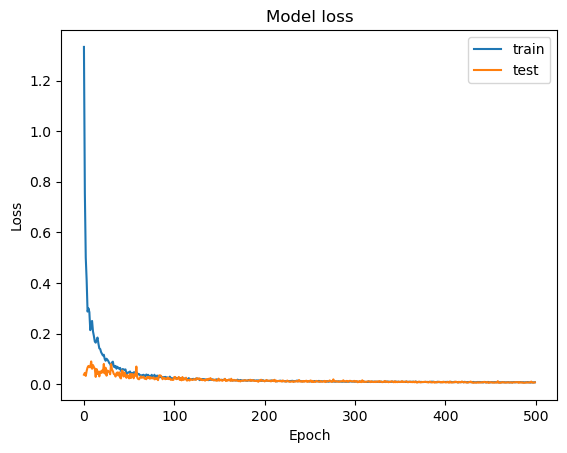

2/2 [==============================] - 0s 12ms/step
MSE: 0.01
R2: 0.74
Epoch 1/500
5/5 - 2s - loss: 1.4409 - mean_squared_error: 1.4409 - val_loss: 0.0763 - val_mean_squared_error: 0.0763 - 2s/epoch - 415ms/step
Epoch 2/500
5/5 - 0s - loss: 0.8159 - mean_squared_error: 0.8159 - val_loss: 0.1452 - val_mean_squared_error: 0.1452 - 243ms/epoch - 49ms/step
Epoch 3/500
5/5 - 0s - loss: 0.5762 - mean_squared_error: 0.5762 - val_loss: 0.1107 - val_mean_squared_error: 0.1107 - 259ms/epoch - 52ms/step
Epoch 4/500
5/5 - 0s - loss: 0.4450 - mean_squared_error: 0.4450 - val_loss: 0.1057 - val_mean_squared_error: 0.1057 - 207ms/epoch - 41ms/step
Epoch 5/500
5/5 - 0s - loss: 0.3666 - mean_squared_error: 0.3666 - val_loss: 0.1335 - val_mean_squared_error: 0.1335 - 257ms/epoch - 51ms/step
Epoch 6/500
5/5 - 0s - loss: 0.4034 - mean_squared_error: 0.4034 - val_loss: 0.1796 - val_mean_squared_error: 0.1796 - 252ms/epoch - 50ms/step
Epoch 7/500
5/5 - 0s - loss: 0.3048 - mean_squared_error: 0.3048 - val_lo

Epoch 58/500
5/5 - 0s - loss: 0.0452 - mean_squared_error: 0.0452 - val_loss: 0.0312 - val_mean_squared_error: 0.0312 - 296ms/epoch - 59ms/step
Epoch 59/500
5/5 - 0s - loss: 0.0475 - mean_squared_error: 0.0475 - val_loss: 0.0310 - val_mean_squared_error: 0.0310 - 305ms/epoch - 61ms/step
Epoch 60/500
5/5 - 0s - loss: 0.0483 - mean_squared_error: 0.0483 - val_loss: 0.0393 - val_mean_squared_error: 0.0393 - 287ms/epoch - 57ms/step
Epoch 61/500
5/5 - 0s - loss: 0.0448 - mean_squared_error: 0.0448 - val_loss: 0.0518 - val_mean_squared_error: 0.0518 - 188ms/epoch - 38ms/step
Epoch 62/500
5/5 - 0s - loss: 0.0424 - mean_squared_error: 0.0424 - val_loss: 0.0340 - val_mean_squared_error: 0.0340 - 235ms/epoch - 47ms/step
Epoch 63/500
5/5 - 0s - loss: 0.0432 - mean_squared_error: 0.0432 - val_loss: 0.0196 - val_mean_squared_error: 0.0196 - 309ms/epoch - 62ms/step
Epoch 64/500
5/5 - 0s - loss: 0.0434 - mean_squared_error: 0.0434 - val_loss: 0.0454 - val_mean_squared_error: 0.0454 - 262ms/epoch - 52

Epoch 115/500
5/5 - 0s - loss: 0.0235 - mean_squared_error: 0.0235 - val_loss: 0.0221 - val_mean_squared_error: 0.0221 - 231ms/epoch - 46ms/step
Epoch 116/500
5/5 - 0s - loss: 0.0216 - mean_squared_error: 0.0216 - val_loss: 0.0284 - val_mean_squared_error: 0.0284 - 230ms/epoch - 46ms/step
Epoch 117/500
5/5 - 0s - loss: 0.0221 - mean_squared_error: 0.0221 - val_loss: 0.0354 - val_mean_squared_error: 0.0354 - 249ms/epoch - 50ms/step
Epoch 118/500
5/5 - 0s - loss: 0.0248 - mean_squared_error: 0.0248 - val_loss: 0.0257 - val_mean_squared_error: 0.0257 - 242ms/epoch - 48ms/step
Epoch 119/500
5/5 - 0s - loss: 0.0247 - mean_squared_error: 0.0247 - val_loss: 0.0226 - val_mean_squared_error: 0.0226 - 248ms/epoch - 50ms/step
Epoch 120/500
5/5 - 0s - loss: 0.0258 - mean_squared_error: 0.0258 - val_loss: 0.0214 - val_mean_squared_error: 0.0214 - 266ms/epoch - 53ms/step
Epoch 121/500
5/5 - 0s - loss: 0.0194 - mean_squared_error: 0.0194 - val_loss: 0.0173 - val_mean_squared_error: 0.0173 - 181ms/epo

Epoch 172/500
5/5 - 0s - loss: 0.0181 - mean_squared_error: 0.0181 - val_loss: 0.0290 - val_mean_squared_error: 0.0290 - 255ms/epoch - 51ms/step
Epoch 173/500
5/5 - 0s - loss: 0.0173 - mean_squared_error: 0.0173 - val_loss: 0.0160 - val_mean_squared_error: 0.0160 - 248ms/epoch - 50ms/step
Epoch 174/500
5/5 - 0s - loss: 0.0153 - mean_squared_error: 0.0153 - val_loss: 0.0167 - val_mean_squared_error: 0.0167 - 266ms/epoch - 53ms/step
Epoch 175/500
5/5 - 0s - loss: 0.0161 - mean_squared_error: 0.0161 - val_loss: 0.0139 - val_mean_squared_error: 0.0139 - 279ms/epoch - 56ms/step
Epoch 176/500
5/5 - 0s - loss: 0.0167 - mean_squared_error: 0.0167 - val_loss: 0.0222 - val_mean_squared_error: 0.0222 - 273ms/epoch - 55ms/step
Epoch 177/500
5/5 - 0s - loss: 0.0163 - mean_squared_error: 0.0163 - val_loss: 0.0195 - val_mean_squared_error: 0.0195 - 207ms/epoch - 41ms/step
Epoch 178/500
5/5 - 0s - loss: 0.0164 - mean_squared_error: 0.0164 - val_loss: 0.0165 - val_mean_squared_error: 0.0165 - 297ms/epo

Epoch 229/500
5/5 - 0s - loss: 0.0139 - mean_squared_error: 0.0139 - val_loss: 0.0162 - val_mean_squared_error: 0.0162 - 255ms/epoch - 51ms/step
Epoch 230/500
5/5 - 0s - loss: 0.0138 - mean_squared_error: 0.0138 - val_loss: 0.0128 - val_mean_squared_error: 0.0128 - 238ms/epoch - 48ms/step
Epoch 231/500
5/5 - 0s - loss: 0.0130 - mean_squared_error: 0.0130 - val_loss: 0.0164 - val_mean_squared_error: 0.0164 - 283ms/epoch - 57ms/step
Epoch 232/500
5/5 - 0s - loss: 0.0121 - mean_squared_error: 0.0121 - val_loss: 0.0252 - val_mean_squared_error: 0.0252 - 257ms/epoch - 51ms/step
Epoch 233/500
5/5 - 0s - loss: 0.0156 - mean_squared_error: 0.0156 - val_loss: 0.0129 - val_mean_squared_error: 0.0129 - 206ms/epoch - 41ms/step
Epoch 234/500
5/5 - 0s - loss: 0.0127 - mean_squared_error: 0.0127 - val_loss: 0.0188 - val_mean_squared_error: 0.0188 - 236ms/epoch - 47ms/step
Epoch 235/500
5/5 - 0s - loss: 0.0125 - mean_squared_error: 0.0125 - val_loss: 0.0189 - val_mean_squared_error: 0.0189 - 218ms/epo

Epoch 286/500
5/5 - 0s - loss: 0.0111 - mean_squared_error: 0.0111 - val_loss: 0.0108 - val_mean_squared_error: 0.0108 - 255ms/epoch - 51ms/step
Epoch 287/500
5/5 - 0s - loss: 0.0099 - mean_squared_error: 0.0099 - val_loss: 0.0125 - val_mean_squared_error: 0.0125 - 249ms/epoch - 50ms/step
Epoch 288/500
5/5 - 0s - loss: 0.0113 - mean_squared_error: 0.0113 - val_loss: 0.0163 - val_mean_squared_error: 0.0163 - 170ms/epoch - 34ms/step
Epoch 289/500
5/5 - 0s - loss: 0.0141 - mean_squared_error: 0.0141 - val_loss: 0.0116 - val_mean_squared_error: 0.0116 - 242ms/epoch - 48ms/step
Epoch 290/500
5/5 - 0s - loss: 0.0116 - mean_squared_error: 0.0116 - val_loss: 0.0145 - val_mean_squared_error: 0.0145 - 260ms/epoch - 52ms/step
Epoch 291/500
5/5 - 0s - loss: 0.0110 - mean_squared_error: 0.0110 - val_loss: 0.0118 - val_mean_squared_error: 0.0118 - 218ms/epoch - 44ms/step
Epoch 292/500
5/5 - 0s - loss: 0.0116 - mean_squared_error: 0.0116 - val_loss: 0.0142 - val_mean_squared_error: 0.0142 - 243ms/epo

Epoch 343/500
5/5 - 0s - loss: 0.0083 - mean_squared_error: 0.0083 - val_loss: 0.0121 - val_mean_squared_error: 0.0121 - 224ms/epoch - 45ms/step
Epoch 344/500
5/5 - 0s - loss: 0.0105 - mean_squared_error: 0.0105 - val_loss: 0.0136 - val_mean_squared_error: 0.0136 - 211ms/epoch - 42ms/step
Epoch 345/500
5/5 - 0s - loss: 0.0114 - mean_squared_error: 0.0114 - val_loss: 0.0134 - val_mean_squared_error: 0.0134 - 249ms/epoch - 50ms/step
Epoch 346/500
5/5 - 0s - loss: 0.0090 - mean_squared_error: 0.0090 - val_loss: 0.0117 - val_mean_squared_error: 0.0117 - 175ms/epoch - 35ms/step
Epoch 347/500
5/5 - 0s - loss: 0.0095 - mean_squared_error: 0.0095 - val_loss: 0.0142 - val_mean_squared_error: 0.0142 - 251ms/epoch - 50ms/step
Epoch 348/500
5/5 - 0s - loss: 0.0095 - mean_squared_error: 0.0095 - val_loss: 0.0098 - val_mean_squared_error: 0.0098 - 283ms/epoch - 57ms/step
Epoch 349/500
5/5 - 0s - loss: 0.0096 - mean_squared_error: 0.0096 - val_loss: 0.0106 - val_mean_squared_error: 0.0106 - 279ms/epo

Epoch 400/500
5/5 - 0s - loss: 0.0106 - mean_squared_error: 0.0106 - val_loss: 0.0084 - val_mean_squared_error: 0.0084 - 247ms/epoch - 49ms/step
Epoch 401/500
5/5 - 0s - loss: 0.0088 - mean_squared_error: 0.0088 - val_loss: 0.0106 - val_mean_squared_error: 0.0106 - 260ms/epoch - 52ms/step
Epoch 402/500
5/5 - 0s - loss: 0.0092 - mean_squared_error: 0.0092 - val_loss: 0.0113 - val_mean_squared_error: 0.0113 - 219ms/epoch - 44ms/step
Epoch 403/500
5/5 - 0s - loss: 0.0078 - mean_squared_error: 0.0078 - val_loss: 0.0123 - val_mean_squared_error: 0.0123 - 261ms/epoch - 52ms/step
Epoch 404/500
5/5 - 0s - loss: 0.0092 - mean_squared_error: 0.0092 - val_loss: 0.0080 - val_mean_squared_error: 0.0080 - 206ms/epoch - 41ms/step
Epoch 405/500
5/5 - 0s - loss: 0.0089 - mean_squared_error: 0.0089 - val_loss: 0.0161 - val_mean_squared_error: 0.0161 - 273ms/epoch - 55ms/step
Epoch 406/500
5/5 - 0s - loss: 0.0092 - mean_squared_error: 0.0092 - val_loss: 0.0084 - val_mean_squared_error: 0.0084 - 267ms/epo

Epoch 457/500
5/5 - 0s - loss: 0.0091 - mean_squared_error: 0.0091 - val_loss: 0.0068 - val_mean_squared_error: 0.0068 - 267ms/epoch - 53ms/step
Epoch 458/500
5/5 - 0s - loss: 0.0078 - mean_squared_error: 0.0078 - val_loss: 0.0086 - val_mean_squared_error: 0.0086 - 268ms/epoch - 54ms/step
Epoch 459/500
5/5 - 0s - loss: 0.0099 - mean_squared_error: 0.0099 - val_loss: 0.0077 - val_mean_squared_error: 0.0077 - 257ms/epoch - 51ms/step
Epoch 460/500
5/5 - 0s - loss: 0.0089 - mean_squared_error: 0.0089 - val_loss: 0.0096 - val_mean_squared_error: 0.0096 - 248ms/epoch - 50ms/step
Epoch 461/500
5/5 - 0s - loss: 0.0073 - mean_squared_error: 0.0073 - val_loss: 0.0142 - val_mean_squared_error: 0.0142 - 170ms/epoch - 34ms/step
Epoch 462/500
5/5 - 0s - loss: 0.0102 - mean_squared_error: 0.0102 - val_loss: 0.0093 - val_mean_squared_error: 0.0093 - 266ms/epoch - 53ms/step
Epoch 463/500
5/5 - 0s - loss: 0.0084 - mean_squared_error: 0.0084 - val_loss: 0.0096 - val_mean_squared_error: 0.0096 - 237ms/epo

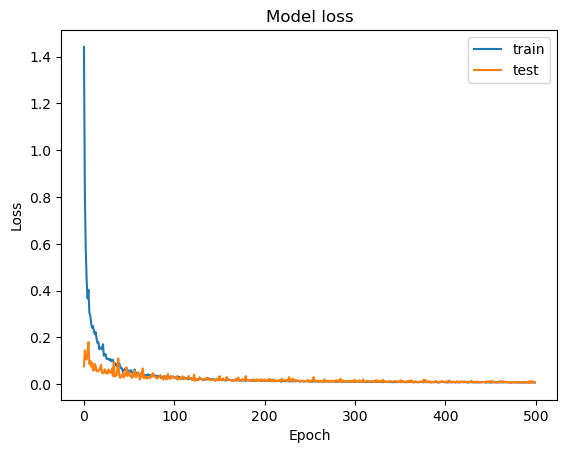

2/2 [==============================] - 0s 6ms/step
MSE: 0.01
R2: 0.74
Epoch 1/500
5/5 - 1s - loss: 1.5757 - mean_squared_error: 1.5757 - val_loss: 0.0490 - val_mean_squared_error: 0.0490 - 1s/epoch - 269ms/step
Epoch 2/500
5/5 - 0s - loss: 0.6850 - mean_squared_error: 0.6850 - val_loss: 0.0374 - val_mean_squared_error: 0.0374 - 207ms/epoch - 41ms/step
Epoch 3/500
5/5 - 0s - loss: 0.6063 - mean_squared_error: 0.6063 - val_loss: 0.0668 - val_mean_squared_error: 0.0668 - 224ms/epoch - 45ms/step
Epoch 4/500
5/5 - 0s - loss: 0.4813 - mean_squared_error: 0.4813 - val_loss: 0.0720 - val_mean_squared_error: 0.0720 - 236ms/epoch - 47ms/step
Epoch 5/500
5/5 - 0s - loss: 0.4164 - mean_squared_error: 0.4164 - val_loss: 0.1426 - val_mean_squared_error: 0.1426 - 242ms/epoch - 48ms/step
Epoch 6/500
5/5 - 0s - loss: 0.3677 - mean_squared_error: 0.3677 - val_loss: 0.1141 - val_mean_squared_error: 0.1141 - 248ms/epoch - 50ms/step
Epoch 7/500
5/5 - 0s - loss: 0.2968 - mean_squared_error: 0.2968 - val_los

Epoch 58/500
5/5 - 0s - loss: 0.0430 - mean_squared_error: 0.0430 - val_loss: 0.0528 - val_mean_squared_error: 0.0528 - 257ms/epoch - 51ms/step
Epoch 59/500
5/5 - 0s - loss: 0.0541 - mean_squared_error: 0.0541 - val_loss: 0.0361 - val_mean_squared_error: 0.0361 - 253ms/epoch - 51ms/step
Epoch 60/500
5/5 - 0s - loss: 0.0465 - mean_squared_error: 0.0465 - val_loss: 0.0395 - val_mean_squared_error: 0.0395 - 212ms/epoch - 42ms/step
Epoch 61/500
5/5 - 0s - loss: 0.0497 - mean_squared_error: 0.0497 - val_loss: 0.0340 - val_mean_squared_error: 0.0340 - 185ms/epoch - 37ms/step
Epoch 62/500
5/5 - 0s - loss: 0.0430 - mean_squared_error: 0.0430 - val_loss: 0.0249 - val_mean_squared_error: 0.0249 - 241ms/epoch - 48ms/step
Epoch 63/500
5/5 - 0s - loss: 0.0415 - mean_squared_error: 0.0415 - val_loss: 0.0241 - val_mean_squared_error: 0.0241 - 262ms/epoch - 52ms/step
Epoch 64/500
5/5 - 0s - loss: 0.0425 - mean_squared_error: 0.0425 - val_loss: 0.0347 - val_mean_squared_error: 0.0347 - 293ms/epoch - 59

Epoch 115/500
5/5 - 0s - loss: 0.0238 - mean_squared_error: 0.0238 - val_loss: 0.0245 - val_mean_squared_error: 0.0245 - 184ms/epoch - 37ms/step
Epoch 116/500
5/5 - 0s - loss: 0.0234 - mean_squared_error: 0.0234 - val_loss: 0.0320 - val_mean_squared_error: 0.0320 - 230ms/epoch - 46ms/step
Epoch 117/500
5/5 - 0s - loss: 0.0235 - mean_squared_error: 0.0235 - val_loss: 0.0207 - val_mean_squared_error: 0.0207 - 239ms/epoch - 48ms/step
Epoch 118/500
5/5 - 0s - loss: 0.0243 - mean_squared_error: 0.0243 - val_loss: 0.0258 - val_mean_squared_error: 0.0258 - 282ms/epoch - 56ms/step
Epoch 119/500
5/5 - 0s - loss: 0.0244 - mean_squared_error: 0.0244 - val_loss: 0.0195 - val_mean_squared_error: 0.0195 - 242ms/epoch - 48ms/step
Epoch 120/500
5/5 - 0s - loss: 0.0216 - mean_squared_error: 0.0216 - val_loss: 0.0169 - val_mean_squared_error: 0.0169 - 254ms/epoch - 51ms/step
Epoch 121/500
5/5 - 0s - loss: 0.0224 - mean_squared_error: 0.0224 - val_loss: 0.0164 - val_mean_squared_error: 0.0164 - 273ms/epo

Epoch 172/500
5/5 - 0s - loss: 0.0170 - mean_squared_error: 0.0170 - val_loss: 0.0138 - val_mean_squared_error: 0.0138 - 185ms/epoch - 37ms/step
Epoch 173/500
5/5 - 0s - loss: 0.0185 - mean_squared_error: 0.0185 - val_loss: 0.0140 - val_mean_squared_error: 0.0140 - 137ms/epoch - 27ms/step
Epoch 174/500
5/5 - 0s - loss: 0.0157 - mean_squared_error: 0.0157 - val_loss: 0.0239 - val_mean_squared_error: 0.0239 - 252ms/epoch - 50ms/step
Epoch 175/500
5/5 - 0s - loss: 0.0193 - mean_squared_error: 0.0193 - val_loss: 0.0149 - val_mean_squared_error: 0.0149 - 232ms/epoch - 46ms/step
Epoch 176/500
5/5 - 0s - loss: 0.0148 - mean_squared_error: 0.0148 - val_loss: 0.0154 - val_mean_squared_error: 0.0154 - 269ms/epoch - 54ms/step
Epoch 177/500
5/5 - 0s - loss: 0.0161 - mean_squared_error: 0.0161 - val_loss: 0.0162 - val_mean_squared_error: 0.0162 - 256ms/epoch - 51ms/step
Epoch 178/500
5/5 - 0s - loss: 0.0184 - mean_squared_error: 0.0184 - val_loss: 0.0160 - val_mean_squared_error: 0.0160 - 224ms/epo

Epoch 229/500
5/5 - 0s - loss: 0.0135 - mean_squared_error: 0.0135 - val_loss: 0.0122 - val_mean_squared_error: 0.0122 - 381ms/epoch - 76ms/step
Epoch 230/500
5/5 - 0s - loss: 0.0136 - mean_squared_error: 0.0136 - val_loss: 0.0141 - val_mean_squared_error: 0.0141 - 170ms/epoch - 34ms/step
Epoch 231/500
5/5 - 0s - loss: 0.0128 - mean_squared_error: 0.0128 - val_loss: 0.0234 - val_mean_squared_error: 0.0234 - 243ms/epoch - 49ms/step
Epoch 232/500
5/5 - 0s - loss: 0.0155 - mean_squared_error: 0.0155 - val_loss: 0.0126 - val_mean_squared_error: 0.0126 - 351ms/epoch - 70ms/step
Epoch 233/500
5/5 - 0s - loss: 0.0137 - mean_squared_error: 0.0137 - val_loss: 0.0128 - val_mean_squared_error: 0.0128 - 303ms/epoch - 61ms/step
Epoch 234/500
5/5 - 0s - loss: 0.0154 - mean_squared_error: 0.0154 - val_loss: 0.0154 - val_mean_squared_error: 0.0154 - 333ms/epoch - 67ms/step
Epoch 235/500
5/5 - 0s - loss: 0.0142 - mean_squared_error: 0.0142 - val_loss: 0.0123 - val_mean_squared_error: 0.0123 - 212ms/epo

Epoch 286/500
5/5 - 0s - loss: 0.0106 - mean_squared_error: 0.0106 - val_loss: 0.0128 - val_mean_squared_error: 0.0128 - 283ms/epoch - 57ms/step
Epoch 287/500
5/5 - 0s - loss: 0.0140 - mean_squared_error: 0.0140 - val_loss: 0.0116 - val_mean_squared_error: 0.0116 - 212ms/epoch - 42ms/step
Epoch 288/500
5/5 - 0s - loss: 0.0112 - mean_squared_error: 0.0112 - val_loss: 0.0132 - val_mean_squared_error: 0.0132 - 252ms/epoch - 50ms/step
Epoch 289/500
5/5 - 0s - loss: 0.0112 - mean_squared_error: 0.0112 - val_loss: 0.0119 - val_mean_squared_error: 0.0119 - 186ms/epoch - 37ms/step
Epoch 290/500
5/5 - 0s - loss: 0.0100 - mean_squared_error: 0.0100 - val_loss: 0.0133 - val_mean_squared_error: 0.0133 - 217ms/epoch - 43ms/step
Epoch 291/500
5/5 - 0s - loss: 0.0111 - mean_squared_error: 0.0111 - val_loss: 0.0121 - val_mean_squared_error: 0.0121 - 169ms/epoch - 34ms/step
Epoch 292/500
5/5 - 0s - loss: 0.0099 - mean_squared_error: 0.0099 - val_loss: 0.0128 - val_mean_squared_error: 0.0128 - 219ms/epo

Epoch 343/500
5/5 - 0s - loss: 0.0096 - mean_squared_error: 0.0096 - val_loss: 0.0113 - val_mean_squared_error: 0.0113 - 164ms/epoch - 33ms/step
Epoch 344/500
5/5 - 0s - loss: 0.0108 - mean_squared_error: 0.0108 - val_loss: 0.0131 - val_mean_squared_error: 0.0131 - 195ms/epoch - 39ms/step
Epoch 345/500
5/5 - 0s - loss: 0.0105 - mean_squared_error: 0.0105 - val_loss: 0.0119 - val_mean_squared_error: 0.0119 - 277ms/epoch - 55ms/step
Epoch 346/500
5/5 - 0s - loss: 0.0106 - mean_squared_error: 0.0106 - val_loss: 0.0096 - val_mean_squared_error: 0.0096 - 157ms/epoch - 31ms/step
Epoch 347/500
5/5 - 0s - loss: 0.0109 - mean_squared_error: 0.0109 - val_loss: 0.0101 - val_mean_squared_error: 0.0101 - 164ms/epoch - 33ms/step
Epoch 348/500
5/5 - 0s - loss: 0.0095 - mean_squared_error: 0.0095 - val_loss: 0.0141 - val_mean_squared_error: 0.0141 - 297ms/epoch - 59ms/step
Epoch 349/500
5/5 - 0s - loss: 0.0103 - mean_squared_error: 0.0103 - val_loss: 0.0087 - val_mean_squared_error: 0.0087 - 273ms/epo

Epoch 400/500
5/5 - 0s - loss: 0.0097 - mean_squared_error: 0.0097 - val_loss: 0.0093 - val_mean_squared_error: 0.0093 - 230ms/epoch - 46ms/step
Epoch 401/500
5/5 - 0s - loss: 0.0085 - mean_squared_error: 0.0085 - val_loss: 0.0155 - val_mean_squared_error: 0.0155 - 242ms/epoch - 48ms/step
Epoch 402/500
5/5 - 0s - loss: 0.0090 - mean_squared_error: 0.0090 - val_loss: 0.0095 - val_mean_squared_error: 0.0095 - 202ms/epoch - 40ms/step
Epoch 403/500
5/5 - 0s - loss: 0.0086 - mean_squared_error: 0.0086 - val_loss: 0.0094 - val_mean_squared_error: 0.0094 - 273ms/epoch - 55ms/step
Epoch 404/500
5/5 - 0s - loss: 0.0092 - mean_squared_error: 0.0092 - val_loss: 0.0078 - val_mean_squared_error: 0.0078 - 230ms/epoch - 46ms/step
Epoch 405/500
5/5 - 0s - loss: 0.0087 - mean_squared_error: 0.0087 - val_loss: 0.0088 - val_mean_squared_error: 0.0088 - 241ms/epoch - 48ms/step
Epoch 406/500
5/5 - 0s - loss: 0.0080 - mean_squared_error: 0.0080 - val_loss: 0.0084 - val_mean_squared_error: 0.0084 - 194ms/epo

Epoch 457/500
5/5 - 0s - loss: 0.0086 - mean_squared_error: 0.0086 - val_loss: 0.0077 - val_mean_squared_error: 0.0077 - 275ms/epoch - 55ms/step
Epoch 458/500
5/5 - 0s - loss: 0.0084 - mean_squared_error: 0.0084 - val_loss: 0.0092 - val_mean_squared_error: 0.0092 - 303ms/epoch - 61ms/step
Epoch 459/500
5/5 - 0s - loss: 0.0082 - mean_squared_error: 0.0082 - val_loss: 0.0077 - val_mean_squared_error: 0.0077 - 278ms/epoch - 56ms/step
Epoch 460/500
5/5 - 0s - loss: 0.0076 - mean_squared_error: 0.0076 - val_loss: 0.0077 - val_mean_squared_error: 0.0077 - 273ms/epoch - 55ms/step
Epoch 461/500
5/5 - 0s - loss: 0.0085 - mean_squared_error: 0.0085 - val_loss: 0.0084 - val_mean_squared_error: 0.0084 - 200ms/epoch - 40ms/step
Epoch 462/500
5/5 - 0s - loss: 0.0073 - mean_squared_error: 0.0073 - val_loss: 0.0087 - val_mean_squared_error: 0.0087 - 233ms/epoch - 47ms/step
Epoch 463/500
5/5 - 0s - loss: 0.0087 - mean_squared_error: 0.0087 - val_loss: 0.0062 - val_mean_squared_error: 0.0062 - 243ms/epo

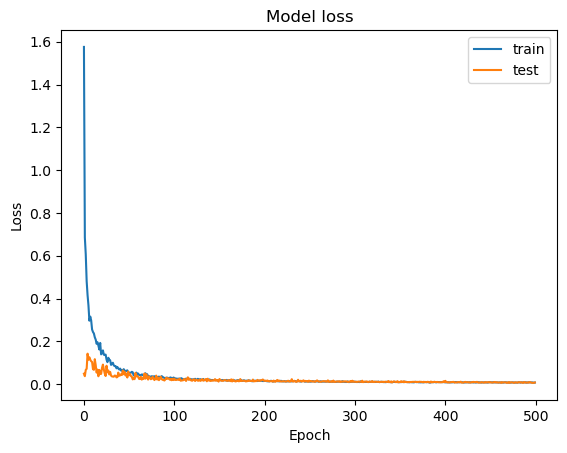

2/2 [==============================] - 0s 18ms/step
MSE: 0.01
R2: 0.72
Epoch 1/500
5/5 - 2s - loss: 1.2674 - mean_squared_error: 1.2674 - val_loss: 0.0643 - val_mean_squared_error: 0.0643 - 2s/epoch - 381ms/step
Epoch 2/500
5/5 - 0s - loss: 0.5683 - mean_squared_error: 0.5683 - val_loss: 0.1529 - val_mean_squared_error: 0.1529 - 297ms/epoch - 59ms/step
Epoch 3/500
5/5 - 0s - loss: 0.4673 - mean_squared_error: 0.4673 - val_loss: 0.1278 - val_mean_squared_error: 0.1278 - 289ms/epoch - 58ms/step
Epoch 4/500
5/5 - 0s - loss: 0.3951 - mean_squared_error: 0.3951 - val_loss: 0.1000 - val_mean_squared_error: 0.1000 - 237ms/epoch - 47ms/step
Epoch 5/500
5/5 - 0s - loss: 0.3757 - mean_squared_error: 0.3757 - val_loss: 0.1074 - val_mean_squared_error: 0.1074 - 212ms/epoch - 42ms/step
Epoch 6/500
5/5 - 0s - loss: 0.3050 - mean_squared_error: 0.3050 - val_loss: 0.1016 - val_mean_squared_error: 0.1016 - 297ms/epoch - 59ms/step
Epoch 7/500
5/5 - 0s - loss: 0.2532 - mean_squared_error: 0.2532 - val_lo

Epoch 58/500
5/5 - 0s - loss: 0.0426 - mean_squared_error: 0.0426 - val_loss: 0.0272 - val_mean_squared_error: 0.0272 - 232ms/epoch - 46ms/step
Epoch 59/500
5/5 - 0s - loss: 0.0401 - mean_squared_error: 0.0401 - val_loss: 0.0253 - val_mean_squared_error: 0.0253 - 181ms/epoch - 36ms/step
Epoch 60/500
5/5 - 0s - loss: 0.0367 - mean_squared_error: 0.0367 - val_loss: 0.0344 - val_mean_squared_error: 0.0344 - 253ms/epoch - 51ms/step
Epoch 61/500
5/5 - 0s - loss: 0.0400 - mean_squared_error: 0.0400 - val_loss: 0.0250 - val_mean_squared_error: 0.0250 - 242ms/epoch - 48ms/step
Epoch 62/500
5/5 - 0s - loss: 0.0324 - mean_squared_error: 0.0324 - val_loss: 0.0272 - val_mean_squared_error: 0.0272 - 271ms/epoch - 54ms/step
Epoch 63/500
5/5 - 0s - loss: 0.0357 - mean_squared_error: 0.0357 - val_loss: 0.0313 - val_mean_squared_error: 0.0313 - 252ms/epoch - 50ms/step
Epoch 64/500
5/5 - 0s - loss: 0.0371 - mean_squared_error: 0.0371 - val_loss: 0.0176 - val_mean_squared_error: 0.0176 - 256ms/epoch - 51

Epoch 115/500
5/5 - 0s - loss: 0.0212 - mean_squared_error: 0.0212 - val_loss: 0.0218 - val_mean_squared_error: 0.0218 - 268ms/epoch - 54ms/step
Epoch 116/500
5/5 - 0s - loss: 0.0204 - mean_squared_error: 0.0204 - val_loss: 0.0199 - val_mean_squared_error: 0.0199 - 257ms/epoch - 51ms/step
Epoch 117/500
5/5 - 0s - loss: 0.0188 - mean_squared_error: 0.0188 - val_loss: 0.0138 - val_mean_squared_error: 0.0138 - 269ms/epoch - 54ms/step
Epoch 118/500
5/5 - 0s - loss: 0.0199 - mean_squared_error: 0.0199 - val_loss: 0.0157 - val_mean_squared_error: 0.0157 - 220ms/epoch - 44ms/step
Epoch 119/500
5/5 - 0s - loss: 0.0205 - mean_squared_error: 0.0205 - val_loss: 0.0139 - val_mean_squared_error: 0.0139 - 201ms/epoch - 40ms/step
Epoch 120/500
5/5 - 0s - loss: 0.0200 - mean_squared_error: 0.0200 - val_loss: 0.0211 - val_mean_squared_error: 0.0211 - 255ms/epoch - 51ms/step
Epoch 121/500
5/5 - 0s - loss: 0.0182 - mean_squared_error: 0.0182 - val_loss: 0.0179 - val_mean_squared_error: 0.0179 - 252ms/epo

Epoch 172/500
5/5 - 0s - loss: 0.0151 - mean_squared_error: 0.0151 - val_loss: 0.0119 - val_mean_squared_error: 0.0119 - 226ms/epoch - 45ms/step
Epoch 173/500
5/5 - 0s - loss: 0.0163 - mean_squared_error: 0.0163 - val_loss: 0.0117 - val_mean_squared_error: 0.0117 - 161ms/epoch - 32ms/step
Epoch 174/500
5/5 - 0s - loss: 0.0147 - mean_squared_error: 0.0147 - val_loss: 0.0125 - val_mean_squared_error: 0.0125 - 159ms/epoch - 32ms/step
Epoch 175/500
5/5 - 0s - loss: 0.0133 - mean_squared_error: 0.0133 - val_loss: 0.0129 - val_mean_squared_error: 0.0129 - 263ms/epoch - 53ms/step
Epoch 176/500
5/5 - 0s - loss: 0.0139 - mean_squared_error: 0.0139 - val_loss: 0.0163 - val_mean_squared_error: 0.0163 - 171ms/epoch - 34ms/step
Epoch 177/500
5/5 - 0s - loss: 0.0139 - mean_squared_error: 0.0139 - val_loss: 0.0139 - val_mean_squared_error: 0.0139 - 203ms/epoch - 41ms/step
Epoch 178/500
5/5 - 0s - loss: 0.0133 - mean_squared_error: 0.0133 - val_loss: 0.0153 - val_mean_squared_error: 0.0153 - 241ms/epo

Epoch 229/500
5/5 - 0s - loss: 0.0129 - mean_squared_error: 0.0129 - val_loss: 0.0131 - val_mean_squared_error: 0.0131 - 186ms/epoch - 37ms/step
Epoch 230/500
5/5 - 0s - loss: 0.0117 - mean_squared_error: 0.0117 - val_loss: 0.0107 - val_mean_squared_error: 0.0107 - 192ms/epoch - 38ms/step
Epoch 231/500
5/5 - 0s - loss: 0.0104 - mean_squared_error: 0.0104 - val_loss: 0.0116 - val_mean_squared_error: 0.0116 - 271ms/epoch - 54ms/step
Epoch 232/500
5/5 - 0s - loss: 0.0116 - mean_squared_error: 0.0116 - val_loss: 0.0122 - val_mean_squared_error: 0.0122 - 226ms/epoch - 45ms/step
Epoch 233/500
5/5 - 0s - loss: 0.0136 - mean_squared_error: 0.0136 - val_loss: 0.0102 - val_mean_squared_error: 0.0102 - 227ms/epoch - 45ms/step
Epoch 234/500
5/5 - 0s - loss: 0.0119 - mean_squared_error: 0.0119 - val_loss: 0.0125 - val_mean_squared_error: 0.0125 - 260ms/epoch - 52ms/step
Epoch 235/500
5/5 - 0s - loss: 0.0121 - mean_squared_error: 0.0121 - val_loss: 0.0126 - val_mean_squared_error: 0.0126 - 191ms/epo

Epoch 286/500
5/5 - 0s - loss: 0.0089 - mean_squared_error: 0.0089 - val_loss: 0.0120 - val_mean_squared_error: 0.0120 - 186ms/epoch - 37ms/step
Epoch 287/500
5/5 - 0s - loss: 0.0096 - mean_squared_error: 0.0096 - val_loss: 0.0086 - val_mean_squared_error: 0.0086 - 142ms/epoch - 28ms/step
Epoch 288/500
5/5 - 0s - loss: 0.0097 - mean_squared_error: 0.0097 - val_loss: 0.0095 - val_mean_squared_error: 0.0095 - 253ms/epoch - 51ms/step
Epoch 289/500
5/5 - 0s - loss: 0.0093 - mean_squared_error: 0.0093 - val_loss: 0.0116 - val_mean_squared_error: 0.0116 - 214ms/epoch - 43ms/step
Epoch 290/500
5/5 - 0s - loss: 0.0105 - mean_squared_error: 0.0105 - val_loss: 0.0086 - val_mean_squared_error: 0.0086 - 207ms/epoch - 41ms/step
Epoch 291/500
5/5 - 0s - loss: 0.0100 - mean_squared_error: 0.0100 - val_loss: 0.0106 - val_mean_squared_error: 0.0106 - 225ms/epoch - 45ms/step
Epoch 292/500
5/5 - 0s - loss: 0.0083 - mean_squared_error: 0.0083 - val_loss: 0.0098 - val_mean_squared_error: 0.0098 - 173ms/epo

Epoch 343/500
5/5 - 0s - loss: 0.0080 - mean_squared_error: 0.0080 - val_loss: 0.0105 - val_mean_squared_error: 0.0105 - 238ms/epoch - 48ms/step
Epoch 344/500
5/5 - 0s - loss: 0.0091 - mean_squared_error: 0.0091 - val_loss: 0.0082 - val_mean_squared_error: 0.0082 - 189ms/epoch - 38ms/step
Epoch 345/500
5/5 - 0s - loss: 0.0091 - mean_squared_error: 0.0091 - val_loss: 0.0081 - val_mean_squared_error: 0.0081 - 196ms/epoch - 39ms/step
Epoch 346/500
5/5 - 0s - loss: 0.0086 - mean_squared_error: 0.0086 - val_loss: 0.0081 - val_mean_squared_error: 0.0081 - 164ms/epoch - 33ms/step
Epoch 347/500
5/5 - 0s - loss: 0.0079 - mean_squared_error: 0.0079 - val_loss: 0.0082 - val_mean_squared_error: 0.0082 - 180ms/epoch - 36ms/step
Epoch 348/500
5/5 - 0s - loss: 0.0086 - mean_squared_error: 0.0086 - val_loss: 0.0088 - val_mean_squared_error: 0.0088 - 284ms/epoch - 57ms/step
Epoch 349/500
5/5 - 0s - loss: 0.0088 - mean_squared_error: 0.0088 - val_loss: 0.0118 - val_mean_squared_error: 0.0118 - 180ms/epo

Epoch 400/500
5/5 - 0s - loss: 0.0091 - mean_squared_error: 0.0091 - val_loss: 0.0089 - val_mean_squared_error: 0.0089 - 225ms/epoch - 45ms/step
Epoch 401/500
5/5 - 0s - loss: 0.0073 - mean_squared_error: 0.0073 - val_loss: 0.0082 - val_mean_squared_error: 0.0082 - 207ms/epoch - 41ms/step
Epoch 402/500
5/5 - 0s - loss: 0.0069 - mean_squared_error: 0.0069 - val_loss: 0.0080 - val_mean_squared_error: 0.0080 - 255ms/epoch - 51ms/step
Epoch 403/500
5/5 - 0s - loss: 0.0068 - mean_squared_error: 0.0068 - val_loss: 0.0079 - val_mean_squared_error: 0.0079 - 267ms/epoch - 53ms/step
Epoch 404/500
5/5 - 0s - loss: 0.0077 - mean_squared_error: 0.0077 - val_loss: 0.0100 - val_mean_squared_error: 0.0100 - 254ms/epoch - 51ms/step
Epoch 405/500
5/5 - 0s - loss: 0.0095 - mean_squared_error: 0.0095 - val_loss: 0.0075 - val_mean_squared_error: 0.0075 - 249ms/epoch - 50ms/step
Epoch 406/500
5/5 - 0s - loss: 0.0075 - mean_squared_error: 0.0075 - val_loss: 0.0059 - val_mean_squared_error: 0.0059 - 258ms/epo

Epoch 457/500
5/5 - 0s - loss: 0.0069 - mean_squared_error: 0.0069 - val_loss: 0.0075 - val_mean_squared_error: 0.0075 - 275ms/epoch - 55ms/step
Epoch 458/500
5/5 - 0s - loss: 0.0069 - mean_squared_error: 0.0069 - val_loss: 0.0063 - val_mean_squared_error: 0.0063 - 252ms/epoch - 50ms/step
Epoch 459/500
5/5 - 0s - loss: 0.0070 - mean_squared_error: 0.0070 - val_loss: 0.0084 - val_mean_squared_error: 0.0084 - 308ms/epoch - 62ms/step
Epoch 460/500
5/5 - 0s - loss: 0.0069 - mean_squared_error: 0.0069 - val_loss: 0.0058 - val_mean_squared_error: 0.0058 - 263ms/epoch - 53ms/step
Epoch 461/500
5/5 - 0s - loss: 0.0065 - mean_squared_error: 0.0065 - val_loss: 0.0081 - val_mean_squared_error: 0.0081 - 188ms/epoch - 38ms/step
Epoch 462/500
5/5 - 0s - loss: 0.0073 - mean_squared_error: 0.0073 - val_loss: 0.0065 - val_mean_squared_error: 0.0065 - 197ms/epoch - 39ms/step
Epoch 463/500
5/5 - 0s - loss: 0.0071 - mean_squared_error: 0.0071 - val_loss: 0.0080 - val_mean_squared_error: 0.0080 - 201ms/epo

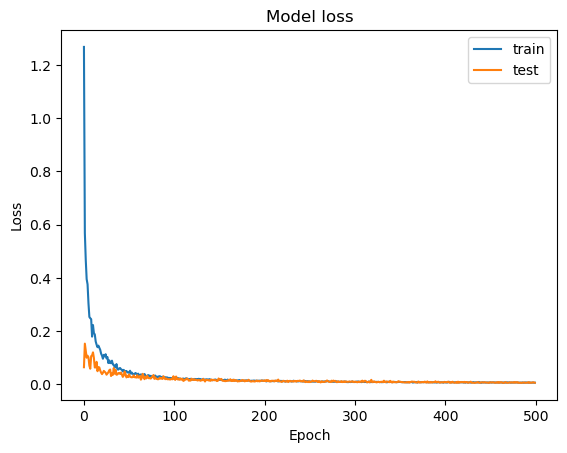

2/2 [==============================] - 0s 18ms/step
MSE: 0.01
R2: 0.79
Epoch 1/500
5/5 - 1s - loss: 1.5775 - mean_squared_error: 1.5775 - val_loss: 1.6949 - val_mean_squared_error: 1.6949 - 1s/epoch - 292ms/step
Epoch 2/500
5/5 - 0s - loss: 0.7643 - mean_squared_error: 0.7643 - val_loss: 2.7831 - val_mean_squared_error: 2.7831 - 224ms/epoch - 45ms/step
Epoch 3/500
5/5 - 0s - loss: 0.5945 - mean_squared_error: 0.5945 - val_loss: 2.2144 - val_mean_squared_error: 2.2144 - 268ms/epoch - 54ms/step
Epoch 4/500
5/5 - 0s - loss: 0.4515 - mean_squared_error: 0.4515 - val_loss: 1.3892 - val_mean_squared_error: 1.3892 - 337ms/epoch - 67ms/step
Epoch 5/500
5/5 - 0s - loss: 0.3735 - mean_squared_error: 0.3735 - val_loss: 0.7934 - val_mean_squared_error: 0.7934 - 256ms/epoch - 51ms/step
Epoch 6/500
5/5 - 0s - loss: 0.3856 - mean_squared_error: 0.3856 - val_loss: 0.5437 - val_mean_squared_error: 0.5437 - 288ms/epoch - 58ms/step
Epoch 7/500
5/5 - 0s - loss: 0.3098 - mean_squared_error: 0.3098 - val_lo

Epoch 58/500
5/5 - 0s - loss: 0.0476 - mean_squared_error: 0.0476 - val_loss: 0.0337 - val_mean_squared_error: 0.0337 - 234ms/epoch - 47ms/step
Epoch 59/500
5/5 - 0s - loss: 0.0454 - mean_squared_error: 0.0454 - val_loss: 0.0496 - val_mean_squared_error: 0.0496 - 232ms/epoch - 46ms/step
Epoch 60/500
5/5 - 0s - loss: 0.0461 - mean_squared_error: 0.0461 - val_loss: 0.0573 - val_mean_squared_error: 0.0573 - 270ms/epoch - 54ms/step
Epoch 61/500
5/5 - 0s - loss: 0.0494 - mean_squared_error: 0.0494 - val_loss: 0.0406 - val_mean_squared_error: 0.0406 - 284ms/epoch - 57ms/step
Epoch 62/500
5/5 - 0s - loss: 0.0493 - mean_squared_error: 0.0493 - val_loss: 0.0630 - val_mean_squared_error: 0.0630 - 286ms/epoch - 57ms/step
Epoch 63/500
5/5 - 0s - loss: 0.0497 - mean_squared_error: 0.0497 - val_loss: 0.0231 - val_mean_squared_error: 0.0231 - 191ms/epoch - 38ms/step
Epoch 64/500
5/5 - 0s - loss: 0.0390 - mean_squared_error: 0.0390 - val_loss: 0.0359 - val_mean_squared_error: 0.0359 - 204ms/epoch - 41

Epoch 115/500
5/5 - 0s - loss: 0.0228 - mean_squared_error: 0.0228 - val_loss: 0.0198 - val_mean_squared_error: 0.0198 - 220ms/epoch - 44ms/step
Epoch 116/500
5/5 - 0s - loss: 0.0222 - mean_squared_error: 0.0222 - val_loss: 0.0172 - val_mean_squared_error: 0.0172 - 181ms/epoch - 36ms/step
Epoch 117/500
5/5 - 0s - loss: 0.0244 - mean_squared_error: 0.0244 - val_loss: 0.0203 - val_mean_squared_error: 0.0203 - 267ms/epoch - 53ms/step
Epoch 118/500
5/5 - 0s - loss: 0.0267 - mean_squared_error: 0.0267 - val_loss: 0.0302 - val_mean_squared_error: 0.0302 - 254ms/epoch - 51ms/step
Epoch 119/500
5/5 - 0s - loss: 0.0228 - mean_squared_error: 0.0228 - val_loss: 0.0301 - val_mean_squared_error: 0.0301 - 220ms/epoch - 44ms/step
Epoch 120/500
5/5 - 0s - loss: 0.0263 - mean_squared_error: 0.0263 - val_loss: 0.0189 - val_mean_squared_error: 0.0189 - 251ms/epoch - 50ms/step
Epoch 121/500
5/5 - 0s - loss: 0.0221 - mean_squared_error: 0.0221 - val_loss: 0.0249 - val_mean_squared_error: 0.0249 - 189ms/epo

Epoch 172/500
5/5 - 0s - loss: 0.0164 - mean_squared_error: 0.0164 - val_loss: 0.0277 - val_mean_squared_error: 0.0277 - 232ms/epoch - 46ms/step
Epoch 173/500
5/5 - 0s - loss: 0.0189 - mean_squared_error: 0.0189 - val_loss: 0.0187 - val_mean_squared_error: 0.0187 - 242ms/epoch - 48ms/step
Epoch 174/500
5/5 - 0s - loss: 0.0163 - mean_squared_error: 0.0163 - val_loss: 0.0123 - val_mean_squared_error: 0.0123 - 237ms/epoch - 47ms/step
Epoch 175/500
5/5 - 0s - loss: 0.0169 - mean_squared_error: 0.0169 - val_loss: 0.0130 - val_mean_squared_error: 0.0130 - 160ms/epoch - 32ms/step
Epoch 176/500
5/5 - 0s - loss: 0.0159 - mean_squared_error: 0.0159 - val_loss: 0.0137 - val_mean_squared_error: 0.0137 - 261ms/epoch - 52ms/step
Epoch 177/500
5/5 - 0s - loss: 0.0167 - mean_squared_error: 0.0167 - val_loss: 0.0158 - val_mean_squared_error: 0.0158 - 241ms/epoch - 48ms/step
Epoch 178/500
5/5 - 0s - loss: 0.0185 - mean_squared_error: 0.0185 - val_loss: 0.0121 - val_mean_squared_error: 0.0121 - 267ms/epo

Epoch 229/500
5/5 - 0s - loss: 0.0168 - mean_squared_error: 0.0168 - val_loss: 0.0114 - val_mean_squared_error: 0.0114 - 262ms/epoch - 52ms/step
Epoch 230/500
5/5 - 0s - loss: 0.0117 - mean_squared_error: 0.0117 - val_loss: 0.0113 - val_mean_squared_error: 0.0113 - 140ms/epoch - 28ms/step
Epoch 231/500
5/5 - 0s - loss: 0.0158 - mean_squared_error: 0.0158 - val_loss: 0.0134 - val_mean_squared_error: 0.0134 - 173ms/epoch - 35ms/step
Epoch 232/500
5/5 - 0s - loss: 0.0133 - mean_squared_error: 0.0133 - val_loss: 0.0124 - val_mean_squared_error: 0.0124 - 173ms/epoch - 35ms/step
Epoch 233/500
5/5 - 0s - loss: 0.0140 - mean_squared_error: 0.0140 - val_loss: 0.0151 - val_mean_squared_error: 0.0151 - 235ms/epoch - 47ms/step
Epoch 234/500
5/5 - 0s - loss: 0.0126 - mean_squared_error: 0.0126 - val_loss: 0.0147 - val_mean_squared_error: 0.0147 - 241ms/epoch - 48ms/step
Epoch 235/500
5/5 - 0s - loss: 0.0136 - mean_squared_error: 0.0136 - val_loss: 0.0121 - val_mean_squared_error: 0.0121 - 240ms/epo

Epoch 286/500
5/5 - 0s - loss: 0.0122 - mean_squared_error: 0.0122 - val_loss: 0.0103 - val_mean_squared_error: 0.0103 - 211ms/epoch - 42ms/step
Epoch 287/500
5/5 - 0s - loss: 0.0138 - mean_squared_error: 0.0138 - val_loss: 0.0107 - val_mean_squared_error: 0.0107 - 268ms/epoch - 54ms/step
Epoch 288/500
5/5 - 0s - loss: 0.0104 - mean_squared_error: 0.0104 - val_loss: 0.0104 - val_mean_squared_error: 0.0104 - 321ms/epoch - 64ms/step
Epoch 289/500
5/5 - 0s - loss: 0.0109 - mean_squared_error: 0.0109 - val_loss: 0.0114 - val_mean_squared_error: 0.0114 - 296ms/epoch - 59ms/step
Epoch 290/500
5/5 - 0s - loss: 0.0127 - mean_squared_error: 0.0127 - val_loss: 0.0154 - val_mean_squared_error: 0.0154 - 278ms/epoch - 56ms/step
Epoch 291/500
5/5 - 0s - loss: 0.0127 - mean_squared_error: 0.0127 - val_loss: 0.0111 - val_mean_squared_error: 0.0111 - 211ms/epoch - 42ms/step
Epoch 292/500
5/5 - 0s - loss: 0.0127 - mean_squared_error: 0.0127 - val_loss: 0.0117 - val_mean_squared_error: 0.0117 - 222ms/epo

Epoch 343/500
5/5 - 0s - loss: 0.0111 - mean_squared_error: 0.0111 - val_loss: 0.0087 - val_mean_squared_error: 0.0087 - 290ms/epoch - 58ms/step
Epoch 344/500
5/5 - 0s - loss: 0.0102 - mean_squared_error: 0.0102 - val_loss: 0.0104 - val_mean_squared_error: 0.0104 - 263ms/epoch - 53ms/step
Epoch 345/500
5/5 - 0s - loss: 0.0110 - mean_squared_error: 0.0110 - val_loss: 0.0131 - val_mean_squared_error: 0.0131 - 261ms/epoch - 52ms/step
Epoch 346/500
5/5 - 0s - loss: 0.0108 - mean_squared_error: 0.0108 - val_loss: 0.0110 - val_mean_squared_error: 0.0110 - 268ms/epoch - 54ms/step
Epoch 347/500
5/5 - 0s - loss: 0.0096 - mean_squared_error: 0.0096 - val_loss: 0.0087 - val_mean_squared_error: 0.0087 - 215ms/epoch - 43ms/step
Epoch 348/500
5/5 - 0s - loss: 0.0092 - mean_squared_error: 0.0092 - val_loss: 0.0092 - val_mean_squared_error: 0.0092 - 246ms/epoch - 49ms/step
Epoch 349/500
5/5 - 0s - loss: 0.0101 - mean_squared_error: 0.0101 - val_loss: 0.0094 - val_mean_squared_error: 0.0094 - 150ms/epo

Epoch 400/500
5/5 - 0s - loss: 0.0083 - mean_squared_error: 0.0083 - val_loss: 0.0127 - val_mean_squared_error: 0.0127 - 262ms/epoch - 52ms/step
Epoch 401/500
5/5 - 0s - loss: 0.0087 - mean_squared_error: 0.0087 - val_loss: 0.0127 - val_mean_squared_error: 0.0127 - 232ms/epoch - 46ms/step
Epoch 402/500
5/5 - 0s - loss: 0.0089 - mean_squared_error: 0.0089 - val_loss: 0.0095 - val_mean_squared_error: 0.0095 - 247ms/epoch - 49ms/step
Epoch 403/500
5/5 - 0s - loss: 0.0099 - mean_squared_error: 0.0099 - val_loss: 0.0076 - val_mean_squared_error: 0.0076 - 299ms/epoch - 60ms/step
Epoch 404/500
5/5 - 0s - loss: 0.0106 - mean_squared_error: 0.0106 - val_loss: 0.0099 - val_mean_squared_error: 0.0099 - 245ms/epoch - 49ms/step
Epoch 405/500
5/5 - 0s - loss: 0.0086 - mean_squared_error: 0.0086 - val_loss: 0.0104 - val_mean_squared_error: 0.0104 - 274ms/epoch - 55ms/step
Epoch 406/500
5/5 - 0s - loss: 0.0093 - mean_squared_error: 0.0093 - val_loss: 0.0078 - val_mean_squared_error: 0.0078 - 249ms/epo

Epoch 457/500
5/5 - 0s - loss: 0.0077 - mean_squared_error: 0.0077 - val_loss: 0.0093 - val_mean_squared_error: 0.0093 - 276ms/epoch - 55ms/step
Epoch 458/500
5/5 - 0s - loss: 0.0092 - mean_squared_error: 0.0092 - val_loss: 0.0071 - val_mean_squared_error: 0.0071 - 229ms/epoch - 46ms/step
Epoch 459/500
5/5 - 0s - loss: 0.0090 - mean_squared_error: 0.0090 - val_loss: 0.0090 - val_mean_squared_error: 0.0090 - 210ms/epoch - 42ms/step
Epoch 460/500
5/5 - 0s - loss: 0.0087 - mean_squared_error: 0.0087 - val_loss: 0.0081 - val_mean_squared_error: 0.0081 - 298ms/epoch - 60ms/step
Epoch 461/500
5/5 - 0s - loss: 0.0082 - mean_squared_error: 0.0082 - val_loss: 0.0066 - val_mean_squared_error: 0.0066 - 288ms/epoch - 58ms/step
Epoch 462/500
5/5 - 0s - loss: 0.0087 - mean_squared_error: 0.0087 - val_loss: 0.0123 - val_mean_squared_error: 0.0123 - 265ms/epoch - 53ms/step
Epoch 463/500
5/5 - 0s - loss: 0.0088 - mean_squared_error: 0.0088 - val_loss: 0.0084 - val_mean_squared_error: 0.0084 - 240ms/epo

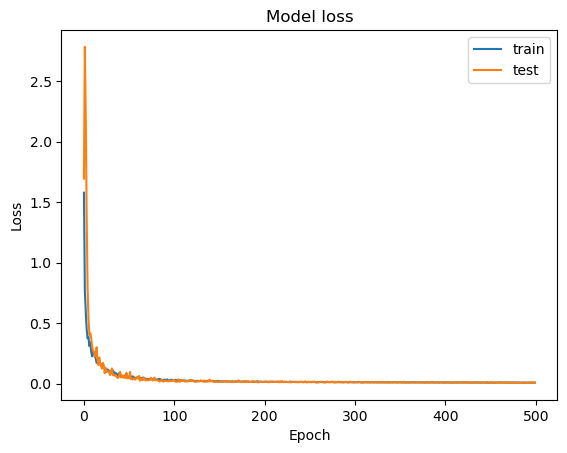

2/2 [==============================] - 0s 15ms/step
MSE: 0.01
R2: 0.69
Epoch 1/500
5/5 - 2s - loss: 1.4041 - mean_squared_error: 1.4041 - val_loss: 0.1238 - val_mean_squared_error: 0.1238 - 2s/epoch - 397ms/step
Epoch 2/500
5/5 - 0s - loss: 0.7803 - mean_squared_error: 0.7803 - val_loss: 0.3152 - val_mean_squared_error: 0.3152 - 269ms/epoch - 54ms/step
Epoch 3/500
5/5 - 0s - loss: 0.6067 - mean_squared_error: 0.6067 - val_loss: 0.2806 - val_mean_squared_error: 0.2806 - 204ms/epoch - 41ms/step
Epoch 4/500
5/5 - 0s - loss: 0.5167 - mean_squared_error: 0.5167 - val_loss: 0.2558 - val_mean_squared_error: 0.2558 - 235ms/epoch - 47ms/step
Epoch 5/500
5/5 - 0s - loss: 0.4138 - mean_squared_error: 0.4138 - val_loss: 0.1726 - val_mean_squared_error: 0.1726 - 273ms/epoch - 55ms/step
Epoch 6/500
5/5 - 0s - loss: 0.3708 - mean_squared_error: 0.3708 - val_loss: 0.1638 - val_mean_squared_error: 0.1638 - 263ms/epoch - 53ms/step
Epoch 7/500
5/5 - 0s - loss: 0.3123 - mean_squared_error: 0.3123 - val_lo

Epoch 58/500
5/5 - 0s - loss: 0.0586 - mean_squared_error: 0.0586 - val_loss: 0.0266 - val_mean_squared_error: 0.0266 - 206ms/epoch - 41ms/step
Epoch 59/500
5/5 - 0s - loss: 0.0570 - mean_squared_error: 0.0570 - val_loss: 0.0242 - val_mean_squared_error: 0.0242 - 236ms/epoch - 47ms/step
Epoch 60/500
5/5 - 0s - loss: 0.0462 - mean_squared_error: 0.0462 - val_loss: 0.0307 - val_mean_squared_error: 0.0307 - 277ms/epoch - 55ms/step
Epoch 61/500
5/5 - 0s - loss: 0.0499 - mean_squared_error: 0.0499 - val_loss: 0.0328 - val_mean_squared_error: 0.0328 - 224ms/epoch - 45ms/step
Epoch 62/500
5/5 - 0s - loss: 0.0479 - mean_squared_error: 0.0479 - val_loss: 0.0652 - val_mean_squared_error: 0.0652 - 235ms/epoch - 47ms/step
Epoch 63/500
5/5 - 0s - loss: 0.0485 - mean_squared_error: 0.0485 - val_loss: 0.0329 - val_mean_squared_error: 0.0329 - 251ms/epoch - 50ms/step
Epoch 64/500
5/5 - 0s - loss: 0.0383 - mean_squared_error: 0.0383 - val_loss: 0.0257 - val_mean_squared_error: 0.0257 - 252ms/epoch - 50

Epoch 115/500
5/5 - 0s - loss: 0.0247 - mean_squared_error: 0.0247 - val_loss: 0.0210 - val_mean_squared_error: 0.0210 - 238ms/epoch - 48ms/step
Epoch 116/500
5/5 - 0s - loss: 0.0221 - mean_squared_error: 0.0221 - val_loss: 0.0190 - val_mean_squared_error: 0.0190 - 198ms/epoch - 40ms/step
Epoch 117/500
5/5 - 0s - loss: 0.0285 - mean_squared_error: 0.0285 - val_loss: 0.0290 - val_mean_squared_error: 0.0290 - 291ms/epoch - 58ms/step
Epoch 118/500
5/5 - 0s - loss: 0.0264 - mean_squared_error: 0.0264 - val_loss: 0.0213 - val_mean_squared_error: 0.0213 - 257ms/epoch - 51ms/step
Epoch 119/500
5/5 - 0s - loss: 0.0253 - mean_squared_error: 0.0253 - val_loss: 0.0187 - val_mean_squared_error: 0.0187 - 245ms/epoch - 49ms/step
Epoch 120/500
5/5 - 0s - loss: 0.0243 - mean_squared_error: 0.0243 - val_loss: 0.0231 - val_mean_squared_error: 0.0231 - 251ms/epoch - 50ms/step
Epoch 121/500
5/5 - 0s - loss: 0.0259 - mean_squared_error: 0.0259 - val_loss: 0.0249 - val_mean_squared_error: 0.0249 - 254ms/epo

Epoch 172/500
5/5 - 0s - loss: 0.0168 - mean_squared_error: 0.0168 - val_loss: 0.0132 - val_mean_squared_error: 0.0132 - 235ms/epoch - 47ms/step
Epoch 173/500
5/5 - 0s - loss: 0.0169 - mean_squared_error: 0.0169 - val_loss: 0.0181 - val_mean_squared_error: 0.0181 - 238ms/epoch - 48ms/step
Epoch 174/500
5/5 - 0s - loss: 0.0171 - mean_squared_error: 0.0171 - val_loss: 0.0172 - val_mean_squared_error: 0.0172 - 254ms/epoch - 51ms/step
Epoch 175/500
5/5 - 0s - loss: 0.0192 - mean_squared_error: 0.0192 - val_loss: 0.0152 - val_mean_squared_error: 0.0152 - 252ms/epoch - 50ms/step
Epoch 176/500
5/5 - 0s - loss: 0.0169 - mean_squared_error: 0.0169 - val_loss: 0.0158 - val_mean_squared_error: 0.0158 - 190ms/epoch - 38ms/step
Epoch 177/500
5/5 - 0s - loss: 0.0186 - mean_squared_error: 0.0186 - val_loss: 0.0133 - val_mean_squared_error: 0.0133 - 203ms/epoch - 41ms/step
Epoch 178/500
5/5 - 0s - loss: 0.0165 - mean_squared_error: 0.0165 - val_loss: 0.0137 - val_mean_squared_error: 0.0137 - 170ms/epo

Epoch 229/500
5/5 - 0s - loss: 0.0151 - mean_squared_error: 0.0151 - val_loss: 0.0101 - val_mean_squared_error: 0.0101 - 220ms/epoch - 44ms/step
Epoch 230/500
5/5 - 0s - loss: 0.0126 - mean_squared_error: 0.0126 - val_loss: 0.0119 - val_mean_squared_error: 0.0119 - 173ms/epoch - 35ms/step
Epoch 231/500
5/5 - 0s - loss: 0.0122 - mean_squared_error: 0.0122 - val_loss: 0.0116 - val_mean_squared_error: 0.0116 - 220ms/epoch - 44ms/step
Epoch 232/500
5/5 - 0s - loss: 0.0150 - mean_squared_error: 0.0150 - val_loss: 0.0132 - val_mean_squared_error: 0.0132 - 235ms/epoch - 47ms/step
Epoch 233/500
5/5 - 0s - loss: 0.0133 - mean_squared_error: 0.0133 - val_loss: 0.0203 - val_mean_squared_error: 0.0203 - 252ms/epoch - 50ms/step
Epoch 234/500
5/5 - 0s - loss: 0.0153 - mean_squared_error: 0.0153 - val_loss: 0.0109 - val_mean_squared_error: 0.0109 - 300ms/epoch - 60ms/step
Epoch 235/500
5/5 - 0s - loss: 0.0131 - mean_squared_error: 0.0131 - val_loss: 0.0106 - val_mean_squared_error: 0.0106 - 179ms/epo

Epoch 286/500
5/5 - 0s - loss: 0.0114 - mean_squared_error: 0.0114 - val_loss: 0.0122 - val_mean_squared_error: 0.0122 - 299ms/epoch - 60ms/step
Epoch 287/500
5/5 - 0s - loss: 0.0114 - mean_squared_error: 0.0114 - val_loss: 0.0112 - val_mean_squared_error: 0.0112 - 236ms/epoch - 47ms/step
Epoch 288/500
5/5 - 0s - loss: 0.0121 - mean_squared_error: 0.0121 - val_loss: 0.0121 - val_mean_squared_error: 0.0121 - 235ms/epoch - 47ms/step
Epoch 289/500
5/5 - 0s - loss: 0.0113 - mean_squared_error: 0.0113 - val_loss: 0.0126 - val_mean_squared_error: 0.0126 - 141ms/epoch - 28ms/step
Epoch 290/500
5/5 - 0s - loss: 0.0121 - mean_squared_error: 0.0121 - val_loss: 0.0109 - val_mean_squared_error: 0.0109 - 189ms/epoch - 38ms/step
Epoch 291/500
5/5 - 0s - loss: 0.0136 - mean_squared_error: 0.0136 - val_loss: 0.0098 - val_mean_squared_error: 0.0098 - 251ms/epoch - 50ms/step
Epoch 292/500
5/5 - 0s - loss: 0.0118 - mean_squared_error: 0.0118 - val_loss: 0.0086 - val_mean_squared_error: 0.0086 - 138ms/epo

Epoch 343/500
5/5 - 0s - loss: 0.0103 - mean_squared_error: 0.0103 - val_loss: 0.0131 - val_mean_squared_error: 0.0131 - 220ms/epoch - 44ms/step
Epoch 344/500
5/5 - 0s - loss: 0.0115 - mean_squared_error: 0.0115 - val_loss: 0.0089 - val_mean_squared_error: 0.0089 - 251ms/epoch - 50ms/step
Epoch 345/500
5/5 - 0s - loss: 0.0103 - mean_squared_error: 0.0103 - val_loss: 0.0081 - val_mean_squared_error: 0.0081 - 246ms/epoch - 49ms/step
Epoch 346/500
5/5 - 0s - loss: 0.0098 - mean_squared_error: 0.0098 - val_loss: 0.0071 - val_mean_squared_error: 0.0071 - 220ms/epoch - 44ms/step
Epoch 347/500
5/5 - 0s - loss: 0.0088 - mean_squared_error: 0.0088 - val_loss: 0.0093 - val_mean_squared_error: 0.0093 - 276ms/epoch - 55ms/step
Epoch 348/500
5/5 - 0s - loss: 0.0114 - mean_squared_error: 0.0114 - val_loss: 0.0100 - val_mean_squared_error: 0.0100 - 172ms/epoch - 34ms/step
Epoch 349/500
5/5 - 0s - loss: 0.0100 - mean_squared_error: 0.0100 - val_loss: 0.0085 - val_mean_squared_error: 0.0085 - 267ms/epo

Epoch 400/500
5/5 - 0s - loss: 0.0086 - mean_squared_error: 0.0086 - val_loss: 0.0076 - val_mean_squared_error: 0.0076 - 274ms/epoch - 55ms/step
Epoch 401/500
5/5 - 0s - loss: 0.0081 - mean_squared_error: 0.0081 - val_loss: 0.0084 - val_mean_squared_error: 0.0084 - 204ms/epoch - 41ms/step
Epoch 402/500
5/5 - 0s - loss: 0.0092 - mean_squared_error: 0.0092 - val_loss: 0.0094 - val_mean_squared_error: 0.0094 - 236ms/epoch - 47ms/step
Epoch 403/500
5/5 - 0s - loss: 0.0095 - mean_squared_error: 0.0095 - val_loss: 0.0102 - val_mean_squared_error: 0.0102 - 204ms/epoch - 41ms/step
Epoch 404/500
5/5 - 0s - loss: 0.0084 - mean_squared_error: 0.0084 - val_loss: 0.0081 - val_mean_squared_error: 0.0081 - 236ms/epoch - 47ms/step
Epoch 405/500
5/5 - 0s - loss: 0.0099 - mean_squared_error: 0.0099 - val_loss: 0.0085 - val_mean_squared_error: 0.0085 - 235ms/epoch - 47ms/step
Epoch 406/500
5/5 - 0s - loss: 0.0115 - mean_squared_error: 0.0115 - val_loss: 0.0083 - val_mean_squared_error: 0.0083 - 204ms/epo

Epoch 457/500
5/5 - 0s - loss: 0.0095 - mean_squared_error: 0.0095 - val_loss: 0.0099 - val_mean_squared_error: 0.0099 - 285ms/epoch - 57ms/step
Epoch 458/500
5/5 - 0s - loss: 0.0094 - mean_squared_error: 0.0094 - val_loss: 0.0092 - val_mean_squared_error: 0.0092 - 256ms/epoch - 51ms/step
Epoch 459/500
5/5 - 0s - loss: 0.0081 - mean_squared_error: 0.0081 - val_loss: 0.0115 - val_mean_squared_error: 0.0115 - 205ms/epoch - 41ms/step
Epoch 460/500
5/5 - 0s - loss: 0.0077 - mean_squared_error: 0.0077 - val_loss: 0.0061 - val_mean_squared_error: 0.0061 - 246ms/epoch - 49ms/step
Epoch 461/500
5/5 - 0s - loss: 0.0081 - mean_squared_error: 0.0081 - val_loss: 0.0064 - val_mean_squared_error: 0.0064 - 221ms/epoch - 44ms/step
Epoch 462/500
5/5 - 0s - loss: 0.0085 - mean_squared_error: 0.0085 - val_loss: 0.0085 - val_mean_squared_error: 0.0085 - 284ms/epoch - 57ms/step
Epoch 463/500
5/5 - 0s - loss: 0.0094 - mean_squared_error: 0.0094 - val_loss: 0.0090 - val_mean_squared_error: 0.0090 - 267ms/epo

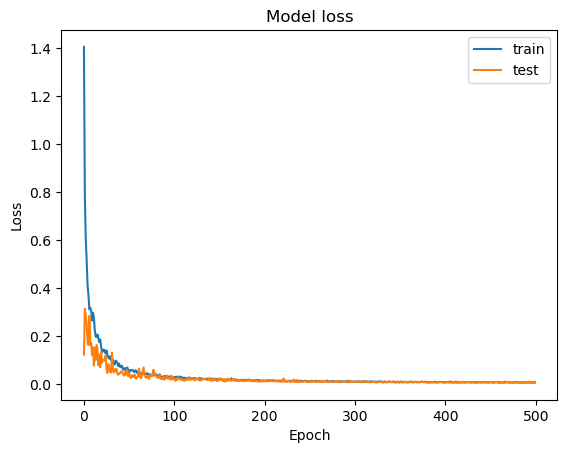

2/2 [==============================] - 0s 16ms/step
MSE: 0.01
R2: 0.78
[0.7748153665658641, 0.68322480999936, 0.7474875954520223, 0.7935148479695253, 0.7388273457121894, 0.7420781653553388, 0.7249571854706169, 0.792214246733528, 0.6863586752890346, 0.7810001749532212]
Mean R2: 0.75 (+/- 0.04)


In [158]:
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, r2_score
from keras.layers import BatchNormalization

kfold = KFold(n_splits=10, shuffle=True, random_state=7)
cvscores = []

for train, test in kfold.split(x, y):
    # 创建模型
    model = Sequential()
    model.add(Dense(128, input_dim=input, activation='relu'))
    model.add(BatchNormalization(momentum=0.8))
    model.add(Dropout(0.5))
    model.add(Dense(128, activation='relu'))
    model.add(BatchNormalization(momentum=0.8))
    model.add(Dense(1, activation='linear'))
    
    # 编译模型
    rmsprop = tf.keras.optimizers.RMSprop(learning_rate=0.001, rho=0.9, epsilon=1e-08)
    model.compile(loss='mean_squared_error', optimizer=rmsprop, metrics=['mean_squared_error'])
    
    # 训练模型
    early_stopping = EarlyStopping(monitor='val_loss', patience=80, verbose=2)
    history = model.fit(x, y, epochs=500, batch_size=128, shuffle=False, verbose=2,
                        validation_data=(x_test, y_test), callbacks=[early_stopping])
    
    # 绘制损失曲线
    plt.plot(history.history['loss'], label='train')
    plt.plot(history.history['val_loss'], label='test')
    plt.title('Model loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()
    plt.show()
    
    # 模型评估
    y_pred = model.predict(x_test)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    print("MSE: %.2f" % mse)
    print("R2: %.2f" % r2)
    
    cvscores.append(r2)
    
print(cvscores)
print("Mean R2: %.2f (+/- %.2f)" % (np.mean(cvscores), np.std(cvscores)))

## XGBoost

In [159]:
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import xgboost as xgb

In [160]:
train_data=pd.read_excel(r'D:\creep rupture\TR+TS\GAN200train.xlsx')
test_data=pd.read_excel(r'D:\creep rupture\TR+TS\GAN200test.xlsx')
x = train_data.drop(columns=[ 'Time to Rupture(h)'])
y = train_data['Time to Rupture(h)']
x_test = test_data.drop(columns=['Time to Rupture(h)'])
y_test = test_data['Time to Rupture(h)']

In [161]:
# 定义你希望调优的参数范围
param_grid = {
    'learning_rate': [0.01, 0.1, 0.2, 0.3],
    'max_depth': [4, 5, 6],
    'n_estimators': [50, 100, 150],
    'gamma': [0, 0.1, 0.2],
    'alpha': [0, 0.1, 0.2],
    'lambda': [0, 0.1, 0.2]
}

# 创建XGBoost回归模型实例
xgb_reg = xgb.XGBRegressor(objective ='reg:squarederror')

# 将模型和参数范围传入 GridSearchCV，并设置交叉验证数量为 5
grid_search = GridSearchCV(xgb_reg, param_grid, cv=5, scoring='neg_mean_squared_error')

# 使用训练数据拟合 GridSearchCV
grid_search.fit(x, y)

# 打印最佳参数组合
print(f"Best parameters: {grid_search.best_params_}")

# 使用最优参数在所有训练数据上重新训练模型
best_xgb_reg = grid_search.best_estimator_

# 如果使用xgb.train，则需使用以下代码
dtrain = xgb.DMatrix(x, label=y)
dtest = xgb.DMatrix(x_test, label=y_test)

# 设置参数（使用上面GridSearchCV得到的最优参数）
best_params = grid_search.best_params_
best_params["objective"] = "reg:squarederror"

bst = xgb.train(best_params,
                dtrain,
                num_boost_round=100,
                evals=[(dtest, "test")],
                early_stopping_rounds=10,
                verbose_eval=False)

# 对测试集进行预测
preds = best_xgb_reg.predict(x_test)

# 计算并打印均方误差和确定系数（R-squared）
rmse = np.sqrt(mean_squared_error(y_test, preds))
r2 = r2_score(y_test, preds)

print("RMSE: %f" % (rmse))
print("R2: %f" % (r2))

Best parameters: {'alpha': 0.1, 'gamma': 0, 'lambda': 0, 'learning_rate': 0.2, 'max_depth': 4, 'n_estimators': 150}


C:\Users\zangd\AppData\Roaming\Python\Python311\site-packages\xgboost\core.py:160: UserWarning: [17:05:18] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0cec3277c4d9d0165-1\xgboost\xgboost-ci-windows\src\learner.cc:742: 
Parameters: { "n_estimators" } are not used.

  warnings.warn(smsg, UserWarning)


RMSE: 0.066323
R2: 0.845484


## MLP

In [162]:
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score, make_scorer

In [163]:
# 创建多层感知机回归模型实例
mlp_regressor = MLPRegressor(random_state=42, max_iter=1000)

# 定义参数网格
param_grid = {
    'hidden_layer_sizes': [(10,), (20,), (10,10)],
    'activation': ['relu', 'tanh'],
    'solver': ['adam', 'lbfgs'],
    'alpha': [0.0001, 0.001, 0.01]
}

# 定义评分函数
mse_scorer = make_scorer(mean_squared_error, greater_is_better=False)

# 使用 GridSearchCV 进行参数优化
grid_search = GridSearchCV(mlp_regressor, param_grid, scoring=mse_scorer, cv=5, n_jobs=-1, verbose=1)
grid_search.fit(x, y)

# 打印找到的最佳参数
print(f"Best parameters found: {grid_search.best_params_}")

# 使用最佳参数重新训练模型
best_mlp = grid_search.best_estimator_

# 模型预测
y_pred = best_mlp.predict(x_test)

# 评估模型
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f'The rmse of prediction is: {rmse}')
print(f'The R^2 score of prediction is: {r2}')

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best parameters found: {'activation': 'tanh', 'alpha': 0.001, 'hidden_layer_sizes': (20,), 'solver': 'lbfgs'}
The rmse of prediction is: 0.064806077757441
The R^2 score of prediction is: 0.8524709167167004


## GBDT

In [164]:
import os
import time
from bayes_opt import BayesianOptimization
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from lightgbm import LGBMRegressor
import numpy as np
from sklearn.metrics import explained_variance_score
import matplotlib.pyplot as plt
import datetime
import pandas as pd

#t = time.localtime()
model_name = 'TRGAN200_BO_GBDT'
file_name = '{}.xlsx'.format(model_name)
train_data = pd.read_excel(r'D:\creep rupture\TR+TS\GAN200train.xlsx')
test_data = pd.read_excel(r'D:\creep rupture\TR+TS\GAN200test.xlsx')
train_features = train_data.drop(columns=['Time to Rupture(h)'])
train_labels = train_data[['Time to Rupture(h)']]
test_features = test_data.drop(columns=['Time to Rupture(h)'])
test_labels = test_data[['Time to Rupture(h)']]
train_features = train_features.to_numpy()
train_labels = train_labels.to_numpy()
test_features = test_features.to_numpy()
test_labels = test_labels.to_numpy()
train_labels = train_labels.reshape(-1)
test_labels = test_labels.reshape(-1)
def train_model(num_leaves,
                min_child_samples,
            learning_rate,
            n_estimators, 
            max_bin,
            colsample_bytree, 
            subsample, 
            max_depth, 
            reg_alpha,
            reg_lambda,
            min_split_gain,
            min_child_weight
            ):
    params = {
        "num_leaves": int(round(num_leaves)),
        'min_child_samples':int(round(min_child_samples)),
        'learning_rate': learning_rate,
        'n_estimators': int(round(n_estimators)),
        'max_bin': int(round(max_bin)),
        'colsample_bytree': max(min(colsample_bytree, 1), 0),
        'subsample': max(min(subsample, 1), 0),
        'max_depth': int(round(max_depth)),
        'reg_alpha':  max(reg_alpha, 0),
        'reg_lambda': max(reg_lambda, 0),
        'min_split_gain': min_split_gain,
        'min_child_weight': min_child_weight,
        'verbose': -1
                  } #the parameters you want to optimize
    model = LGBMRegressor(metric='mape',**params)
    model.fit(train_features, train_labels)
    y_pred = model.predict(test_features)
    error = -np.mean(np.abs((test_labels - y_pred) / test_labels))       # print(error)     
    return error
bounds = {'num_leaves': (5, 60),#50
          'min_child_samples':(1, 50),
          'learning_rate': (0.001, 1),
          'n_estimators': (5, 200),#100
            'max_bin': (5, 100),#10
          'colsample_bytree': (0.5, 1),
          'subsample': (0.1, 2),
          'max_depth': (1, 60),#10
          'reg_alpha': (0.01, 1), #5
          'reg_lambda': (0.01, 1),#5
          'min_split_gain': (0.001, 0.1),
          'min_child_weight': (0.0001, 30)}
optimizer = BayesianOptimization(
    f=train_model,
    pbounds=bounds,
    random_state=1,
)
optimizer.maximize(init_points = 50, n_iter=50) #here you set how many iterations you want.
table = pd.DataFrame(columns=['target', 'colsample_bytree', 'learning_rate', 'max_bin',
                      'max_depth','min_child_samples','min_child_weight','min_split_gain',
                      'n_estimators','num_leaves','reg_alpha','reg_lambda','subsample'])
for res in optimizer.res:
    table=table.append(pd.DataFrame({'target':[res['target']],'colsample_bytree':[res['params']['colsample_bytree']],
                                     'colsample_bytree':[res['params']['colsample_bytree']],
                                     'learning_rate':[res['params']['learning_rate']],
                                     'max_bin':[res['params']['max_bin']],
                                     'max_depth':[res['params']['max_depth']],
                                     'min_child_samples':[res['params']['min_child_samples']],
                                     'min_child_weight':[res['params']['min_child_weight']],
                                     'min_split_gain':[res['params']['min_split_gain']],
                                     'n_estimators':[res['params']['n_estimators']],
                                     'num_leaves':[res['params']['num_leaves']],
                                     'reg_alpha':[res['params']['reg_alpha']],
                                     'reg_lambda':[res['params']['reg_lambda']],
                                     'subsample':[res['params']['subsample']]}),
                                     ignore_index=True)
table=table.sort_values(by = ['target'],ascending=False)#sort the list start from the best results
table.to_excel(file_name)#save the results to the table
#endtime = datetime.datetime.now()
#print ('running time {}'.format(endtime - starttime))

|   iter    |  target   | colsam... | learni... |  max_bin  | max_depth | min_ch... | min_ch... | min_sp... | n_esti... | num_le... | reg_alpha | reg_la... | subsample |
-------------------------------------------------------------------------------------------------------------------------------------------------------------------------
| 1         | -8.743    | 0.7085    | 0.7206    | 5.011     | 18.84     | 8.191     | 2.77      | 0.01944   | 72.38     | 26.82     | 0.5434    | 0.425     | 1.402     |
| 2         | -7.307    | 0.6022    | 0.8782    | 7.602     | 40.56     | 21.45     | 16.76     | 0.0149    | 43.63     | 49.04     | 0.9686    | 0.3203    | 1.415     |
| 3         | -4.237    | 0.9382    | 0.8947    | 13.08     | 3.304     | 9.322     | 26.34     | 0.01074   | 87.12     | 57.68     | 0.5378    | 0.695     | 0.6995    |
| 4         | -3.926    | 0.8433    | 0.8348    | 6.737     | 45.26     | 49.45     | 22.44     | 0.02876   | 158.9     | 10.68     | 0.4534    | 0.90

| 33        | -5.052    | 0.6239    | 0.2629    | 76.27     | 27.96     | 3.79      | 15.26     | 0.02198   | 160.7     | 21.35     | 0.03733   | 0.5975    | 1.703     |
| 34        | -7.436    | 0.6905    | 0.7501    | 53.56     | 32.92     | 48.01     | 24.12     | 0.0042    | 143.3     | 30.58     | 0.9481    | 0.2292    | 0.6074    |
| 35        | -6.704    | 0.5407    | 0.4292    | 15.36     | 38.39     | 40.35     | 20.9      | 0.07685   | 71.78     | 51.52     | 0.4345    | 0.8258    | 1.29      |
| 36        | -5.333    | 0.5717    | 0.07931   | 6.742     | 4.937     | 23.47     | 3.4       | 0.003751  | 152.2     | 26.72     | 0.7495    | 0.4579    | 0.9552    |
| 37        | -4.89     | 0.739     | 0.4745    | 81.3      | 24.74     | 45.33     | 1.112     | 0.07761   | 29.5      | 39.02     | 0.02026   | 0.5432    | 0.1057    |
| 38        | -6.417    | 0.9756    | 0.9055    | 80.62     | 55.0      | 8.132     | 4.732     | 0.01958   | 126.4     | 54.82     | 0.9901    | 0.71

| 63        | -24.0     | 0.9892    | 0.001     | 51.69     | 27.59     | 37.02     | 7.722     | 0.1       | 120.0     | 5.0       | 1.0       | 0.9949    | 1.879     |
| 64        | -5.246    | 0.6782    | 0.9248    | 23.68     | 41.97     | 26.77     | 1.856     | 0.02722   | 198.7     | 33.65     | 0.4664    | 0.4487    | 1.929     |
| 65        | -9.34     | 0.7657    | 0.5675    | 23.82     | 41.88     | 33.77     | 5.288     | 0.08223   | 194.9     | 35.86     | 0.9563    | 0.03315   | 1.78      |
| 66        | -5.889    | 0.6688    | 0.9883    | 59.87     | 37.06     | 44.72     | 24.34     | 0.08171   | 192.5     | 15.48     | 0.5642    | 0.2686    | 1.412     |
| 67        | -3.605    | 0.5854    | 0.1179    | 46.26     | 29.98     | 38.2      | 16.04     | 0.009213  | 130.2     | 7.326     | 0.2715    | 0.04162   | 0.914     |
| 68        | -9.576    | 0.7607    | 0.8145    | 51.86     | 27.64     | 40.5      | 17.92     | 0.04917   | 125.6     | 5.947     | 0.3427    | 0.22

| 93        | -3.914    | 0.8018    | 0.7256    | 47.91     | 42.76     | 1.254     | 5.43      | 0.01741   | 131.8     | 35.07     | 0.9452    | 0.8319    | 0.7699    |
| 94        | -11.7     | 0.5016    | 0.06594   | 92.43     | 53.89     | 4.065     | 11.73     | 0.06797   | 186.4     | 58.08     | 0.7527    | 0.3866    | 0.7624    |
| 95        | -6.612    | 0.7744    | 0.7315    | 37.3      | 39.78     | 36.11     | 0.2378    | 0.0767    | 78.95     | 14.67     | 0.9746    | 0.9356    | 1.254     |
| 96        | -7.546    | 0.6092    | 0.4812    | 13.17     | 2.655     | 42.29     | 20.9      | 0.0411    | 64.69     | 49.29     | 0.06004   | 0.9348    | 1.348     |
| 97        | -5.191    | 0.6755    | 0.6394    | 55.2      | 19.08     | 36.48     | 8.054     | 0.00547   | 49.68     | 5.231     | 0.5808    | 0.3813    | 0.4265    |
| 98        | -12.35    | 0.5611    | 0.977     | 50.71     | 17.43     | 12.73     | 19.73     | 0.09978   | 174.0     | 46.22     | 0.284     | 0.73

C:\Users\zangd\AppData\Local\Temp\ipykernel_93836\3048659564.py:83: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  table=table.append(pd.DataFrame({'target':[res['target']],'colsample_bytree':[res['params']['colsample_bytree']],
C:\Users\zangd\AppData\Local\Temp\ipykernel_93836\3048659564.py:83: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  table=table.append(pd.DataFrame({'target':[res['target']],'colsample_bytree':[res['params']['colsample_bytree']],
C:\Users\zangd\AppData\Local\Temp\ipykernel_93836\3048659564.py:83: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  table=table.append(pd.DataFrame({'target':[res['target']],'colsample_bytree':[res['params']['colsample_bytree']],
C:\Users\zangd\AppData\Local\Temp\ipykernel_93836

[1] training's mape: 0.104731 valid_0's mape: 0.100626
[2] training's mape: 0.094766 valid_0's mape: 0.094279
[3] training's mape: 0.089355 valid_0's mape: 0.090834
[4] training's mape: 0.083965 valid_0's mape: 0.091025
[5] training's mape: 0.079985 valid_0's mape: 0.086875
[6] training's mape: 0.078051 valid_0's mape: 0.083394
[7] training's mape: 0.075894 valid_0's mape: 0.081946
[8] training's mape: 0.073776 valid_0's mape: 0.079021
[9] training's mape: 0.072454 valid_0's mape: 0.078023
[10] training's mape: 0.071117 valid_0's mape: 0.075366
[11] training's mape: 0.070179 valid_0's mape: 0.075804
[12] training's mape: 0.069342 valid_0's mape: 0.074951
[13] training's mape: 0.068730 valid_0's mape: 0.073820
[14] training's mape: 0.068333 valid_0's mape: 0.072969
[15] training's mape: 0.067278 valid_0's mape: 0.072423
[16] training's mape: 0.066174 valid_0's mape: 0.072280
[17] training's mape: 0.066174 valid_0's mape: 0.072280
[18] training's mape: 0.066174 valid_0's mape: 0.072280
[

NameError: name 'torch' is not defined

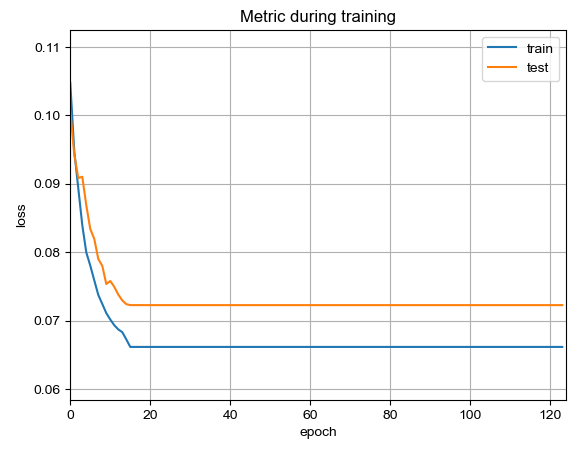

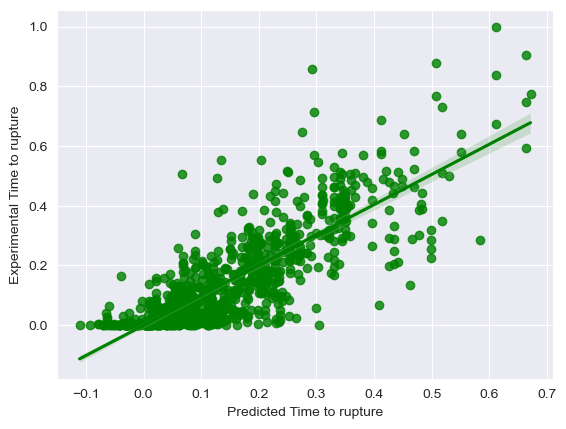

In [165]:
import lightgbm as lgb
import seaborn as sns
#load the parameters of BO
target = pd.read_excel('TRGAN200_BO_GBDT.xlsx')
colsample_bytree = target.at[1,'colsample_bytree']
learning_rate = target.at[1,'learning_rate']
max_bin = target.at[1,'max_bin']
max_depth = target.at[1,'max_depth']
max_bin = target.at[1,'max_bin']
min_child_samples = target.at[1,'min_child_samples']
min_child_weight = target.at[1,'min_child_weight']
min_split_gain= target.at[1,'min_split_gain']
n_estimators = target.at[1,'n_estimators']
num_leaves = target.at[1,'num_leaves']
reg_alpha = target.at[1,'reg_alpha']
reg_lambda = target.at[1,'reg_lambda']
subsample = target.at[1,'subsample']
params = {
    "num_leaves": int(round(num_leaves)),
    'min_child_samples':int(round(min_child_samples)),
    'learning_rate': learning_rate,
    'n_estimators': int(round(n_estimators)),
    'max_bin': int(round(max_bin)),
    'colsample_bytree': max(min(colsample_bytree, 1), 0),
    'subsample': max(min(subsample, 1), 0),
    'max_depth': int(round(max_depth)),
    'reg_lambda':  max(reg_lambda, 0),
    'reg_alpha': max(reg_alpha, 0),
    'min_split_gain': min_split_gain,
    'min_child_weight': min_child_weight,
    'objective': 'regression',
    'verbose': -1
              }
train_data = pd.read_excel(r'D:\creep rupture\TR+TS\数据增强特征筛选train.xlsx')
test_data = pd.read_excel(r'D:\creep rupture\TR+TS\数据增强特征筛选test.xlsx')
train_features = train_data.drop(columns=['Time to Rupture(h)'])
train_labels = train_data[['Time to Rupture(h)']]
test_features = test_data.drop(columns=['Time to Rupture(h)'])
test_labels = test_data[['Time to Rupture(h)']]
train_features = train_features.to_numpy()
train_labels = train_labels.to_numpy()
test_features = test_features.to_numpy()
test_labels = test_labels.to_numpy()
train_labels = train_labels.reshape(-1)
test_labels = test_labels.reshape(-1) 

model = LGBMRegressor(metric='mape', **params)
model.fit(train_features, train_labels, eval_set=[(test_features, test_labels), (train_features, train_labels)],
          eval_metric='mape')

evals_result = model.evals_result_
train_mape = evals_result['training']['mape']
valid_mape = evals_result['valid_0']['mape']

for epoch, (train_mape_value, valid_mape_value) in enumerate(zip(train_mape, valid_mape), start=1):
    print(f"[{epoch}] training's mape: {train_mape_value:.6f} valid_0's mape: {valid_mape_value:.6f}")
#plot the traiining history
lgb.plot_metric(model)
plt.ylabel('loss')
plt.xlabel ('epoch')
plt.legend(['train','test'])
folder_dir = 'Figures'
if not os.path.isdir(folder_dir):
  os.mkdir(folder_dir)
plt.savefig('Figures/GBDT_trainning history.png', format='png', dpi=300)
#plotting experimental results as a change of predicted TEC 
plt.figure()
predict = model.predict(train_features)
sns.set_style("darkgrid")
sns.regplot(x=predict, y=train_labels, color='g') 
plt.xlabel ('Predicted Time to rupture')
plt.ylabel('Experimental Time to rupture')
plt.savefig('Figures/GBDT_expriements and predict comparasion.png', format='png', dpi=300)
#save the models
folder_dir = 'Model'
if not os.path.isdir(folder_dir):
  os.mkdir(folder_dir)
net_name = 'Model/GAN200_GBDT.pt'
torch.save(net.state_dict(), net_name)


## PSO optimization for XGBoost

In [166]:
from pyswarm import pso
from sklearn.metrics import mean_squared_error

In [167]:
train_data=pd.read_excel(r'D:\creep rupture\TR+TS\GAN200train.xlsx')
test_data=pd.read_excel(r'D:\creep rupture\TR+TS\GAN200test.xlsx')
x_train = train_data.drop(columns=[ 'Time to Rupture(h)'])
y_train = train_data['Time to Rupture(h)']
x_test = test_data.drop(columns=['Time to Rupture(h)'])
y_test = test_data['Time to Rupture(h)']

In [168]:
def objective_func(particle_position):
    max_depth = int(particle_position[0])
    learning_rate = particle_position[1]
    n_estimators = int(particle_position[2])
    min_child_weight = int(particle_position[3])
    subsample = particle_position[4]
    gamma = particle_position[5]

    model = xgb.XGBRegressor(max_depth=max_depth,
                             learning_rate=learning_rate,
                             n_estimators=n_estimators,
                             min_child_weight=min_child_weight,
                             subsample=subsample,
                             gamma=gamma)
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    mse = mean_squared_error(y_test, y_pred)
    return mse

In [169]:
lb = [1, 0.001, 50, 1, 0.1, 0]
ub = [10, 0.5, 500, 10, 1, 1]

xopt, fopt = pso(objective_func, lb, ub, swarmsize=30, maxiter=100)
print('Found optimal solution: ', xopt)
print('Objective function at optimal solution: ', fopt)

Stopping search: Swarm best objective change less than 1e-08
Found optimal solution:  [4.92074609e+00 1.81063263e-01 3.76214122e+02 1.48690202e+00
 4.98292357e-01 0.00000000e+00]
Objective function at optimal solution:  0.001146752386983154


In [170]:
max_depth = int(xopt[0])
learning_rate = xopt[1]
n_estimators = int(xopt[2])
min_child_weight = int(xopt[3])
subsample = xopt[4]
gamma = xopt[5]

model_optimal = xgb.XGBRegressor(max_depth=max_depth,
                                 learning_rate=learning_rate,
                                 n_estimators=n_estimators,
                                 min_child_weight=min_child_weight,
                                 subsample=subsample,
                                 gamma=gamma)
model_optimal.fit(x_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=0.0, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.1810632634345647,
             max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=4, max_leaves=None,
             min_child_weight=1, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=376, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

In [172]:
from sklearn.metrics import mean_absolute_error, r2_score

# 预测 x_test
y_pred = model_optimal.predict(x_test)

# 评估模型性能
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.5f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"R2 Score: {r2:.2f}")

Mean Squared Error (MSE): 0.00115
Mean Absolute Error (MAE): 0.02
R2 Score: 0.96


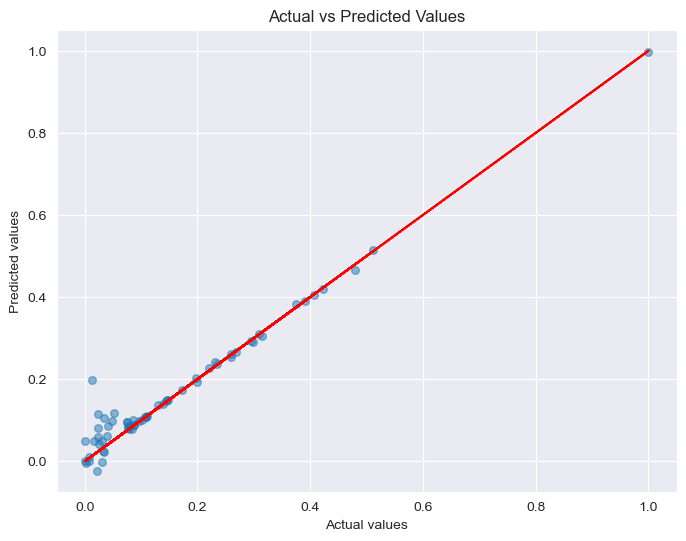

In [173]:
import matplotlib.pyplot as plt

# Draw scatter plot
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, s=30, alpha=0.5)
plt.title('Actual vs Predicted Values')
plt.xlabel('Actual values')
plt.ylabel('Predicted values')

# Draw line for perfect predictions
plt.plot(y_test, y_test, 'r')

plt.show()

## PSO for GBDT

In [174]:
from sklearn.ensemble import GradientBoostingRegressor

def objective_func(particle_position):
    max_depth = int(particle_position[0])
    learning_rate = particle_position[1]
    n_estimators = int(particle_position[2])
    min_samples_split = int(particle_position[3])
    subsample = particle_position[4]

    model = GradientBoostingRegressor(max_depth=max_depth,
                                      learning_rate=learning_rate,
                                      n_estimators=n_estimators,
                                      min_samples_split=min_samples_split,
                                      subsample=subsample)
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    mse = mean_squared_error(y_test, y_pred)
    return mse

In [175]:
lb = [1, 0.001, 50, 2, 0.1]
ub = [10, 0.5, 500, 5, 1]

xopt, fopt = pso(objective_func, lb, ub, swarmsize=30, maxiter=100)
print('Found optimal solution: ', xopt)
print('Objective function at optimal solution: ', fopt)

Stopping search: maximum iterations reached --> 100
Found optimal solution:  [5.37148230e+00 2.38352860e-01 2.93412017e+02 3.34349196e+00
 6.09248395e-01]
Objective function at optimal solution:  0.0012538579810625894


In [176]:
max_depth = int(xopt[0])
learning_rate = xopt[1]
n_estimators = int(xopt[2])
min_samples_split = int(xopt[3])
subsample = xopt[4]

model_optimal = GradientBoostingRegressor(max_depth=max_depth,
                                          learning_rate=learning_rate,
                                          n_estimators=n_estimators,
                                          min_samples_split=min_samples_split,
                                          subsample=subsample)

model_optimal.fit(x_train, y_train)

GradientBoostingRegressor(learning_rate=0.23835286048438833, max_depth=5,
                          min_samples_split=3, n_estimators=293,
                          subsample=0.6092483954561141)

In [177]:
# 预测 x_test
y_pred = model_optimal.predict(x_test)

# 评估模型性能
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"R2 Score: {r2:.2f}")

Mean Squared Error (MSE): 0.00
Mean Absolute Error (MAE): 0.02
R2 Score: 0.93


## 特征筛选后
### data

In [179]:
train_data=pd.read_excel(r'D:\creep rupture\TR+TS\特征筛选GAN200train.xlsx')
test_data=pd.read_excel(r'D:\creep rupture\TR+TS\特征筛选GAN200test.xlsx')
x = train_data.drop(columns=[ 'Time to Rupture(h)'])
y = train_data['Time to Rupture(h)']
x_test = test_data.drop(columns=['Time to Rupture(h)'])
y_test = test_data['Time to Rupture(h)']

### RF

In [180]:
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score

rf = RandomForestRegressor()

# 进行交叉验证
scores = cross_val_score(rf, x, y, cv=10)
print("交叉验证得分: {}".format(scores))
print("平均交叉验证得分: {:.2f}".format(scores.mean()))
print("{:.2f}% (+/- {:.2f}%)".format(scores.mean() * 100, scores.std() * 100))

# 在整个训练集上拟合模型
rf.fit(x, y)

# 在测试集上进行预测
y_pred = rf.predict(x_test)

交叉验证得分: [0.60242632 0.74063235 0.77416165 0.82375929 0.5655606  0.74274387
 0.82463561 0.73625263 0.72811285 0.80059788]
平均交叉验证得分: 0.73
73.39% (+/- 8.26%)


### SVM

In [181]:
from sklearn.svm import SVR
from sklearn.model_selection import cross_val_score

svr = SVR()
scores = cross_val_score(svr, x, y, cv=10, scoring='r2')
print("交叉验证得分:", scores)
print("平均交叉验证得分: {:.2f}".format(scores.mean()))

# 在整个训练集上拟合模型
svr.fit(x, y)

# 在测试集上进行预测
y_pred = svr.predict(x_test)

交叉验证得分: [0.57737234 0.48014089 0.67002841 0.54955983 0.21546924 0.3877008
 0.49993325 0.48800851 0.5141029  0.59115314]
平均交叉验证得分: 0.50


### DT

In [182]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import cross_val_score

dt = DecisionTreeRegressor()
scores = cross_val_score(dt, x, y, cv=10, scoring='r2')
print("交叉验证得分:", scores)
print("平均交叉验证得分: {:.2f}".format(scores.mean()))

# 在整个训练集上拟合模型
dt.fit(x, y)

# 在测试集上进行预测
y_pred = dt.predict(x_test)

交叉验证得分: [ 0.2037655   0.9322105   0.81070074  0.73508113  0.73988012  0.70932841
  0.89053806  0.24350965 -0.03687337  0.19923473]
平均交叉验证得分: 0.54


### ANN

In [183]:
from tensorflow import keras
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense,Activation,Dropout
import pandas as pd
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

Epoch 1/500
9/9 - 1s - loss: 0.0529 - mean_squared_error: 0.0529 - val_loss: 0.0280 - val_mean_squared_error: 0.0280 - 1s/epoch - 114ms/step
Epoch 2/500
9/9 - 0s - loss: 0.0375 - mean_squared_error: 0.0375 - val_loss: 0.0268 - val_mean_squared_error: 0.0268 - 184ms/epoch - 20ms/step
Epoch 3/500
9/9 - 0s - loss: 0.0336 - mean_squared_error: 0.0336 - val_loss: 0.0264 - val_mean_squared_error: 0.0264 - 246ms/epoch - 27ms/step
Epoch 4/500
9/9 - 0s - loss: 0.0327 - mean_squared_error: 0.0327 - val_loss: 0.0260 - val_mean_squared_error: 0.0260 - 233ms/epoch - 26ms/step
Epoch 5/500
9/9 - 0s - loss: 0.0307 - mean_squared_error: 0.0307 - val_loss: 0.0250 - val_mean_squared_error: 0.0250 - 277ms/epoch - 31ms/step
Epoch 6/500
9/9 - 0s - loss: 0.0295 - mean_squared_error: 0.0295 - val_loss: 0.0240 - val_mean_squared_error: 0.0240 - 239ms/epoch - 27ms/step
Epoch 7/500
9/9 - 0s - loss: 0.0298 - mean_squared_error: 0.0298 - val_loss: 0.0235 - val_mean_squared_error: 0.0235 - 248ms/epoch - 28ms/step
E

Epoch 58/500
9/9 - 0s - loss: 0.0186 - mean_squared_error: 0.0186 - val_loss: 0.0179 - val_mean_squared_error: 0.0179 - 165ms/epoch - 18ms/step
Epoch 59/500
9/9 - 0s - loss: 0.0180 - mean_squared_error: 0.0180 - val_loss: 0.0180 - val_mean_squared_error: 0.0180 - 201ms/epoch - 22ms/step
Epoch 60/500
9/9 - 0s - loss: 0.0197 - mean_squared_error: 0.0197 - val_loss: 0.0175 - val_mean_squared_error: 0.0175 - 110ms/epoch - 12ms/step
Epoch 61/500
9/9 - 0s - loss: 0.0191 - mean_squared_error: 0.0191 - val_loss: 0.0174 - val_mean_squared_error: 0.0174 - 110ms/epoch - 12ms/step
Epoch 62/500
9/9 - 0s - loss: 0.0178 - mean_squared_error: 0.0178 - val_loss: 0.0176 - val_mean_squared_error: 0.0176 - 110ms/epoch - 12ms/step
Epoch 63/500
9/9 - 0s - loss: 0.0196 - mean_squared_error: 0.0196 - val_loss: 0.0183 - val_mean_squared_error: 0.0183 - 113ms/epoch - 13ms/step
Epoch 64/500
9/9 - 0s - loss: 0.0176 - mean_squared_error: 0.0176 - val_loss: 0.0175 - val_mean_squared_error: 0.0175 - 127ms/epoch - 14

Epoch 115/500
9/9 - 0s - loss: 0.0142 - mean_squared_error: 0.0142 - val_loss: 0.0137 - val_mean_squared_error: 0.0137 - 129ms/epoch - 14ms/step
Epoch 116/500
9/9 - 0s - loss: 0.0152 - mean_squared_error: 0.0152 - val_loss: 0.0145 - val_mean_squared_error: 0.0145 - 108ms/epoch - 12ms/step
Epoch 117/500
9/9 - 0s - loss: 0.0154 - mean_squared_error: 0.0154 - val_loss: 0.0141 - val_mean_squared_error: 0.0141 - 126ms/epoch - 14ms/step
Epoch 118/500
9/9 - 0s - loss: 0.0143 - mean_squared_error: 0.0143 - val_loss: 0.0141 - val_mean_squared_error: 0.0141 - 117ms/epoch - 13ms/step
Epoch 119/500
9/9 - 0s - loss: 0.0155 - mean_squared_error: 0.0155 - val_loss: 0.0142 - val_mean_squared_error: 0.0142 - 128ms/epoch - 14ms/step
Epoch 120/500
9/9 - 0s - loss: 0.0143 - mean_squared_error: 0.0143 - val_loss: 0.0137 - val_mean_squared_error: 0.0137 - 117ms/epoch - 13ms/step
Epoch 121/500
9/9 - 0s - loss: 0.0142 - mean_squared_error: 0.0142 - val_loss: 0.0138 - val_mean_squared_error: 0.0138 - 116ms/epo

Epoch 172/500
9/9 - 0s - loss: 0.0120 - mean_squared_error: 0.0120 - val_loss: 0.0106 - val_mean_squared_error: 0.0106 - 128ms/epoch - 14ms/step
Epoch 173/500
9/9 - 0s - loss: 0.0126 - mean_squared_error: 0.0126 - val_loss: 0.0109 - val_mean_squared_error: 0.0109 - 127ms/epoch - 14ms/step
Epoch 174/500
9/9 - 0s - loss: 0.0126 - mean_squared_error: 0.0126 - val_loss: 0.0107 - val_mean_squared_error: 0.0107 - 121ms/epoch - 13ms/step
Epoch 175/500
9/9 - 0s - loss: 0.0112 - mean_squared_error: 0.0112 - val_loss: 0.0105 - val_mean_squared_error: 0.0105 - 119ms/epoch - 13ms/step
Epoch 176/500
9/9 - 0s - loss: 0.0119 - mean_squared_error: 0.0119 - val_loss: 0.0095 - val_mean_squared_error: 0.0095 - 101ms/epoch - 11ms/step
Epoch 177/500
9/9 - 0s - loss: 0.0130 - mean_squared_error: 0.0130 - val_loss: 0.0101 - val_mean_squared_error: 0.0101 - 120ms/epoch - 13ms/step
Epoch 178/500
9/9 - 0s - loss: 0.0130 - mean_squared_error: 0.0130 - val_loss: 0.0100 - val_mean_squared_error: 0.0100 - 122ms/epo

Epoch 229/500
9/9 - 0s - loss: 0.0110 - mean_squared_error: 0.0110 - val_loss: 0.0090 - val_mean_squared_error: 0.0090 - 109ms/epoch - 12ms/step
Epoch 230/500
9/9 - 0s - loss: 0.0113 - mean_squared_error: 0.0113 - val_loss: 0.0082 - val_mean_squared_error: 0.0082 - 111ms/epoch - 12ms/step
Epoch 231/500
9/9 - 0s - loss: 0.0112 - mean_squared_error: 0.0112 - val_loss: 0.0083 - val_mean_squared_error: 0.0083 - 135ms/epoch - 15ms/step
Epoch 232/500
9/9 - 0s - loss: 0.0104 - mean_squared_error: 0.0104 - val_loss: 0.0080 - val_mean_squared_error: 0.0080 - 107ms/epoch - 12ms/step
Epoch 233/500
9/9 - 0s - loss: 0.0108 - mean_squared_error: 0.0108 - val_loss: 0.0079 - val_mean_squared_error: 0.0079 - 130ms/epoch - 14ms/step
Epoch 234/500
9/9 - 0s - loss: 0.0110 - mean_squared_error: 0.0110 - val_loss: 0.0084 - val_mean_squared_error: 0.0084 - 120ms/epoch - 13ms/step
Epoch 235/500
9/9 - 0s - loss: 0.0123 - mean_squared_error: 0.0123 - val_loss: 0.0078 - val_mean_squared_error: 0.0078 - 118ms/epo

Epoch 286/500
9/9 - 0s - loss: 0.0093 - mean_squared_error: 0.0093 - val_loss: 0.0069 - val_mean_squared_error: 0.0069 - 109ms/epoch - 12ms/step
Epoch 287/500
9/9 - 0s - loss: 0.0095 - mean_squared_error: 0.0095 - val_loss: 0.0071 - val_mean_squared_error: 0.0071 - 136ms/epoch - 15ms/step
Epoch 288/500
9/9 - 0s - loss: 0.0093 - mean_squared_error: 0.0093 - val_loss: 0.0077 - val_mean_squared_error: 0.0077 - 111ms/epoch - 12ms/step
Epoch 289/500
9/9 - 0s - loss: 0.0101 - mean_squared_error: 0.0101 - val_loss: 0.0067 - val_mean_squared_error: 0.0067 - 112ms/epoch - 12ms/step
Epoch 290/500
9/9 - 0s - loss: 0.0096 - mean_squared_error: 0.0096 - val_loss: 0.0063 - val_mean_squared_error: 0.0063 - 122ms/epoch - 14ms/step
Epoch 291/500
9/9 - 0s - loss: 0.0104 - mean_squared_error: 0.0104 - val_loss: 0.0068 - val_mean_squared_error: 0.0068 - 127ms/epoch - 14ms/step
Epoch 292/500
9/9 - 0s - loss: 0.0092 - mean_squared_error: 0.0092 - val_loss: 0.0076 - val_mean_squared_error: 0.0076 - 142ms/epo

Epoch 343/500
9/9 - 0s - loss: 0.0095 - mean_squared_error: 0.0095 - val_loss: 0.0054 - val_mean_squared_error: 0.0054 - 133ms/epoch - 15ms/step
Epoch 344/500
9/9 - 0s - loss: 0.0084 - mean_squared_error: 0.0084 - val_loss: 0.0051 - val_mean_squared_error: 0.0051 - 139ms/epoch - 15ms/step
Epoch 345/500
9/9 - 0s - loss: 0.0086 - mean_squared_error: 0.0086 - val_loss: 0.0064 - val_mean_squared_error: 0.0064 - 127ms/epoch - 14ms/step
Epoch 346/500
9/9 - 0s - loss: 0.0082 - mean_squared_error: 0.0082 - val_loss: 0.0061 - val_mean_squared_error: 0.0061 - 139ms/epoch - 15ms/step
Epoch 347/500
9/9 - 0s - loss: 0.0088 - mean_squared_error: 0.0088 - val_loss: 0.0061 - val_mean_squared_error: 0.0061 - 133ms/epoch - 15ms/step
Epoch 348/500
9/9 - 0s - loss: 0.0088 - mean_squared_error: 0.0088 - val_loss: 0.0059 - val_mean_squared_error: 0.0059 - 140ms/epoch - 16ms/step
Epoch 349/500
9/9 - 0s - loss: 0.0077 - mean_squared_error: 0.0077 - val_loss: 0.0058 - val_mean_squared_error: 0.0058 - 130ms/epo

Epoch 400/500
9/9 - 0s - loss: 0.0094 - mean_squared_error: 0.0094 - val_loss: 0.0054 - val_mean_squared_error: 0.0054 - 129ms/epoch - 14ms/step
Epoch 401/500
9/9 - 0s - loss: 0.0075 - mean_squared_error: 0.0075 - val_loss: 0.0048 - val_mean_squared_error: 0.0048 - 124ms/epoch - 14ms/step
Epoch 402/500
9/9 - 0s - loss: 0.0079 - mean_squared_error: 0.0079 - val_loss: 0.0061 - val_mean_squared_error: 0.0061 - 132ms/epoch - 15ms/step
Epoch 403/500
9/9 - 0s - loss: 0.0077 - mean_squared_error: 0.0077 - val_loss: 0.0062 - val_mean_squared_error: 0.0062 - 132ms/epoch - 15ms/step
Epoch 404/500
9/9 - 0s - loss: 0.0086 - mean_squared_error: 0.0086 - val_loss: 0.0052 - val_mean_squared_error: 0.0052 - 111ms/epoch - 12ms/step
Epoch 405/500
9/9 - 0s - loss: 0.0069 - mean_squared_error: 0.0069 - val_loss: 0.0042 - val_mean_squared_error: 0.0042 - 126ms/epoch - 14ms/step
Epoch 406/500
9/9 - 0s - loss: 0.0082 - mean_squared_error: 0.0082 - val_loss: 0.0051 - val_mean_squared_error: 0.0051 - 128ms/epo

Epoch 457/500
9/9 - 0s - loss: 0.0067 - mean_squared_error: 0.0067 - val_loss: 0.0039 - val_mean_squared_error: 0.0039 - 127ms/epoch - 14ms/step
Epoch 458/500
9/9 - 0s - loss: 0.0069 - mean_squared_error: 0.0069 - val_loss: 0.0043 - val_mean_squared_error: 0.0043 - 116ms/epoch - 13ms/step
Epoch 459/500
9/9 - 0s - loss: 0.0078 - mean_squared_error: 0.0078 - val_loss: 0.0040 - val_mean_squared_error: 0.0040 - 114ms/epoch - 13ms/step
Epoch 460/500
9/9 - 0s - loss: 0.0073 - mean_squared_error: 0.0073 - val_loss: 0.0053 - val_mean_squared_error: 0.0053 - 110ms/epoch - 12ms/step
Epoch 461/500
9/9 - 0s - loss: 0.0071 - mean_squared_error: 0.0071 - val_loss: 0.0047 - val_mean_squared_error: 0.0047 - 115ms/epoch - 13ms/step
Epoch 462/500
9/9 - 0s - loss: 0.0077 - mean_squared_error: 0.0077 - val_loss: 0.0047 - val_mean_squared_error: 0.0047 - 133ms/epoch - 15ms/step
Epoch 463/500
9/9 - 0s - loss: 0.0070 - mean_squared_error: 0.0070 - val_loss: 0.0035 - val_mean_squared_error: 0.0035 - 109ms/epo

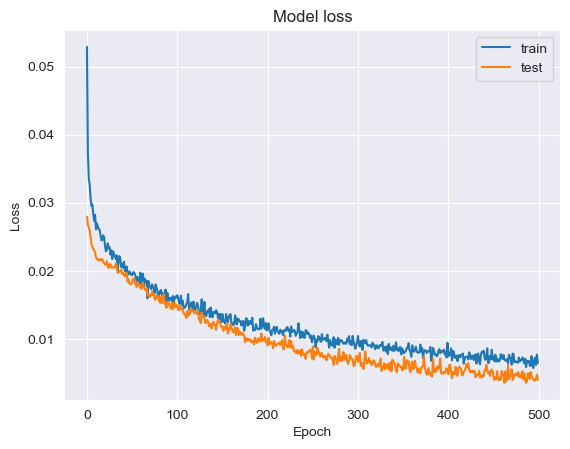

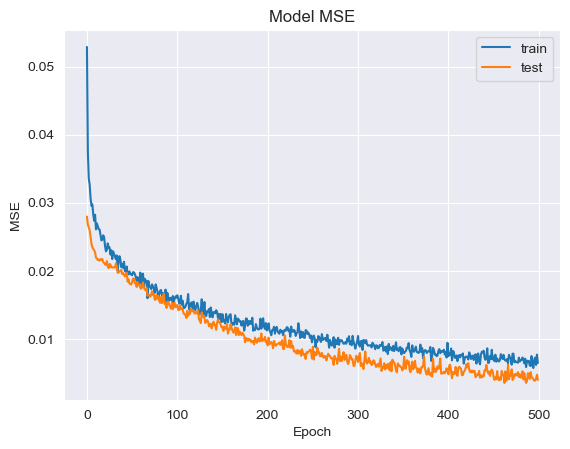

In [184]:
model = Sequential()  # 初始化
input = x.shape[1]
# 隐藏层128
model.add(Dense(128, input_shape=(input,)))  
model.add(Activation('relu'))
# Dropout层用于防止过拟合
model.add(Dropout(0.5))
# 隐藏层128
model.add(Dense(128))
model.add(Activation('relu'))

model.add(Dense(1))
model.add(Activation('linear'))  # 使用线性激活函数

# 使用高效的ADAM优化算法
rmsprop = tf.keras.optimizers.RMSprop(learning_rate=0.001, rho=0.9, epsilon=1e-08)
model.compile(loss='mean_squared_error', optimizer=rmsprop, metrics=['mean_squared_error'])

early_stopping = EarlyStopping(monitor='val_loss', patience=500, verbose=2)

# 训练
history = model.fit(x, y, epochs=500, batch_size=64, shuffle=False, verbose=2,
                   validation_data=(x_test, y_test), callbacks=[early_stopping])

# loss曲线
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.show()

# mse曲线
plt.plot(history.history['mean_squared_error'], label='train')
plt.plot(history.history['val_mean_squared_error'], label='test')
plt.title('Model MSE')
plt.ylabel('MSE')
plt.xlabel('Epoch')
plt.legend()
plt.show()

Epoch 1/500
5/5 - 2s - loss: 1.4966 - mean_squared_error: 1.4966 - val_loss: 0.1738 - val_mean_squared_error: 0.1738 - 2s/epoch - 326ms/step
Epoch 2/500
5/5 - 0s - loss: 0.7531 - mean_squared_error: 0.7531 - val_loss: 0.2549 - val_mean_squared_error: 0.2549 - 124ms/epoch - 25ms/step
Epoch 3/500
5/5 - 0s - loss: 0.5194 - mean_squared_error: 0.5194 - val_loss: 0.2474 - val_mean_squared_error: 0.2474 - 132ms/epoch - 26ms/step
Epoch 4/500
5/5 - 0s - loss: 0.4913 - mean_squared_error: 0.4913 - val_loss: 0.2210 - val_mean_squared_error: 0.2210 - 138ms/epoch - 28ms/step
Epoch 5/500
5/5 - 0s - loss: 0.4246 - mean_squared_error: 0.4246 - val_loss: 0.1492 - val_mean_squared_error: 0.1492 - 126ms/epoch - 25ms/step
Epoch 6/500
5/5 - 0s - loss: 0.3244 - mean_squared_error: 0.3244 - val_loss: 0.1767 - val_mean_squared_error: 0.1767 - 131ms/epoch - 26ms/step
Epoch 7/500
5/5 - 0s - loss: 0.3286 - mean_squared_error: 0.3286 - val_loss: 0.1361 - val_mean_squared_error: 0.1361 - 142ms/epoch - 28ms/step
E

Epoch 58/500
5/5 - 0s - loss: 0.0551 - mean_squared_error: 0.0551 - val_loss: 0.0400 - val_mean_squared_error: 0.0400 - 167ms/epoch - 33ms/step
Epoch 59/500
5/5 - 0s - loss: 0.0448 - mean_squared_error: 0.0448 - val_loss: 0.0573 - val_mean_squared_error: 0.0573 - 148ms/epoch - 30ms/step
Epoch 60/500
5/5 - 0s - loss: 0.0482 - mean_squared_error: 0.0482 - val_loss: 0.0296 - val_mean_squared_error: 0.0296 - 161ms/epoch - 32ms/step
Epoch 61/500
5/5 - 0s - loss: 0.0498 - mean_squared_error: 0.0498 - val_loss: 0.0385 - val_mean_squared_error: 0.0385 - 130ms/epoch - 26ms/step
Epoch 62/500
5/5 - 0s - loss: 0.0462 - mean_squared_error: 0.0462 - val_loss: 0.0562 - val_mean_squared_error: 0.0562 - 141ms/epoch - 28ms/step
Epoch 63/500
5/5 - 0s - loss: 0.0559 - mean_squared_error: 0.0559 - val_loss: 0.0560 - val_mean_squared_error: 0.0560 - 132ms/epoch - 26ms/step
Epoch 64/500
5/5 - 0s - loss: 0.0507 - mean_squared_error: 0.0507 - val_loss: 0.0317 - val_mean_squared_error: 0.0317 - 139ms/epoch - 28

Epoch 115/500
5/5 - 0s - loss: 0.0263 - mean_squared_error: 0.0263 - val_loss: 0.0344 - val_mean_squared_error: 0.0344 - 139ms/epoch - 28ms/step
Epoch 116/500
5/5 - 0s - loss: 0.0377 - mean_squared_error: 0.0377 - val_loss: 0.0242 - val_mean_squared_error: 0.0242 - 149ms/epoch - 30ms/step
Epoch 117/500
5/5 - 0s - loss: 0.0254 - mean_squared_error: 0.0254 - val_loss: 0.0261 - val_mean_squared_error: 0.0261 - 151ms/epoch - 30ms/step
Epoch 118/500
5/5 - 0s - loss: 0.0263 - mean_squared_error: 0.0263 - val_loss: 0.0478 - val_mean_squared_error: 0.0478 - 142ms/epoch - 28ms/step
Epoch 119/500
5/5 - 0s - loss: 0.0352 - mean_squared_error: 0.0352 - val_loss: 0.0473 - val_mean_squared_error: 0.0473 - 148ms/epoch - 30ms/step
Epoch 120/500
5/5 - 0s - loss: 0.0316 - mean_squared_error: 0.0316 - val_loss: 0.0214 - val_mean_squared_error: 0.0214 - 145ms/epoch - 29ms/step
Epoch 121/500
5/5 - 0s - loss: 0.0251 - mean_squared_error: 0.0251 - val_loss: 0.0248 - val_mean_squared_error: 0.0248 - 156ms/epo

Epoch 172/500
5/5 - 0s - loss: 0.0242 - mean_squared_error: 0.0242 - val_loss: 0.0258 - val_mean_squared_error: 0.0258 - 152ms/epoch - 30ms/step
Epoch 173/500
5/5 - 0s - loss: 0.0218 - mean_squared_error: 0.0218 - val_loss: 0.0213 - val_mean_squared_error: 0.0213 - 152ms/epoch - 30ms/step
Epoch 174/500
5/5 - 0s - loss: 0.0216 - mean_squared_error: 0.0216 - val_loss: 0.0325 - val_mean_squared_error: 0.0325 - 141ms/epoch - 28ms/step
Epoch 175/500
5/5 - 0s - loss: 0.0245 - mean_squared_error: 0.0245 - val_loss: 0.0298 - val_mean_squared_error: 0.0298 - 136ms/epoch - 27ms/step
Epoch 176/500
5/5 - 0s - loss: 0.0200 - mean_squared_error: 0.0200 - val_loss: 0.0201 - val_mean_squared_error: 0.0201 - 162ms/epoch - 32ms/step
Epoch 177/500
5/5 - 0s - loss: 0.0191 - mean_squared_error: 0.0191 - val_loss: 0.0168 - val_mean_squared_error: 0.0168 - 175ms/epoch - 35ms/step
Epoch 178/500
5/5 - 0s - loss: 0.0212 - mean_squared_error: 0.0212 - val_loss: 0.0263 - val_mean_squared_error: 0.0263 - 147ms/epo

Epoch 229/500
5/5 - 0s - loss: 0.0230 - mean_squared_error: 0.0230 - val_loss: 0.0162 - val_mean_squared_error: 0.0162 - 146ms/epoch - 29ms/step
Epoch 230/500
5/5 - 0s - loss: 0.0174 - mean_squared_error: 0.0174 - val_loss: 0.0201 - val_mean_squared_error: 0.0201 - 153ms/epoch - 31ms/step
Epoch 231/500
5/5 - 0s - loss: 0.0195 - mean_squared_error: 0.0195 - val_loss: 0.0147 - val_mean_squared_error: 0.0147 - 166ms/epoch - 33ms/step
Epoch 232/500
5/5 - 0s - loss: 0.0168 - mean_squared_error: 0.0168 - val_loss: 0.0134 - val_mean_squared_error: 0.0134 - 152ms/epoch - 30ms/step
Epoch 233/500
5/5 - 0s - loss: 0.0193 - mean_squared_error: 0.0193 - val_loss: 0.0307 - val_mean_squared_error: 0.0307 - 148ms/epoch - 30ms/step
Epoch 234/500
5/5 - 0s - loss: 0.0230 - mean_squared_error: 0.0230 - val_loss: 0.0150 - val_mean_squared_error: 0.0150 - 169ms/epoch - 34ms/step
Epoch 235/500
5/5 - 0s - loss: 0.0164 - mean_squared_error: 0.0164 - val_loss: 0.0157 - val_mean_squared_error: 0.0157 - 152ms/epo

Epoch 286/500
5/5 - 0s - loss: 0.0195 - mean_squared_error: 0.0195 - val_loss: 0.0122 - val_mean_squared_error: 0.0122 - 153ms/epoch - 31ms/step
Epoch 287/500
5/5 - 0s - loss: 0.0160 - mean_squared_error: 0.0160 - val_loss: 0.0134 - val_mean_squared_error: 0.0134 - 150ms/epoch - 30ms/step
Epoch 288/500
5/5 - 0s - loss: 0.0177 - mean_squared_error: 0.0177 - val_loss: 0.0178 - val_mean_squared_error: 0.0178 - 153ms/epoch - 31ms/step
Epoch 289/500
5/5 - 0s - loss: 0.0189 - mean_squared_error: 0.0189 - val_loss: 0.0215 - val_mean_squared_error: 0.0215 - 147ms/epoch - 29ms/step
Epoch 290/500
5/5 - 0s - loss: 0.0182 - mean_squared_error: 0.0182 - val_loss: 0.0123 - val_mean_squared_error: 0.0123 - 131ms/epoch - 26ms/step
Epoch 291/500
5/5 - 0s - loss: 0.0150 - mean_squared_error: 0.0150 - val_loss: 0.0151 - val_mean_squared_error: 0.0151 - 140ms/epoch - 28ms/step
Epoch 292/500
5/5 - 0s - loss: 0.0177 - mean_squared_error: 0.0177 - val_loss: 0.0154 - val_mean_squared_error: 0.0154 - 151ms/epo

Epoch 343/500
5/5 - 0s - loss: 0.0179 - mean_squared_error: 0.0179 - val_loss: 0.0163 - val_mean_squared_error: 0.0163 - 140ms/epoch - 28ms/step
Epoch 344/500
5/5 - 0s - loss: 0.0163 - mean_squared_error: 0.0163 - val_loss: 0.0120 - val_mean_squared_error: 0.0120 - 137ms/epoch - 27ms/step
Epoch 345/500
5/5 - 0s - loss: 0.0136 - mean_squared_error: 0.0136 - val_loss: 0.0148 - val_mean_squared_error: 0.0148 - 164ms/epoch - 33ms/step
Epoch 346/500
5/5 - 0s - loss: 0.0149 - mean_squared_error: 0.0149 - val_loss: 0.0159 - val_mean_squared_error: 0.0159 - 134ms/epoch - 27ms/step
Epoch 347/500
5/5 - 0s - loss: 0.0182 - mean_squared_error: 0.0182 - val_loss: 0.0151 - val_mean_squared_error: 0.0151 - 144ms/epoch - 29ms/step
Epoch 348/500
5/5 - 0s - loss: 0.0172 - mean_squared_error: 0.0172 - val_loss: 0.0111 - val_mean_squared_error: 0.0111 - 137ms/epoch - 27ms/step
Epoch 349/500
5/5 - 0s - loss: 0.0156 - mean_squared_error: 0.0156 - val_loss: 0.0118 - val_mean_squared_error: 0.0118 - 136ms/epo

Epoch 400/500
5/5 - 0s - loss: 0.0130 - mean_squared_error: 0.0130 - val_loss: 0.0116 - val_mean_squared_error: 0.0116 - 145ms/epoch - 29ms/step
Epoch 401/500
5/5 - 0s - loss: 0.0158 - mean_squared_error: 0.0158 - val_loss: 0.0170 - val_mean_squared_error: 0.0170 - 144ms/epoch - 29ms/step
Epoch 402/500
5/5 - 0s - loss: 0.0159 - mean_squared_error: 0.0159 - val_loss: 0.0162 - val_mean_squared_error: 0.0162 - 139ms/epoch - 28ms/step
Epoch 403/500
5/5 - 0s - loss: 0.0146 - mean_squared_error: 0.0146 - val_loss: 0.0125 - val_mean_squared_error: 0.0125 - 156ms/epoch - 31ms/step
Epoch 404/500
5/5 - 0s - loss: 0.0157 - mean_squared_error: 0.0157 - val_loss: 0.0144 - val_mean_squared_error: 0.0144 - 151ms/epoch - 30ms/step
Epoch 405/500
5/5 - 0s - loss: 0.0142 - mean_squared_error: 0.0142 - val_loss: 0.0124 - val_mean_squared_error: 0.0124 - 151ms/epoch - 30ms/step
Epoch 406/500
5/5 - 0s - loss: 0.0142 - mean_squared_error: 0.0142 - val_loss: 0.0167 - val_mean_squared_error: 0.0167 - 149ms/epo

Epoch 457/500
5/5 - 0s - loss: 0.0157 - mean_squared_error: 0.0157 - val_loss: 0.0106 - val_mean_squared_error: 0.0106 - 142ms/epoch - 28ms/step
Epoch 458/500
5/5 - 0s - loss: 0.0129 - mean_squared_error: 0.0129 - val_loss: 0.0163 - val_mean_squared_error: 0.0163 - 159ms/epoch - 32ms/step
Epoch 459/500
5/5 - 0s - loss: 0.0156 - mean_squared_error: 0.0156 - val_loss: 0.0100 - val_mean_squared_error: 0.0100 - 192ms/epoch - 38ms/step
Epoch 460/500
5/5 - 0s - loss: 0.0142 - mean_squared_error: 0.0142 - val_loss: 0.0116 - val_mean_squared_error: 0.0116 - 130ms/epoch - 26ms/step
Epoch 461/500
5/5 - 0s - loss: 0.0134 - mean_squared_error: 0.0134 - val_loss: 0.0098 - val_mean_squared_error: 0.0098 - 142ms/epoch - 28ms/step
Epoch 462/500
5/5 - 0s - loss: 0.0137 - mean_squared_error: 0.0137 - val_loss: 0.0107 - val_mean_squared_error: 0.0107 - 154ms/epoch - 31ms/step
Epoch 463/500
5/5 - 0s - loss: 0.0166 - mean_squared_error: 0.0166 - val_loss: 0.0162 - val_mean_squared_error: 0.0162 - 149ms/epo

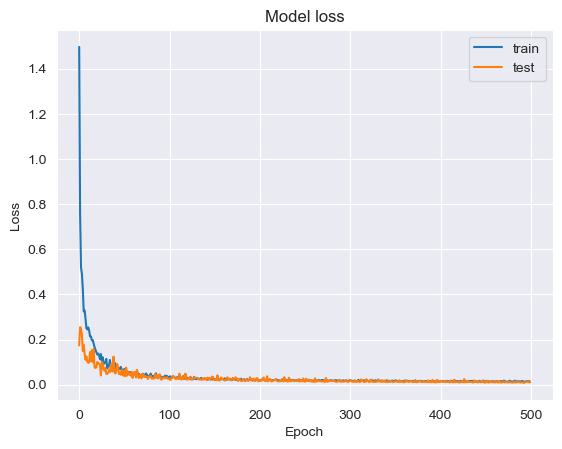

2/2 [==============================] - 0s 8ms/step
MSE: 0.01
R2: 0.56
Epoch 1/500
5/5 - 2s - loss: 2.0505 - mean_squared_error: 2.0505 - val_loss: 0.2761 - val_mean_squared_error: 0.2761 - 2s/epoch - 359ms/step
Epoch 2/500
5/5 - 0s - loss: 0.8600 - mean_squared_error: 0.8600 - val_loss: 0.5869 - val_mean_squared_error: 0.5869 - 120ms/epoch - 24ms/step
Epoch 3/500
5/5 - 0s - loss: 0.6445 - mean_squared_error: 0.6445 - val_loss: 0.5577 - val_mean_squared_error: 0.5577 - 130ms/epoch - 26ms/step
Epoch 4/500
5/5 - 0s - loss: 0.5531 - mean_squared_error: 0.5531 - val_loss: 0.4924 - val_mean_squared_error: 0.4924 - 157ms/epoch - 31ms/step
Epoch 5/500
5/5 - 0s - loss: 0.4704 - mean_squared_error: 0.4704 - val_loss: 0.3790 - val_mean_squared_error: 0.3790 - 124ms/epoch - 25ms/step
Epoch 6/500
5/5 - 0s - loss: 0.4204 - mean_squared_error: 0.4204 - val_loss: 0.2596 - val_mean_squared_error: 0.2596 - 134ms/epoch - 27ms/step
Epoch 7/500
5/5 - 0s - loss: 0.3383 - mean_squared_error: 0.3383 - val_los

Epoch 58/500
5/5 - 0s - loss: 0.0381 - mean_squared_error: 0.0381 - val_loss: 0.0225 - val_mean_squared_error: 0.0225 - 137ms/epoch - 27ms/step
Epoch 59/500
5/5 - 0s - loss: 0.0467 - mean_squared_error: 0.0467 - val_loss: 0.0215 - val_mean_squared_error: 0.0215 - 139ms/epoch - 28ms/step
Epoch 60/500
5/5 - 0s - loss: 0.0370 - mean_squared_error: 0.0370 - val_loss: 0.0237 - val_mean_squared_error: 0.0237 - 158ms/epoch - 32ms/step
Epoch 61/500
5/5 - 0s - loss: 0.0346 - mean_squared_error: 0.0346 - val_loss: 0.0558 - val_mean_squared_error: 0.0558 - 144ms/epoch - 29ms/step
Epoch 62/500
5/5 - 0s - loss: 0.0488 - mean_squared_error: 0.0488 - val_loss: 0.0374 - val_mean_squared_error: 0.0374 - 145ms/epoch - 29ms/step
Epoch 63/500
5/5 - 0s - loss: 0.0413 - mean_squared_error: 0.0413 - val_loss: 0.0237 - val_mean_squared_error: 0.0237 - 130ms/epoch - 26ms/step
Epoch 64/500
5/5 - 0s - loss: 0.0350 - mean_squared_error: 0.0350 - val_loss: 0.0288 - val_mean_squared_error: 0.0288 - 131ms/epoch - 26

Epoch 115/500
5/5 - 0s - loss: 0.0279 - mean_squared_error: 0.0279 - val_loss: 0.0242 - val_mean_squared_error: 0.0242 - 145ms/epoch - 29ms/step
Epoch 116/500
5/5 - 0s - loss: 0.0215 - mean_squared_error: 0.0215 - val_loss: 0.0341 - val_mean_squared_error: 0.0341 - 139ms/epoch - 28ms/step
Epoch 117/500
5/5 - 0s - loss: 0.0243 - mean_squared_error: 0.0243 - val_loss: 0.0317 - val_mean_squared_error: 0.0317 - 142ms/epoch - 28ms/step
Epoch 118/500
5/5 - 0s - loss: 0.0260 - mean_squared_error: 0.0260 - val_loss: 0.0150 - val_mean_squared_error: 0.0150 - 148ms/epoch - 30ms/step
Epoch 119/500
5/5 - 0s - loss: 0.0216 - mean_squared_error: 0.0216 - val_loss: 0.0177 - val_mean_squared_error: 0.0177 - 136ms/epoch - 27ms/step
Epoch 120/500
5/5 - 0s - loss: 0.0227 - mean_squared_error: 0.0227 - val_loss: 0.0264 - val_mean_squared_error: 0.0264 - 145ms/epoch - 29ms/step
Epoch 121/500
5/5 - 0s - loss: 0.0354 - mean_squared_error: 0.0354 - val_loss: 0.0267 - val_mean_squared_error: 0.0267 - 140ms/epo

Epoch 172/500
5/5 - 0s - loss: 0.0192 - mean_squared_error: 0.0192 - val_loss: 0.0172 - val_mean_squared_error: 0.0172 - 151ms/epoch - 30ms/step
Epoch 173/500
5/5 - 0s - loss: 0.0189 - mean_squared_error: 0.0189 - val_loss: 0.0172 - val_mean_squared_error: 0.0172 - 142ms/epoch - 28ms/step
Epoch 174/500
5/5 - 0s - loss: 0.0184 - mean_squared_error: 0.0184 - val_loss: 0.0156 - val_mean_squared_error: 0.0156 - 144ms/epoch - 29ms/step
Epoch 175/500
5/5 - 0s - loss: 0.0207 - mean_squared_error: 0.0207 - val_loss: 0.0278 - val_mean_squared_error: 0.0278 - 145ms/epoch - 29ms/step
Epoch 176/500
5/5 - 0s - loss: 0.0211 - mean_squared_error: 0.0211 - val_loss: 0.0409 - val_mean_squared_error: 0.0409 - 165ms/epoch - 33ms/step
Epoch 177/500
5/5 - 0s - loss: 0.0253 - mean_squared_error: 0.0253 - val_loss: 0.0147 - val_mean_squared_error: 0.0147 - 149ms/epoch - 30ms/step
Epoch 178/500
5/5 - 0s - loss: 0.0181 - mean_squared_error: 0.0181 - val_loss: 0.0156 - val_mean_squared_error: 0.0156 - 143ms/epo

Epoch 229/500
5/5 - 0s - loss: 0.0201 - mean_squared_error: 0.0201 - val_loss: 0.0258 - val_mean_squared_error: 0.0258 - 151ms/epoch - 30ms/step
Epoch 230/500
5/5 - 0s - loss: 0.0187 - mean_squared_error: 0.0187 - val_loss: 0.0165 - val_mean_squared_error: 0.0165 - 150ms/epoch - 30ms/step
Epoch 231/500
5/5 - 0s - loss: 0.0160 - mean_squared_error: 0.0160 - val_loss: 0.0130 - val_mean_squared_error: 0.0130 - 151ms/epoch - 30ms/step
Epoch 232/500
5/5 - 0s - loss: 0.0166 - mean_squared_error: 0.0166 - val_loss: 0.0147 - val_mean_squared_error: 0.0147 - 169ms/epoch - 34ms/step
Epoch 233/500
5/5 - 0s - loss: 0.0201 - mean_squared_error: 0.0201 - val_loss: 0.0188 - val_mean_squared_error: 0.0188 - 151ms/epoch - 30ms/step
Epoch 234/500
5/5 - 0s - loss: 0.0177 - mean_squared_error: 0.0177 - val_loss: 0.0168 - val_mean_squared_error: 0.0168 - 152ms/epoch - 30ms/step
Epoch 235/500
5/5 - 0s - loss: 0.0186 - mean_squared_error: 0.0186 - val_loss: 0.0243 - val_mean_squared_error: 0.0243 - 152ms/epo

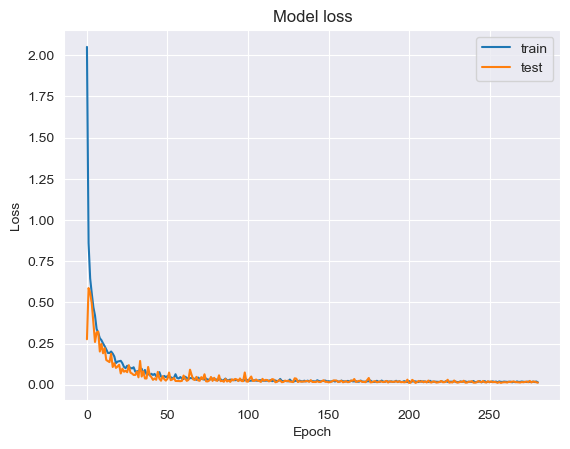

2/2 [==============================] - 0s 8ms/step
MSE: 0.01
R2: 0.55
Epoch 1/500
5/5 - 2s - loss: 1.7681 - mean_squared_error: 1.7681 - val_loss: 0.3676 - val_mean_squared_error: 0.3676 - 2s/epoch - 333ms/step
Epoch 2/500
5/5 - 0s - loss: 0.9125 - mean_squared_error: 0.9125 - val_loss: 0.6603 - val_mean_squared_error: 0.6603 - 155ms/epoch - 31ms/step
Epoch 3/500
5/5 - 0s - loss: 0.6063 - mean_squared_error: 0.6063 - val_loss: 0.6888 - val_mean_squared_error: 0.6888 - 138ms/epoch - 28ms/step
Epoch 4/500
5/5 - 0s - loss: 0.5467 - mean_squared_error: 0.5467 - val_loss: 0.4740 - val_mean_squared_error: 0.4740 - 137ms/epoch - 27ms/step
Epoch 5/500
5/5 - 0s - loss: 0.4719 - mean_squared_error: 0.4719 - val_loss: 0.3291 - val_mean_squared_error: 0.3291 - 126ms/epoch - 25ms/step
Epoch 6/500
5/5 - 0s - loss: 0.3674 - mean_squared_error: 0.3674 - val_loss: 0.2466 - val_mean_squared_error: 0.2466 - 130ms/epoch - 26ms/step
Epoch 7/500
5/5 - 0s - loss: 0.3393 - mean_squared_error: 0.3393 - val_los

Epoch 58/500
5/5 - 0s - loss: 0.0385 - mean_squared_error: 0.0385 - val_loss: 0.0223 - val_mean_squared_error: 0.0223 - 164ms/epoch - 33ms/step
Epoch 59/500
5/5 - 0s - loss: 0.0439 - mean_squared_error: 0.0439 - val_loss: 0.0541 - val_mean_squared_error: 0.0541 - 175ms/epoch - 35ms/step
Epoch 60/500
5/5 - 0s - loss: 0.0399 - mean_squared_error: 0.0399 - val_loss: 0.0301 - val_mean_squared_error: 0.0301 - 186ms/epoch - 37ms/step
Epoch 61/500
5/5 - 0s - loss: 0.0483 - mean_squared_error: 0.0483 - val_loss: 0.0288 - val_mean_squared_error: 0.0288 - 153ms/epoch - 31ms/step
Epoch 62/500
5/5 - 0s - loss: 0.0345 - mean_squared_error: 0.0345 - val_loss: 0.0372 - val_mean_squared_error: 0.0372 - 150ms/epoch - 30ms/step
Epoch 63/500
5/5 - 0s - loss: 0.0453 - mean_squared_error: 0.0453 - val_loss: 0.0593 - val_mean_squared_error: 0.0593 - 186ms/epoch - 37ms/step
Epoch 64/500
5/5 - 0s - loss: 0.0433 - mean_squared_error: 0.0433 - val_loss: 0.0252 - val_mean_squared_error: 0.0252 - 153ms/epoch - 31

Epoch 115/500
5/5 - 0s - loss: 0.0219 - mean_squared_error: 0.0219 - val_loss: 0.0303 - val_mean_squared_error: 0.0303 - 183ms/epoch - 37ms/step
Epoch 116/500
5/5 - 0s - loss: 0.0294 - mean_squared_error: 0.0294 - val_loss: 0.0360 - val_mean_squared_error: 0.0360 - 150ms/epoch - 30ms/step
Epoch 117/500
5/5 - 0s - loss: 0.0257 - mean_squared_error: 0.0257 - val_loss: 0.0186 - val_mean_squared_error: 0.0186 - 174ms/epoch - 35ms/step
Epoch 118/500
5/5 - 0s - loss: 0.0229 - mean_squared_error: 0.0229 - val_loss: 0.0154 - val_mean_squared_error: 0.0154 - 163ms/epoch - 33ms/step
Epoch 119/500
5/5 - 0s - loss: 0.0225 - mean_squared_error: 0.0225 - val_loss: 0.0198 - val_mean_squared_error: 0.0198 - 158ms/epoch - 32ms/step
Epoch 120/500
5/5 - 0s - loss: 0.0211 - mean_squared_error: 0.0211 - val_loss: 0.0230 - val_mean_squared_error: 0.0230 - 166ms/epoch - 33ms/step
Epoch 121/500
5/5 - 0s - loss: 0.0205 - mean_squared_error: 0.0205 - val_loss: 0.0228 - val_mean_squared_error: 0.0228 - 158ms/epo

Epoch 172/500
5/5 - 0s - loss: 0.0248 - mean_squared_error: 0.0248 - val_loss: 0.0146 - val_mean_squared_error: 0.0146 - 135ms/epoch - 27ms/step
Epoch 173/500
5/5 - 0s - loss: 0.0186 - mean_squared_error: 0.0186 - val_loss: 0.0155 - val_mean_squared_error: 0.0155 - 141ms/epoch - 28ms/step
Epoch 174/500
5/5 - 0s - loss: 0.0175 - mean_squared_error: 0.0175 - val_loss: 0.0135 - val_mean_squared_error: 0.0135 - 134ms/epoch - 27ms/step
Epoch 175/500
5/5 - 0s - loss: 0.0210 - mean_squared_error: 0.0210 - val_loss: 0.0230 - val_mean_squared_error: 0.0230 - 131ms/epoch - 26ms/step
Epoch 176/500
5/5 - 0s - loss: 0.0188 - mean_squared_error: 0.0188 - val_loss: 0.0139 - val_mean_squared_error: 0.0139 - 134ms/epoch - 27ms/step
Epoch 177/500
5/5 - 0s - loss: 0.0167 - mean_squared_error: 0.0167 - val_loss: 0.0165 - val_mean_squared_error: 0.0165 - 136ms/epoch - 27ms/step
Epoch 178/500
5/5 - 0s - loss: 0.0197 - mean_squared_error: 0.0197 - val_loss: 0.0270 - val_mean_squared_error: 0.0270 - 136ms/epo

Epoch 229/500
5/5 - 0s - loss: 0.0157 - mean_squared_error: 0.0157 - val_loss: 0.0110 - val_mean_squared_error: 0.0110 - 130ms/epoch - 26ms/step
Epoch 230/500
5/5 - 0s - loss: 0.0156 - mean_squared_error: 0.0156 - val_loss: 0.0099 - val_mean_squared_error: 0.0099 - 137ms/epoch - 27ms/step
Epoch 231/500
5/5 - 0s - loss: 0.0200 - mean_squared_error: 0.0200 - val_loss: 0.0192 - val_mean_squared_error: 0.0192 - 136ms/epoch - 27ms/step
Epoch 232/500
5/5 - 0s - loss: 0.0189 - mean_squared_error: 0.0189 - val_loss: 0.0125 - val_mean_squared_error: 0.0125 - 130ms/epoch - 26ms/step
Epoch 233/500
5/5 - 0s - loss: 0.0156 - mean_squared_error: 0.0156 - val_loss: 0.0127 - val_mean_squared_error: 0.0127 - 117ms/epoch - 23ms/step
Epoch 234/500
5/5 - 0s - loss: 0.0184 - mean_squared_error: 0.0184 - val_loss: 0.0140 - val_mean_squared_error: 0.0140 - 135ms/epoch - 27ms/step
Epoch 235/500
5/5 - 0s - loss: 0.0165 - mean_squared_error: 0.0165 - val_loss: 0.0101 - val_mean_squared_error: 0.0101 - 131ms/epo

Epoch 286/500
5/5 - 0s - loss: 0.0186 - mean_squared_error: 0.0186 - val_loss: 0.0102 - val_mean_squared_error: 0.0102 - 156ms/epoch - 31ms/step
Epoch 287/500
5/5 - 0s - loss: 0.0154 - mean_squared_error: 0.0154 - val_loss: 0.0104 - val_mean_squared_error: 0.0104 - 146ms/epoch - 29ms/step
Epoch 288/500
5/5 - 0s - loss: 0.0167 - mean_squared_error: 0.0167 - val_loss: 0.0093 - val_mean_squared_error: 0.0093 - 136ms/epoch - 27ms/step
Epoch 289/500
5/5 - 0s - loss: 0.0141 - mean_squared_error: 0.0141 - val_loss: 0.0094 - val_mean_squared_error: 0.0094 - 139ms/epoch - 28ms/step
Epoch 290/500
5/5 - 0s - loss: 0.0166 - mean_squared_error: 0.0166 - val_loss: 0.0139 - val_mean_squared_error: 0.0139 - 150ms/epoch - 30ms/step
Epoch 291/500
5/5 - 0s - loss: 0.0149 - mean_squared_error: 0.0149 - val_loss: 0.0099 - val_mean_squared_error: 0.0099 - 142ms/epoch - 28ms/step
Epoch 292/500
5/5 - 0s - loss: 0.0161 - mean_squared_error: 0.0161 - val_loss: 0.0293 - val_mean_squared_error: 0.0293 - 126ms/epo

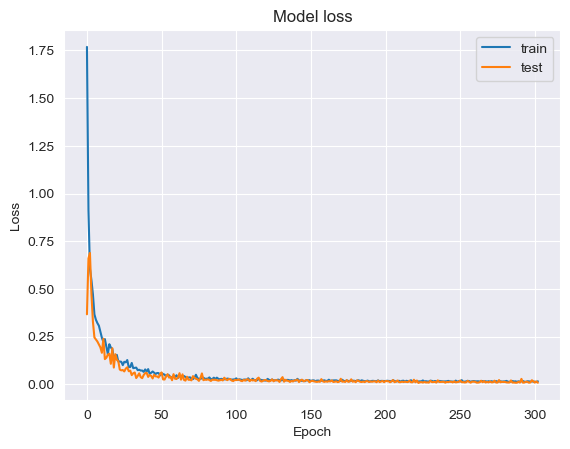

2/2 [==============================] - 0s 0s/step
MSE: 0.01
R2: 0.68
Epoch 1/500
5/5 - 2s - loss: 1.3513 - mean_squared_error: 1.3513 - val_loss: 0.0375 - val_mean_squared_error: 0.0375 - 2s/epoch - 308ms/step
Epoch 2/500
5/5 - 0s - loss: 0.6949 - mean_squared_error: 0.6949 - val_loss: 0.0812 - val_mean_squared_error: 0.0812 - 130ms/epoch - 26ms/step
Epoch 3/500
5/5 - 0s - loss: 0.5688 - mean_squared_error: 0.5688 - val_loss: 0.0870 - val_mean_squared_error: 0.0870 - 125ms/epoch - 25ms/step
Epoch 4/500
5/5 - 0s - loss: 0.4800 - mean_squared_error: 0.4800 - val_loss: 0.0897 - val_mean_squared_error: 0.0897 - 141ms/epoch - 28ms/step
Epoch 5/500
5/5 - 0s - loss: 0.4292 - mean_squared_error: 0.4292 - val_loss: 0.0935 - val_mean_squared_error: 0.0935 - 157ms/epoch - 31ms/step
Epoch 6/500
5/5 - 0s - loss: 0.3584 - mean_squared_error: 0.3584 - val_loss: 0.0888 - val_mean_squared_error: 0.0888 - 141ms/epoch - 28ms/step
Epoch 7/500
5/5 - 0s - loss: 0.3218 - mean_squared_error: 0.3218 - val_loss

Epoch 58/500
5/5 - 0s - loss: 0.0454 - mean_squared_error: 0.0454 - val_loss: 0.0334 - val_mean_squared_error: 0.0334 - 128ms/epoch - 26ms/step
Epoch 59/500
5/5 - 0s - loss: 0.0586 - mean_squared_error: 0.0586 - val_loss: 0.0334 - val_mean_squared_error: 0.0334 - 128ms/epoch - 26ms/step
Epoch 60/500
5/5 - 0s - loss: 0.0424 - mean_squared_error: 0.0424 - val_loss: 0.0419 - val_mean_squared_error: 0.0419 - 116ms/epoch - 23ms/step
Epoch 61/500
5/5 - 0s - loss: 0.0424 - mean_squared_error: 0.0424 - val_loss: 0.0299 - val_mean_squared_error: 0.0299 - 159ms/epoch - 32ms/step
Epoch 62/500
5/5 - 0s - loss: 0.0368 - mean_squared_error: 0.0368 - val_loss: 0.0306 - val_mean_squared_error: 0.0306 - 129ms/epoch - 26ms/step
Epoch 63/500
5/5 - 0s - loss: 0.0424 - mean_squared_error: 0.0424 - val_loss: 0.0572 - val_mean_squared_error: 0.0572 - 124ms/epoch - 25ms/step
Epoch 64/500
5/5 - 0s - loss: 0.0518 - mean_squared_error: 0.0518 - val_loss: 0.0292 - val_mean_squared_error: 0.0292 - 126ms/epoch - 25

Epoch 115/500
5/5 - 0s - loss: 0.0265 - mean_squared_error: 0.0265 - val_loss: 0.0184 - val_mean_squared_error: 0.0184 - 123ms/epoch - 25ms/step
Epoch 116/500
5/5 - 0s - loss: 0.0227 - mean_squared_error: 0.0227 - val_loss: 0.0363 - val_mean_squared_error: 0.0363 - 126ms/epoch - 25ms/step
Epoch 117/500
5/5 - 0s - loss: 0.0289 - mean_squared_error: 0.0289 - val_loss: 0.0219 - val_mean_squared_error: 0.0219 - 126ms/epoch - 25ms/step
Epoch 118/500
5/5 - 0s - loss: 0.0244 - mean_squared_error: 0.0244 - val_loss: 0.0420 - val_mean_squared_error: 0.0420 - 133ms/epoch - 27ms/step
Epoch 119/500
5/5 - 0s - loss: 0.0305 - mean_squared_error: 0.0305 - val_loss: 0.0155 - val_mean_squared_error: 0.0155 - 134ms/epoch - 27ms/step
Epoch 120/500
5/5 - 0s - loss: 0.0203 - mean_squared_error: 0.0203 - val_loss: 0.0224 - val_mean_squared_error: 0.0224 - 110ms/epoch - 22ms/step
Epoch 121/500
5/5 - 0s - loss: 0.0268 - mean_squared_error: 0.0268 - val_loss: 0.0307 - val_mean_squared_error: 0.0307 - 141ms/epo

Epoch 172/500
5/5 - 0s - loss: 0.0262 - mean_squared_error: 0.0262 - val_loss: 0.0159 - val_mean_squared_error: 0.0159 - 140ms/epoch - 28ms/step
Epoch 173/500
5/5 - 0s - loss: 0.0172 - mean_squared_error: 0.0172 - val_loss: 0.0165 - val_mean_squared_error: 0.0165 - 133ms/epoch - 27ms/step
Epoch 174/500
5/5 - 0s - loss: 0.0204 - mean_squared_error: 0.0204 - val_loss: 0.0225 - val_mean_squared_error: 0.0225 - 111ms/epoch - 22ms/step
Epoch 175/500
5/5 - 0s - loss: 0.0236 - mean_squared_error: 0.0236 - val_loss: 0.0241 - val_mean_squared_error: 0.0241 - 118ms/epoch - 24ms/step
Epoch 176/500
5/5 - 0s - loss: 0.0185 - mean_squared_error: 0.0185 - val_loss: 0.0150 - val_mean_squared_error: 0.0150 - 117ms/epoch - 23ms/step
Epoch 177/500
5/5 - 0s - loss: 0.0197 - mean_squared_error: 0.0197 - val_loss: 0.0303 - val_mean_squared_error: 0.0303 - 126ms/epoch - 25ms/step
Epoch 178/500
5/5 - 0s - loss: 0.0237 - mean_squared_error: 0.0237 - val_loss: 0.0184 - val_mean_squared_error: 0.0184 - 129ms/epo

Epoch 229/500
5/5 - 0s - loss: 0.0210 - mean_squared_error: 0.0210 - val_loss: 0.0136 - val_mean_squared_error: 0.0136 - 111ms/epoch - 22ms/step
Epoch 230/500
5/5 - 0s - loss: 0.0157 - mean_squared_error: 0.0157 - val_loss: 0.0144 - val_mean_squared_error: 0.0144 - 127ms/epoch - 25ms/step
Epoch 231/500
5/5 - 0s - loss: 0.0197 - mean_squared_error: 0.0197 - val_loss: 0.0141 - val_mean_squared_error: 0.0141 - 113ms/epoch - 23ms/step
Epoch 232/500
5/5 - 0s - loss: 0.0218 - mean_squared_error: 0.0218 - val_loss: 0.0163 - val_mean_squared_error: 0.0163 - 132ms/epoch - 26ms/step
Epoch 233/500
5/5 - 0s - loss: 0.0173 - mean_squared_error: 0.0173 - val_loss: 0.0158 - val_mean_squared_error: 0.0158 - 118ms/epoch - 24ms/step
Epoch 234/500
5/5 - 0s - loss: 0.0163 - mean_squared_error: 0.0163 - val_loss: 0.0216 - val_mean_squared_error: 0.0216 - 109ms/epoch - 22ms/step
Epoch 235/500
5/5 - 0s - loss: 0.0221 - mean_squared_error: 0.0221 - val_loss: 0.0125 - val_mean_squared_error: 0.0125 - 126ms/epo

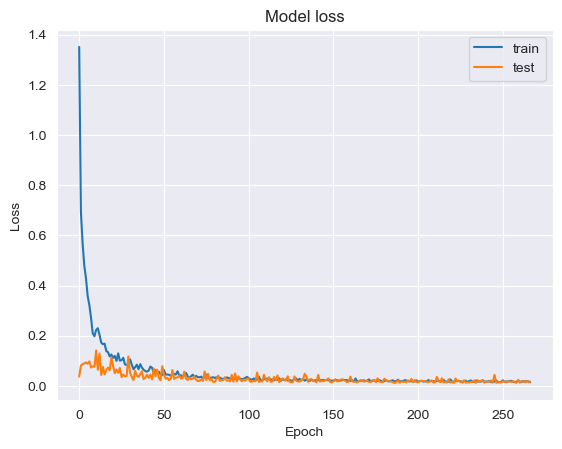

2/2 [==============================] - 0s 9ms/step
MSE: 0.02
R2: 0.39
Epoch 1/500
5/5 - 2s - loss: 1.2917 - mean_squared_error: 1.2917 - val_loss: 0.0594 - val_mean_squared_error: 0.0594 - 2s/epoch - 326ms/step
Epoch 2/500
5/5 - 0s - loss: 0.6748 - mean_squared_error: 0.6748 - val_loss: 0.0834 - val_mean_squared_error: 0.0834 - 130ms/epoch - 26ms/step
Epoch 3/500
5/5 - 0s - loss: 0.5343 - mean_squared_error: 0.5343 - val_loss: 0.0883 - val_mean_squared_error: 0.0883 - 109ms/epoch - 22ms/step
Epoch 4/500
5/5 - 0s - loss: 0.3922 - mean_squared_error: 0.3922 - val_loss: 0.0996 - val_mean_squared_error: 0.0996 - 142ms/epoch - 28ms/step
Epoch 5/500
5/5 - 0s - loss: 0.3762 - mean_squared_error: 0.3762 - val_loss: 0.1072 - val_mean_squared_error: 0.1072 - 126ms/epoch - 25ms/step
Epoch 6/500
5/5 - 0s - loss: 0.3711 - mean_squared_error: 0.3711 - val_loss: 0.1185 - val_mean_squared_error: 0.1185 - 127ms/epoch - 25ms/step
Epoch 7/500
5/5 - 0s - loss: 0.2882 - mean_squared_error: 0.2882 - val_los

Epoch 58/500
5/5 - 0s - loss: 0.0486 - mean_squared_error: 0.0486 - val_loss: 0.0595 - val_mean_squared_error: 0.0595 - 346ms/epoch - 69ms/step
Epoch 59/500
5/5 - 0s - loss: 0.0442 - mean_squared_error: 0.0442 - val_loss: 0.0479 - val_mean_squared_error: 0.0479 - 301ms/epoch - 60ms/step
Epoch 60/500
5/5 - 0s - loss: 0.0482 - mean_squared_error: 0.0482 - val_loss: 0.0210 - val_mean_squared_error: 0.0210 - 267ms/epoch - 53ms/step
Epoch 61/500
5/5 - 0s - loss: 0.0408 - mean_squared_error: 0.0408 - val_loss: 0.0244 - val_mean_squared_error: 0.0244 - 173ms/epoch - 35ms/step
Epoch 62/500
5/5 - 0s - loss: 0.0360 - mean_squared_error: 0.0360 - val_loss: 0.0284 - val_mean_squared_error: 0.0284 - 239ms/epoch - 48ms/step
Epoch 63/500
5/5 - 0s - loss: 0.0469 - mean_squared_error: 0.0469 - val_loss: 0.0191 - val_mean_squared_error: 0.0191 - 275ms/epoch - 55ms/step
Epoch 64/500
5/5 - 0s - loss: 0.0504 - mean_squared_error: 0.0504 - val_loss: 0.0253 - val_mean_squared_error: 0.0253 - 245ms/epoch - 49

Epoch 115/500
5/5 - 0s - loss: 0.0268 - mean_squared_error: 0.0268 - val_loss: 0.0225 - val_mean_squared_error: 0.0225 - 246ms/epoch - 49ms/step
Epoch 116/500
5/5 - 0s - loss: 0.0298 - mean_squared_error: 0.0298 - val_loss: 0.0328 - val_mean_squared_error: 0.0328 - 254ms/epoch - 51ms/step
Epoch 117/500
5/5 - 0s - loss: 0.0271 - mean_squared_error: 0.0271 - val_loss: 0.0282 - val_mean_squared_error: 0.0282 - 251ms/epoch - 50ms/step
Epoch 118/500
5/5 - 0s - loss: 0.0252 - mean_squared_error: 0.0252 - val_loss: 0.0187 - val_mean_squared_error: 0.0187 - 191ms/epoch - 38ms/step
Epoch 119/500
5/5 - 0s - loss: 0.0223 - mean_squared_error: 0.0223 - val_loss: 0.0151 - val_mean_squared_error: 0.0151 - 211ms/epoch - 42ms/step
Epoch 120/500
5/5 - 0s - loss: 0.0234 - mean_squared_error: 0.0234 - val_loss: 0.0249 - val_mean_squared_error: 0.0249 - 307ms/epoch - 61ms/step
Epoch 121/500
5/5 - 0s - loss: 0.0229 - mean_squared_error: 0.0229 - val_loss: 0.0179 - val_mean_squared_error: 0.0179 - 229ms/epo

Epoch 172/500
5/5 - 0s - loss: 0.0184 - mean_squared_error: 0.0184 - val_loss: 0.0136 - val_mean_squared_error: 0.0136 - 130ms/epoch - 26ms/step
Epoch 173/500
5/5 - 0s - loss: 0.0190 - mean_squared_error: 0.0190 - val_loss: 0.0151 - val_mean_squared_error: 0.0151 - 131ms/epoch - 26ms/step
Epoch 174/500
5/5 - 0s - loss: 0.0212 - mean_squared_error: 0.0212 - val_loss: 0.0246 - val_mean_squared_error: 0.0246 - 132ms/epoch - 26ms/step
Epoch 175/500
5/5 - 0s - loss: 0.0192 - mean_squared_error: 0.0192 - val_loss: 0.0133 - val_mean_squared_error: 0.0133 - 130ms/epoch - 26ms/step
Epoch 176/500
5/5 - 0s - loss: 0.0188 - mean_squared_error: 0.0188 - val_loss: 0.0269 - val_mean_squared_error: 0.0269 - 129ms/epoch - 26ms/step
Epoch 177/500
5/5 - 0s - loss: 0.0257 - mean_squared_error: 0.0257 - val_loss: 0.0269 - val_mean_squared_error: 0.0269 - 127ms/epoch - 25ms/step
Epoch 178/500
5/5 - 0s - loss: 0.0211 - mean_squared_error: 0.0211 - val_loss: 0.0164 - val_mean_squared_error: 0.0164 - 130ms/epo

Epoch 229/500
5/5 - 0s - loss: 0.0201 - mean_squared_error: 0.0201 - val_loss: 0.0287 - val_mean_squared_error: 0.0287 - 139ms/epoch - 28ms/step
Epoch 230/500
5/5 - 0s - loss: 0.0213 - mean_squared_error: 0.0213 - val_loss: 0.0168 - val_mean_squared_error: 0.0168 - 139ms/epoch - 28ms/step
Epoch 231/500
5/5 - 0s - loss: 0.0179 - mean_squared_error: 0.0179 - val_loss: 0.0294 - val_mean_squared_error: 0.0294 - 136ms/epoch - 27ms/step
Epoch 232/500
5/5 - 0s - loss: 0.0205 - mean_squared_error: 0.0205 - val_loss: 0.0165 - val_mean_squared_error: 0.0165 - 133ms/epoch - 27ms/step
Epoch 233/500
5/5 - 0s - loss: 0.0163 - mean_squared_error: 0.0163 - val_loss: 0.0140 - val_mean_squared_error: 0.0140 - 137ms/epoch - 27ms/step
Epoch 234/500
5/5 - 0s - loss: 0.0176 - mean_squared_error: 0.0176 - val_loss: 0.0256 - val_mean_squared_error: 0.0256 - 119ms/epoch - 24ms/step
Epoch 235/500
5/5 - 0s - loss: 0.0229 - mean_squared_error: 0.0229 - val_loss: 0.0140 - val_mean_squared_error: 0.0140 - 133ms/epo

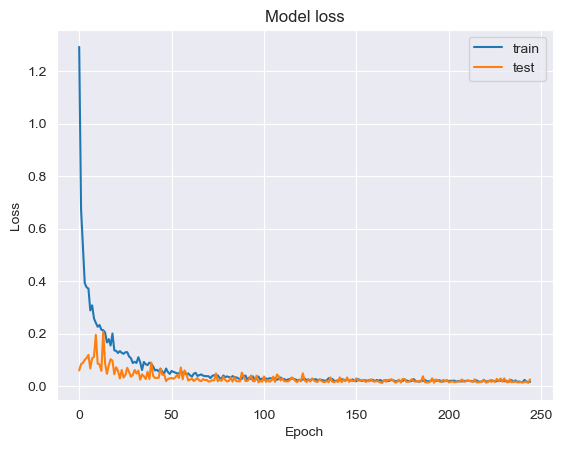

2/2 [==============================] - 0s 6ms/step
MSE: 0.03
R2: 0.11
Epoch 1/500
5/5 - 1s - loss: 1.1796 - mean_squared_error: 1.1796 - val_loss: 0.0322 - val_mean_squared_error: 0.0322 - 1s/epoch - 249ms/step
Epoch 2/500
5/5 - 0s - loss: 0.6669 - mean_squared_error: 0.6669 - val_loss: 0.0400 - val_mean_squared_error: 0.0400 - 122ms/epoch - 24ms/step
Epoch 3/500
5/5 - 0s - loss: 0.5003 - mean_squared_error: 0.5003 - val_loss: 0.0437 - val_mean_squared_error: 0.0437 - 133ms/epoch - 27ms/step
Epoch 4/500
5/5 - 0s - loss: 0.4056 - mean_squared_error: 0.4056 - val_loss: 0.0607 - val_mean_squared_error: 0.0607 - 124ms/epoch - 25ms/step
Epoch 5/500
5/5 - 0s - loss: 0.4044 - mean_squared_error: 0.4044 - val_loss: 0.0503 - val_mean_squared_error: 0.0503 - 127ms/epoch - 25ms/step
Epoch 6/500
5/5 - 0s - loss: 0.3004 - mean_squared_error: 0.3004 - val_loss: 0.0880 - val_mean_squared_error: 0.0880 - 126ms/epoch - 25ms/step
Epoch 7/500
5/5 - 0s - loss: 0.2529 - mean_squared_error: 0.2529 - val_los

Epoch 58/500
5/5 - 0s - loss: 0.0380 - mean_squared_error: 0.0380 - val_loss: 0.0240 - val_mean_squared_error: 0.0240 - 141ms/epoch - 28ms/step
Epoch 59/500
5/5 - 0s - loss: 0.0307 - mean_squared_error: 0.0307 - val_loss: 0.0220 - val_mean_squared_error: 0.0220 - 140ms/epoch - 28ms/step
Epoch 60/500
5/5 - 0s - loss: 0.0423 - mean_squared_error: 0.0423 - val_loss: 0.0326 - val_mean_squared_error: 0.0326 - 137ms/epoch - 27ms/step
Epoch 61/500
5/5 - 0s - loss: 0.0299 - mean_squared_error: 0.0299 - val_loss: 0.0281 - val_mean_squared_error: 0.0281 - 140ms/epoch - 28ms/step
Epoch 62/500
5/5 - 0s - loss: 0.0359 - mean_squared_error: 0.0359 - val_loss: 0.0240 - val_mean_squared_error: 0.0240 - 144ms/epoch - 29ms/step
Epoch 63/500
5/5 - 0s - loss: 0.0352 - mean_squared_error: 0.0352 - val_loss: 0.0222 - val_mean_squared_error: 0.0222 - 140ms/epoch - 28ms/step
Epoch 64/500
5/5 - 0s - loss: 0.0396 - mean_squared_error: 0.0396 - val_loss: 0.0915 - val_mean_squared_error: 0.0915 - 128ms/epoch - 26

Epoch 115/500
5/5 - 0s - loss: 0.0234 - mean_squared_error: 0.0234 - val_loss: 0.0163 - val_mean_squared_error: 0.0163 - 126ms/epoch - 25ms/step
Epoch 116/500
5/5 - 0s - loss: 0.0264 - mean_squared_error: 0.0264 - val_loss: 0.0140 - val_mean_squared_error: 0.0140 - 133ms/epoch - 27ms/step
Epoch 117/500
5/5 - 0s - loss: 0.0217 - mean_squared_error: 0.0217 - val_loss: 0.0193 - val_mean_squared_error: 0.0193 - 116ms/epoch - 23ms/step
Epoch 118/500
5/5 - 0s - loss: 0.0233 - mean_squared_error: 0.0233 - val_loss: 0.0176 - val_mean_squared_error: 0.0176 - 127ms/epoch - 25ms/step
Epoch 119/500
5/5 - 0s - loss: 0.0278 - mean_squared_error: 0.0278 - val_loss: 0.0254 - val_mean_squared_error: 0.0254 - 123ms/epoch - 25ms/step
Epoch 120/500
5/5 - 0s - loss: 0.0233 - mean_squared_error: 0.0233 - val_loss: 0.0177 - val_mean_squared_error: 0.0177 - 130ms/epoch - 26ms/step
Epoch 121/500
5/5 - 0s - loss: 0.0213 - mean_squared_error: 0.0213 - val_loss: 0.0259 - val_mean_squared_error: 0.0259 - 123ms/epo

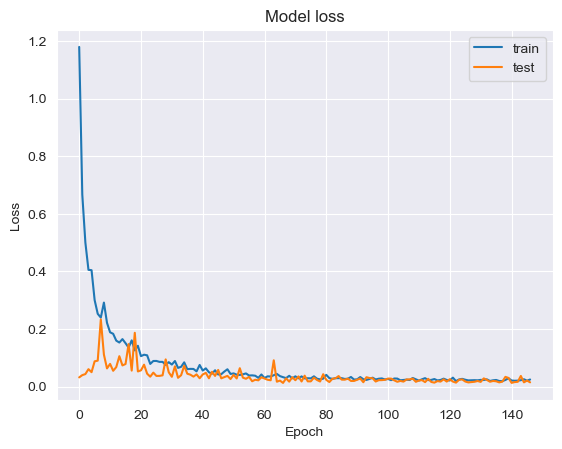

2/2 [==============================] - 0s 6ms/step
MSE: 0.02
R2: 0.47
Epoch 1/500
5/5 - 4s - loss: 2.0169 - mean_squared_error: 2.0169 - val_loss: 0.3515 - val_mean_squared_error: 0.3515 - 4s/epoch - 722ms/step
Epoch 2/500
5/5 - 0s - loss: 0.9357 - mean_squared_error: 0.9357 - val_loss: 0.6348 - val_mean_squared_error: 0.6348 - 121ms/epoch - 24ms/step
Epoch 3/500
5/5 - 0s - loss: 0.7882 - mean_squared_error: 0.7882 - val_loss: 0.6005 - val_mean_squared_error: 0.6005 - 108ms/epoch - 22ms/step
Epoch 4/500
5/5 - 0s - loss: 0.5532 - mean_squared_error: 0.5532 - val_loss: 0.4658 - val_mean_squared_error: 0.4658 - 127ms/epoch - 25ms/step
Epoch 5/500
5/5 - 0s - loss: 0.5418 - mean_squared_error: 0.5418 - val_loss: 0.3205 - val_mean_squared_error: 0.3205 - 127ms/epoch - 25ms/step
Epoch 6/500
5/5 - 0s - loss: 0.4240 - mean_squared_error: 0.4240 - val_loss: 0.2997 - val_mean_squared_error: 0.2997 - 133ms/epoch - 27ms/step
Epoch 7/500
5/5 - 0s - loss: 0.4460 - mean_squared_error: 0.4460 - val_los

Epoch 58/500
5/5 - 0s - loss: 0.0395 - mean_squared_error: 0.0395 - val_loss: 0.0454 - val_mean_squared_error: 0.0454 - 127ms/epoch - 25ms/step
Epoch 59/500
5/5 - 0s - loss: 0.0397 - mean_squared_error: 0.0397 - val_loss: 0.0271 - val_mean_squared_error: 0.0271 - 115ms/epoch - 23ms/step
Epoch 60/500
5/5 - 0s - loss: 0.0442 - mean_squared_error: 0.0442 - val_loss: 0.0320 - val_mean_squared_error: 0.0320 - 105ms/epoch - 21ms/step
Epoch 61/500
5/5 - 0s - loss: 0.0373 - mean_squared_error: 0.0373 - val_loss: 0.0449 - val_mean_squared_error: 0.0449 - 107ms/epoch - 21ms/step
Epoch 62/500
5/5 - 0s - loss: 0.0381 - mean_squared_error: 0.0381 - val_loss: 0.0222 - val_mean_squared_error: 0.0222 - 120ms/epoch - 24ms/step
Epoch 63/500
5/5 - 0s - loss: 0.0369 - mean_squared_error: 0.0369 - val_loss: 0.0412 - val_mean_squared_error: 0.0412 - 121ms/epoch - 24ms/step
Epoch 64/500
5/5 - 0s - loss: 0.0466 - mean_squared_error: 0.0466 - val_loss: 0.0295 - val_mean_squared_error: 0.0295 - 128ms/epoch - 26

Epoch 115/500
5/5 - 0s - loss: 0.0230 - mean_squared_error: 0.0230 - val_loss: 0.0282 - val_mean_squared_error: 0.0282 - 129ms/epoch - 26ms/step
Epoch 116/500
5/5 - 0s - loss: 0.0274 - mean_squared_error: 0.0274 - val_loss: 0.0204 - val_mean_squared_error: 0.0204 - 120ms/epoch - 24ms/step
Epoch 117/500
5/5 - 0s - loss: 0.0237 - mean_squared_error: 0.0237 - val_loss: 0.0216 - val_mean_squared_error: 0.0216 - 125ms/epoch - 25ms/step
Epoch 118/500
5/5 - 0s - loss: 0.0245 - mean_squared_error: 0.0245 - val_loss: 0.0170 - val_mean_squared_error: 0.0170 - 141ms/epoch - 28ms/step
Epoch 119/500
5/5 - 0s - loss: 0.0266 - mean_squared_error: 0.0266 - val_loss: 0.0194 - val_mean_squared_error: 0.0194 - 123ms/epoch - 25ms/step
Epoch 120/500
5/5 - 0s - loss: 0.0220 - mean_squared_error: 0.0220 - val_loss: 0.0236 - val_mean_squared_error: 0.0236 - 126ms/epoch - 25ms/step
Epoch 121/500
5/5 - 0s - loss: 0.0264 - mean_squared_error: 0.0264 - val_loss: 0.0321 - val_mean_squared_error: 0.0321 - 125ms/epo

Epoch 172/500
5/5 - 0s - loss: 0.0205 - mean_squared_error: 0.0205 - val_loss: 0.0284 - val_mean_squared_error: 0.0284 - 133ms/epoch - 27ms/step
Epoch 173/500
5/5 - 0s - loss: 0.0217 - mean_squared_error: 0.0217 - val_loss: 0.0200 - val_mean_squared_error: 0.0200 - 130ms/epoch - 26ms/step
Epoch 174/500
5/5 - 0s - loss: 0.0226 - mean_squared_error: 0.0226 - val_loss: 0.0127 - val_mean_squared_error: 0.0127 - 125ms/epoch - 25ms/step
Epoch 175/500
5/5 - 0s - loss: 0.0171 - mean_squared_error: 0.0171 - val_loss: 0.0224 - val_mean_squared_error: 0.0224 - 125ms/epoch - 25ms/step
Epoch 176/500
5/5 - 0s - loss: 0.0228 - mean_squared_error: 0.0228 - val_loss: 0.0231 - val_mean_squared_error: 0.0231 - 131ms/epoch - 26ms/step
Epoch 177/500
5/5 - 0s - loss: 0.0232 - mean_squared_error: 0.0232 - val_loss: 0.0132 - val_mean_squared_error: 0.0132 - 123ms/epoch - 25ms/step
Epoch 178/500
5/5 - 0s - loss: 0.0189 - mean_squared_error: 0.0189 - val_loss: 0.0194 - val_mean_squared_error: 0.0194 - 129ms/epo

Epoch 229/500
5/5 - 0s - loss: 0.0222 - mean_squared_error: 0.0222 - val_loss: 0.0130 - val_mean_squared_error: 0.0130 - 126ms/epoch - 25ms/step
Epoch 230/500
5/5 - 0s - loss: 0.0164 - mean_squared_error: 0.0164 - val_loss: 0.0170 - val_mean_squared_error: 0.0170 - 135ms/epoch - 27ms/step
Epoch 231/500
5/5 - 0s - loss: 0.0204 - mean_squared_error: 0.0204 - val_loss: 0.0141 - val_mean_squared_error: 0.0141 - 138ms/epoch - 28ms/step
Epoch 232/500
5/5 - 0s - loss: 0.0182 - mean_squared_error: 0.0182 - val_loss: 0.0213 - val_mean_squared_error: 0.0213 - 134ms/epoch - 27ms/step
Epoch 233/500
5/5 - 0s - loss: 0.0188 - mean_squared_error: 0.0188 - val_loss: 0.0154 - val_mean_squared_error: 0.0154 - 133ms/epoch - 27ms/step
Epoch 234/500
5/5 - 0s - loss: 0.0184 - mean_squared_error: 0.0184 - val_loss: 0.0156 - val_mean_squared_error: 0.0156 - 128ms/epoch - 26ms/step
Epoch 235/500
5/5 - 0s - loss: 0.0183 - mean_squared_error: 0.0183 - val_loss: 0.0177 - val_mean_squared_error: 0.0177 - 115ms/epo

Epoch 286/500
5/5 - 0s - loss: 0.0186 - mean_squared_error: 0.0186 - val_loss: 0.0222 - val_mean_squared_error: 0.0222 - 126ms/epoch - 25ms/step
Epoch 287/500
5/5 - 0s - loss: 0.0174 - mean_squared_error: 0.0174 - val_loss: 0.0140 - val_mean_squared_error: 0.0140 - 150ms/epoch - 30ms/step
Epoch 288/500
5/5 - 0s - loss: 0.0156 - mean_squared_error: 0.0156 - val_loss: 0.0165 - val_mean_squared_error: 0.0165 - 134ms/epoch - 27ms/step
Epoch 289/500
5/5 - 0s - loss: 0.0183 - mean_squared_error: 0.0183 - val_loss: 0.0132 - val_mean_squared_error: 0.0132 - 140ms/epoch - 28ms/step
Epoch 290/500
5/5 - 0s - loss: 0.0150 - mean_squared_error: 0.0150 - val_loss: 0.0127 - val_mean_squared_error: 0.0127 - 134ms/epoch - 27ms/step
Epoch 291/500
5/5 - 0s - loss: 0.0159 - mean_squared_error: 0.0159 - val_loss: 0.0107 - val_mean_squared_error: 0.0107 - 126ms/epoch - 25ms/step
Epoch 292/500
5/5 - 0s - loss: 0.0199 - mean_squared_error: 0.0199 - val_loss: 0.0127 - val_mean_squared_error: 0.0127 - 126ms/epo

Epoch 343/500
5/5 - 0s - loss: 0.0174 - mean_squared_error: 0.0174 - val_loss: 0.0182 - val_mean_squared_error: 0.0182 - 127ms/epoch - 25ms/step
Epoch 344/500
5/5 - 0s - loss: 0.0159 - mean_squared_error: 0.0159 - val_loss: 0.0115 - val_mean_squared_error: 0.0115 - 128ms/epoch - 26ms/step
Epoch 345/500
5/5 - 0s - loss: 0.0140 - mean_squared_error: 0.0140 - val_loss: 0.0104 - val_mean_squared_error: 0.0104 - 133ms/epoch - 27ms/step
Epoch 346/500
5/5 - 0s - loss: 0.0191 - mean_squared_error: 0.0191 - val_loss: 0.0136 - val_mean_squared_error: 0.0136 - 135ms/epoch - 27ms/step
Epoch 347/500
5/5 - 0s - loss: 0.0161 - mean_squared_error: 0.0161 - val_loss: 0.0111 - val_mean_squared_error: 0.0111 - 133ms/epoch - 27ms/step
Epoch 348/500
5/5 - 0s - loss: 0.0149 - mean_squared_error: 0.0149 - val_loss: 0.0162 - val_mean_squared_error: 0.0162 - 131ms/epoch - 26ms/step
Epoch 349/500
5/5 - 0s - loss: 0.0170 - mean_squared_error: 0.0170 - val_loss: 0.0120 - val_mean_squared_error: 0.0120 - 128ms/epo

Epoch 400/500
5/5 - 0s - loss: 0.0135 - mean_squared_error: 0.0135 - val_loss: 0.0139 - val_mean_squared_error: 0.0139 - 118ms/epoch - 24ms/step
Epoch 401/500
5/5 - 0s - loss: 0.0155 - mean_squared_error: 0.0155 - val_loss: 0.0106 - val_mean_squared_error: 0.0106 - 121ms/epoch - 24ms/step
Epoch 402/500
5/5 - 0s - loss: 0.0154 - mean_squared_error: 0.0154 - val_loss: 0.0114 - val_mean_squared_error: 0.0114 - 125ms/epoch - 25ms/step
Epoch 403/500
5/5 - 0s - loss: 0.0170 - mean_squared_error: 0.0170 - val_loss: 0.0142 - val_mean_squared_error: 0.0142 - 121ms/epoch - 24ms/step
Epoch 404/500
5/5 - 0s - loss: 0.0152 - mean_squared_error: 0.0152 - val_loss: 0.0093 - val_mean_squared_error: 0.0093 - 121ms/epoch - 24ms/step
Epoch 405/500
5/5 - 0s - loss: 0.0138 - mean_squared_error: 0.0138 - val_loss: 0.0141 - val_mean_squared_error: 0.0141 - 125ms/epoch - 25ms/step
Epoch 406/500
5/5 - 0s - loss: 0.0142 - mean_squared_error: 0.0142 - val_loss: 0.0109 - val_mean_squared_error: 0.0109 - 118ms/epo

Epoch 457/500
5/5 - 0s - loss: 0.0130 - mean_squared_error: 0.0130 - val_loss: 0.0136 - val_mean_squared_error: 0.0136 - 132ms/epoch - 26ms/step
Epoch 458/500
5/5 - 0s - loss: 0.0189 - mean_squared_error: 0.0189 - val_loss: 0.0104 - val_mean_squared_error: 0.0104 - 112ms/epoch - 22ms/step
Epoch 459/500
5/5 - 0s - loss: 0.0123 - mean_squared_error: 0.0123 - val_loss: 0.0111 - val_mean_squared_error: 0.0111 - 111ms/epoch - 22ms/step
Epoch 460/500
5/5 - 0s - loss: 0.0131 - mean_squared_error: 0.0131 - val_loss: 0.0093 - val_mean_squared_error: 0.0093 - 106ms/epoch - 21ms/step
Epoch 461/500
5/5 - 0s - loss: 0.0155 - mean_squared_error: 0.0155 - val_loss: 0.0179 - val_mean_squared_error: 0.0179 - 109ms/epoch - 22ms/step
Epoch 462/500
5/5 - 0s - loss: 0.0152 - mean_squared_error: 0.0152 - val_loss: 0.0091 - val_mean_squared_error: 0.0091 - 109ms/epoch - 22ms/step
Epoch 463/500
5/5 - 0s - loss: 0.0136 - mean_squared_error: 0.0136 - val_loss: 0.0140 - val_mean_squared_error: 0.0140 - 119ms/epo

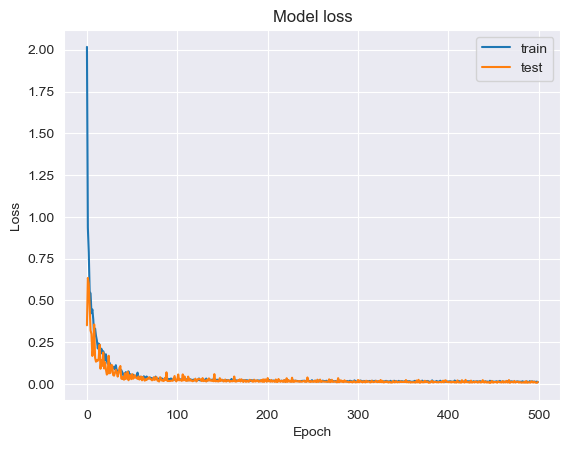

2/2 [==============================] - 0s 6ms/step
MSE: 0.01
R2: 0.56
Epoch 1/500
5/5 - 1s - loss: 1.5991 - mean_squared_error: 1.5991 - val_loss: 0.1347 - val_mean_squared_error: 0.1347 - 1s/epoch - 252ms/step
Epoch 2/500
5/5 - 0s - loss: 0.8905 - mean_squared_error: 0.8905 - val_loss: 0.1934 - val_mean_squared_error: 0.1934 - 129ms/epoch - 26ms/step
Epoch 3/500
5/5 - 0s - loss: 0.5677 - mean_squared_error: 0.5677 - val_loss: 0.1787 - val_mean_squared_error: 0.1787 - 133ms/epoch - 27ms/step
Epoch 4/500
5/5 - 0s - loss: 0.4530 - mean_squared_error: 0.4530 - val_loss: 0.1158 - val_mean_squared_error: 0.1158 - 127ms/epoch - 25ms/step
Epoch 5/500
5/5 - 0s - loss: 0.4663 - mean_squared_error: 0.4663 - val_loss: 0.1331 - val_mean_squared_error: 0.1331 - 128ms/epoch - 26ms/step
Epoch 6/500
5/5 - 0s - loss: 0.4210 - mean_squared_error: 0.4210 - val_loss: 0.0864 - val_mean_squared_error: 0.0864 - 130ms/epoch - 26ms/step
Epoch 7/500
5/5 - 0s - loss: 0.3399 - mean_squared_error: 0.3399 - val_los

Epoch 58/500
5/5 - 0s - loss: 0.0514 - mean_squared_error: 0.0514 - val_loss: 0.0449 - val_mean_squared_error: 0.0449 - 115ms/epoch - 23ms/step
Epoch 59/500
5/5 - 0s - loss: 0.0642 - mean_squared_error: 0.0642 - val_loss: 0.0260 - val_mean_squared_error: 0.0260 - 106ms/epoch - 21ms/step
Epoch 60/500
5/5 - 0s - loss: 0.0511 - mean_squared_error: 0.0511 - val_loss: 0.0602 - val_mean_squared_error: 0.0602 - 110ms/epoch - 22ms/step
Epoch 61/500
5/5 - 0s - loss: 0.0548 - mean_squared_error: 0.0548 - val_loss: 0.0308 - val_mean_squared_error: 0.0308 - 119ms/epoch - 24ms/step
Epoch 62/500
5/5 - 0s - loss: 0.0486 - mean_squared_error: 0.0486 - val_loss: 0.0558 - val_mean_squared_error: 0.0558 - 132ms/epoch - 26ms/step
Epoch 63/500
5/5 - 0s - loss: 0.0758 - mean_squared_error: 0.0758 - val_loss: 0.0333 - val_mean_squared_error: 0.0333 - 112ms/epoch - 22ms/step
Epoch 64/500
5/5 - 0s - loss: 0.0405 - mean_squared_error: 0.0405 - val_loss: 0.0426 - val_mean_squared_error: 0.0426 - 122ms/epoch - 24

Epoch 115/500
5/5 - 0s - loss: 0.0246 - mean_squared_error: 0.0246 - val_loss: 0.0177 - val_mean_squared_error: 0.0177 - 123ms/epoch - 25ms/step
Epoch 116/500
5/5 - 0s - loss: 0.0310 - mean_squared_error: 0.0310 - val_loss: 0.0187 - val_mean_squared_error: 0.0187 - 119ms/epoch - 24ms/step
Epoch 117/500
5/5 - 0s - loss: 0.0284 - mean_squared_error: 0.0284 - val_loss: 0.0253 - val_mean_squared_error: 0.0253 - 119ms/epoch - 24ms/step
Epoch 118/500
5/5 - 0s - loss: 0.0244 - mean_squared_error: 0.0244 - val_loss: 0.0148 - val_mean_squared_error: 0.0148 - 118ms/epoch - 24ms/step
Epoch 119/500
5/5 - 0s - loss: 0.0347 - mean_squared_error: 0.0347 - val_loss: 0.0178 - val_mean_squared_error: 0.0178 - 118ms/epoch - 24ms/step
Epoch 120/500
5/5 - 0s - loss: 0.0273 - mean_squared_error: 0.0273 - val_loss: 0.0261 - val_mean_squared_error: 0.0261 - 118ms/epoch - 24ms/step
Epoch 121/500
5/5 - 0s - loss: 0.0255 - mean_squared_error: 0.0255 - val_loss: 0.0135 - val_mean_squared_error: 0.0135 - 122ms/epo

Epoch 172/500
5/5 - 0s - loss: 0.0188 - mean_squared_error: 0.0188 - val_loss: 0.0132 - val_mean_squared_error: 0.0132 - 126ms/epoch - 25ms/step
Epoch 173/500
5/5 - 0s - loss: 0.0210 - mean_squared_error: 0.0210 - val_loss: 0.0170 - val_mean_squared_error: 0.0170 - 123ms/epoch - 25ms/step
Epoch 174/500
5/5 - 0s - loss: 0.0198 - mean_squared_error: 0.0198 - val_loss: 0.0162 - val_mean_squared_error: 0.0162 - 119ms/epoch - 24ms/step
Epoch 175/500
5/5 - 0s - loss: 0.0180 - mean_squared_error: 0.0180 - val_loss: 0.0185 - val_mean_squared_error: 0.0185 - 132ms/epoch - 26ms/step
Epoch 176/500
5/5 - 0s - loss: 0.0240 - mean_squared_error: 0.0240 - val_loss: 0.0155 - val_mean_squared_error: 0.0155 - 128ms/epoch - 26ms/step
Epoch 177/500
5/5 - 0s - loss: 0.0223 - mean_squared_error: 0.0223 - val_loss: 0.0203 - val_mean_squared_error: 0.0203 - 122ms/epoch - 24ms/step
Epoch 178/500
5/5 - 0s - loss: 0.0225 - mean_squared_error: 0.0225 - val_loss: 0.0137 - val_mean_squared_error: 0.0137 - 120ms/epo

Epoch 229/500
5/5 - 0s - loss: 0.0223 - mean_squared_error: 0.0223 - val_loss: 0.0116 - val_mean_squared_error: 0.0116 - 128ms/epoch - 26ms/step
Epoch 230/500
5/5 - 0s - loss: 0.0167 - mean_squared_error: 0.0167 - val_loss: 0.0127 - val_mean_squared_error: 0.0127 - 127ms/epoch - 25ms/step
Epoch 231/500
5/5 - 0s - loss: 0.0168 - mean_squared_error: 0.0168 - val_loss: 0.0134 - val_mean_squared_error: 0.0134 - 115ms/epoch - 23ms/step
Epoch 232/500
5/5 - 0s - loss: 0.0166 - mean_squared_error: 0.0166 - val_loss: 0.0196 - val_mean_squared_error: 0.0196 - 121ms/epoch - 24ms/step
Epoch 233/500
5/5 - 0s - loss: 0.0197 - mean_squared_error: 0.0197 - val_loss: 0.0250 - val_mean_squared_error: 0.0250 - 120ms/epoch - 24ms/step
Epoch 234/500
5/5 - 0s - loss: 0.0143 - mean_squared_error: 0.0143 - val_loss: 0.0101 - val_mean_squared_error: 0.0101 - 122ms/epoch - 24ms/step
Epoch 235/500
5/5 - 0s - loss: 0.0162 - mean_squared_error: 0.0162 - val_loss: 0.0213 - val_mean_squared_error: 0.0213 - 120ms/epo

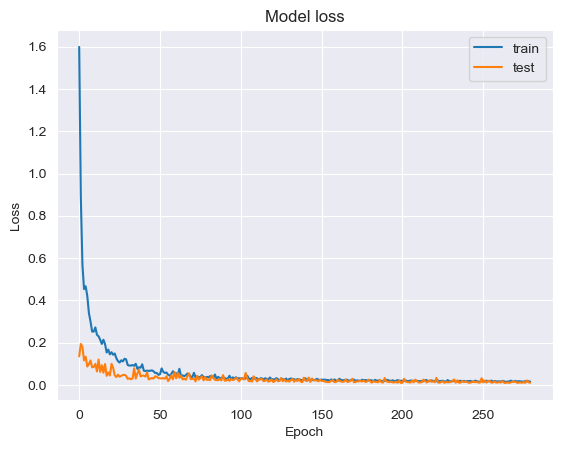

2/2 [==============================] - 0s 5ms/step
MSE: 0.01
R2: 0.66
Epoch 1/500
5/5 - 1s - loss: 1.4429 - mean_squared_error: 1.4429 - val_loss: 0.0677 - val_mean_squared_error: 0.0677 - 1s/epoch - 248ms/step
Epoch 2/500
5/5 - 0s - loss: 0.6725 - mean_squared_error: 0.6725 - val_loss: 0.1155 - val_mean_squared_error: 0.1155 - 107ms/epoch - 21ms/step
Epoch 3/500
5/5 - 0s - loss: 0.5170 - mean_squared_error: 0.5170 - val_loss: 0.1049 - val_mean_squared_error: 0.1049 - 126ms/epoch - 25ms/step
Epoch 4/500
5/5 - 0s - loss: 0.4339 - mean_squared_error: 0.4339 - val_loss: 0.1112 - val_mean_squared_error: 0.1112 - 124ms/epoch - 25ms/step
Epoch 5/500
5/5 - 0s - loss: 0.3959 - mean_squared_error: 0.3959 - val_loss: 0.1028 - val_mean_squared_error: 0.1028 - 123ms/epoch - 25ms/step
Epoch 6/500
5/5 - 0s - loss: 0.3518 - mean_squared_error: 0.3518 - val_loss: 0.1105 - val_mean_squared_error: 0.1105 - 109ms/epoch - 22ms/step
Epoch 7/500
5/5 - 0s - loss: 0.3112 - mean_squared_error: 0.3112 - val_los

Epoch 58/500
5/5 - 0s - loss: 0.0465 - mean_squared_error: 0.0465 - val_loss: 0.0465 - val_mean_squared_error: 0.0465 - 125ms/epoch - 25ms/step
Epoch 59/500
5/5 - 0s - loss: 0.0566 - mean_squared_error: 0.0566 - val_loss: 0.0242 - val_mean_squared_error: 0.0242 - 123ms/epoch - 25ms/step
Epoch 60/500
5/5 - 0s - loss: 0.0425 - mean_squared_error: 0.0425 - val_loss: 0.0317 - val_mean_squared_error: 0.0317 - 124ms/epoch - 25ms/step
Epoch 61/500
5/5 - 0s - loss: 0.0420 - mean_squared_error: 0.0420 - val_loss: 0.0383 - val_mean_squared_error: 0.0383 - 123ms/epoch - 25ms/step
Epoch 62/500
5/5 - 0s - loss: 0.0439 - mean_squared_error: 0.0439 - val_loss: 0.0532 - val_mean_squared_error: 0.0532 - 128ms/epoch - 26ms/step
Epoch 63/500
5/5 - 0s - loss: 0.0537 - mean_squared_error: 0.0537 - val_loss: 0.0272 - val_mean_squared_error: 0.0272 - 112ms/epoch - 22ms/step
Epoch 64/500
5/5 - 0s - loss: 0.0407 - mean_squared_error: 0.0407 - val_loss: 0.0186 - val_mean_squared_error: 0.0186 - 125ms/epoch - 25

Epoch 115/500
5/5 - 0s - loss: 0.0222 - mean_squared_error: 0.0222 - val_loss: 0.0186 - val_mean_squared_error: 0.0186 - 114ms/epoch - 23ms/step
Epoch 116/500
5/5 - 0s - loss: 0.0227 - mean_squared_error: 0.0227 - val_loss: 0.0143 - val_mean_squared_error: 0.0143 - 119ms/epoch - 24ms/step
Epoch 117/500
5/5 - 0s - loss: 0.0262 - mean_squared_error: 0.0262 - val_loss: 0.0182 - val_mean_squared_error: 0.0182 - 122ms/epoch - 24ms/step
Epoch 118/500
5/5 - 0s - loss: 0.0244 - mean_squared_error: 0.0244 - val_loss: 0.0164 - val_mean_squared_error: 0.0164 - 125ms/epoch - 25ms/step
Epoch 119/500
5/5 - 0s - loss: 0.0254 - mean_squared_error: 0.0254 - val_loss: 0.0302 - val_mean_squared_error: 0.0302 - 126ms/epoch - 25ms/step
Epoch 120/500
5/5 - 0s - loss: 0.0293 - mean_squared_error: 0.0293 - val_loss: 0.0134 - val_mean_squared_error: 0.0134 - 109ms/epoch - 22ms/step
Epoch 121/500
5/5 - 0s - loss: 0.0204 - mean_squared_error: 0.0204 - val_loss: 0.0169 - val_mean_squared_error: 0.0169 - 107ms/epo

Epoch 172/500
5/5 - 0s - loss: 0.0203 - mean_squared_error: 0.0203 - val_loss: 0.0131 - val_mean_squared_error: 0.0131 - 120ms/epoch - 24ms/step
Epoch 173/500
5/5 - 0s - loss: 0.0227 - mean_squared_error: 0.0227 - val_loss: 0.0205 - val_mean_squared_error: 0.0205 - 122ms/epoch - 24ms/step
Epoch 174/500
5/5 - 0s - loss: 0.0189 - mean_squared_error: 0.0189 - val_loss: 0.0115 - val_mean_squared_error: 0.0115 - 110ms/epoch - 22ms/step
Epoch 175/500
5/5 - 0s - loss: 0.0171 - mean_squared_error: 0.0171 - val_loss: 0.0168 - val_mean_squared_error: 0.0168 - 114ms/epoch - 23ms/step
Epoch 176/500
5/5 - 0s - loss: 0.0246 - mean_squared_error: 0.0246 - val_loss: 0.0293 - val_mean_squared_error: 0.0293 - 125ms/epoch - 25ms/step
Epoch 177/500
5/5 - 0s - loss: 0.0230 - mean_squared_error: 0.0230 - val_loss: 0.0198 - val_mean_squared_error: 0.0198 - 113ms/epoch - 23ms/step
Epoch 178/500
5/5 - 0s - loss: 0.0192 - mean_squared_error: 0.0192 - val_loss: 0.0180 - val_mean_squared_error: 0.0180 - 119ms/epo

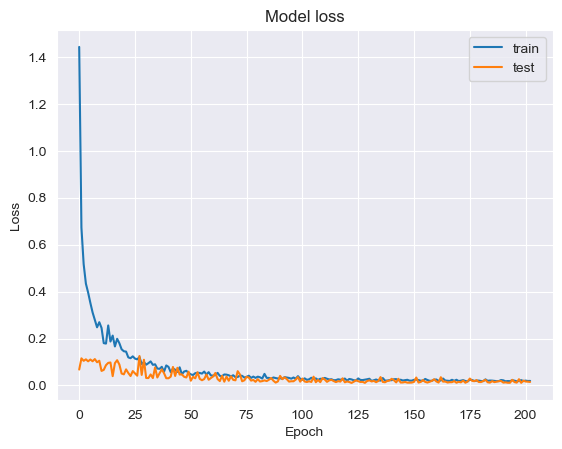

2/2 [==============================] - 0s 7ms/step
MSE: 0.01
R2: 0.48
Epoch 1/500
5/5 - 1s - loss: 1.5272 - mean_squared_error: 1.5272 - val_loss: 0.0389 - val_mean_squared_error: 0.0389 - 1s/epoch - 246ms/step
Epoch 2/500
5/5 - 0s - loss: 0.6415 - mean_squared_error: 0.6415 - val_loss: 0.0372 - val_mean_squared_error: 0.0372 - 129ms/epoch - 26ms/step
Epoch 3/500
5/5 - 0s - loss: 0.5428 - mean_squared_error: 0.5428 - val_loss: 0.0534 - val_mean_squared_error: 0.0534 - 140ms/epoch - 28ms/step
Epoch 4/500
5/5 - 0s - loss: 0.4369 - mean_squared_error: 0.4369 - val_loss: 0.0579 - val_mean_squared_error: 0.0579 - 129ms/epoch - 26ms/step
Epoch 5/500
5/5 - 0s - loss: 0.4165 - mean_squared_error: 0.4165 - val_loss: 0.0826 - val_mean_squared_error: 0.0826 - 129ms/epoch - 26ms/step
Epoch 6/500
5/5 - 0s - loss: 0.3654 - mean_squared_error: 0.3654 - val_loss: 0.1477 - val_mean_squared_error: 0.1477 - 130ms/epoch - 26ms/step
Epoch 7/500
5/5 - 0s - loss: 0.3187 - mean_squared_error: 0.3187 - val_los

Epoch 58/500
5/5 - 0s - loss: 0.0391 - mean_squared_error: 0.0391 - val_loss: 0.0573 - val_mean_squared_error: 0.0573 - 113ms/epoch - 23ms/step
Epoch 59/500
5/5 - 0s - loss: 0.0514 - mean_squared_error: 0.0514 - val_loss: 0.0308 - val_mean_squared_error: 0.0308 - 111ms/epoch - 22ms/step
Epoch 60/500
5/5 - 0s - loss: 0.0416 - mean_squared_error: 0.0416 - val_loss: 0.0427 - val_mean_squared_error: 0.0427 - 127ms/epoch - 25ms/step
Epoch 61/500
5/5 - 0s - loss: 0.0423 - mean_squared_error: 0.0423 - val_loss: 0.0255 - val_mean_squared_error: 0.0255 - 109ms/epoch - 22ms/step
Epoch 62/500
5/5 - 0s - loss: 0.0425 - mean_squared_error: 0.0425 - val_loss: 0.0418 - val_mean_squared_error: 0.0418 - 119ms/epoch - 24ms/step
Epoch 63/500
5/5 - 0s - loss: 0.0453 - mean_squared_error: 0.0453 - val_loss: 0.0253 - val_mean_squared_error: 0.0253 - 132ms/epoch - 26ms/step
Epoch 64/500
5/5 - 0s - loss: 0.0386 - mean_squared_error: 0.0386 - val_loss: 0.0368 - val_mean_squared_error: 0.0368 - 119ms/epoch - 24

Epoch 115/500
5/5 - 0s - loss: 0.0287 - mean_squared_error: 0.0287 - val_loss: 0.0197 - val_mean_squared_error: 0.0197 - 109ms/epoch - 22ms/step
Epoch 116/500
5/5 - 0s - loss: 0.0278 - mean_squared_error: 0.0278 - val_loss: 0.0238 - val_mean_squared_error: 0.0238 - 119ms/epoch - 24ms/step
Epoch 117/500
5/5 - 0s - loss: 0.0252 - mean_squared_error: 0.0252 - val_loss: 0.0231 - val_mean_squared_error: 0.0231 - 120ms/epoch - 24ms/step
Epoch 118/500
5/5 - 0s - loss: 0.0221 - mean_squared_error: 0.0221 - val_loss: 0.0188 - val_mean_squared_error: 0.0188 - 107ms/epoch - 21ms/step
Epoch 119/500
5/5 - 0s - loss: 0.0319 - mean_squared_error: 0.0319 - val_loss: 0.0161 - val_mean_squared_error: 0.0161 - 120ms/epoch - 24ms/step
Epoch 120/500
5/5 - 0s - loss: 0.0214 - mean_squared_error: 0.0214 - val_loss: 0.0205 - val_mean_squared_error: 0.0205 - 125ms/epoch - 25ms/step
Epoch 121/500
5/5 - 0s - loss: 0.0250 - mean_squared_error: 0.0250 - val_loss: 0.0339 - val_mean_squared_error: 0.0339 - 119ms/epo

Epoch 172/500
5/5 - 0s - loss: 0.0184 - mean_squared_error: 0.0184 - val_loss: 0.0161 - val_mean_squared_error: 0.0161 - 109ms/epoch - 22ms/step
Epoch 173/500
5/5 - 0s - loss: 0.0202 - mean_squared_error: 0.0202 - val_loss: 0.0198 - val_mean_squared_error: 0.0198 - 111ms/epoch - 22ms/step
Epoch 174/500
5/5 - 0s - loss: 0.0187 - mean_squared_error: 0.0187 - val_loss: 0.0222 - val_mean_squared_error: 0.0222 - 121ms/epoch - 24ms/step
Epoch 175/500
5/5 - 0s - loss: 0.0256 - mean_squared_error: 0.0256 - val_loss: 0.0202 - val_mean_squared_error: 0.0202 - 114ms/epoch - 23ms/step
Epoch 176/500
5/5 - 0s - loss: 0.0217 - mean_squared_error: 0.0217 - val_loss: 0.0156 - val_mean_squared_error: 0.0156 - 127ms/epoch - 25ms/step
Epoch 177/500
5/5 - 0s - loss: 0.0229 - mean_squared_error: 0.0229 - val_loss: 0.0182 - val_mean_squared_error: 0.0182 - 109ms/epoch - 22ms/step
Epoch 178/500
5/5 - 0s - loss: 0.0178 - mean_squared_error: 0.0178 - val_loss: 0.0192 - val_mean_squared_error: 0.0192 - 111ms/epo

Epoch 229/500
5/5 - 0s - loss: 0.0237 - mean_squared_error: 0.0237 - val_loss: 0.0130 - val_mean_squared_error: 0.0130 - 107ms/epoch - 21ms/step
Epoch 230/500
5/5 - 0s - loss: 0.0177 - mean_squared_error: 0.0177 - val_loss: 0.0122 - val_mean_squared_error: 0.0122 - 109ms/epoch - 22ms/step
Epoch 231/500
5/5 - 0s - loss: 0.0162 - mean_squared_error: 0.0162 - val_loss: 0.0137 - val_mean_squared_error: 0.0137 - 111ms/epoch - 22ms/step
Epoch 232/500
5/5 - 0s - loss: 0.0171 - mean_squared_error: 0.0171 - val_loss: 0.0305 - val_mean_squared_error: 0.0305 - 105ms/epoch - 21ms/step
Epoch 233/500
5/5 - 0s - loss: 0.0234 - mean_squared_error: 0.0234 - val_loss: 0.0197 - val_mean_squared_error: 0.0197 - 111ms/epoch - 22ms/step
Epoch 234/500
5/5 - 0s - loss: 0.0178 - mean_squared_error: 0.0178 - val_loss: 0.0129 - val_mean_squared_error: 0.0129 - 119ms/epoch - 24ms/step
Epoch 235/500
5/5 - 0s - loss: 0.0192 - mean_squared_error: 0.0192 - val_loss: 0.0335 - val_mean_squared_error: 0.0335 - 119ms/epo

Epoch 286/500
5/5 - 0s - loss: 0.0174 - mean_squared_error: 0.0174 - val_loss: 0.0169 - val_mean_squared_error: 0.0169 - 117ms/epoch - 23ms/step
Epoch 287/500
5/5 - 0s - loss: 0.0234 - mean_squared_error: 0.0234 - val_loss: 0.0121 - val_mean_squared_error: 0.0121 - 122ms/epoch - 24ms/step
Epoch 288/500
5/5 - 0s - loss: 0.0155 - mean_squared_error: 0.0155 - val_loss: 0.0130 - val_mean_squared_error: 0.0130 - 127ms/epoch - 25ms/step
Epoch 289/500
5/5 - 0s - loss: 0.0155 - mean_squared_error: 0.0155 - val_loss: 0.0119 - val_mean_squared_error: 0.0119 - 122ms/epoch - 24ms/step
Epoch 290/500
5/5 - 0s - loss: 0.0182 - mean_squared_error: 0.0182 - val_loss: 0.0308 - val_mean_squared_error: 0.0308 - 113ms/epoch - 23ms/step
Epoch 291/500
5/5 - 0s - loss: 0.0211 - mean_squared_error: 0.0211 - val_loss: 0.0132 - val_mean_squared_error: 0.0132 - 113ms/epoch - 23ms/step
Epoch 292/500
5/5 - 0s - loss: 0.0160 - mean_squared_error: 0.0160 - val_loss: 0.0115 - val_mean_squared_error: 0.0115 - 136ms/epo

Epoch 343/500
5/5 - 0s - loss: 0.0159 - mean_squared_error: 0.0159 - val_loss: 0.0209 - val_mean_squared_error: 0.0209 - 115ms/epoch - 23ms/step
Epoch 344/500
5/5 - 0s - loss: 0.0200 - mean_squared_error: 0.0200 - val_loss: 0.0118 - val_mean_squared_error: 0.0118 - 125ms/epoch - 25ms/step
Epoch 345/500
5/5 - 0s - loss: 0.0138 - mean_squared_error: 0.0138 - val_loss: 0.0117 - val_mean_squared_error: 0.0117 - 111ms/epoch - 22ms/step
Epoch 346/500
5/5 - 0s - loss: 0.0161 - mean_squared_error: 0.0161 - val_loss: 0.0210 - val_mean_squared_error: 0.0210 - 130ms/epoch - 26ms/step
Epoch 347/500
5/5 - 0s - loss: 0.0171 - mean_squared_error: 0.0171 - val_loss: 0.0096 - val_mean_squared_error: 0.0096 - 113ms/epoch - 23ms/step
Epoch 348/500
5/5 - 0s - loss: 0.0159 - mean_squared_error: 0.0159 - val_loss: 0.0112 - val_mean_squared_error: 0.0112 - 124ms/epoch - 25ms/step
Epoch 349/500
5/5 - 0s - loss: 0.0147 - mean_squared_error: 0.0147 - val_loss: 0.0146 - val_mean_squared_error: 0.0146 - 119ms/epo

Epoch 400/500
5/5 - 0s - loss: 0.0157 - mean_squared_error: 0.0157 - val_loss: 0.0330 - val_mean_squared_error: 0.0330 - 128ms/epoch - 26ms/step
Epoch 401/500
5/5 - 0s - loss: 0.0206 - mean_squared_error: 0.0206 - val_loss: 0.0120 - val_mean_squared_error: 0.0120 - 115ms/epoch - 23ms/step
Epoch 402/500
5/5 - 0s - loss: 0.0145 - mean_squared_error: 0.0145 - val_loss: 0.0136 - val_mean_squared_error: 0.0136 - 109ms/epoch - 22ms/step
Epoch 403/500
5/5 - 0s - loss: 0.0162 - mean_squared_error: 0.0162 - val_loss: 0.0124 - val_mean_squared_error: 0.0124 - 123ms/epoch - 25ms/step
Epoch 404/500
5/5 - 0s - loss: 0.0156 - mean_squared_error: 0.0156 - val_loss: 0.0123 - val_mean_squared_error: 0.0123 - 111ms/epoch - 22ms/step
Epoch 405/500
5/5 - 0s - loss: 0.0146 - mean_squared_error: 0.0146 - val_loss: 0.0126 - val_mean_squared_error: 0.0126 - 115ms/epoch - 23ms/step
Epoch 406/500
5/5 - 0s - loss: 0.0156 - mean_squared_error: 0.0156 - val_loss: 0.0257 - val_mean_squared_error: 0.0257 - 120ms/epo

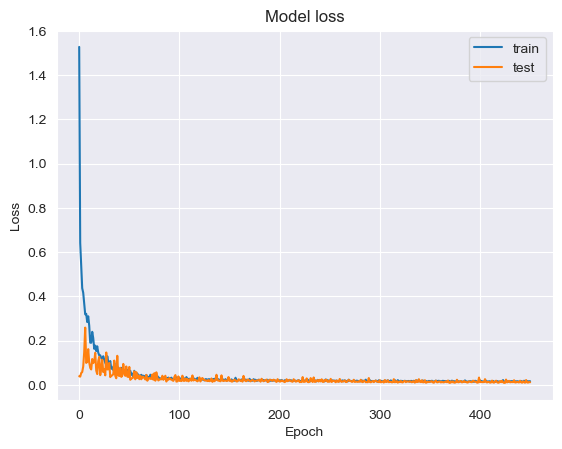

2/2 [==============================] - 0s 6ms/step
MSE: 0.01
R2: 0.59
[0.5644352459558962, 0.5481186052057838, 0.675902460083952, 0.3899823515016966, 0.1055801807127057, 0.47269909875925675, 0.5643641413964635, 0.6615008561709267, 0.4761077604556285, 0.5877507128536745]
Mean R2: 0.50 (+/- 0.16)


In [185]:
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, r2_score
from keras.layers import BatchNormalization

kfold = KFold(n_splits=10, shuffle=True, random_state=7)
cvscores = []

for train, test in kfold.split(x, y):
    # 创建模型
    model = Sequential()
    model.add(Dense(128, input_dim=input, activation='relu'))
    model.add(BatchNormalization(momentum=0.8))
    model.add(Dropout(0.5))
    model.add(Dense(128, activation='relu'))
    model.add(BatchNormalization(momentum=0.8))
    model.add(Dense(1, activation='linear'))
    
    # 编译模型
    rmsprop = tf.keras.optimizers.RMSprop(learning_rate=0.001, rho=0.9, epsilon=1e-08)
    model.compile(loss='mean_squared_error', optimizer=rmsprop, metrics=['mean_squared_error'])
    
    # 训练模型
    early_stopping = EarlyStopping(monitor='val_loss', patience=80, verbose=2)
    history = model.fit(x, y, epochs=500, batch_size=128, shuffle=False, verbose=2,
                        validation_data=(x_test, y_test), callbacks=[early_stopping])
    
    # 绘制损失曲线
    plt.plot(history.history['loss'], label='train')
    plt.plot(history.history['val_loss'], label='test')
    plt.title('Model loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()
    plt.show()
    
    # 模型评估
    y_pred = model.predict(x_test)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    print("MSE: %.2f" % mse)
    print("R2: %.2f" % r2)
    
    cvscores.append(r2)
    
print(cvscores)
print("Mean R2: %.2f (+/- %.2f)" % (np.mean(cvscores), np.std(cvscores)))

## MLP

In [186]:
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score, make_scorer
import numpy as np

In [187]:
# 创建多层感知机回归模型实例
mlp_regressor = MLPRegressor(random_state=42, max_iter=1000)

# 定义参数网格
param_grid = {
    'hidden_layer_sizes': [(10,), (20,), (10,10)],
    'activation': ['relu', 'tanh'],
    'solver': ['adam', 'lbfgs'],
    'alpha': [0.0001, 0.001, 0.01]
}

# 定义评分函数
mse_scorer = make_scorer(mean_squared_error, greater_is_better=False)

# 使用 GridSearchCV 进行参数优化
grid_search = GridSearchCV(mlp_regressor, param_grid, scoring=mse_scorer, cv=5, n_jobs=-1, verbose=1)
grid_search.fit(x, y)

# 打印找到的最佳参数
print(f"Best parameters found: {grid_search.best_params_}")

# 使用最佳参数重新训练模型
best_mlp = grid_search.best_estimator_

# 模型预测
y_pred = best_mlp.predict(x_test)

# 评估模型
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f'The rmse of prediction is: {rmse}')
print(f'The R^2 score of prediction is: {r2}')

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best parameters found: {'activation': 'tanh', 'alpha': 0.01, 'hidden_layer_sizes': (10, 10), 'solver': 'lbfgs'}
The rmse of prediction is: 0.060551423819720125
The R^2 score of prediction is: 0.8712062204457536


D:\Anaconda\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


## XGBOOST

In [188]:
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import xgboost as xgb
import numpy as np
import pandas as pd

In [189]:
# 定义你希望调优的参数范围
param_grid = {
    'learning_rate': [0.01, 0.1, 0.2, 0.3],
    'max_depth': [4, 5, 6],
    'n_estimators': [50, 100, 150],
    'gamma': [0, 0.1, 0.2],
    'alpha': [0, 0.1, 0.2],
    'lambda': [0, 0.1, 0.2]
}

# 创建XGBoost回归模型实例
xgb_reg = xgb.XGBRegressor(objective ='reg:squarederror')

# 将模型和参数范围传入 GridSearchCV，并设置交叉验证数量为 5
grid_search = GridSearchCV(xgb_reg, param_grid, cv=5, scoring='neg_mean_squared_error')

# 使用训练数据拟合 GridSearchCV
grid_search.fit(x, y)

# 打印最佳参数组合
print(f"Best parameters: {grid_search.best_params_}")

# 使用最优参数在所有训练数据上重新训练模型
best_xgb_reg = grid_search.best_estimator_

# 如果使用xgb.train，则需使用以下代码
dtrain = xgb.DMatrix(x, label=y)
dtest = xgb.DMatrix(x_test, label=y_test)

# 设置参数（使用上面GridSearchCV得到的最优参数）
best_params = grid_search.best_params_
best_params["objective"] = "reg:squarederror"

bst = xgb.train(best_params,
                dtrain,
                num_boost_round=100,
                evals=[(dtest, "test")],
                early_stopping_rounds=10,
                verbose_eval=False)

# 对测试集进行预测
preds = best_xgb_reg.predict(x_test)

# 计算并打印均方误差和确定系数（R-squared）
rmse = np.sqrt(mean_squared_error(y_test, preds))
r2 = r2_score(y_test, preds)

print("RMSE: %f" % (rmse))
print("R2: %f" % (r2))

Best parameters: {'alpha': 0.1, 'gamma': 0, 'lambda': 0.1, 'learning_rate': 0.3, 'max_depth': 4, 'n_estimators': 150}


C:\Users\zangd\AppData\Roaming\Python\Python311\site-packages\xgboost\core.py:160: UserWarning: [20:17:41] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0cec3277c4d9d0165-1\xgboost\xgboost-ci-windows\src\learner.cc:742: 
Parameters: { "n_estimators" } are not used.

  warnings.warn(smsg, UserWarning)


RMSE: 0.053715
R2: 0.898645


## PSO optimization for XGBoost

In [190]:
from pyswarm import pso
from sklearn.metrics import mean_squared_error

In [191]:
train_data=pd.read_excel(r'D:\creep rupture\TR+TS\特征筛选GAN200train.xlsx')
test_data=pd.read_excel(r'D:\creep rupture\TR+TS\特征筛选GAN200test.xlsx')
x_train = train_data.drop(columns=[ 'Time to Rupture(h)'])
y_train = train_data['Time to Rupture(h)']
x_test = test_data.drop(columns=['Time to Rupture(h)'])
y_test = test_data['Time to Rupture(h)']

In [192]:
def objective_func(particle_position):
    max_depth = int(particle_position[0])
    learning_rate = particle_position[1]
    n_estimators = int(particle_position[2])
    min_child_weight = int(particle_position[3])
    subsample = particle_position[4]
    gamma = particle_position[5]

    model = xgb.XGBRegressor(max_depth=max_depth,
                             learning_rate=learning_rate,
                             n_estimators=n_estimators,
                             min_child_weight=min_child_weight,
                             subsample=subsample,
                             gamma=gamma)
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    mse = mean_squared_error(y_test, y_pred)
    return mse

In [193]:
lb = [1, 0.001, 50, 1, 0.1, 0]
ub = [10, 0.5, 500, 10, 1, 1]

xopt, fopt = pso(objective_func, lb, ub, swarmsize=30, maxiter=100)
print('Found optimal solution: ', xopt)
print('Objective function at optimal solution: ', fopt)

Stopping search: Swarm best objective change less than 1e-08
Found optimal solution:  [  5.6629085    0.5        192.72173468   1.15025193   0.9978345
   0.        ]
Objective function at optimal solution:  0.0013352091937449948


In [194]:
max_depth = int(xopt[0])
learning_rate = xopt[1]
n_estimators = int(xopt[2])
min_child_weight = int(xopt[3])
subsample = xopt[4]
gamma = xopt[5]

model_optimal = xgb.XGBRegressor(max_depth=max_depth,
                                 learning_rate=learning_rate,
                                 n_estimators=n_estimators,
                                 min_child_weight=min_child_weight,
                                 subsample=subsample,
                                 gamma=gamma)
model_optimal.fit(x_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=0.0, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.5, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=5, max_leaves=None,
             min_child_weight=1, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=192, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

In [196]:
from sklearn.metrics import mean_absolute_error, r2_score

# 预测 x_test
y_pred = model_optimal.predict(x_test)

# 评估模型性能
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.5f}")
print(f"Mean Absolute Error (MAE): {mae:.5f}")
print(f"R2 Score: {r2:.5f}")

Mean Squared Error (MSE): 0.00134
Mean Absolute Error (MAE): 0.01991
R2 Score: 0.95310


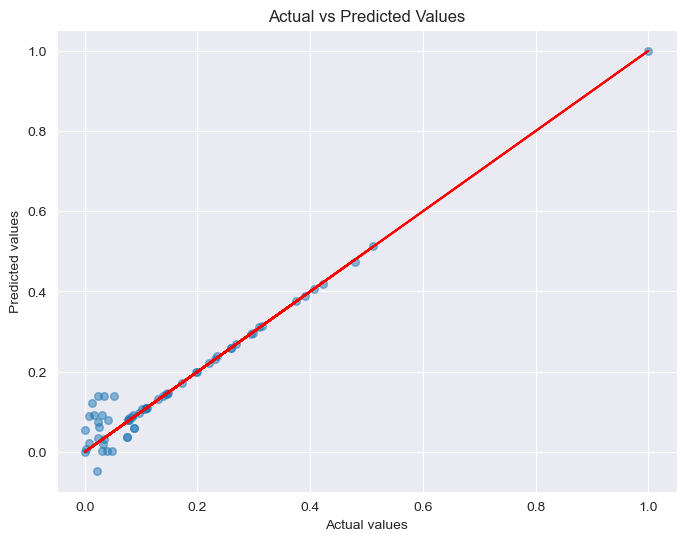

In [197]:
import matplotlib.pyplot as plt

# Draw scatter plot
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, s=30, alpha=0.5)
plt.title('Actual vs Predicted Values')
plt.xlabel('Actual values')
plt.ylabel('Predicted values')

# Draw line for perfect predictions
plt.plot(y_test, y_test, 'r')

plt.show()

## PSO optimization for GBDT

In [198]:
from sklearn.ensemble import GradientBoostingRegressor

def objective_func(particle_position):
    max_depth = int(particle_position[0])
    learning_rate = particle_position[1]
    n_estimators = int(particle_position[2])
    min_samples_split = int(particle_position[3])
    subsample = particle_position[4]

    model = GradientBoostingRegressor(max_depth=max_depth,
                                      learning_rate=learning_rate,
                                      n_estimators=n_estimators,
                                      min_samples_split=min_samples_split,
                                      subsample=subsample)
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    mse = mean_squared_error(y_test, y_pred)
    return mse

In [199]:
lb = [1, 0.001, 50, 2, 0.1]
ub = [10, 0.5, 500, 5, 1]

xopt, fopt = pso(objective_func, lb, ub, swarmsize=30, maxiter=100)
print('Found optimal solution: ', xopt)
print('Objective function at optimal solution: ', fopt)

Stopping search: maximum iterations reached --> 100
Found optimal solution:  [7.51739672e+00 2.06978018e-01 2.94359168e+02 3.33831251e+00
 5.30883708e-01]
Objective function at optimal solution:  0.0009911218315801378


In [200]:
max_depth = int(xopt[0])
learning_rate = xopt[1]
n_estimators = int(xopt[2])
min_samples_split = int(xopt[3])
subsample = xopt[4]

model_optimal = GradientBoostingRegressor(max_depth=max_depth,
                                          learning_rate=learning_rate,
                                          n_estimators=n_estimators,
                                          min_samples_split=min_samples_split,
                                          subsample=subsample)

model_optimal.fit(x_train, y_train)

GradientBoostingRegressor(learning_rate=0.20697801823874043, max_depth=7,
                          min_samples_split=3, n_estimators=294,
                          subsample=0.5308837082618812)

In [201]:
# 预测 x_test
y_pred = model_optimal.predict(x_test)

# 评估模型性能
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"R2 Score: {r2:.2f}")

Mean Squared Error (MSE): 0.00
Mean Absolute Error (MAE): 0.02
R2 Score: 0.91
